In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# Merged and deduplicated sentences (Ground Truth)
merged_ground_truth_sentences = [
    "hoe plows (tills) field plant grain / pellet thousand",
    "god sees truth feather (truth/maat) heart",
    "quail chick and swallow fly above the papyrus clump water",
    "old man and woman stay in the reed shelter house",
    "youth sees great town",
    "the king gives the gift of life",
    "scribe of town do writing of grain on papyrus scroll",
    "people rest on mats inside house after work",
    "wisdom guides youth",
    "old man teaches youth",
    "people fear darkness underground west",
    "people see king",
    "negation (no/not) return / retreat road city / town gate house",
    "a thousand jars of milk are for god",
    "youth sees swallow (great) above lake behind / back beautiful river",
    "people cross hill slope",
    "mouth speaks truth",
    "brick builds town",
    "the servant plows with a great strength",
    "man ties twisted flax",
    "conical loaf (give) offering peace / altar loaf of bread milk jar jar",
    "king sees stability (djed) power above sky behind / back beautiful / good city / town",
    "king rules people city town power",
    "father hold youth power",
    "god gives ka spirit",
    "vessel jar milk jar peace / satisfy god / deity",
    "king to give life (ankh) behind / back beautiful / good peace / altar god",
    "man carries rope across desert hill alone calmly",
    "god hears great fear",
    "servant eat / drink / speak loaf of bread milk jar house",
    "great king of the city becomes lord of every basket",
    "father guide youth soul",
    "people drink lake water ripple",
    "a scribe finds the heart of the truth",
    "servant bring peace altar",
    "venerated / marrow strength",
    "god send blessing life people",
    "people celebrate life under stars and sky",
    "man drink river water",
    "the youth sees the face of mother",
    "a servant carries a basket of brick",
    "offering peace / altar god temple",
    "people honor maat feather",
    "a servant gives a conical loaf to father",
    "servant hear / listen authority like / as (or example) beautiful / good man",
    "hand forearm foot animal belly backbone rib",
    "adze chisel stone brick house city",
    "man sees underground",
    "god makes desert hill",
    "servant gives milk jar",
    "desert hill horizon west underground soul (ba) life",
    "thousand grain / pellet field plant lotus plant reed leaf",
    "the king gives the milk jar mother",
    "people rest beside lake",
    "servant of king do offering of fire on the altar",
    "woman see mountain sky",
    "soul (ba) emerge above sky like / as (or example) star great horizon",
    "mountain behind sky",
    "king rules city town lord",
    "mother gives birth youth",
    "servant carry the jar and loaf to the reed shelter",
    "a youth sees the cobra in the desert",
    "a youth finds the door bolt in sand",
    "adze chisel stone seat / throne great / big",
    "man to return / retreat west mountain road behind / back town",
    "scribe hear / listen authority like / as (or example) great king",
    "emerge horizon sky life god soul (ba) star",
    "man carry coil rope",
    "spirit ka of king become star in sky above horizon",
    "ka (spirit) emerge above mountain like / as (or example) beautiful / good star",
    "man sees animal belly backbone side / rib behind / back great / big mountain",
    "king give life stability power great",
    "man sees owl",
    "cobra fear power god snake strength / force",
    "man plows riverbank",
    "old man hear book write scribe",
    "king sees adze chisel above stone behind / back temple",
    "god strengthens backbone of king with power great",
    "god bless field grain",
    "people walk riverbank road",
    "snake emerges above hill",
    "swallow swallow (great) sky star god life power",
    "sweet milk jar face / upon peace / altar temple",
    "man opens door",
    "god protect river people",
    "man walk road desert hill mountain",
    "youth become venerated / marrow behind / back great / mighty stone temple house road",
    "youth sees horizon",
    "god / deity to give peace / satisfy heart above people",
    "scribe writing / scribe papyrus scroll like / as (or example) thing stool",
    "scribe sees head of ox",
    "the scribe reads the book of god",
    "god shapes stone mountain",
    "old man hears wisdom of god",
    "people follow road across desert",
    "servant open reed gate",
    "man woman youth servant people seated king",
    "life continues after death in west",
    "great god sees beautiful city town",
    "people build river town",
    "soul (ba) travel sky star horizon",
    "the king rules city town",
    "house near road",
    "people walk mountain road",
    "city holds people",
    "house reed shelter peace / content (satisfied) life",
    "the lord gives a loaf to the servant",
    "god emerges above horizon sky",
    "three fox skins stay on the back of the vessel",
    "a thousand fish swim in the blue water",
    "eye sees face / upon",
    "become scarab emerge life (ankh) horizon star sky",
    "sun above horizon",
    "sky horizon star above mountain desert hill",
    "the placenta is placed on the stone altar",
    "king speaks words power",
    "great storm above the city make the sky become dark",
    "mountain near desert",
    "the father gives a loaf of bread",
    "lake reflects sky",
    "the youth plows tills the small field",
    "father speaks truth",
    "scribe hear / listen heart above beautiful / good life (ankh) thing",
    "god hears voice",
    "the king gives the djed for stability",
    "scribe sees adze chisel above brick stone house town road gate",
    "servant finds door bolt",
    "god above people",
    "chisel and adze stay on the stool mat near stone",
    "heart becomes great peace",
    "man sees star sky",
    "man hear storm river",
    "people gather lotus plant lake",
    "head of ox strength / force power god temple offering peace / altar life authority",
    "the master gives a jar to servant",
    "star shines above desert hill night",
    "servant to do / make basket (lord / all) above stool / mat house",
    "the old man hears the sound of water",
    "the great power of life is in god",
    "man sees sickle hoe adze chisel above brick stone house",
    "great god rules sky",
    "god hears people cry heart fear",
    "mother guide youth heart",
    "head of ox grain / pellet field",
    "king sees placenta",
    "the ka spirit enters the stone gate",
    "man lifts stone with strength beside temple gate",
    "ka (spirit) eat / drink / speak loaf of bread milk sweet",
    "basket (lord / all) face / upon animal belly life (ankh) god",
    "a scribe plays senet board with the king",
    "youth become venerated / marrow behind / back stone temple house road city town",
    "servant guard river gate",
    "to return / retreat behind / back gate",
    "people gather grain pellet thousand",
    "quail chick youth life people town man",
    "woman speaks sweet words",
    "people settle fertile field",
    "a man with a club protects the house",
    "river road town city / town people life power strength / force heart great / mighty",
    "venerated father hear voice of mother in the stone house",
    "negation (no/not) do eat / drink / speak offering life peace / satisfy heart people house god",
    "scarab become life",
    "a king gives a thousand jars of grain",
    "beautiful / good woman youth seated woman mother heart",
    "man lifts stone pillar",
    "youth seek sweet life",
    "the god gives a thousand loaves bread",
    "sickle cuts grain",
    "great lord of every town play the senet board game",
    "man feel fear storm",
    "master (lord) / all (every) servant hear / listen authority king",
    "animal belly placenta gives birth / begets",
    "servant finds reed leaf",
    "servant fill grain basket",
    "god sees man heart",
    "man carries vessel milk jar hand",
    "river riverbank people sees life water ripple peace / satisfy heart beautiful / good sweet",
    "basket lord every",
    "woman sees lotus plant above lake behind / back beautiful / good plant",
    "mother gives milk jar to youth gently",
    "king hears mouth speak people",
    "king sees seat throne",
    "people cross river water",
    "throne in temple",
    "woman mother youth behind / back reed shelter sweet loaf bread",
    "woman sees lotus plant above lake behind / back beautiful / good river",
    "the god gives an offering of milk",
    "the great swallow flies above the river bank",
    "the master sees the three fox skins",
    "people cross riverbank road town gate",
    "king protects people",
    "desert underground west soul (ba) life",
    "scribe to do / make writing / scribe behind / back beautiful / good riverbank road",
    "king wears sedge crown",
    "a youth sees the cobra behind the wall",
    "sweet bread offering",
    "temple pillar / grandfather god authority power stability (djed) peace life great / mighty sky",
    "people fear authority",
    "the master sees a thousand lotus plants",
    "man finds stone brick",
    "venerated / marrow strength / force",
    "good mother gives life youth",
    "mother sees jars in rack",
    "woman see star sky",
    "god bless great life",
    "a scribe eats bread inside the house",
    "the lord of all souls finds great content",
    "king protects temple god people city",
    "king gives offering bread loaf",
    "ka spirit becomes god",
    "heart fear storm fire strength / force man life to become power great / big",
    "mouth eat / drink / speak",
    "woman hears mother voice",
    "loaf of bread offering peace / altar",
    "town behind river",
    "woman hear owl sky",
    "the horizon shows the way to city",
    "man eats bread",
    "the spirit ka finds the way to sky",
    "mother eats loaf of bread",
    "mother see placenta of the youth in the reed shelter",
    "man bring milk vessel",
    "to do work",
    "ka spirit life",
    "a scribe reads the book in the temple",
    "tethering rope hold the vessel near the great riverbank road",
    "snake guards temple",
    "scribe sees reed leaf",
    "god hears heart",
    "spirit ka of god sees heart of lord in temple",
    "the master gives authority to the man",
    "seated god on throne give power to king in house",
    "people see god / deity",
    "scribe makes writing",
    "a thousand bricks build the house of life",
    "king hears people fear",
    "the scribe writes on a stone brick",
    "sky above mountain desert hill slope",
    "cobra snake horned viper fear man woman",
    "loaf of bread",
    "stone gives strength",
    "plant feeds people",
    "horned viper snake fear desert hill mountain hill",
    "negation no man can see the spirit ka in house",
    "the god watches over city",
    "the soul rests upon the star above",
    "king sees stability (djed) power above great / mighty temple city road",
    "scribe writing / scribe papyrus scroll book",
    "the cobra emerges from the lotus plant",
    "the god gives strength force power",
    "old man and woman drink from the milk jar house",
    "sedge king on the throne gives birth to the law",
    "servant guard house door",
    "mouth eat / drink / speak loaf of bread milk jar jar",
    "youth eats grain / pellet",
    "foot forearm hand side / rib backbone heart",
    "old man cuts plant",
    "man feel fear heart",
    "king count thousand grain offering",
    "town above river",
    "power strength force",
    "man makes gate",
    "man use adze to shape the stone of the mountain",
    "fear of storm",
    "ba (soul) ka (spirit) emerge house life (ankh) horizon sky star",
    "heart peace / content (satisfied) soul (ba) life (ankh) god",
    "the backbone of the snake is very long",
    "hand of king hold the authority of the great god",
    "mother place the placenta in the basket with handle",
    "animal belly and side rib stay in the basket handle",
    "the lord hears no voice of fear",
    "woman see owl sky",
    "scribe makes twisted flax",
    "people cross lake shore",
    "people build stone temple",
    "man sees eye face / upon sky star sweet life heart love",
    "god grants eternal stability",
    "man plows repeated field hoe hand",
    "senet board ring thing to do / make hand seated man",
    "seated man (i / me) hear / listen heart god people",
    "father guide youth peace",
    "man plows hill slope field with steady strength",
    "mother gives birth / begets youth above great stone house",
    "man walks road town gate",
    "king makes great city",
    "plows (tills) field grain / pellet people life strength / force peace great / big heart power",
    "a star shines above the house of life",
    "spirit ka of mother loves the heart of beautiful youth",
    "the woman does make a lotus ring",
    "senet board stool / mat seated man",
    "animal belly gives birth / begets youth life (ankh)",
    "god gives life power",
    "youth become old man life (ankh) venerated / marrow",
    "king protects temple god people authority",
    "road town city",
    "king sees great star above mountain behind / back god",
    "servant people house do hand life power authority peace great / big",
    "the desert hare hides in the reed shelter",
    "god / deity to give peace / satisfy heart above sky horizon",
    "the old man sees a great mountain",
    "man rest stool / mat house",
    "king hear / listen authority behind / back gate city road",
    "king sit throne judge people",
    "loaf of bread milk jar vessel jar offering peace / altar",
    "scribe hear / listen owl above papyrus clump behind / back riverbank town road",
    "scribe sees swallow (great) above lake behind / back beautiful / good riverbank river",
    "lord every people eat loaf bread",
    "hear listen mouth eat drink speak truth maat feather",
    "king protects sacred shrine",
    "a thousand jars of grain are for god",
    "god gives stability (djed)",
    "man sees snake coil near riverbank cautiously today",
    "man carries basket with handle",
    "house behind gate",
    "the venerated marrow is inside the large bone",
    "the king gives a ring to the woman",
    "king sees animal belly",
    "order sustains world",
    "god / deity sees truth behind / back face / upon beautiful man",
    "placenta become to become life (ankh) youth man",
    "beautiful / good peace / altar above great / big hill slope",
    "servant to do / make basket (lord / all) above stool / mat house gate",
    "father mother youth gives birth / begets life (ankh) peace / altar",
    "venerated / marrow father youth life (ankh) peace / content (satisfied) heart",
    "ka (spirit) eat / drink / speak loaf of bread milk",
    "brick stone house city / town people life power",
    "man lifts door bolt to open gate",
    "man plows (tills) field like / as (or example) father behind / back house",
    "cobra and snake hide under the stone in the desert",
    "forearm strong hand to do / make thing great / mighty",
    "man feel fire strength",
    "man see cobra hill",
    "man feel strong force",
    "great storm above lake make the people fear the god",
    "a man with an adze cuts the wood",
    "a coil of rope lies behind the basket",
    "people live near city town",
    "man leave town toward desert",
    "river water ripple lake fish life",
    "woman beautiful / good heart love mother youth life (ankh)",
    "mountain hill desert silence fear beauty sky",
    "mountain desert hill desert hill slope road city / town",
    "scribe sees single stroke",
    "mighty backbone of king give strength to the whole city",
    "the great storm emerges from the east sky",
    "sky horizon star above mountain desert hill",
    "a star is above the great temple gate",
    "king grants land people",
    "a steward brings the jars in a rack",
    "heart finds sweet life",
    "king rules town city",
    "people honor ancestors pillar with offerings yearly together",
    "god grants peace content satisfied",
    "snake coils rope",
    "king raise power strength force",
    "owl night sky",
    "scribe sees door bolt behind / back stone house town gate",
    "old man venerated / marrow father heart soul (ba)",
    "authority strength / force master (lord) / all (every)",
    "father backbone strength / force life authority",
    "seated woman loves the beautiful lotus plant in the lake",
    "hand of the scribe hold reed leaf for papyrus scroll",
    "man eat / drink / speak",
    "pilgrims enter temple",
    "soul (ba) return underground west mountain hill",
    "scribe sees adze chisel above brick stone behind / back",
    "the master opens the gate of town",
    "god near temple",
    "the king gives authority to the master",
    "the soul finds a throne of gold",
    "west mountain horizon sky star above above",
    "basket (lord / all) thing great / big",
    "man carries basket lord all",
    "people fear power",
    "mother give youth heart",
    "people build house town",
    "power gives strength",
    "soul ba of father fly like swallow to the mountain",
    "the great sky becomes fire above the mountain",
    "god rule mountain sky",
    "the old man sits upon the stone mat",
    "god mark fate thousand years",
    "god breathes life into clay vessel gently",
    "old man youth servant people seated man woman",
    "the great storm emerges from the west sky",
    "a reed shelter sits on the river bank",
    "throne king sedge",
    "the scribe makes a writing about the heart",
    "soul (ba) emerge above mountain behind / back great / mighty desert hill hill slope",
    "man bring peace satisfy",
    "sickle plows (tills) grain / pellet field strong",
    "the scribe uses an adze for the wood",
    "people travel beyond desert hill",
    "a beautiful lotus plant grows in the river",
    "single stroke stroke (plural marker) papyrus scroll book scribe writing / scribe thing",
    "king to return / retreat west mountain road behind town",
    "the great soul becomes a bright star",
    "god grants peace satisfied heart",
    "hand of servant place the conical loaf on stool mat",
    "stability djed power",
    "the god stands above the lake water",
    "the side rib of ox is on altar",
    "god opens gate horizon",
    "door bolt of temple opens for the soul of god",
    "the woman sees the vessel of life",
    "lord / every riverbank become great / big field plant",
    "man enters house",
    "youth sees beauty / good",
    "king gives bread",
    "god emerges sky horizon west mountain",
    "scribe sees book above stool / mat behind / back great / big house",
    "soul (ba) sky star horizon",
    "writing scribe records",
    "cross cut stone chisel do hand strength / force power great / big authority",
    "chisel and adze stay on the stool mat in temple",
    "west underground dead",
    "youth love sweet life",
    "above behind back face upon side rib underground horizon",
    "snake and cobra emerge from the field near the road",
    "reed leaf writing / scribe papyrus scroll book hand",
    "lotus plant lake water ripple beautiful / good life peace / content (satisfied) sweet sky heart love",
    "king hears prayer temple people god",
    "people build house brick stone",
    "mother hears swallow (great)",
    "scribe sees owl swallow emerge above papyrus clump road house town",
    "road leads city / town gate",
    "king descend mountain toward town",
    "negation no man can hide from the eye of god",
    "servant eat / drink / speak milk jar sweet loaf bread",
    "people fear snake cobra storm",
    "the spirit ka finds life in the temple",
    "eye face upon",
    "a servant carries a jar of sweet milk",
    "youth seek sweet heart",
    "king gives tethering rope",
    "the heart finds a way to god",
    "venerated master of all give offering on the stone altar",
    "the lord gives power to the scribe",
    "venerated master hear soul ba of youth in great city",
    "servant guard house gate",
    "grain pellet jar",
    "king sits throne seat power",
    "power of god",
    "lord of life do offering of the lotus plant altar",
    "man tills soil plows",
    "god gives peace satisfied",
    "man sees animal belly backbone side / rib behind / back great mountain",
    "woman carry reed leaf",
    "servant fill vessel milk",
    "ka spirit dwells within man",
    "seated man (i / me) book writing / scribe hand scribe",
    "spirit ka of the god stay in the great temple",
    "god / deity hear / listen heart behind / back mighty stone",
    "gate behind house",
    "a man with an adze makes the stool",
    "hoe plows (tills) plows (repeated) field grain / pellet servant man",
    "a master of all things gives the power",
    "a scribe speaks with the power of truth",
    "youth sees pool",
    "scribe use chisel to do writing on the stone throne",
    "truth weighs heart",
    "god / deity sees scarab / become above face / upon horizon",
    "father sees great city",
    "horned viper guards",
    "man return house after journey",
    "people gather grain pellet field jars",
    "scribe writing / scribe papyrus scroll above stone stool / mat great house",
    "the king gives a thousand power words",
    "underground lake water ripple snake emerge",
    "king gives stability (djed)",
    "man eats loaf of bread",
    "people see light on horizon",
    "adze chisel cut stone brick temple god / deity",
    "underground lake water ripple snake emerge horizon",
    "the woman stands upon the field ground",
    "woman carries water jar across town road slowly",
    "man drinks water river lake",
    "mountain behind hill",
    "mother sees head of bird",
    "the woman finds a lotus plant nearby",
    "milk jar vessel",
    "a great snake emerges from the underground place",
    "foot road journey town life people",
    "father sees fire",
    "fire storm fear strength / force heart",
    "the lord hears a word of truth",
    "negation no man can hear the voice of the snake",
    "a man with an adze makes the chair",
    "the horizon stays above the river bank",
    "star lights sky",
    "people live riverbank lake field",
    "people praise seated god",
    "riverbank lotus plant swallow sky water ripple lake",
    "to return / retreat behind / back gate town road",
    "king to give life (ankh) behind / back beautiful / good altar",
    "foot walks road town city / town people life journey power",
    "man hears mighty fire",
    "people live near riverbank town",
    "servant fill jar water",
    "thousand grain / pellet offering conical loaf (give) peace / satisfy",
    "lord of every city give life ankh to the people",
    "life gives power",
    "youth finds great mountain",
    "man follow twisted flax",
    "woman carries milk jar",
    "storm brings fear",
    "man returns home house",
    "god rests on throne",
    "mother gives birth / begets youth above reed shelter beautiful / good star",
    "venerated / marrow father hear heart soul (ba)",
    "chisel and adze stay on the stone brick in field",
    "man plows (tills) field like / as (or example) beautiful / good servant father",
    "old man wisdom",
    "king loves throne",
    "a youth hears the word of the mother",
    "a thousand bricks build the great city town",
    "scribe hears master speak",
    "the desert hare runs across the hill slope",
    "people walk road to town",
    "woman sees beautiful face",
    "king to return / retreat west mountain road behind / back desert hill",
    "eye sees face / upon beauty truth feather (truth/maat) heart peace life",
    "woman gives birth placenta youth life",
    "the king sees the great swallow fly",
    "fire gives power",
    "god judge heart feather maat",
    "god sends fire storm sky",
    "people open temple gate",
    "woman feel heart life",
    "the cobra moves under the basket handle",
    "woman tend field plant life",
    "youth sees swallow (great) above lake behind / back beautiful / good river",
    "god gives thousand",
    "people praise god temple offering",
    "woman sit house weaving folded cloth",
    "old man venerated / marrow",
    "father hear youth voice",
    "man bring peace content",
    "man climb hill stone",
    "servant to do / make basket (lord / all) above stool",
    "scribe writing / scribe papyrus scroll book above stool / mat house",
    "the heart hears the word of life",
    "the youth uses an adze for boat",
    "king sees forearm",
    "basket with handle milk jar vessel",
    "three fox skins strength / force power authority king he / king sedge",
    "gate door bolt reed shelter house brick",
    "god / deity sees scarab / become above face / upon beautiful horizon",
    "king loves lake",
    "mother give sweet milk",
    "a king with authority speaks to the god",
    "the servant gives a vessel of milk",
    "great / mighty storm fire sky mountain hill slope",
    "man sees ka (spirit) above stone house behind / back",
    "strong man plows great field",
    "mighty authority of master become great like the mountain side",
    "father guide youth road town",
    "god sees heart man",
    "great big town",
    "man enters house gate",
    "the animal belly is cold on the stone",
    "king sees people",
    "a man with authority protects the temple house",
    "the seated king sees the beautiful city town",
    "stability djed of the god stay in the great city",
    "basket (lord / all) thing beautiful / good",
    "people travel road town city",
    "the god opens the gate",
    "man fears horned viper snake",
    "a god gives life to the beautiful woman",
    "the side rib of the ox is good",
    "cobra snake horned viper quail chick desert hare animal",
    "servant to do / make basket (lord / all) above stool / mat house town gate",
    "youth become old man behind / back great / big stone temple",
    "seated man heart love peace / content (satisfied)",
    "woman smile sweet heart peace",
    "soul ba of father fly above the great riverbank road",
    "mother sees youth become old man behind / back stone house",
    "a woman brings a jar to the altar",
    "river lake water ripple life field",
    "king sits throne",
    "old man with hoe plows the field near the mountain",
    "vessel floats water",
    "the backbone of the scribe is very straight",
    "the beautiful face of the woman is great",
    "papyrus clump plant field life water ripple peace / content (satisfied) sweet beautiful / good",
    "tethering rope rope coil of rope basket with handle thing",
    "the youth finds a star in the water",
    "man carries rope coil twisted flax",
    "the king makes a house for god",
    "swallow (great) emerge horizon sky star above",
    "feather truth maat",
    "the heart hears the word of father",
    "god emerges horizon west sky",
    "a youth sees the cobra in the sand",
    "negation no man can hide from the eye of god",
    "cobra hide stone hill",
    "god watches star sky swallow",
    "people cross riverbank hill",
    "fire gives fear",
    "water ripple becomes big",
    "youth hear / listen great / big master (lord) / all (every) eat / drink / speak",
    "scribe writing / scribe papyrus scroll book above stool / mat temple",
    "man strike stone adze tool",
    "god face upon",
    "gate house opens life peace god heart",
    "man hears sound of owl",
    "a scribe reads the book of the dead",
    "woman eat / drink / speak loaf of bread milk jar sweet thing house",
    "king holds power authority strength",
    "scribe sees papyrus scroll above great basket with handle",
    "power strengthens king",
    "a man with a club walks behind town",
    "soul ba of the father fly above the great mountain",
    "the backbone of the mother is very strong",
    "authority power strength / force strong pillar / grandfather stability (djed)",
    "the king gives the sedge to lord",
    "king sees beautiful city",
    "father sees hill slope",
    "the side rib of animal sits on stone",
    "god gives thousand grain pellet people",
    "god grants power and stability djed",
    "conical loaf (give) offering peace / altar life (ankh) god / deity",
    "great god opens gate city town above river west",
    "people emerge above gate behind / back great / mighty city town temple road",
    "chisel and adze stay on the stone near the temple",
    "the great king sits upon the throne seat",
    "god grants peace satisfy heart",
    "man sees sickle hoe adze chisel behind / back stone house",
    "grain / pellet life food offering people",
    "father hold youth peace",
    "strong man with the hoe plows tills the field road",
    "the animal belly is on the cold stone",
    "basket (lord / all) people hear / listen authority king god / deity",
    "quail chick swallow owl head of bird head of ox animal",
    "mother gives birth / begets youth above stool / mat stone house",
    "stone chisel cuts brick",
    "the master of the house finds a stool",
    "mother gives birth / begets youth like / as (or example) beautiful / good star above sky horizon",
    "the servant uses a hoe for grain",
    "scribe writing / scribe papyrus scroll book above stool / mat city",
    "mother rests on mat holding sleeping child",
    "man carry vessel water",
    "feather (truth/maat) heart peace / content (satisfied)",
    "woman walks toward horizon",
    "the throne of the king is made stone",
    "heart truth feather (truth/maat) balance judgment soul (ba)",
    "the backbone of a man is very great",
    "scribe sees book above basket (lord / all) behind / back stone house",
    "lord / every authority",
    "door bolt gate house city / town town",
    "hand gives offering",
    "scribe writing / scribe book papyrus scroll beautiful / good thing",
    "god makes sky",
    "king to do / make peace / satisfy heart above beautiful / good people city",
    "old man drink sweet milk from the jar in temple",
    "the heart finds no peace in war",
    "man carries jar milk jar",
    "the heart of a man becomes very sweet",
    "father love youth heart beautiful / good",
    "lotus plant papyrus clump reed leaf plant field riverbank lake",
    "man plows tills field hoe grain",
    "mother give sweet peace",
    "king face upon",
    "people praise god temple",
    "the woman finds a stone in field",
    "hear / listen people",
    "woman stands near gate",
    "the king makes a road to horizon",
    "stability (djed) power ka (spirit) above face / upon seated god / king king",
    "god rise above horizon life power",
    "foot road town gate riverbank water ripple",
    "great / mighty storm behind / back desert hill mountain",
    "a king sits on the throne of power",
    "lake holds water",
    "man cut stone chisel adze work",
    "house opens door welcomes people inside",
    "to return / retreat west",
    "scribe to give papyrus scroll above basket with handle stone house",
    "king hear / listen authority like / as (or example) great god",
    "man sees coil of rope",
    "man drinks water ripple river",
    "papyrus scroll records",
    "king protects people authority strength power",
    "mighty backbone of king give stability djed to the land",
    "youth feel strong life",
    "cobra snake fear strength / force fire heart life",
    "book papyrus scroll writing / scribe hand eye mouth",
    "servant open gate bolt",
    "three fox skins stay in the basket with the handle",
    "father gives three skins",
    "scribe hear truth and do writing for king on throne",
    "god gives power authority strength backbone",
    "feather (truth/maat) truth / maat heart peace / satisfy god / deity lord",
    "the star shines above the house of gold",
    "the god dwells within temple",
    "servant sees basket with handle",
    "servant plows field near river with hoe and strong backbone",
    "youth drinks milk jar",
    "man carry brick stone build house",
    "mighty mountain and desert hill stay behind the great river",
    "king seated god / king above throne behind / back gate great / big temple",
    "thousand offering peace / altar god / deity great / mighty",
    "to become scarab emerge life (ankh) soul (ba) ka (spirit) star",
    "god rule city people",
    "the scribe finds the three fox skins",
    "a star falls behind the reed shelter",
    "god gives peace",
    "king rules lord every people",
    "god see lake horizon",
    "man sees horned viper snake emerge above desert hill hill slope mountain",
    "a servant carries a milk jar for altar",
    "venerated marrow strength",
    "the great power of the sun gives light",
    "the old man hears the voice of god",
    "sedge king symbol",
    "father hears cobra",
    "the scribe sees the head of bird",
    "beautiful woman eat drink milk jar vessel",
    "man walks road mountain hill west",
    "youth climb desert mountain",
    "father teach youth power",
    "man rests beside fire stone",
    "quail chick head of bird sky star horizon",
    "maat gives stability",
    "gate near road",
    "god protect river town",
    "the god / deity gives life (ankh) people",
    "basket (lord / all) thing beautiful / good life (ankh) god",
    "king seated god",
    "the lotus plant opens in the morning water",
    "king hears heart voice people god",
    "quail chick swallow (great) sky above mountain",
    "old man hear the voice of the soul ba bird",
    "man sees coil of rope above road behind / back riverbank river lake",
    "servant gives jar",
    "eat / drink / speak mouth heart life people",
    "woman hear wind storm",
    "the scribe reads the book for the people",
    "great / mighty cobra become god / deity he / king",
    "chisel and adze stay in the basket with the handle",
    "field behind hill",
    "hand of the scribe hold the papyrus scroll and leaf",
    "mother give youth life",
    "the old man walks the road to peace",
    "servant fill water vessel",
    "soul ba of father fly above the horizon like bird",
    "above underground horizon sky star mountain",
    "temple preserves truth",
    "brick builds house",
    "god protects people",
    "the lord of the field finds a stone",
    "mother makes fire",
    "man carry milk jar",
    "soul cross gate west underground",
    "old man speak wisdom heart",
    "a scribe sits upon the stool mat today",
    "basket lord all people servant gate house",
    "riverbank reed leaf papyrus clump lake",
    "woman gives birth life continues forever",
    "mighty power of authority stay above the mountain gate horizon",
    "god loves truth",
    "youth sees door bolt",
    "woman carry jar milk",
    "mouth finds grain pellet",
    "man fears desert storm",
    "god / deity sees stability (djed) power above face / upon king city town",
    "hand of the servant hold the tethering rope of vessel",
    "a thousand bricks build the wall of house",
    "sweet like / as (or example) lotus plant milk jar heart",
    "the old man sees a stone gate",
    "king makes stone throne",
    "scribe writes truth",
    "god power strength / force strong great",
    "the servant plows tills the great field",
    "father guide youth love",
    "father sees head of ox",
    "people cross river west",
    "father mother gives birth / begets youth life",
    "sickle plows (tills) field life (ankh)",
    "city / town town road riverbank lake river",
    "king makes offering",
    "god great mighty",
    "servant bring grain basket",
    "man see storm sky",
    "king sees great power above beautiful / good city / town",
    "people obey authority",
    "woman gives birth placenta life",
    "god / deity to give peace / satisfy heart above people city",
    "god loves old man",
    "the lord of every city hears truth",
    "opens / exists (or is found) gate road city / town town",
    "mother gives birth / begets youth heart love beautiful / good",
    "strength / force king",
    "servant guard lake gate",
    "soul seeks west",
    "god sees soul (ba)",
    "king gives basket handle",
    "scribe hear / listen authority behind / back stone door bolt",
    "soul (ba) emerge from body face / upon sky star west",
    "woman see lake horizon",
    "senet board coil of rope basket (lord / all) above stool / mat house",
    "ring authority power lord / every master (lord) / all (every) people life stability (djed) throne great / mighty",
    "man lift stone strength",
    "woman gives birth to youth",
    "seated woman loves the beautiful lotus plant in the jar",
    "hand gives to give loaf of bread offering temple god peace / altar",
    "the water ripple moves near the river bank",
    "a man with a chisel makes the throne",
    "grain / pellet milk jar vessel jar eat / drink / speak thing",
    "man tie rope boat river",
    "man plows fertile field",
    "owl watch silent night",
    "servant makes brick",
    "woman gives birth / begets child youth life house love",
    "house reed shelter life peace / content (satisfied)",
    "head of bird eye sees star sky",
    "mother sees youth become venerated / marrow like / as father",
    "people fear great snake",
    "king gives authority",
    "city / town people",
    "father gives jar",
    "servant serve seated king",
    "the lord hears the people in city",
    "negation (no/not) fear great / mighty god",
    "god emerges from hill",
    "papyrus clump riverbank lake water ripple lotus plant",
    "soul (ba) emerge above mountain like / as (or example) big sky",
    "face / on (upon) throne seated god / king power",
    "basket with handle offering loaf of bread jar vessel temple god peace / altar life authority",
    "palace near temple",
    "a woman with a mirror sees the face",
    "the woman finds a jar in field",
    "people sees storm fire above mountain behind / back hill",
    "god bless great power",
    "the servant plows the field with power",
    "sweet pleases heart",
    "youth sees sky",
    "quail chick and swallow fly to the papyrus clump lake",
    "horned viper hide in the papyrus clump near the water",
    "people honor venerated marrow pillar god",
    "old man and woman eat the sweet loaf of bread",
    "the god gives life ka",
    "king on throne give order to servant with strong backbone",
    "heart love beautiful / good lotus plant",
    "man hears storm",
    "soul ba of the father fly to the desert hill",
    "man sees youth become great god behind / back temple",
    "reed shelter stands near field",
    "feather (truth/maat) heart god sees authority power man",
    "people honor feather truth",
    "strong man with the hoe plows tills the field lake",
    "god sees heart above man behind / back great city",
    "man carve wood tool chisel",
    "youth become old man venerated / marrow life (ankh)",
    "people gate door bolt city / town behind / back stone road",
    "the servant plows with a heavy hoe",
    "king protects temple people god",
    "people honor feather truth maat",
    "woman sees star",
    "horizon above sky",
    "venerated father sees the star above the desert hill slope",
    "woman loves beautiful life",
    "man plows repeated field grain pellet",
    "peace / satisfy god",
    "god emerges underground mountain west",
    "man lift backbone stone",
    "he king gives",
    "grain / pellet jar jars in rack offering",
    "hand forearm foot side / rib backbone ka (spirit) ba (soul)",
    "mighty power of authority stay with the lord of life",
    "old man hears bird",
    "mother sees desert",
    "the cobra does emerge from the hole",
    "road leads town city / town people trade life",
    "ring power authority throne seat / throne sedge (king) people city / town stability (djed) great / mighty",
    "the star is above the mountain of fire",
    "the scribe sees the papyrus clump grow",
    "the king sits on a stone throne",
    "old man and youth drink sweet milk from the jar",
    "fire emerges above hill",
    "god gives power king",
    "the master gives an offering of grain",
    "plows tills field",
    "people gather grain pellet jars rack",
    "face sees beautiful sky",
    "throne seat / throne god / deity king great / big mighty",
    "the scribe reads the book of the father",
    "lotus plant rises from water",
    "man to return / retreat west mountain road behind / back hill slope",
    "god hears offering",
    "opens / exists (or is found) gate road town city / town",
    "hoe plows (repeated) road city / town house brick",
    "woman sit lotus plant riverbank",
    "scribe to do / make writing / scribe above papyrus scroll behind / back stone house city / town",
    "king rules town",
    "youth seek strong soul",
    "the backbone of the father is very strong",
    "hear / listen mouth eat / drink / speak truth / maat feather (truth/maat)",
    "god hear people heart",
    "sedge (king) loves life (ankh)",
    "people gather grain pellet lake field",
    "plows till earth repeatedly field",
    "mother sees child become strong and healthy",
    "djed pillar stability",
    "grain fills vessel",
    "the woman carries a vessel of water",
    "people love peace",
    "authority of king",
    "soul (ba) ka (spirit) life (ankh) god",
    "the master of all souls sees the truth",
    "reed shelter lake papyrus clump river lotus plant",
    "ka (the spirit / the double) soul (ba)",
    "man feel strong soul",
    "the placenta is a sign of new life",
    "people walk toward gate under morning sky peacefully",
    "king to give offering jar milk jar above altar",
    "the animal belly is on the warm stone",
    "rack in house",
    "writing / scribe man",
    "the servant carries a hoe to town",
    "the beautiful woman sees the heart soul",
    "god beneath sky",
    "a scribe writes on a single stroke papyrus",
    "youth seek great power",
    "river riverbank water ripple lotus plant lake swallow",
    "people live beside river bank",
    "mountain above horizon",
    "a soul becomes a star in the sky",
    "the king gives power to the youth",
    "heart peace / satisfy soul (ba) above face / upon god deity life thing",
    "people fear snake cobra horned viper",
    "the backbone of a man is very straight",
    "god watch lotus field",
    "youth follows father authority",
    "the scribe plays on the senet board",
    "scribe sees backbone",
    "youth climb hill ridge",
    "storm fear sky",
    "heart obeys maat",
    "the master uses a chisel on stone",
    "woman hears storm",
    "hoe plows (tills) field grain / pellet servant man",
    "conical loaf (give) to give offering peace / altar god / deity lord / every",
    "water ripple becomes lake",
    "river riverbank field grain / pellet people life abundance peace / satisfy",
    "the scribe writes no truth on papyrus",
    "star and sky give light to city and town underground",
    "people praise mighty god",
    "servant carry stone brick",
    "soul becomes great god",
    "servant to do / make offering jar milk jar above altar",
    "basket handle give offering peace altar god temple",
    "scribe sees adze chisel above brick stone house town",
    "maat brings order",
    "god / deity sees truth above face / upon beautiful / good man",
    "writing / scribe records life",
    "the cobra moves behind the large clay brick",
    "woman hears sweet words",
    "king gives offering temple god",
    "people gather papyrus clump",
    "the father stands upon the riverbank now",
    "woman sees beautiful star",
    "peace / altar offering",
    "he / king to do / make peace / satisfy lord / every town",
    "great cobra behind door bolt house",
    "the god gives a heart to the man",
    "stool / mat seated man rest peace / content (satisfied) life house heart",
    "people sit on stool sharing bread peacefully together",
    "hand of servant hold twisted flax to measure the field",
    "woman walk riverbank lotus plant",
    "woman walks behind house",
    "woman kneels before god",
    "god emerges horizon sky light",
    "seated man (i / me) scribe book papyrus scroll",
    "master lord all",
    "man works field plows repeated",
    "spirit ka of mother sees beautiful face of youth heart",
    "man walks road city town gate",
    "scribe hears master (lord) / all (every)",
    "seat throne symbolizes royal power",
    "woman holds child placenta",
    "the cobra emerges from a papyrus clump",
    "fire becomes great thing",
    "scarab renews life",
    "god / deity sees feather (truth/maat) above face / upon king heart",
    "backbone supports man",
    "people hear sacred words",
    "king to return / retreat behind / back mountain road town road",
    "god / deity to give life (ankh) above face / upon",
    "lotus plant life",
    "man sees sickle hoe adze chisel above stone house city",
    "mother gives birth / begets youth above beautiful / good reed shelter",
    "man see scarab become",
    "father hold youth road",
    "conical loaf (give) loaf of bread offering peace / satisfy heart satisfy",
    "mother guide youth spirit",
    "great god power",
    "woman sits stool mat",
    "the backbone of the king is very strong",
    "beautiful mother loves old man",
    "the king rules above city town",
    "people gather gate city town",
    "man plow field like father do",
    "chisel and adze stay in the basket with the handle",
    "heart becomes strong",
    "seated woman do writing on papyrus scroll with reed leaf",
    "scribe sees book above basket (lord / all) behind house",
    "field near house",
    "world holds people",
    "the heart of the king finds great peace",
    "soul ba of father fly above the great mountain slope",
    "seated woman love child youth life sweet",
    "negation no man can hear the voice of the star",
    "the master sits behind the writing table",
    "reed leaf writing / scribe hand to do / make book",
    "a thousand stars shine above the desert hill",
    "woman see ka spirit",
    "venerated / marrow father youth old man life (ankh) peace / satisfy",
    "servant guard city town",
    "god / deity to give peace / altar offering jar vessel heart",
    "coil of rope tethering rope riverbank lake water ripple",
    "pillar / grandfather temple",
    "god / deity sees truth behind / back beautiful / good heart life thing",
    "people live behind desert hill",
    "reed leaf writing / scribe papyrus scroll book knowledge authority power",
    "woman plant reed field",
    "do to do / make thing power authority",
    "peace / content (satisfied) heart",
    "woman see feather truth",
    "the king gives power to people",
    "the youth finds the jars in rack",
    "good god gives life heart",
    "god bless sweet life",
    "a thousand stars shine above the river bank",
    "god / deity sees soul (ba) emerge above sky horizon",
    "peace content satisfied",
    "the great god hears people",
    "the heart finds a road to horizon",
    "king summon people city square",
    "altar in temple",
    "horned viper and cobra hide behind the door bolt gate",
    "father finds great road",
    "a scribe makes the writing about the heart",
    "god preserves order maat",
    "a mother gives birth to a youth",
    "city / town gate opens people enter",
    "the great senet board sits on the stool",
    "the heart finds a road to city",
    "mother guide youth love",
    "hand of servant hold the milk jar and conical loaf",
    "the god grants life ankh",
    "servant does work",
    "the lord of all sees the heart",
    "mighty authority of lord stay above the desert hill slope",
    "mother hears storm",
    "god / deity to give stability (djed) power behind / back temple",
    "a swallow flies over the green reed shelter",
    "god grants power strength force",
    "servant to do / make basket (lord / all) above stool / mat",
    "people follow king across desert road together",
    "the father gives a conical loaf now",
    "a man with three fox skins finds peace",
    "woman feel love heart",
    "mother finds bread loaf",
    "riverbank reed leaf papyrus clump water",
    "father and mother give life",
    "people hear authority king city town",
    "mother loves beauty / good",
    "woman grind grain loaf of bread",
    "river gives water",
    "great big city",
    "father gives ring",
    "god protect town people",
    "woman carry twisted flax",
    "single stroke stroke (plural marker) thing great / big great / mighty",
    "hill near mountain",
    "path leads temple",
    "hand of servant place three fox skins under the stool",
    "the riverbank is a place for the youth",
    "god gives strength force",
    "the king sees the star in sky",
    "stability gives power",
    "like / as (or example) god / deity power strength / force",
    "quail chick and swallow fly above the beautiful lotus plant",
    "soul (ba) emerge above sky like / as (or example) great / big swallow horizon",
    "king negation (no/not) to give life (ankh) above city town",
    "youth sits by lake watching stars above quietly",
    "god / deity sees truth like / as (or example) beautiful star",
    "god / deity to give life (ankh) above face / upon youth heart",
    "a man binds the tethering rope to boat",
    "servant bring water ripple",
    "god opens gate house town city",
    "king to return / retreat west mountain road behind / back",
    "vessel jar milk jar peace / satisfy",
    "god / deity gives birth / begets life ka (spirit)",
    "people cross desert road",
    "man play senet board while the woman eat sweet bread",
    "god grants life ankh ka",
    "chisel adze stone seat / throne great",
    "plows (tills) field grain / pellet life",
    "negation (no/not) do / make thing fear god / deity king lord",
    "woman love life peace / content (satisfied)",
    "god loves ka (spirit)",
    "cobra guards temple",
    "god grants life strength and stability to king",
    "the old man sees the riverbank green",
    "man sees coil of rope above road behind / back riverbank river",
    "mother hears soul (ba)",
    "great storm above the horizon make the people fear life",
    "the soul of a man becomes a bird",
    "road leads west horizon",
    "woman guards child life",
    "negation (no/not) speak thing heart feather (truth/maat) god / deity",
    "woman sits seated woman stool",
    "man see horned viper",
    "mighty authority of lord stay above the city and town",
    "the master plows the field with power",
    "youth sees face / upon",
    "ankh life god",
    "god renews mortal life",
    "the youth sees the head of ox",
    "west horizon underground soul (ba) journey life god",
    "the backbone of the god is the truth",
    "woman gives birth / begets youth life sweet",
    "scarab / become heart soul (ba) life to become power strength / force great / mighty stability (djed) sky",
    "woman walk mountain road",
    "god grants heart peace strength and stability eternal",
    "people gather lotus altar",
    "servant open reed shelter",
    "king gives command and servant listens respectfully closely",
    "god loves beautiful soul",
    "sedge king power",
    "senet board stool / mat seated man house",
    "woman see star horizon",
    "heart loves truth",
    "the woman finds a basket of grain",
    "to return / retreat behind / back gate city / town house",
    "man use three fox skins to make beautiful folded cloth",
    "scribe hears authority",
    "a king sits upon the seat of power",
    "king builds seat / throne authority power",
    "owl cries during silent night",
    "mother sees youth like / as (or example) beautiful star",
    "stability (djed) power ka (spirit) above face / upon king city town",
    "man plows field with sickle",
    "foot face upon road hill slope desert west",
    "mouth eats drink",
    "god watch horizon town",
    "strong backbone man",
    "the king makes a town for people",
    "man hears god voice in temple great peace",
    "eye sees star",
    "scribe write book upon papyrus scroll",
    "the spirit ka finds peace in the temple",
    "mighty authority of king become great like mountain above river",
    "man feel heart strength",
    "the woman finds a basket with handle",
    "snake protects house gate fear power magic",
    "horizon above mountain",
    "people honor ka spirit",
    "woman plant reed leaf",
    "hand holds ring power",
    "good heart makes beautiful life",
    "door bolt of the city stay strong behind the wall",
    "woman seated woman house gate door bolt life love peace / content (satisfied)",
    "chisel adze stone temple power authority god",
    "woman carry basket grain",
    "woman mother youth behind / back reed shelter house sweet bread",
    "rope binds vessel",
    "people gather at peace altar",
    "sky above mountain",
    "people gather reed shelter",
    "youth loves old man",
    "people honor god city",
    "the soul finds the lake of life",
    "man bring milk jar",
    "god fixes stars heaven",
    "the soul sees the face of truth",
    "strength / force power authority he / king strong pillar / grandfather",
    "the servant hears the lord of all",
    "god loves heart",
    "heart peace / satisfy life (ankh) soul (ba) ka (spirit) god / deity",
    "west mountain horizon sky peace / satisfy heart",
    "king walks road city",
    "king holds crook power",
    "man to return / retreat west mountain road behind / back hill slope road",
    "gate of the horizon opens for the spirit of king",
    "mother gives birth / begets youth above reed shelter house town road",
    "the scribe writes on the papyrus scroll",
    "people live under open sky",
    "people cross lake river",
    "king to give offering above peace / altar behind / back god city",
    "youth climb desert hill",
    "ka (spirit) life",
    "people cross mountain road",
    "the scribe reads the papyrus scroll for all",
    "god opens gate horizon west",
    "he / king sedge (king) authority power strength / force",
    "temple gate becomes strong",
    "people offer bread to god",
    "the scribe says no word of fear",
    "king places crown upon head with authority great",
    "father hear heart voice",
    "stone builds wall",
    "man sees road",
    "negation no snake can hide in the papyrus clump water",
    "eye sees face / upon sky star horizon above",
    "people drink water near reed shelter together",
    "god gives basket (lord / all)",
    "king sits upon throne judging people with fairness",
    "temple god deity",
    "man walks road desert west horizon",
    "people praise god deity",
    "a father gives a book to the mother",
    "people gather grain pellet offering",
    "a star emerges above the high city town",
    "god opens horizon",
    "power maintains order",
    "old man finds mountain",
    "people walk riverbank west",
    "man rests under lotus plant mat",
    "god protects house gate",
    "god opens gate town city house",
    "a king sits upon the seat of stone",
    "man bring sweet bread",
    "scribe writing / scribe papyrus scroll hand eye heart",
    "the youth finds a road to horizon",
    "god opens gate house west",
    "hand of youth hold reed leaf in the reed shelter",
    "door bolt gate house brick stone city / town",
    "to do / make house brick stone building temple gate door bolt",
    "man carry rope vessel",
    "horizon above desert",
    "woman hears people",
    "mother stands at gate awaiting child return",
    "the youth hides behind a papyrus clump",
    "soul (ba) emerge above sky like / as (or example) star",
    "mother give youth milk",
    "sweet loaf of bread give strength to the animal belly",
    "people live near lake",
    "a strong man plows the field again",
    "the youth finds a bird on hill",
    "hand lifts loaf",
    "scribe sees owl swallow emerge above papyrus clump field",
    "the great storm moves across the west sky",
    "seated god / king conical loaf (give) stone throne peace / satisfy",
    "woman tend child with care",
    "the woman stays behind the house door",
    "man opens door bolt",
    "man open book read writing scribe",
    "the scribe finds the jars in rack",
    "woman feel sweet life",
    "west underground soul (ba) life",
    "ka (spirit) ba (soul) emerge house city / town life",
    "heart becomes peace",
    "life become great like star sky",
    "people walk sky horizon",
    "youth sees quail chick emerge above beautiful / good papyrus clump field",
    "the soul flies above the mountain top",
    "mother sees lotus plant",
    "woman see swallow west",
    "the master makes a gate of wood",
    "field grows plant",
    "forearm strong hand to do / make",
    "ka (spirit) soul (ba) heart life (ankh) god / deity",
    "seat throne god",
    "jars in rack vessel jar milk jar basket with handle ring",
    "people authority fear",
    "animal belly and side rib of ox stay on altar",
    "king sees desert hill",
    "tethering rope hold the vessel near the gate of town",
    "soul rest west peace",
    "a youth finds a pearl in the lake",
    "king hear / listen people give justice",
    "man lift brick stone",
    "youth becomes man",
    "the great king sits on the throne",
    "woman bring peace content",
    "soul ba west",
    "scribe writes book in temple for king great",
    "ka (spirit) soul (ba) life to become west underground star sky horizon power",
    "great storm above the riverbank make the stone wall fall",
    "scribe hear mouth of god and do writing of truth",
    "woman gives life",
    "temple stone pillar",
    "scribe hear / listen authority like / as (or example) lord / all city",
    "man eats conical loaf",
    "writing records life",
    "sedge (king) he / king throne seat / throne authority power",
    "chisel adze cut stone brick house city / town",
    "scribe sees adze chisel above brick stone behind / back house city / town",
    "king eats grain / pellet",
    "scribe sees adze chisel above brick stone behind / back house",
    "lake river water ripple life field",
    "mighty authority of god stay above the great desert hill",
    "woman loves beauty / good",
    "strong man with the adze make the seat throne throne",
    "door bolt gate reed shelter house brick city / town",
    "a scribe uses a forearm for work",
    "servant hear / listen authority like / as (or example) beautiful / good man gate",
    "gate of the city stay behind the big brick wall",
    "great king of city becomes lord of the senet board",
    "spirit ka of master stay above the great desert hill",
    "youth follows road toward west under evening sky",
    "king to do / make peace / satisfy heart above people city",
    "god gives power strength force people",
    "servant to do / make offering above peace / altar temple",
    "people cross river to reach town",
    "god emerges horizon sky star swallow",
    "woman pours milk offering",
    "king sees cobra",
    "people fear horned viper desert hill",
    "the cobra is inside the reed shelter",
    "a lotus plant grows near the papyrus clump",
    "god protect west town",
    "king rules city people power",
    "people honor god deity power authority",
    "youth feel sweet soul",
    "great god sees heart of bird above stone house",
    "a desert hare hides in the reed shelter",
    "scribe makes stone brick",
    "lord of town",
    "god gives strength force backbone",
    "man use twisted flax to make net for the lake",
    "river near riverbank",
    "father teach son hear listen",
    "soul (ba) emerge above sky like / as (or example) great swallow",
    "a man finds the venerated marrow of life",
    "foot finds mountain road",
    "swallow (great) emerge horizon sky beautiful / good",
    "three fox skins stay on the back of the master",
    "servant use door bolt to lock the house of lord",
    "god / deity hear / listen heart behind / back beautiful / good life (ankh) thing",
    "youth climb rocky slope",
    "great king of city use power to do beautiful thing",
    "god rule city town",
    "king hears people speak mouth heart",
    "the old man sits upon the stool mat",
    "stability (djed) pillar / grandfather house city / town town",
    "the master makes an offering of water",
    "soul (ba) west",
    "life (ankh) power god people stability (djed)",
    "the soul ba finds peace in west",
    "the master makes writing on the vessel",
    "man sees light sky",
    "man plows tills field sickle",
    "star guides road",
    "a scribe hears the voice of the king",
    "door bolt gate house peace / content (satisfied)",
    "the youth sees a bird on hill",
    "horned viper in desert hill slope make fear in people",
    "people build city town",
    "the cobra is above the coil rope",
    "vessel on river carry papyrus scroll to the scribe house",
    "chisel adze stone brick temple gate building",
    "swallow finds grain pellet",
    "man eats lotus plant",
    "people praise great god",
    "scribe to give papyrus scroll above basket with handle town stone house",
    "youth sees placenta",
    "god renews time cycle",
    "the great god gives authority to king",
    "west underground mountain soul (ba) life star sky to become horizon power",
    "soul ba of the father fly above the great mountain",
    "swallow (great) sky star thousand beautiful / good life sweet heart peace / content (atisfied) soul (ba)",
    "soul ba emerge house sky star",
    "youth become old man behind / back great / mighty temple",
    "to become strong",
    "the backbone of a man is his strength",
    "the father gives a conical loaf to mother",
    "the soul finds peace in the sky",
    "ka spirit ba soul emerge life horizon",
    "servant bring bread loaf",
    "king seated man power authority throne",
    "man use sickle to cut grain in the great field",
    "youth become man",
    "man use the adze to cut the great mountain stone",
    "father sees beautiful / good heart behind / back great / mighty youth life",
    "great / mighty king",
    "the soul ba leaves body",
    "scribe hear / listen heart above beautiful / good life (ankh)",
    "god gives basket with handle",
    "a cobra hides behind the large clay brick",
    "man sees hill slope",
    "king love feather truth maat peace",
    "soul (ba) rise sky light",
    "servant sees head of bird",
    "man sees sickle hoe adze chisel above stone brick house",
    "man plows (tills) field like / as (or example) father behind / back stone house",
    "king sees backbone",
    "the father walks upon the road now",
    "man use adze to make the stool mat for master",
    "hand makes coil rope",
    "father hears bird head",
    "servant gives offering",
    "woman eat / drink / speak sweet grain / pellet above basket with handle house town",
    "mighty lord sees people",
    "man walks toward west",
    "the god grants stability djed",
    "king rules city town",
    "king hears servant speak inside great temple",
    "god watches star swallow sky west",
    "a beautiful bird sits on the temple gate",
    "king sits upon throne great power",
    "senet board seated man house peace / content (satisfied) heart life people",
    "mother gives conical loaf",
    "hear listen mouth speak truth maat heart",
    "people honor god temple",
    "scarab become to become life (ankh) emerge star sky",
    "scribe to do / make writing / scribe behind / back beautiful / good riverbank gate",
    "the heart of the king is very strong",
    "a man plows the field with a hoe",
    "king to give stability (djed) power above face / upon people",
    "hand finds reed leaf",
    "the soul sees the horizon of west",
    "man rests beneath lotus plant",
    "scribe sees head of bird",
    "hand do thing great strength force",
    "god emerges at horizon bringing light and life",
    "god see hill horizon",
    "youth sees gate",
    "man opens wooden door",
    "people live beside mountain hill",
    "man see desert hare",
    "the spirit ka exists in the great temple",
    "great god mighty",
    "god opens gate house town",
    "woman sees lotus plant above lake behind / back house town",
    "man with backbone of strength use adze on the stone",
    "people gather grain jars rack",
    "scribe sees jar",
    "thing lord every",
    "servant gives vessel",
    "desert hare animal belly backbone heart life",
    "man face upon",
    "god set order stability djed land",
    "conical loaf (give) offering peace / satisfy heart god / deity lord / every",
    "tethering rope hold the vessel near the lake water ripple",
    "great / mighty cobra behind / back gate city / town",
    "the king makes an offering of fire",
    "great king power",
    "father makes coil of rope",
    "people follow leader road journey",
    "god hear people soul",
    "people cross river bank",
    "the woman finds the three fox skins",
    "heart peace / satisfy soul (ba) above face / upon god deity life",
    "woman eat / drink / speak sweet grain / pellet above beautiful / good basket house",
    "servant guard temple gate",
    "people gather papyrus scroll writing scribe",
    "mother gives birth / begets youth above stool / mat house",
    "hoe plows (tills) field grain / pellet servant man people",
    "strong father hears heart soul",
    "the ka spirit finds a house town",
    "river water ripple lake papyrus clump",
    "king protects city people power",
    "man hears listen heart mouth god",
    "god gives life ankh ka spirit",
    "people eat / drink / speak bread life",
    "eye sees star sky horizon sky",
    "people gather reed leaf",
    "the heart finds a road to peace",
    "a beautiful face is seen in the water",
    "head of ox animal belly heart life",
    "servant guard city gate",
    "old man wisdom authority teaching people life path",
    "youth sees hill",
    "people offer bread god",
    "a servant carries a milk jar to temple",
    "old man and woman stay in the great reed shelter",
    "city becomes great",
    "the horizon hides the sun behind mountain",
    "he / king throne authority power strength / force great / mighty",
    "man plants papyrus clump",
    "people cross winding road",
    "the god gives strength force",
    "servant sees twisted flax",
    "sky face / upon",
    "lord / every father love beautiful / good youth mother",
    "the scribe speaks the word of the king",
    "father teach youth heart",
    "eye watches horizon",
    "great god king",
    "the lord of all things gives the power",
    "father give mother love",
    "jar holds water",
    "thing power authority god thousand great / mighty",
    "hand makes stone adze",
    "king gives offering grain pellet god",
    "a youth plays with the jars in rack",
    "spirit ka of father sees eye of truth in temple",
    "spirit ka of god give life ankh to the people",
    "road riverbank lake river water ripple lotus plant plant",
    "servant eat / drink / speak loaf of bread milk jar sweet thing",
    "man sees face / upon",
    "placenta animal belly gives birth / begets youth life",
    "chisel and adze stay in the basket with the handle",
    "mother sees field",
    "adze chisel stone brick city town house",
    "hoe plow field grain pellet man servant",
    "god lifts sky above",
    "man use adze to make the seat throne of king",
    "strong man backbone",
    "a youth sees the swallow in the sky",
    "king loves authority",
    "master (lord) / all (every) servant hear / listen authority he / king",
    "a man with a club walks the road",
    "tethering rope vessel",
    "the spirit ka exists within the great temple",
    "man sees sickle hoe adze chisel behind / back brick house",
    "horned viper hide in the side rib of animal belly",
    "a star is above the house of life",
    "god places crown of power upon king",
    "jars in rack stay in the house of the scribe",
    "authority power great / mighty strength / force strong",
    "cobra emerges behind hill",
    "the soul returns to the star above",
    "lake riverbank papyrus clump river swallow",
    "servant sees master (lord) / all (every)",
    "old man sees god / deity",
    "the great god gives a thousand things",
    "god / deity to give stability (djed) power above king face",
    "king throne seat / throne stability (djed) power",
    "town has gate",
    "mother guide youth power",
    "the animal belly is on the ground",
    "man plows field sickle grain",
    "king hears truth",
    "man plows field hoe sickle",
    "youth finds senet board",
    "god / deity to give peace / altar offering jar vessel life",
    "book papyrus scroll writing / scribe knowledge power",
    "lord of every town hear truth from mouth of people",
    "youth become venerated / marrow like / as (or example) father heart",
    "people emerge above road behind / back great / mighty city gate",
    "a beautiful bird sits on the papyrus clump",
    "great storm above the mountain make the desert hill dark",
    "strength builds future",
    "conical loaf give loaf of bread offering peace satisfy heart",
    "a beautiful lotus plant grows in the lake",
    "man finds great stone",
    "youth finds stone chisel",
    "god emerge from horizon bring life",
    "king gives life",
    "people gather papyrus scroll writing",
    "god gives strength force backbone power",
    "woman hear owl night",
    "man follow town road",
    "rope tethering rope animal belly control power strength / force stability (djed)",
    "seated god sees the truth in the heart of king",
    "the king gives offering to god",
    "father hear owl night",
    "peace fills house when hearts align",
    "water ripple river",
    "placenta animal belly backbone side / rib head of ox",
    "house gate opens / exists (or is found) people enter peace",
    "forearm strong hand to do / make stone brick",
    "woman sing joy sweet heart",
    "lord of every town give peace content to the people",
    "god becomes swallow",
    "the king commands servant people",
    "youth seek soul peace",
    "the sedge king makes a great law",
    "god makes road",
    "scarab / become to become life soul (ba) west underground star sky horizon great / mighty",
    "the father gives a ring of gold",
    "jar vessel jars in rack milk jar peace / altar",
    "cobra guards king",
    "a youth finds a ring in the desert",
    "god grants life thousand years",
    "servant sees riverbank",
    "people offer loaf of bread",
    "ka (spirit) eat / drink / speak loaf of bread milk jar sweet stone house",
    "the servant plows tills the riverbank area",
    "mother give youth strength",
    "the master gives authority to the king",
    "mother gives birth / begets youth behind / back reed shelter house",
    "the great god gives life to man",
    "servant plows side / rib",
    "the scribe reads from a papyrus scroll",
    "god / deity sees feather (truth/maat) above face / upon man heart",
    "lord of life do offering of lotus plant and water",
    "god hears prayers people",
    "people gather grain in jars",
    "maat ensures order",
    "strong man with the hoe plows tills the desert hill",
    "hand does work",
    "mother sees placenta gives birth / begets youth behind / back beautiful / good reed shelter house",
    "youth loves feather (truth/maat)",
    "man sees desert hare (to be) emerge above desert hill slope",
    "milk jar give life youth strong heart",
    "king to give offering jar milk jar above stone peace / altar",
    "great storm above the desert hill make the sky dark",
    "a woman with a basket hears the bird",
    "lord of every town give peace to the seated woman",
    "city / town becomes great / big",
    "lord of life ankh give peace to the seated woman",
    "man carries vessel jar milk hand",
    "the king commands servant man",
    "the god brings peace altar temple",
    "god sees beautiful / good star behind / back mountain river",
    "woman hear desert wind",
    "hoe plows (tills) field plant grain / pellet",
    "conical loaf offering peace altar heart satisfy",
    "the lord gives a thousand beautiful things",
    "snake behind brick",
    "cross road riverbank town people gate",
    "plant gives grain",
    "a thousand jars of grain are for king",
    "god grants life ankh ka spirit",
    "god grants stability djed pillar",
    "the father makes a house for child",
    "the king gives authority to the seated man",
    "man bring bread loaf",
    "youth seeks strength",
    "god grants stability djed pillar strength",
    "father teach youth soul",
    "storm fire above mountain desert hill sky",
    "life (ankh) soul (ba)",
    "a youth sees the eye of the god",
    "a man binds the twisted flax into rope",
    "hand makes tethering rope",
    "swallow eats quail chick",
    "man drinks water ripple vessel",
    "lord of every town give stability djed to the city",
    "mother loves child",
    "mother see the placenta of the youth in the house",
    "scribe hear / listen authority above face / upon great / mighty king",
    "the servant brings a basket to the lord",
    "pillar grandfather stability djed god king power authority",
    "every town sees great god",
    "gate door bolt house brick stone town road",
    "quail chick and swallow fly above the gate of temple",
    "people fear dark underground",
    "a scribe writes upon the animal belly",
    "the servant carries a jar in rack",
    "king seated god / king above throne behind / back temple gate",
    "servant plows field hoe",
    "servant makes folded cloth",
    "ba soul flies",
    "seated woman love lotus plant sweet peace / satisfy",
    "god gives great / mighty",
    "god watch star horizon",
    "the scribe makes writing on papyrus clump",
    "lake water ripple lotus plant life peace sweet beautiful / good sky heart love",
    "beautiful youth become old man with power of spirit ka",
    "god protect house family life",
    "god emerges underground lake mountain",
    "old man venerated / marrow wisdom heart",
    "to become scarab emerge horizon star sky life (ankh) peace / satisfy",
    "mother place placenta in the stone house of the dead",
    "man ties tethering rope around vessel securely",
    "west mountain desert hill slope horizon",
    "people hear / listen authority he / king king",
    "the scribe makes a wall of brick",
    "man sees animal belly backbone side / rib behind / back mountain",
    "writing scribe man",
    "great king on the throne gives birth to the law",
    "scribe washes hands with water before writing",
    "venerated father give the conical loaf to the star god",
    "beautiful woman eat drink milk jar",
    "scribe of town use reed leaf to do writing thing",
    "people fear great storm",
    "king hears people speaks justice power",
    "god lifts mountain above desert with strength great",
    "king to give offering above peace / altar behind / back great / big god",
    "side rib man",
    "a thousand fish swim in the blue lake",
    "strength force king",
    "cobra and horned viper hide in the basket with handle",
    "scribe of city write name of king on stone brick",
    "god / deity hear / listen heart behind / back beautiful / good life ankh",
    "god accepts offering",
    "the god gives strong backbone",
    "father finds milk jar",
    "mother gives birth / begets child life",
    "king protects city town people",
    "quail chick and swallow fly above the desert hill slope",
    "youth gains strength",
    "man hears owl night",
    "the master of all things gives an offering",
    "a scribe with a papyrus scroll sees truth",
    "king rules people city town",
    "woman walk hill slope",
    "strong man plows repeated the field near the great river",
    "mouth speak truth / maat feather (truth/maat) hear / listen heart",
    "the adze of the scribe sits on brick",
    "heart holds ka",
    "old man hears king",
    "man finds desert hare",
    "soul (ba) ka (spirit) emerge horizon sky star",
    "servant hears master",
    "scribe listens and writes words of authority faithfully",
    "people build city temple",
    "soul (ba) emerge above sky like / as (or example) star great / mighty horizon",
    "a man uses a sickle on plant",
    "servant eat / drink / speak loaf of bread milk jar vessel",
    "mother give youth power",
    "man makes vessel",
    "god / deity hear / listen heart above beautiful / good life thing",
    "the servant finds the three fox skins",
    "hill near desert",
    "scribe sees adze chisel above brick stone behind / back city",
    "head of ox and head of bird stay on altar",
    "scribe sees placenta",
    "woman carry milk jar child life",
    "man drinks water ripple lake jar",
    "tethering rope twisted flax coil of rope rope ring thing",
    "desert hare lives",
    "the spirit ka finds peace in the house",
    "papyrus clump plant field life water ripple river lake",
    "a servant gives a jar to the goddess",
    "people love king",
    "people offer lotus plant",
    "people serve king",
    "man carry basket lord",
    "negation (no/not) do / make thing beautiful / good heart fear",
    "youth feel strong soul",
    "cobra guards throne",
    "the great god exists in the sky",
    "youth sees senet board",
    "old man sit beneath sky",
    "people walk desert path",
    "sweet loaf of bread give life to the spirit ka",
    "sickle cuts ripe field grain",
    "old man teach youth wisdom",
    "servant to do / make offering jar milk jar above stone altar",
    "man rests reed shelter mat",
    "man drinks water ripple riverbank lake",
    "mother gives birth / begets beautiful / good youth life (ankh)",
    "ka spirit lives",
    "spirit ka of the father sees the face of mother",
    "gate door bolt reed shelter brick house city / town",
    "god bestows royal authority",
    "desert hare (to be) horned viper snake above hill mountain",
    "the father gives a ring to woman",
    "scribe hear mouth of people and do writing of law",
    "god sees heart of man with truth",
    "man sees desert hare",
    "man sees road west",
    "people fear storm fire desert sky",
    "mother milk jar child life love",
    "man to return / retreat west mountain road behind / back desert hill",
    "woman sees lotus plant",
    "people fear snake near riverbank at night",
    "people fear mighty fire",
    "ka (spirit) life soul (ba) power god",
    "youth seek strong heart",
    "seated woman loves the beautiful face of the young youth",
    "mother loves youth",
    "feather truth maat god deity heart ba",
    "horned viper and snake hide in brick near temple wall",
    "king holds authority lord every thousand",
    "chisel cut stone make throne seat temple",
    "servant to do / make offering above stool / mat house town",
    "hill behind desert",
    "offering peace / altar",
    "the master hears the heart of man",
    "god / deity sees soul (ba) emerge above sky horizon star great mighty",
    "writing / scribe papyrus scroll book thing beautiful / good heart",
    "the woman sees a star in sky",
    "gate face / upon",
    "god protect temple gate",
    "god watches soul ba sky star",
    "man carries basket handle grain pellet",
    "scribe writing / scribe papyrus scroll book above stool / mat house city",
    "thousand offering peace / altar bread milk jar",
    "life (ankh) ka (spirit)",
    "king sits throne power authority stability",
    "hoe plows (repeated) road city / town",
    "single stroke stroke (plural marker) papyrus scroll scribe writing / scribe book",
    "mother gives milk jar",
    "to become scarab emerge life (ankh) soul (ba) ka (spirit)",
    "the scribe uses a pen to write",
    "peace satisfy heart",
    "man carry grain jar",
    "gate opens town",
    "he / king sedge (king) throne seat / throne authority power strength / force",
    "woman plant grain field",
    "the cobra emerges from the door bolt",
    "god grant heart life",
    "man to do / make house brick stone city / town",
    "field gives grain",
    "a king sits upon the throne of gold",
    "people gather before throne to hear king",
    "backbone side rib",
    "the servant carries a basket of grain",
    "plant gives life",
    "king judge case truth maat",
    "man sees cobra",
    "king hears people speak truth authority law stability (djed)",
    "youth loves ka (the spirit / the double)",
    "man sees horned viper",
    "father sees youth become great / big scribe behind / back temple",
    "the spirit ka exists within the stone wall",
    "club strength / force authority king power fear",
    "god protect sky people",
    "the great river flows to the west side",
    "a beautiful face is seen in the temple",
    "servant guard temple pillar",
    "man feel fire soul",
    "god grants strength force power backbone",
    "the great power of the sun gives fire",
    "city town house",
    "scribe sees owl swallow above papyrus clump field lake river",
    "god / deity to give life (ankh) above face / upon beautiful / good seated man great temple",
    "senet board ring thing to do / make hand eye",
    "life ankh stability djed god authority power",
    "king on the throne give power to the great town",
    "the scribe finds a book in the house",
    "servant hear / listen authority behind / back great / mighty gate house town road",
    "man rests reed shelter stool mat",
    "man sees horned viper snake emerge above desert hill mountain road",
    "the god lives in temple",
    "coil of rope tethering rope riverbank road city / town",
    "power great mighty",
    "backbone gives strength",
    "mighty power of authority stay with the master of city",
    "lord / every servant love great / big he / king lord",
    "the great storm moves over the desert town",
    "he / king opens / exists (or is found) gate house people peace / content (satisfied) authority power life great / mighty",
    "king hears heart mouth people god",
    "man sees desert hare (to be) emerge behind / back desert hill road",
    "father hold youth strength",
    "strong backbone become great / mighty pillar / grandfather stability (djed)",
    "authority power great / mighty king he / king sedge (king)",
    "power protects people",
    "life emerges from water and earth",
    "life (ankh) ka (spirit) soul (ba) power god stability (djed)",
    "man watch swallow sky",
    "the woman sees a lotus plant in water",
    "the great power of life is in man",
    "woman offers lotus offering",
    "town behind gate",
    "a star emerges from the great night sky",
    "sedge king on throne hear truth from the old man",
    "man with hoe plows field and becomes master of grain",
    "soul (ba) fly sky star night",
    "a thousand jars of grain sit in rows",
    "mighty authority of god gives peace to every house heart",
    "woman mother youth behind / back reed shelter house sweet loaf of bread",
    "scribe sees quail chick",
    "scribe writing / scribe papyrus scroll book like / as (or example) thing",
    "man sees horizon star",
    "the soul ba sees the face god",
    "servant gives adze",
    "people see horizon above desert hill sky great",
    "a woman with a basket walks the road",
    "the soul finds a place in west",
    "jars in rack",
    "woman plant lotus plant",
    "man feel fire heart",
    "negation (no/not) fear storm fire great / mighty god / deity",
    "mouth eat / drink / speak bread jar",
    "reed shelter papyrus clump lake riverbank swallow (great)",
    "mouth eat / drink / speak feather (truth/maat) heart peace / satisfy life (ankh)",
    "god gives peace / satisfy",
    "god grants favor",
    "backbone gives great power",
    "the god loves beautiful good truth",
    "the ka spirit drinks from milk jar",
    "the great storm moves across the west hill",
    "people near temple",
    "youth eats grain",
    "reed shelter house",
    "the master of all people hears the plea",
    "quail chick hear / listen people eat / drink / speak feather (truth/maat) authority power stability (djed) he / king throne",
    "scribe hears river",
    "the heart of a youth is very sweet",
    "king sees stone throne",
    "mighty authority of god stay above the great stone wall",
    "vessel water ripple",
    "the cobra emerges from a jar rack",
    "soul (ba) emerges horizon sky light",
    "king rule people power authority",
    "the lord of all things finds sweet peace",
    "thousand grain / pellet offering peace / altar",
    "king gives offering god",
    "king sees stability (djed) power above face / upon stone house",
    "man walks road beside riverbank town",
    "animal belly and side rib stay on the offering altar",
    "strong father makes brick house",
    "woman plant lotus field",
    "snake emerges above desert",
    "man carry jar water",
    "woman opens papyrus scroll writing",
    "god hear heart soul",
    "quail chick and swallow fly above the papyrus clump lake",
    "lord of every town do offering for the seated god",
    "snake cobra fear power god protection life",
    "authority lord / every",
    "ring stone vessel jars in rack stone throne",
    "venerated father hear the voice of the soul ba bird",
    "the power of the god is very great",
    "servant fill jar milk",
    "the master uses a chisel and adze",
    "people live beside riverbank lake",
    "king makes great temple",
    "adze cut stone make brick house gate",
    "man plows (tills) field above riverbank behind / back beautiful / good mountain desert",
    "god grants peace life and strength forever",
    "servant carry jar offering temple",
    "horned viper finds desert",
    "eye sees truth feather (truth/maat) heart",
    "a cobra sits upon a coil of rope",
    "king holds authority strength force",
    "the heart of a youth is very good",
    "the master of all things sees the field",
    "snake rope coil of rope",
    "servant open town gate",
    "servant bring sweet bread",
    "father sees youth",
    "house behind town",
    "chisel and adze stay on the stool mat in temple",
    "god raises pillar grandfather stability",
    "scribe do writing on papyrus scroll for master of all",
    "old man and woman stay in the great reed shelter",
    "door bolt opens",
    "the youth finds a road to city",
    "god watch heart truth maat",
    "woman carries water jar house life peace sweet",
    "servant plows desert hill",
    "great king of city play the senet board with master",
    "the mother gives birth to a beautiful youth",
    "mother feeds child milk jar",
    "people emerge above gate behind / back great / mighty city road",
    "sickle plows (tills) field grain / pellet water ripple",
    "seated god throne",
    "writing / scribe book papyrus scroll knowledge power authority",
    "king great mighty",
    "servant guard seated king",
    "the man binds the twisted flax for rope",
    "great / big mountain hill strength / force power",
    "gate opens / exists (or is found) road town people do life peace authority power",
    "god watches star sky horizon west",
    "scribe finds papyrus scroll",
    "king gives great throne",
    "scribe writing / scribe book papyrus scroll papyrus clump eye",
    "mother sees beautiful youth",
    "door opens house",
    "stool / mat basket with handle ring thing to do / make hand",
    "papyrus scroll holds sacred writing",
    "side / rib animal belly placenta gives birth / begets youth",
    "ka (spirit) eat / drink / speak loaf of bread conical loaf (give) jar milk jar water ripple sweet life (ankh)",
    "old man watch sky quietly",
    "mighty authority of lord stay with the head of bird",
    "mother braids flax rope beside house doorway quietly",
    "god grants peace altar temple satisfy",
    "man watches swallow sky",
    "servant clean stone stool",
    "the great cobra is behind the door",
    "god / deity life (ankh) heart soul",
    "sickle cuts grain / pellet",
    "snake emerges hill slope",
    "people honor god deity temple offering",
    "god sees eye truth feather (truth/maat)",
    "scribe of town do writing of truth on papyrus scroll",
    "tethering rope coil of rope basket (lord / all) hand",
    "hand holds jar",
    "king gives conical loaf (give)",
    "temple faces sky",
    "venerated father hear voice of god from the heart mouth",
    "people cross road desert hill",
    "stability (djed) endures",
    "man walks road riverbank west horizon",
    "people cross mountain pass",
    "man holds hoe field",
    "god watch lake horizon",
    "spirit ka of youth stay in the backbone of father",
    "the woman does find the milk jar",
    "hand makes door bolt",
    "life (ankh) emerge water ripple river field",
    "youth sees head of ox",
    "seated god sees man face",
    "west beyond horizon",
    "woman carry papyrus scroll",
    "king stand above people power authority",
    "man follows road beside riverbank",
    "god gives life soul",
    "youth sees jar",
    "people open town door",
    "seated woman loves the beautiful lotus plant in the lake",
    "mighty power of authority stay with the lord of life",
    "man shelters beneath reed hut during desert storm",
    "god hear heart voice people",
    "the old man sees the desert hill",
    "people give offering to temple",
    "eye sees senet board",
    "seated god give peace content to the heart of people",
    "snake eats animal belly",
    "king hears people and gives justice",
    "man walks road toward city gate",
    "servant bring papyrus clump",
    "mother hold youth soul",
    "stability (djed) pillar / grandfather authority power great / mighty life (ankh) king",
    "mother give sweet heart",
    "seated woman loves the beautiful lotus plant and the star",
    "man play senet board and drink from jar in house",
    "scribe hears great power",
    "god hear heart prayer",
    "a bird head is on the stone wall",
    "strong man with the hoe plows the riverbank field road",
    "beautiful lotus plant in lake become sweet to the spirit",
    "mouth eat / drink / speak heart sweet like / as (or example)",
    "a scribe writes truth with a reed pen",
    "people hear god",
    "youth become venerated / marrow like / as (or example) father life",
    "god watches star sky west",
    "mighty authority of lord stay above the city stone wall",
    "fire storm above mountain desert hill desert hill slope sky",
    "people gate door bolt city / town great / big house",
    "woman see lake sky",
    "sickle cut grain / pellet field servant man people youth",
    "god places feather of truth upon heart",
    "woman see west horizon",
    "man eats loaf of bread",
    "desert hill west",
    "scribe to do / make writing / scribe above brick stone behind / back city",
    "scribe sees stool / mat",
    "king power authority servant people god",
    "underground beyond west",
    "man rests house reed shelter",
    "servant bring peace offering",
    "the god gives life to the heart",
    "underground snake river water ripple emerge",
    "people see swallow great flying above town sky",
    "mighty authority of the lord stay above the riverbank road",
    "the servant finds a sickle in rack",
    "woman sees star night",
    "youth climb mountain slope",
    "stability (djed) power ka (spirit) above face / upon king",
    "mother makes folded cloth",
    "strength makes strong",
    "father loves child",
    "the heart hears the word of truth",
    "above behind / back face / upon side / rib underground horizon star",
    "man lift stone strength force",
    "woman eat / drink / speak sweet grain / pellet above basket house",
    "the venerated man finds peace in house",
    "the man plows tills the desert hill",
    "the woman sees the face of god",
    "house near gate",
    "mouth eats sweet loaf",
    "cobra emerges water ripple",
    "strong king rules",
    "great king of city play senet board near the gate",
    "woman walk field road",
    "woman tend fire warmth house",
    "the lord of all finds the heart",
    "god hears sweet truth",
    "scarab become great power on throne above every seated king",
    "people live riverbank field house",
    "man drinks water ripple",
    "scribe sees owl swallow above papyrus clump behind / back river lake field",
    "god hears people",
    "the king gives power to the people",
    "god opens horizon sky",
    "the old man finds peace in the city",
    "the people find truth in the temple",
    "man sees head of bird",
    "basket with handle jar vessel milk jar jars in rack",
    "thousand grain / pellet vessel jar offering god / deity",
    "the king hears the truth of people",
    "father protects family",
    "the lotus plant opens in the morning light",
    "club strength / force power fear man heart life",
    "king sits throne stability djed",
    "people gate door bolt city / town great / big road",
    "opens / exists (or is found) road town",
    "woman sits stool",
    "hear / listen mouth speak truth / maat feather (truth/maat) heart peace / satisfy",
    "god makes beautiful sky",
    "the heart of a mother is very sweet",
    "seated woman love man heart sweet",
    "door bolt gate reed shelter brick house town",
    "field plows (tills) plant grain / pellet life",
    "man lift stone pillar",
    "mother see placenta of youth through the reed shelter door",
    "god / deity to give peace / altar offering jar vessel heart life",
    "god opens gate temple city",
    "the soul finds a home in city",
    "servant sees sickle",
    "the master gives a jar of milk",
    "strong man plows field",
    "servant serve god temple",
    "man carry rope coil",
    "seated man sees beautiful / good woman house heart",
    "king hears people mouth heart",
    "father sees heart peace / content (satisfied) like / as (or example) lotus plant above lake river",
    "mother sees horizon",
    "god ka spirit",
    "king judges land people",
    "horned viper hide in the basket with handle near brick",
    "youth sees swallow (great) above lake behind / back riverbank river",
    "the quail chick hides inside the reed shelter",
    "great / big great / mighty power authority king he",
    "gate house brick stone city / town town",
    "man sees coil of rope above road behind / back riverbank",
    "the swallow flies to the great river bank",
    "the heart of a scribe is very sweet",
    "town beyond gate",
    "the ka spirit hears the heart speaks",
    "man drink lake ripple",
    "the spirit ka finds content in the temple",
    "ka (spirit) hear / listen authority behind / back stone door bolt",
    "bird eats grain pellet",
    "book preserves writing",
    "fire storm star sky horizon above mountain desert hill",
    "woman carry vessel water",
    "god becomes great",
    "servant to do / make offering jar milk jar vessel",
    "god watches west horizon",
    "woman follows road town",
    "people hear / listen authority he / king great",
    "man see star sky",
    "strong club cuts plant",
    "king to give offering jar milk jar above stone peace / altar temple",
    "man climb mountain hill",
    "conical loaf (give) offering peace / altar",
    "god grants peace altar content satisfied",
    "king to return / retreat west mountain road behind / back hill",
    "thousand thing great / big great / mighty god / deity lord / every",
    "hand of servant hold the tethering rope of the vessel",
    "seated man write book papyrus scroll",
    "old man with backbone of strength plows the great field",
    "life (ankh) emerge face / upon great / mighty horizon sky",
    "king sees strength / force above stability (djed) power house",
    "horned viper and cobra hide under the stone stool mat",
    "seated woman loves the beautiful song of the swallow bird",
    "the youth eats a conical loaf bread",
    "god watch people from sky",
    "king opens great gate",
    "the backbone of the ox is very large",
    "a beautiful bird flies above the desert hill",
    "time brings change",
    "woman bring peace altar",
    "the stone brick is for the city wall",
    "he / king seat / throne great / big",
    "scribe to do / make writing / scribe above papyrus scroll stone house",
    "mother gives birth to youth under the star of sky",
    "the great king sees the field of grain",
    "the door bolt is for the city gate",
    "owl head of bird sees seated woman beautiful / good",
    "the swallow flies great distances over the river",
    "the great god gives peace to world",
    "life (ankh) stability (djed) power authority great / mighty god",
    "the lord gives life to the people",
    "king loves power",
    "king holds throne seat power",
    "throne power king",
    "master (lord) / all (every)",
    "scribe sees papyrus scroll above basket with handle stone temple",
    "heart become sweet like lotus plant",
    "hoe tills field",
    "man works field near river",
    "god / deity sees sky star above horizon west",
    "great god sees beautiful / good star above mountain horizon",
    "the god rises above eastern horizon",
    "king gives basket with handle",
    "man sees cobra snake",
    "desert hare sees hill",
    "eye sees face upon horizon",
    "man see desert hill",
    "god / deity sees scarab / become above face / upon beautiful / good horizon star",
    "lord / every house opens gate people",
    "seated god / king authority power great city / town",
    "woman carry papyrus clump",
    "people walk toward city gate",
    "river above lake",
    "above desert hill",
    "scribe sees senet board above stool / mat behind / back stone house city",
    "people emerge above road behind / back great / mighty gate city",
    "quail chick and swallow bird fly to the papyrus clump",
    "woman pours milk jar offering",
    "king builds great temple",
    "scribe sees papyrus scroll",
    "woman carry water jar",
    "place holds memory",
    "the god dwells beyond west",
    "man use folded cloth to cover the beautiful senet board",
    "woman see feather maat",
    "the soul finds the jars in rack",
    "feather (truth/maat) heart truth god sees",
    "king speaks authority",
    "god protect mountain people",
    "animal belly placenta gives birth / begets beautiful / good youth",
    "mother loves child gives birth / begets life joy",
    "man binds rope knot",
    "god / deity hear / listen heart behind / back great / mighty stone",
    "tethering rope hold the vessel near the door bolt gate",
    "scribe papyrus scroll writing / scribe book",
    "gate has door bolt",
    "woman mother youth behind / back reed shelter sweet loaf of bread house town",
    "the woman sees a beautiful lotus plant",
    "man carries vessel jar hand",
    "a woman with a basket walks to gate",
    "scribe writing / scribe papyrus scroll book beautiful / good thing",
    "god emerges horizon",
    "lake above underground",
    "father makes jar",
    "man plows land field",
    "storm fire sky power fear destruction city / town people",
    "the mother gives birth to a strong son",
    "woman places bread loaf upon altar offering peacefully",
    "strong king power",
    "woman carries milk jar life youth",
    "great god gives life to people city",
    "the woman with a mirror sees her face",
    "people honor divine maat",
    "stability (djed) pillar / grandfather house city / town great / mighty",
    "seated woman loves beautiful life under sky and star light",
    "riverbank behind field",
    "old man eats grain / pellet",
    "scarab / become to become life (ankh) god power stability (djed) great",
    "man shape stone chisel build wall",
    "twisted flax coil of rope riverbank",
    "ka (spirit) sees soul (ba) emerge above sky horizon great",
    "old man speaks truth",
    "people gate door bolt city / town great / big house stone",
    "stool / mat basket with handle ring vessel jar stone",
    "scribe writing / scribe papyrus scroll book like / as (or example) stool",
    "woman brings offering to temple for god peace",
    "man walks road beside mountain",
    "he / king power",
    "scribe finds stone vessel",
    "vessel offering god",
    "a milk jar sits on the stone brick",
    "the woman gives bread to the youth",
    "people see god upon horizon",
    "woman walk river road",
    "horned viper snake fear great / mighty god / deity",
    "the king sits above the great people",
    "road desert town",
    "a youth finds a ring in the field",
    "youth eats bread",
    "father guide youth heart",
    "people emerge above road behind / back great / mighty gate city / town temple",
    "a mother gives birth to a child",
    "sky above mountain desert hill slope horizon",
    "king to give offering above peace / altar great / mighty stone temple",
    "book holds wisdom",
    "a servant gives milk to the old man",
    "the master finds a sickle in field",
    "god grants power strength force backbone",
    "god hear prayer people temple peace",
    "feather (truth/maat) heart",
    "eat / drink / speak mouth heart people life god man",
    "the desert hare runs to the green plant",
    "mouth eat drink speak",
    "the servant plows the field with hoe",
    "master (lord) / all (every) hear / listen people heart feather (truth/maat)",
    "door bolt gate house city / town town road",
    "woman see sky star",
    "god grants life power people",
    "plows (repeated) field life food offering",
    "the placenta is a sign of great birth",
    "scribe finds stone chisel",
    "king seated god / king above throne behind / back great / mighty gate",
    "people gather under sky star",
    "horizon above land",
    "man drinks water ripple vessel jar",
    "stone pillar grandfather",
    "king walks beside river reflecting on authority",
    "scribe sees senet board above stool / mat house town road",
    "life renews people",
    "master of all hear heart of seated man behind gate",
    "chisel and adze stay on the stool mat near temple",
    "man cut grain field",
    "old man youth mother father gives birth begets servant",
    "the god gives stability to the king",
    "god grant sweet life",
    "the spirit ka becomes a bird of fire",
    "the great power of god is in truth",
    "seated woman hears owl call at night sky",
    "life ankh stability djed soul ba ka spirit star god",
    "quail chick fears cobra",
    "a star shines above the mountain top",
    "god emerges from lake horizon sky",
    "feather (truth/maat) judges heart",
    "sickle plows (tills) field river water ripple road",
    "man plows (tills) field like / as (or example) servant house",
    "the servant plows the field with strength",
    "king to return / retreat behind / back mountain road town",
    "woman becomes mother",
    "man sees desert hare (to be) emerge behind / back hill",
    "god bless river people",
    "beautiful city town",
    "people gather grain field jars",
    "people gather at riverbank near town great peace",
    "god see riverbank people",
    "the heart finds a way to peace",
    "servant guard city throne",
    "the soul sees a thousand stars tonight",
    "the head of bird sits on a basket",
    "youth climb rocky hill",
    "servant makes fire",
    "servant clean reed shelter",
    "man give offering bread god",
    "woman finds basket handle",
    "tethering rope coil of rope basket with handle vessel",
    "field yields grain / pellet",
    "servant seat throne king",
    "eat / drink / speak loaf of bread milk jar vessel jar",
    "mother hold youth strength",
    "man love woman life house peace / content (satisfied)",
    "animal belly and side rib stay on the offering altar",
    "the old man sits on a mat",
    "road beside river",
    "youth climb stone mountain",
    "mountain guards sacred temple",
    "horned viper snake",
    "the seated god sees the heart of man",
    "soul ba observe world silently",
    "the master does make a stone throne",
    "the god lives beyond western horizon",
    "god watches soul ba horizon west",
    "road behind house",
    "man rests house stool mat peace",
    "fire storm above mountain desert hill sky horizon",
    "god loves ka (the spirit / the double)",
    "father walk foot road journey",
    "people fear storm fire sky",
    "king sits seat throne",
    "hand of servant hold the basket with handle of grain",
    "scribe writes book",
    "scribe sees eye",
    "scribe hears swallow",
    "a desert hare hides behind the hill slope",
    "writing scribe book",
    "he / king power strong great / mighty throne stability (djed)",
    "god commands life force",
    "spirit ka of master stay in the seat throne city",
    "woman walk house foot road",
    "negation (no/not) hear / listen mouth speak truth / maat feather (truth/maat)",
    "horned viper and cobra hide behind the stone brick wall",
    "father makes door bolt",
    "king sees adze chisel above stone behind / back great / mighty temple road",
    "river riverbank lake water ripple lotus plant swallow owl",
    "woman carries milk jar house",
    "horizon star sky above desert hill mountain",
    "mother gives birth / begets youth behind / back reed shelter",
    "stability (djed) power ka (spirit) above face / upon king city town gate",
    "tethering rope hold the vessel near the riverbank road stone",
    "youth become venerated / marrow behind / back stone temple city road",
    "god gives adze",
    "servant to do / make offering jar vessel behind / back god",
    "woman hears god",
    "youth seek heart peace",
    "spirit ka stay in the backbone of the great king",
    "spirit ka of master stay above the great desert hill",
    "god opens gate underground west horizon",
    "scribe sees three fox skins above vessel behind / back town",
    "people walk river road",
    "people gather jars rack grain pellet",
    "scribe hears stool / mat",
    "the youth does see the head bird",
    "venerated father give the lotus plant to the beautiful youth",
    "the servant does plow the field now",
    "people gather papyrus field",
    "people fear fire storm sky desert",
    "seated man see mountain desert hill road town",
    "heart seeks peace",
    "man bring bread offering",
    "mighty storm on riverbank make people fear power of sky",
    "the lord hears the voice of truth",
    "man sees beautiful / good city / town above great mountain",
    "sun rises sky",
    "people gather papyrus clump reed leaf",
    "people seek sweet peace",
    "a bird head sits above the temple door",
    "god sees eye heart truth",
    "desert hare (to be) horned viper snake above desert hill mountain road",
    "fire storm above sky star horizon mountain",
    "servant clean reed mat",
    "god renews life cycle",
    "mighty authority of master stay strong above the desert hill",
    "scribe sees three fox skins above basket with handle house",
    "woman opens papyrus scroll and reads slowly inside",
    "the scribe eats bread in the city",
    "hand of god give life ankh to lord of horizon",
    "man hears owl night sky",
    "woman to give milk jar youth life love peace / content (satisfied) sweet house heart",
    "gate opens toward city town",
    "god / deity sees strong power behind / back great / mighty gate city",
    "man rests reed shelter house",
    "temple god deity seated man seated woman people great",
    "the king sees all people",
    "a youth hears the voice of the father",
    "fear respects authority",
    "hand to give offering life people god",
    "woman sees lotus plant above lake behind / back beautiful riverbank",
    "man plows (tills) field like / as (or example) father stone",
    "scribe hears king authority",
    "god breathes life ankh",
    "god / deity hear / listen heart behind / back beautiful / good life thing",
    "man sees animal belly backbone side / rib above brick stone",
    "king to give life (ankh) behind / back great / mighty altar",
    "field grain / pellet",
    "adze chisel cut stone house gate city / town authority power do",
    "youth become venerated / marrow like / as (or example) great father",
    "a youth finds a stone in the desert",
    "the great god sees the eye above",
    "man plows field grain pellet sickle",
    "god rises sky horizon star",
    "hoe plows tills field grain pellet servant",
    "man loves seated woman",
    "woman eat / drink / speak sweet grain / pellet house",
    "man use adze to make the beautiful seat for god",
    "scarab become life heart man great god",
    "god bless strong life",
    "god loves heart truth",
    "beautiful / good woman youth seated woman mother heart life (ankh)",
    "life (ankh) stability (djed) pillar / grandfather power authority great / mighty",
    "quail chick and swallow fly above the beautiful lotus plant",
    "god / deity sees soul (ba) above sky like / as star",
    "the father sees a thousand people town",
    "storm in sky",
    "people hear / listen authority behind / back gate great / mighty city road",
    "god sees beautiful / good star above mountain behind / back",
    "river near field",
    "king makes big town",
    "mother loves father",
    "temple holds writing",
    "the scribe reads the book of life",
    "gives birth youth",
    "youth loves peace / satisfy",
    "stability (djed) pillar / grandfather house city / town great",
    "the woman finds a jar in house",
    "lake water ripple",
    "mother give beautiful lotus plant and milk jar to youth",
    "scribe makes beautiful writing",
    "mother gives birth / begets youth like / as (or example) beautiful / good star",
    "beautiful / good face / upon soul (ba) life (ankh) god / deity",
    "a woman hears the voice of the mother",
    "the youth finds a road to temple",
    "king hears heart voice mouth people",
    "life ankh power",
    "god establish power authority throne",
    "people hear king",
    "man rests beside fire lake",
    "god behind gate",
    "king speaks beauty / good",
    "god opens exists found house gate",
    "scribe of town hear voice of the heart and write",
    "the spirit ka moves between the house walls",
    "strong hand makes brick",
    "offering placed altar",
    "scribe of town write the voice of people on papyrus",
    "the king sits upon the seat of gold",
    "the master plays on the great senet board",
    "king to give stability (djed) power above people city",
    "man writes signs writing",
    "quail chick swallow owl head of bird animal belly",
    "man carries vessel jar milk",
    "basket with handle offering food people life",
    "scribe of the town hear truth and do writing thing",
    "god places soul within body granting life",
    "god grant power people",
    "woman sees star above river at night sky",
    "order brings stability",
    "god / deity to give life (ankh) above face / upon youth heart life",
    "mighty power of the authority stay with the great king",
    "the sedge king sees the field grain",
    "the animal belly is cold on the sand",
    "cobra and horned viper stay under the lotus plant leaf",
    "man eats loaf bread",
    "soul ba of king fly like swallow bird to horizon",
    "the lord of the house sees the field",
    "youth sees quail chick",
    "vessel jar milk jar jars in rack offering peace / satisfy",
    "great god gives birth youth",
    "king gives order",
    "father gives seated god",
    "man hear / listen owl night fear",
    "seated god / king throne authority power great",
    "king gives offering bread to temple god great",
    "the god lives in sky",
    "god deity great",
    "father hold child hand love",
    "offering loaf of bread conical loaf (give) jar incense temple god",
    "beautiful / good face / upon soul (ba) life (ankh) god",
    "people follow road gate city town",
    "scribe sees jars in rack",
    "peace altar temple",
    "king sees town",
    "servant clean house temple",
    "soul ba finds life",
    "man drink water ripple",
    "people gather offering bread loaf temple",
    "man sees swallow great sky star",
    "a servant plows the field near the river",
    "father hear mother voice",
    "god / deity sees truth behind / back face / upon beautiful / good man",
    "father sees west",
    "soul (ba) sees lotus plant above lake behind / back beautiful / good river",
    "youth sees reed shelter",
    "the lord of the field sees the grain",
    "the king gives the basket of all",
    "storm fire sky mountain hill slope horizon",
    "father loves mother",
    "servant guard town door",
    "life fills ka (spirit)",
    "a cobra moves under the large door bolt",
    "the star shines above the mountain of fire",
    "a powerful cobra sits above the gate door",
    "the heart fears great storm",
    "people follow road mountain west",
    "people cross mountain hill",
    "man finds door bolt",
    "people gather temple",
    "servant gives ring",
    "soul ba seek peace west",
    "placenta become to become life (ankh) youth beautiful / good",
    "people cross river rope",
    "venerated father gives birth to the spirit ka of youth",
    "grain fills jar",
    "man climbs desert hill",
    "man makes basket handle",
    "seated man sees throne",
    "father guide family house peace",
    "a woman brings a milk jar to temple",
    "servant seated man",
    "woman see swallow great",
    "mother loves the beautiful youth with the heart of gold",
    "god gives power",
    "west desert hill mountain stone horizon star",
    "writing / scribe do papyrus scroll reed leaf book thing power authority great / big life",
    "the lord sits upon the throne above",
    "beautiful / good face / upon sees horizon sky star",
    "youth loves life (ankh)",
    "city town people",
    "man cuts rope sickle",
    "mother loves child with gentle heart",
    "woman prepare offering bread jar",
    "the master of the house gives an offering",
    "god guides soul through dark underground",
    "cobra guards temple gate at desert night",
    "hand of servant carry milk jar to the seated god",
    "papyrus scroll writing / scribe book thing authority power life heart peace beautiful / good",
    "god protect sky town",
    "heart loves truth maat",
    "horned viper desert hill fear man life god",
    "youth climb mountain road",
    "people fear desert hare be hill",
    "servant open river gate",
    "life (ankh) upon road",
    "mouth eat / drink / speak loaf of bread milk jar vessel",
    "offering gives peace",
    "heart finds sweet love",
    "god opens gate town city",
    "soul (ba) emerge above sky like / as (or example) great / big swallow",
    "to return / retreat road mountain desert hill desert hill slope",
    "man follow riverbank road",
    "people honor seated god",
    "hand of servant tie three fox skins with twisted flax",
    "the soul sees the star in west",
    "servant opens house gate",
    "owl hear soul ba star sky horizon",
    "woman drinks water ripple",
    "king makes door bolt",
    "spirit ka stay in the backbone of the seated woman",
    "man plant seed field life",
    "god commands order maat",
    "conical loaf (give) offering people life god",
    "servant bring reed shelter",
    "tethering rope ring stone vessel jars",
    "god gives life ankh people",
    "the gate to the city is made stone",
    "a beautiful bird flies above the green lake",
    "heart hears god authority",
    "three fox skins strength / force power authority king he / king",
    "god watch sky horizon",
    "servant sees folded cloth",
    "the king gives an offering of grain",
    "sedge (king) he / king above people",
    "grain stored jars",
    "lake behind temple",
    "a servant gives a conical loaf of bread",
    "mother give strong life",
    "scribe lights fire inside temple before dawn",
    "man writes papyrus scroll",
    "conical loaf (give) to give offering peace / satisfy god",
    "heart sweet like lotus plant water ripple",
    "king protects people city authority",
    "boat crosses river",
    "river flows behind town under bright sky",
    "god strengthens backbone stability",
    "servant makes house",
    "road enters town",
    "the backbone of the soul is the truth",
    "the venerated marrow is found in the bone",
    "a youth plays on the great senet board",
    "the scribe uses an adze for the boat",
    "servant bring reed leaf",
    "the master gives life to the servant",
    "god watches star sky swallow west",
    "scarab become to become life emerge star",
    "king sees strength / force above great / mighty club mountain desert hill",
    "great god sees man above mountain behind / back town",
    "thousand grain / pellet offering conical loaf (give) peace / altar",
    "the king makes a temple of stone",
    "great god gives birth to beautiful youth above desert hill",
    "king gives bread loaf people offering",
    "the king sees the jars in rack",
    "basket with handle lord / every offering loaf of bread temple god peace / altar life power authority",
    "man walk desert road",
    "the old man sees a desert mountain",
    "negation no spirit can stay in the basket with handle",
    "man feel strong power",
    "lake river water ripple lotus plant swallow owl",
    "the soul finds a road to horizon",
    "negation no spirit ka can stay behind the gate forever",
    "rope tethering rope",
    "the god brings life to man",
    "a youth plays a game of senet board",
    "woman mother youth behind / back reed shelter house sweet loaf bread",
    "people fear storm fire desert hill mountain",
    "man sees backbone",
    "god grants strength strong",
    "foot steps across riverbank",
    "people cross west river",
    "youth drinks water beside lake under sky",
    "seated woman use basket with handle to carry the grain",
    "the twisted flax is used for the rope",
    "sweet milk in jar give strength to the animal belly",
    "seat throne king",
    "jar holds grain",
    "a soul becomes a star in the horizon",
    "servant give loaf of bread and jar to thirsty man",
    "god rules cosmos",
    "god dwell temple peace content",
    "field grain / pellet hoe plows (tills) field",
    "the scribe places the jars in a rack",
    "the master uses a forearm of strength",
    "scribe sees book above basket (lord / all) behind / back stone city",
    "great mighty power",
    "youth sees quail chick swallow (great) above lotus plant behind / back river lake",
    "the animal belly is on the warm sand",
    "king enter temple seat throne",
    "venerated father hear voice of soul ba near the lake",
    "god watch star sky",
    "heart judged maat",
    "head of ox animal belly foot forearm backbone side",
    "swallow great emerge sky star mountain west",
    "basket with handle jars in rack milk jar vessel",
    "servant fill grain jar",
    "scribe do writing of authority on the stone brick wall",
    "jars in rack vessel jar milk jar",
    "soul (ba) underground",
    "scarab / become life (ankh) heart",
    "people follow divine path",
    "king holds throne seat stability pillar",
    "the spirit ka enters the body of woman",
    "man eat loaf of bread and drink from milk jar",
    "the lord of the house finds great peace",
    "a star becomes a god in the sky",
    "hoe plows (tills) grain / pellet field servant man",
    "hand forearm foot side / rib backbone heart life (ankh)",
    "every man eats bread jar",
    "soul (ba) follow star sky",
    "man sees horned viper snake emerge above desert hill mountain road city",
    "mouth eat / drink / speak heart people life power",
    "man gives stone vessel",
    "the soul becomes a bird of fire",
    "youth listens to father speak by fire calmly",
    "throne seat god king above mountain",
    "the spirit ka remains in the house life",
    "king rules above lord every people",
    "a scribe speaks the truth to the people",
    "god emerges from horizon bringing light",
    "feather measures truth",
    "god gives vessel",
    "a swallow flies over the high city wall",
    "heart weighs truth",
    "becoming creates life",
    "quail chick head of bird swallow (great) sky horizon",
    "man plows repeated field hoe grain",
    "the heart of the mother is very beautiful",
    "man fears snake bite",
    "man plows field",
    "sickle cut grain / pellet field servant man hoe plows (tills)",
    "woman see river west",
    "servant sees jars rack",
    "sickle plows (tills) great / mighty field",
    "god grant strong life",
    "feather (truth/maat) god / deity heart ba (soul) ka (spirit) life (ankh)",
    "servant bring twisted flax",
    "man rests stool mat house peace",
    "king becomes god",
    "king holds crook club power authority",
    "heart love mother father youth beautiful / good",
    "the backbone of the fish is very long",
    "the king sits on the throne above",
    "scribe do writing of the thing on the papyrus scroll",
    "king rules city town power authority",
    "the great god gives a thousand gifts",
    "god watch town horizon",
    "senet board ring thing to do / make hand forearm foot",
    "west underground soul (ba) afterlife life",
    "star above temple",
    "thousand grain pellet vessel jar offering",
    "folded cloth seat / throne seated man house peace / content (satisfied) life people",
    "god protect sky city",
    "a woman hears the bird in the field",
    "man grips forearm strength",
    "sedge (king) he / king authority power great / mighty",
    "man cuts grain sickle",
    "the father hears the heart of child",
    "the mother gives birth to a strong youth",
    "god / deity great / mighty above sky star horizon",
    "road crosses desert",
    "servant bring lotus plant",
    "old man venerated / marrow father soul (ba) ka (spirit)",
    "the spirit ka emerges from the mountain side",
    "reed leaf writing / scribe papyrus scroll hand scribe",
    "a thousand bricks build the wall of city",
    "man plows tills field hoe",
    "plant grows field",
    "king seated god / king above throne behind / back gate city",
    "people walk west road",
    "woman sees reed leaf",
    "eye sees sky",
    "the king gives power to the scribe",
    "king seated god / king above throne behind / back gate city town road",
    "the heart of a woman is very sweet",
    "mouth eat / drink / speak truth / maat feather (truth/maat) hear / listen satisfy",
    "ring stone vessel jar jars in rack stone",
    "face / on (upon) god",
    "mother gives birth / begets youth like / as (or example) beautiful star",
    "the king makes a peace for people",
    "the father gives a milk jar youth",
    "scribe sits on stool writing sacred words",
    "youth hears master authority",
    "man opens door and enters house safely peace",
    "bird emerges above hill",
    "desert behind mountain",
    "horizon sky emerge star god great",
    "man drinks milk jar",
    "king command army strength force",
    "king hears mighty storm",
    "basket (lord / all) offering",
    "a cobra hides behind the large stone brick",
    "hand to do / make thing great / big strength / force power",
    "god in temple",
    "horizon star sky mountain desert hill",
    "negation no snake can hide from the eye of king",
    "mountain behind town",
    "thing exists",
    "the scribe sees a thousand papyrus scrolls",
    "life gives joy",
    "god rule horizon sky",
    "swallow bird and quail chick fly above the papyrus clump",
    "god opens gate city town house",
    "the cobra emerges from the water ripple",
    "people eat drink speak mouth heart",
    "people gate door bolt city / town great / big house stone road",
    "animal belly and side rib stay on the great altar",
    "man becomes father",
    "old man and woman drink milk from the milk jar",
    "the heart of a father is very good",
    "man has heart",
    "father to do / make offering above peace / altar great / mighty god",
    "power gives order",
    "father makes reed shelter",
    "man sees desert hare (to be) emerge behind / back desert hill road mountain",
    "father mother gives birth / begets youth life / ankh",
    "temple gives peace",
    "a servant returns to the great house",
    "basket (lord / all) lord / every offering to give temple god peace / altar life power authority",
    "king commands servant",
    "father sees hand",
    "heart love beautiful / good lotus plant sweet peace / satisfy",
    "ka (spirit) ka (the spirit / the double) life power strength / force god soul (ba) peace / content (satisfied) sky star",
    "sweet milk from the jar give strength to the heart",
    "the beautiful face of a woman gives peace",
    "mother sees reed leaf",
    "man use adze to cut the head of bird ox",
    "town behind city",
    "temple house god",
    "lake river riverbank water ripple lotus plant",
    "king sees hill slope",
    "chisel and adze stay on the stool mat in temple",
    "scribe sees quail chick emerge above papyrus clump lake",
    "servant give milk jar lord master",
    "god protect grain town",
    "man plows (repeated) field grain / pellet life people peace / satisfy great / big strength / force heart",
    "papyrus clump plant",
    "plows (tills) field grain / pellet offering",
    "venerated father hears truth from feather of maat in temple",
    "god bless soul life",
    "man hears owl behind house at night",
    "scribe sees quail chick emerge above field lake river bank",
    "the scribe writes on a white papyrus scroll",
    "old man heart wisdom god",
    "god emerges horizon sky swallow star",
    "the sedge king rules the river land",
    "fear power god",
    "underground west soul (ba) life god power emerge",
    "man sees backbone side / rib above animal belly behind / back great / big mountain",
    "god grant life ankh people",
    "the father gives a ring to mother",
    "mother gives birth to youth near the stone brick wall",
    "god gives life",
    "god gives stability pillar",
    "above behind / back face / upon side / rib underground horizon sky",
    "authority power king",
    "writing / scribe records",
    "woman gives birth / begets life youth people",
    "soul ba sees star",
    "fire storm strength / force fear heart",
    "the master of the house speaks to people",
    "west holds dead",
    "offering placed upon altar for god",
    "soul (ba) sees lotus plant above lake behind / back river",
    "man sees animal belly backbone side / rib above brick",
    "man hears heart speak",
    "king to give offering above stone peace / altar temple gate",
    "temple near river",
    "the spirit ka enters through the temple door",
    "beautiful / good god to do / make life (ankh) sweet peace / satisfy",
    "god see desert hill",
    "people build brick house",
    "woman carry milk vessel",
    "horned viper and cobra hide under the brick wall stone",
    "god emerges from underground west",
    "senet board seated man people house peace / content (satisfied) life heart",
    "the heart of the old man is happy",
    "the woman finds a ring of gold",
    "spirit ka of master stay above the great desert hill",
    "great river behind mountain hill",
    "the soul becomes a beautiful bird above",
    "god bless strong power",
    "mother gives birth / begets youth behind / back reed shelter town",
    "stone brick make temple god great king",
    "face sees great god",
    "man sees head bird owl sky",
    "man love woman",
    "brick house city / town town great / big",
    "people cross lake rope",
    "man sees fire horizon",
    "master hears scribe speak",
    "servant clean house mat",
    "people open town gate",
    "god gives life people",
    "king hears great people",
    "people gather offering bread loaf",
    "jars in rack house lord city town west",
    "a thousand stars shine in the underground place",
    "woman finds stone vessel",
    "negation no man can hear the voice of the star",
    "mouth speaks feather truth",
    "soul (ba) to return / retreat west underground star sky life to become power great",
    "servant carry milk jar and bread to the old man",
    "lord of horizon do great thing for the spirit ka",
    "jars in rack jar vessel offering god people life",
    "servant obeys master (lord) / all (every)",
    "the master of the house speaks with authority",
    "people cross gate at dawn seeking peace together",
    "side rib of the animal stay on the stone altar",
    "thousand grain / pellet field plant reed leaf papyrus clump lotus",
    "woman see swallow sky",
    "the soul waits upon the west horizon",
    "venerated lord play the senet board on the riverbank road",
    "peace / satisfy heart",
    "stability (djed) power",
    "the scribe sits behind the milk jar",
    "god give strong power",
    "the king makes a house of life",
    "mother makes sweet loaf",
    "stone cuts chisel",
    "man walks road riverbank lake west",
    "adze chisel cut brick stone gate house",
    "man hears voice god",
    "servant open house door",
    "senet board ring thing to do / make hand forearm",
    "the woman sees a snake in riverbank",
    "man follow desert road",
    "the lord of all sees the backbone",
    "a swallow flies from the green papyrus clump",
    "the cobra stays under the reed shelter",
    "horned viper and cobra hide under the brick wall stone",
    "woman see mountain horizon",
    "great king sees city town",
    "adze chisel cut stone brick temple house building",
    "chisel and adze stay on the stool mat in house",
    "life fills land",
    "the god hears prayer in temple",
    "servant makes gate",
    "god watches river riverbank west",
    "pillar / grandfather stability (djed) strength / force power authority",
    "lotus plant water ripple",
    "youth sees desert hare",
    "mouth of god speak to the heart of the king",
    "quail chick head of bird horizon sky star above",
    "father hear river flow",
    "woman listens quietly as god speaks truth",
    "thousand grain / pellet offering peace / altar heart",
    "father makes conical loaf (give)",
    "mountain hill slope road town people life",
    "seated man hears heart like mother bird head behind house",
    "servant finds reed shelter",
    "the lord of all things sees the truth",
    "god love maat feather (truth/maat) heart",
    "woman carry basket lord every offering",
    "a woman sees her reflection in the water",
    "milk jar offering",
    "god grant soul life",
    "a god gives life to the man",
    "scribe to do / make writing / scribe behind / back riverbank",
    "the soul ba knows the truth maat",
    "man use twisted flax to bind the great temple gate",
    "scribe sees book above basket (lord / all) behind / back house town",
    "a father gives a conical loaf to child",
    "mouth speaks sweet peace",
    "the venerated marrow is the strength of man",
    "scribe learns writing through long study",
    "god bless throne temple",
    "god emerges underground west mountain",
    "god opens gate house horizon west",
    "the king sits on throne",
    "the lord hears the small quail chick",
    "stability djed pillar",
    "the beautiful woman sees a lotus plant",
    "great / big lake behind / back papyrus clump river",
    "woman sits behind house gate",
    "servant eat / drink / speak milk jar sweet loaf of bread",
    "king finds horizon star",
    "woman seated woman",
    "man drink lake water",
    "strong forearm makes brick house",
    "scribe sees foot",
    "king sits throne seat pillar stability",
    "the sky becomes red above the desert hill",
    "a cobra sits behind the door bolt lock",
    "mother sees book",
    "god dwells temple",
    "mother gives birth / begets youth life",
    "king hears mouth speak heart people",
    "thing power authority",
    "soul (ba) rise sky star",
    "the spirit ka finds peace in the sky",
    "stability (djed) pillar / grandfather ka (spirit) ba (soul) life (ankh) god / deity",
    "servant to do / make offering above peace / altar great / mighty temple stone",
    "people follow lord every",
    "the servant finds the milk jar now",
    "quail chick youth life people town city / town gate",
    "man listens hear listen heart",
    "the great god makes a beautiful sky",
    "the old man sees a quail chick",
    "club strength / force fear cobra snake",
    "a thousand stars shine over the city town",
    "father sees god",
    "a horned viper crawls near the stone brick",
    "the man plows repeated the black soil",
    "hill slope desert",
    "youth feel heart life",
    "people honor truth maat feather god",
    "strength / force power authority he / king people",
    "man give conical loaf and milk jar to the god",
    "god grants authority power strength force",
    "scribe sees chisel",
    "storm crosses sky",
    "people walk town road",
    "ka (spirit) hear / listen authority above face / upon king",
    "writing / scribe book",
    "ka (spirit) sees soul (ba) above sky horizon great star",
    "man sees desert hare (to be) emerge behind / back riverbank",
    "mother gives birth / begets youth behind / back beautiful / good reed shelter",
    "seated god gives birth to the spirit ka of king",
    "the woman finds a jar in town",
    "club strength force king city town house",
    "a father gives a ring to the daughter",
    "a servant carries grain to the great lord",
    "youth hears old man",
    "a servant carries the heavy stone brick",
    "senet board coil of rope basket (lord / all) above seat / throne house",
    "woman sees three fox skins above vessel house town road",
    "horizon star sky mountain desert hill hill",
    "seated god on throne sees truth of heart in temple",
    "people cross river by boat",
    "god inhabits holy temple",
    "djed gives order",
    "single stroke stroke (plural marker) papyrus scroll book scribe writing / scribe",
    "god watch desert town",
    "king sees papyrus scroll",
    "scribe hear mouth of master and do writing of thing",
    "people gate door bolt city / town behind / back great / big house",
    "woman makes milk jar",
    "venerated lord stay in the seat throne above the city",
    "god / deity hear / listen heart behind / back great / mighty stone temple city",
    "soul (ba) seeks west",
    "servant people house life peace / content (satisfied) heart",
    "hoe plows field",
    "father speak truth heart wisdom",
    "lotus plant sweet life (ankh) soul (ba) heart",
    "youth climb great hill",
    "god / deity seated god / king great / mighty master (lord) / all (every) thousand",
    "mother gives birth / begets youth above beautiful / good stool / mat stone house west",
    "youth drinks milk from jar beside mother quietly",
    "seated woman love lotus plant sweet life (ankh)",
    "god rises sky star horizon west",
    "servant guard riverbank gate",
    "people gather temple offering peace god blessing",
    "plant life ankh",
    "people fear snake cobra desert",
    "servant clean temple mat",
    "conical loaf (give) bread heart peace / satisfy",
    "people open river gate",
    "papyrus clump reed shelter house people life peace / content (satisfied) sweet beautiful / good heart great / big",
    "people cross rope river",
    "eat drink speak loaf of bread jar vessel milk jar",
    "great god gives life people",
    "god renews soul ba",
    "lotus plant papyrus clump reed leaf plant field riverbank",
    "river flow west town",
    "storm fire above sky god mountain",
    "water ripple finds lake",
    "scribe sees writing / scribe",
    "servant bring grain pellet",
    "people gather milk jar",
    "woman pours water ripple into clay jar gently",
    "the cobra emerges above the desert hill",
    "scribe hear voice of master and do writing of thing",
    "sedge (king) he / king power authority throne stability (djed) people city / town",
    "silence brings fear",
    "milk jar jar vessel life youth woman mother",
    "servant carry milk jar",
    "a scribe uses a chisel on the stone",
    "man sees stool / mat",
    "reed shelter house gate opens / exists (or is found) people life peace / satisfy sweet heart beautiful / good",
    "master lord people",
    "scribe writing / scribe papyrus scroll book above basket city",
    "mouth eats grain pellet",
    "king sees eye heart people god",
    "scribe to do / make writing / scribe behind / back beautiful riverbank",
    "god sees ka (spirit)",
    "lake water ripple papyrus clump reed shelter",
    "the lotus plant grows near the water ripple",
    "seated woman speaks",
    "god grants power authority king people",
    "scribe sees three skins",
    "ring stool mat basket with handle jar",
    "stool mat basket with handle ring vessel jar stone",
    "the cobra is under the folded cloth",
    "father hears servant",
    "snake fear head of bird sky storm fire",
    "king sees city town",
    "god / deity sees feather (truth/maat) behind / back great / mighty stone temple",
    "father gives life ankh",
    "soul ba of people fly to the sky like bird",
    "strength / force power authority he / king",
    "people honor seated king",
    "the soul of the father becomes a star",
    "god create order maat truth",
    "man eats grain",
    "king holds power authority",
    "scribe writes writing / scribe",
    "the spirit ka emerges from the temple gate",
    "the lord stands above the city gate",
    "king rules city town authority power",
    "man sees beautiful / good star above great city / town",
    "life ankh stability djed power authority great",
    "road city / town gate people",
    "power of king",
    "desert hill slope",
    "three fox skins strength / force power authority king he / king sedge (king)",
    "memory lives soul",
    "mother hold youth face",
    "vessel jar water ripple life people offering",
    "lake reflects sky star beauty calm peace",
    "god gives life spirit",
    "stool / mat basket with handle ring vessel jar milk jar",
    "negation (no/not) return / retreat road city / town house life (ankh)",
    "man drink water life satisfied",
    "west soul ba",
    "king hears people prayers",
    "people fear authority of king",
    "king builds stone temple",
    "youth become old man behind / back stone temple city town road",
    "a swallow flies over the high city town",
    "hand finds coil rope",
    "servant bring basket lord",
    "people open temple door",
    "the great king sits upon the stone throne",
    "servant of the king do offering on the stone altar",
    "the king has great power",
    "house holds people",
    "man drinks water ripple jar",
    "the master gives authority to the servant",
    "the scribe makes a house of brick",
    "a star is above the great mountain side",
    "king seated god / king above throne behind / back stone gate",
    "woman mother youth behind / back reed shelter sweet loaf of bread house",
    "people walk desert road",
    "the lord of all things finds great content",
    "people honor venerated marrow",
    "quail chick swallow owl head of bird head of ox",
    "scribe sees book above stool / mat behind / back house town",
    "the backbone of the bird is very small",
    "coil of rope tethering rope ring power authority king god",
    "woman hear night owl",
    "servant seat seated god",
    "king gives power authority",
    "mother sees youth become great / big god / deity sky horizon",
    "mother gives birth / begets youth above stool / mat reed shelter",
    "ka (spirit) eat / drink / speak sweet grain / pellet stone house",
    "mighty authority of the king stay above the desert hill",
    "the king gives a thousand loaf bread",
    "man hears owl",
    "scribe writing / scribe papyrus scroll above stone stool / mat city",
    "king inspect field plows tills",
    "god makes cross",
    "servant sees adze",
    "god / deity great / mighty power strength / force stability (djed)",
    "a woman with a basket walks to town",
    "great mighty god",
    "people follow road mountain hill",
    "god grants peace altar temple satisfied",
    "the king holds seat throne stability",
    "servant hears master authority",
    "eye see face upon road town",
    "soul (ba) travel with sun star",
    "become scarab great deity god king",
    "coil of rope tethering rope riverbank",
    "lake water ripple river life people offering",
    "god / deity ka (spirit) soul (ba) heart life (ankh)",
    "horned viper cobra snake fear seated man",
    "eye sees horizon",
    "god protect desert town",
    "single stroke stroke (plural marker) papyrus scroll book writing / scribe thing",
    "road city town gate house brick stone",
    "the father gives a conical loaf bread",
    "the scribe finds truth under the sky",
    "sickle cuts plant",
    "the great god makes the world beautiful",
    "people fear snake cobra desert hill",
    "mighty king sees cobra snake",
    "milk jar vessel jar jars in rack offering peace / altar",
    "negation no snake can hide from the eye of king",
    "river near lake",
    "mother hear / listen beautiful / good heart soul (ba)",
    "youth finds stone ring",
    "head of bird head of ox animal belly heart soul (ba) life (ankh)",
    "riverbank field plows (repeated) grain / pellet life",
    "god opens / exists (or is found) gate horizon sun sky life (ankh)",
    "the king makes a gate for town",
    "hand to do / make thing beautiful / good great / mighty",
    "god emerges horizon sky west",
    "king holds throne stability djed power",
    "scribe sees quail chick emerge above beautiful / good papyrus clump field lake",
    "a servant carries the basket with a handle",
    "mother gives birth / begets youth above beautiful / good stool / mat stone house",
    "king hear / listen authority behind / back great / mighty gate",
    "conical loaf (give) to give offering peace / satisfy heart god",
    "people fear storm fire desert hill",
    "life (ankh) stability (djed) soul (ba) ka (spirit) heart peace / satisfy",
    "the old man hears the sound of wind",
    "king to give stability (djed) power above face / upon great god",
    "the youth carries the milk jar house",
    "people hear / listen authority behind / back gate beautiful / good city / town lord / every thing",
    "man to return / retreat west mountain road behind hill",
    "life opens / exists (or is found) underground west",
    "mother gives birth / begets youth beautiful / good heart life (ankh)",
    "woman sees lotus plant",
    "house contains people",
    "people sees quail chick emerge above papyrus clump lake",
    "soul (ba) emerge above sky like / as (or example) swallow",
    "servant makes twisted flax",
    "mother sees horned viper",
    "a beautiful bird sits on the temple wall",
    "great god gives life",
    "stool / mat mat (repeated) stool / mat (repeated) basket with handle ring vessel",
    "desert surrounds town",
    "strong man with the hoe plows tills the field riverbank",
    "god grants life ka spirit",
    "the master of all every sees the truth",
    "man gives chisel",
    "scribe sees three fox skins above vessel behind / back house",
    "swallow (great) emerge horizon sky beautiful / good life (ankh)",
    "mother sees placenta",
    "king protects people servant authority power",
    "god / deity sees truth above face / upon beautiful / good heart life thing",
    "god grant sweet peace",
    "the master sees the backbone of man",
    "the lord of life sees the heart",
    "god see mountain horizon",
    "people open city gate",
    "king hears authority",
    "horizon star sky above mountain",
    "woman negation (no/not) eat / drink / speak sweet milk jar house",
    "placenta become life youth great power strength",
    "a man sees the star in the sky",
    "man builds house from brick",
    "people honor throne god",
    "venerated father hear voice of soul ba in the wind",
    "king rules lord every people thousand",
    "scribe sees senet board",
    "scribe sees book above stool / mat behind / back great / mighty stone house",
    "the king walks upon the desert hill",
    "soul ba of the father fly to the desert hill",
    "lotus plant papyrus clump reed leaf plant field lake",
    "the great storm moves across the west land",
    "papyrus scroll writing / scribe book temple people life god",
    "hill mountain horizon strength / force power",
    "plows (tills) field",
    "chisel adze stone seat / throne great / big mighty",
    "tethering rope coil of rope rope twisted flax",
    "man carries rope twisted flax hand",
    "woman see owl night",
    "servant plows hill field",
    "man see snake desert",
    "king sees strength / force above great / mighty club mountain desert",
    "the father gives a book to the youth",
    "mother give soul life",
    "ka (spirit) eat / drink / speak loaf of bread milk sweet house",
    "fire gives warmth to family home",
    "man see fire horizon",
    "a great snake emerges from the field",
    "woman sees lotus plant above lake behind / back riverbank",
    "people sees storm fire above mountain behind / back desert hill",
    "man makes house",
    "strong man with the hoe plows the field near river",
    "the father finds the head of bird",
    "door bolt house peace / satisfy life heart",
    "woman fills jar with milk for child gently",
    "eye sees face / upon head of bird sky star horizon",
    "servant sees gate",
    "scribe of town do writing on the beautiful papyrus scroll",
    "youth seek soul life",
    "servant to do / make basket (lord / all) above stool / mat behind / back gate house town",
    "people live riverbank city town",
    "people honor old man",
    "man see snake stone",
    "god gives life ankh",
    "people honor mother father",
    "woman makes sweet offering",
    "book papyrus scroll",
    "authority guides king",
    "a star shines above the great desert mountain",
    "the scribe finds the milk jar inside",
    "desert hare (to be) fear snake desert life",
    "woman carry basket handle",
    "god bless people town",
    "club fear people city / town power authority strength / force strong great / mighty stability (djed)",
    "people fear fire storm sky",
    "scarab / become to become life (ankh) rebirth",
    "beautiful / good woman love youth heart peace / satisfy",
    "a great fire burns near the reed shelter",
    "feather maat weighs heart truth",
    "thousand offering peace / altar god / deity",
    "great king use power to become master of the road",
    "the sedge king sees the lotus plant",
    "vessel jar milk jar jars in rack stool / mat",
    "the spirit ka enters the body of man",
    "ring throne seat king power authority",
    "a king plays on the great senet board",
    "woman mother youth behind / back reed shelter sweet bread",
    "youth climb hill slope",
    "the mother gives birth to a strong daughter",
    "animal belly and side rib of ox stay on altar",
    "woman plant reed shelter",
    "man hears owl sky night",
    "the beautiful swallow flies to the city",
    "the master counts a thousand grain pellets",
    "face upon temple",
    "placenta animal belly gives birth / begets",
    "god bless city people",
    "old man venerated",
    "sky holds star",
    "authority lord every",
    "king to give life (ankh) above face / upon people",
    "people listen royal decree",
    "side / rib backbone pillar / grandfather strong",
    "quail chick and swallow fly to the great papyrus clump",
    "woman sees beautiful face",
    "the lotus plant grows in the river bank",
    "spirit ka of master stay in the backbone of pillar",
    "a man with a hoe tilled the ground",
    "venerated father hear the voice of the soul ba bird",
    "king hears people",
    "a folded cloth lies on the stone seat",
    "the god grants power authority",
    "people praise god city",
    "man cuts plant sickle",
    "the soul becomes a swallow in sky",
    "the cobra retreats behind the stone hill",
    "throne seat god",
    "a man with a hoe tilled the field",
    "a lotus plant grows in the river bank",
    "scribe sees papyrus scroll above basket with handle behind / back stone temple",
    "people cross town bridge",
    "father sees heart peace / content (satisfied) behind / back beautiful / good life (ankh) thing",
    "spirit ka of the master stay in the stone house",
    "three fox skins master lord all king strength",
    "a woman with a mirror sees the truth",
    "to return / retreat road riverbank water ripple lotus plant",
    "people fear horned viper snake",
    "river behind lake",
    "mother love life and peace for people town",
    "placenta of mother stay in the house of beautiful youth",
    "ankh gives life",
    "three fox skins strength / force club power authority king",
    "mother sees hand",
    "servant carry the conical loaf to the stone temple altar",
    "peace / satisfy heart people life",
    "a man finds a stone in the field",
    "servant hear / listen authority behind / back gate great / big city / town",
    "vessel holds offering",
    "god bless seated throne",
    "head of bird stay above the door bolt of temple",
    "horizon above desert hill mountain sky",
    "servant hear / listen authority behind / back great / mighty gate house road",
    "god emerges sky",
    "woman gives milk jar",
    "god protect grain field",
    "soul (ba) emerge above sky like / as (or example) star horizon",
    "people walk horizon west",
    "the master of the house sees the field",
    "people cross river reach town",
    "mother sees bird head",
    "god gives backbone strength power",
    "mother guide youth life",
    "the master finds the head of ox",
    "people gather house peace / altar offering",
    "father hear storm sky",
    "people live beside desert hill",
    "forearm hand power strength / force work do life people",
    "sedge (king) authority great / mighty power he / king king",
    "jar vessel milk jar offering peace / altar",
    "the father sees a quail chick emerge",
    "strong man with the hoe plows the field near lake",
    "youth climb mountain stone",
    "fear of god",
    "god loves soul (ba)",
    "youth hears god speak",
    "soul ba god",
    "town meets city",
    "man see fire sky",
    "man works plows tills field",
    "man plows (tills) field behind / back beautiful / good riverbank river",
    "mouth eats grain",
    "sedge (king) throne power authority king god great / mighty",
    "heart sweet like / as (or example) lotus plant water ripple",
    "the twisted flax becomes a strong tethering rope",
    "people praise god with joyful voice",
    "the servant carries a coil of rope",
    "man hears voice from mouth",
    "a star is above the house of peace",
    "people walk desert hill",
    "quail chick behind / back lotus plant house city / town",
    "sweet loaf of bread give strength to the spirit ka",
    "god watch hill sky",
    "king gives offering peace altar",
    "man hears backbone",
    "the cobra moves across the desert hill",
    "the father gives a ring to youth",
    "woman hear storm sky",
    "throne seat king",
    "soul pass gate after death",
    "venerated / marrow father mother youth gives birth / begets life (ankh)",
    "the lotus plant grows in the lake water",
    "a scribe plays a game of senet board",
    "mother see the heart of the youth in the house",
    "the man with authority finds the stone brick",
    "god opens gate town west underground",
    "man bring sweet offering",
    "god protect life ka spirit",
    "a cobra moves behind the large clay brick",
    "sickle cut grain pellet field servant man",
    "great king of city use power to become master lord",
    "king to give offering above peace / altar great / mighty temple",
    "soul ba of the people fly like bird to sky",
    "heart sweet like / as (or example) lotus plant milk jar",
    "heart listens and understands truth maat",
    "soul returns life",
    "the heart of a woman is very good",
    "people cross desert hill",
    "mouth eat / drink / speak bread loaf",
    "senet board ring basket (lord / all) thing to do / make hand",
    "servant gives head of bird",
    "the old man hears the voice of truth",
    "scribe do writing of truth with reed leaf on papyrus",
    "the people find a lake in desert",
    "the master gives an adze to servant",
    "the jars in rack are for the king",
    "the heart of the king is very good",
    "people honor truth maat feather",
    "riverbank papyrus clump plant lotus lake river",
    "mouth speaks beautiful truth",
    "god binds chaos snake",
    "master lord servant",
    "folded cloth and rope stay in basket behind door bolt",
    "sky star horizon above mountain desert hill desert hill slope",
    "mountain above town",
    "animal belly backbone heart soul ba ka spirit life",
    "people honor god",
    "man hear voice heart fear storm",
    "god / deity sees feather (truth/maat) above face / upon beautiful / good heart life",
    "desert hill horizon west underground soul (ba)",
    "seated woman loves the beautiful face of the young youth",
    "the scribe writes with the twisted flax",
    "temple face upon",
    "the heart becomes a stone in fire",
    "man drinks water ripple lake",
    "quail chick swallow owl head of bird",
    "the youth sees the head of bird",
    "soul ba life",
    "the heart lives upon the word truth",
    "hand forearm foot animal belly backbone side / rib",
    "hoe plows (repeated) field plant grain / pellet life people",
    "mother sees grain / pellet",
    "life (ankh) stability (djed) power authority great / mighty master (lord) / all (every)",
    "servant plows hill slope",
    "servant to do / make brick house",
    "youth sees door bolt",
    "mighty storm becomes fire",
    "people love peace content satisfied life",
    "gate opens / exists (or is found) town people life",
    "scribe hears great king",
    "great god / deity gives birth life people",
    "man see mountain horizon",
    "a swallow flies above the high river bank",
    "scribe sees book above basket (lord / all) behind / back",
    "the lord of all souls finds sweet peace",
    "lake reflects star sky",
    "tethering rope coil of rope hand to do / make",
    "scribe makes papyrus scroll",
    "people emerge above gate behind / back great / mighty city",
    "grain / pellet jar",
    "the servant carries a jar of water",
    "hill behind mountain",
    "jar jars in rack",
    "star above sky",
    "king holds authority lord every people",
    "conical loaf and milk jar stay in the reed shelter",
    "milk jar jars in rack vessel jar loaf of bread",
    "hand forearm foot side / rib backbone heart soul (ba)",
    "people fear desert storm fire hill",
    "hand of man hold coil of rope and tethering rope",
    "foot walks road",
    "god rule sky earth",
    "mighty power becomes great strength",
    "man drink water river",
    "twisted flax rope coil of rope ring vessel jar stone",
    "scribe sharpens chisel beside stone block carefully",
    "strong backbone king",
    "king seated god / king above throne behind / back gate",
    "scarab becomes stone ring",
    "writing / scribe to do / make beautiful / good papyrus scroll hand",
    "king sits seat throne power",
    "the woman sees the placenta of birth",
    "a king gives a thousand jars of milk",
    "god / deity sees truth like / as (or example) star",
    "the scribe uses an adze for the chair",
    "people follow divine order",
    "mother gives birth to youth with heart of great god",
    "head of bird head of ox animal belly backbone side / rib placenta",
    "feather truth maat authority power great mighty king",
    "the lord of the house finds sweet peace",
    "food feeds family",
    "youth feel sweet life",
    "woman sees basket handle",
    "god forms earth hill",
    "great king of the city becomes lord of the road",
    "the king gives a thousand grain pellets",
    "father mother child",
    "a youth sees the eye of the bird",
    "god above horizon",
    "river flows west underground life soul (ba) to become star sky",
    "road city town master lord all king god",
    "people follow road desert west horizon",
    "the heart does make a road home",
    "woman sees riverbank road",
    "tethering rope hold the vessel near the riverbank water ripple",
    "people fear storm desert hill",
    "land holds field",
    "stool / mat ring basket with handle jar brick stone",
    "man rests reed shelter house mat",
    "people see sign sky storm",
    "man use adze to fix the door bolt of house",
    "lord of every town give stability djed to the youth",
    "river feeds field",
    "storm breaks sky power force",
    "peace satisfies god",
    "man eat / drink / speak loaf of bread",
    "lord / every god hear man eat / drink / speak feather (truth/maat)",
    "a man with authority protects the great city",
    "scribe sees adze chisel above brick stone behind / back city / town",
    "people rest beneath tree peace",
    "hand forearm foot side / rib backbone heart soul (ba) spirit",
    "milk jar mother youth life love people woman",
    "scribe makes book",
    "servant hear / listen authority like / as (or example) lord / all",
    "youth become venerated / marrow behind / back great / big temple above hill horizon",
    "the sun rises on horizon",
    "man seated man",
    "scribe sees stone chisel",
    "woman walks face upon",
    "the god sees heart of man",
    "door bolt gate reed shelter brick house city town",
    "scribe hear / listen authority behind / back beautiful / good city town",
    "man play senet board while he eat loaf of bread",
    "woman stands beneath star filled night sky",
    "tethering rope hold the vessel near the great stone wall",
    "horned viper and cobra hide behind the door bolt gate",
    "people honor soul ba",
    "animal belly backbone side / rib placenta heart life",
    "scribe hear mouth of the people and do writing thing",
    "strong forearm to do / make great / big brick house",
    "man cuts rope tethering",
    "king sees riverbank",
    "people follow road desert mountain hill",
    "storm fire sky mountain hill slope",
    "woman walks road beside riverbank calmly",
    "father makes offering",
    "mother hold youth power",
    "youth sees swallow",
    "star face / upon",
    "the man with three fox skins finds peace",
    "hand gives water ripple",
    "venerated / marrow father youth old man life (ankh) peace / satisfy people",
    "woman opens door bolt before entering house quietly",
    "ring stone vessel jars in rack great",
    "mighty cobra and horned viper stay behind brick in desert",
    "scribe negation (no/not) sees book behind / back stone house",
    "father gives bread offering to god great temple",
    "desert hare (to be) horned viper emerge above desert hill hill slope mountain",
    "the king holds power authority",
    "youth hears club",
    "king sits on throne with power great strength",
    "horizon meets sky",
    "horned viper emerges hill",
    "god watch river west",
    "woman bring lotus altar",
    "god sees storm fire above mountain behind / back great / big riverbank sky",
    "servant guard town gate",
    "a soul becomes a bird in the sky",
    "the master of the house eats a loaf",
    "soul (ba) join star sky west",
    "single stroke stroke (plural marker) thing writing / scribe book scribe",
    "the sedge king gives life to people",
    "life ankh ka",
    "god create life water ripple river",
    "man use twisted flax to make rope for the vessel",
    "woman pours water vessel",
    "man lift sickle grain",
    "the lord hears the people in town",
    "woman walks field holding lotus plant softly",
    "god watch west horizon",
    "a man with a hoe plows the field",
    "venerated / marrow old man authority heart life power stability (djed) great / mighty people temple",
    "people fear great god",
    "scribe do writing of the thing on the papyrus scroll",
    "servant clean temple stool",
    "man cuts stone chisel forearm hand",
    "woman eat / drink / speak sweet grain / pellet above beautiful basket house",
    "authority strength / force gives birth / begets town",
    "the master sits upon the stone seat",
    "ka (spirit) eat / drink / speak sweet grain / pellet behind / back stone",
    "sweet loaf of bread give strength to the heart people",
    "quail chick hide in the papyrus clump near the lake",
    "mighty power of lord stay above the desert hill slope",
    "heart love mother father youth life (ankh) peace / satisfy",
    "the servant makes a coil of rope",
    "strong man with the hoe plows the riverbank field road",
    "horizon sky star light god emerge life",
    "scribe hear mouth of god and do writing of truth",
    "god / deity hear / listen heart above beautiful / good life",
    "man opens door bolt house",
    "a woman hears the voice of the king",
    "a scribe uses a chisel on the wall",
    "the quail chick sits on the stone brick",
    "god rule throne seat",
    "god hear heart people",
    "lord of all give stability djed to the seated king",
    "king gives adze",
    "man sees horizon light",
    "mouth eat / drink / speak truth feather (truth/maat) heart peace authority",
    "storm fire sky great / mighty mountain",
    "to return / retreat road city / town house life (ankh)",
    "the servant with a basket walks the road",
    "a lion animal belly is on the ground",
    "man stands before temple gate",
    "the servant walks behind the tethering rope",
    "woman sees vessel",
    "river beside riverbank",
    "single stroke stroke (plural marker) thousand thing power authority god",
    "heart seeks truth",
    "scribe writes book papyrus scroll knowledge power authority",
    "face / on (upon) hill slope brick house stone",
    "hill slope desert hill mountain road town city / town",
    "servant bring milk offering",
    "woman fill water jar",
    "father gives birth / begets son life",
    "mother sees eye",
    "king protects people god temple authority",
    "mother sees youth like / as (or example) beautiful / good star",
    "spirit ka of master stay strong in the house life",
    "scribe sees door bolt behind / back stone house town",
    "man see storm horizon",
    "venerated father give life ankh to beautiful child in house",
    "animal belly and side rib stay on the offering altar",
    "the servant stands behind the great king",
    "scribe to do / make writing / scribe above stool / mat book house",
    "the scribe does write a great book",
    "god makes lotus plant",
    "basket with handle hold grain and loaf for every people",
    "the master of the house sees the heart",
    "scribe sees quail chick emerge above field riverbank lake river bank road",
    "the king gives the sedge to god",
    "people cross road desert hill",
    "a youth sees the cobra under the brick",
    "scribe makes papyrus clump",
    "youth sees desert hill",
    "seated woman love lotus plant peace",
    "the father gives a jar to mother",
    "spirit ka of the mother loves the beautiful young youth",
    "man hears owl swallow night sky",
    "youth learns writing",
    "animal belly backbone side / rib placenta heart soul (ba) life (ankh)",
    "king sees strength / force above great / mighty club mountain desert hill west",
    "a servant gives a milk jar to god",
    "god gives birth / begets",
    "temple stands strong upon stone foundation",
    "father cuts papyrus clump",
    "the great god gives life to the man",
    "every soul loves great peace",
    "servant hear / listen heart behind / back beautiful / good life (ankh) thing",
    "people see throne",
    "woman walk riverbank path",
    "people build town temple",
    "peace / altar temple",
    "soul becomes star above",
    "mother gives sweet offering",
    "thousand grain / pellet thing great / big great / mighty god / deity",
    "man fears storm above mountain at night",
    "pillar djed grants lasting stability",
    "people gather offering temple gate peace",
    "woman sees lotus plant above lake behind / back beautiful / good plant river",
    "negation (no/not) fear god / deity heart peace / satisfy",
    "quail chick swallow owl head of bird head ox desert",
    "father teach youth life",
    "to return west",
    "the scribe hears the voice of the people",
    "scribe of town write the name of god on brick",
    "owl sees quail chick",
    "senet board ring thing to do / make hand",
    "scribe hear / listen authority like / as (or example) god",
    "the master makes writing on the wall",
    "a star emerges above the high city gate",
    "god / deity to give stability (djed) power above face",
    "the heart of a man finds great content",
    "horned viper snake fear desert hill",
    "ancestors guard house",
    "a youth sees the desert hill from afar",
    "servant bring rope coil",
    "strong king becomes god",
    "servant gives chisel",
    "seated god rules eternal throne",
    "the soul becomes a star in sky",
    "opens / exists (or is found) temple",
    "soul (ba) emerge above horizon like / as (or example) star sky",
    "man sees sickle hoe above brick stone behind / back house",
    "mother gives birth / begets youth above beautiful / good reed shelter house stone",
    "a woman with a mirror sees her face",
    "a servant carries the three fox skins",
    "pillar / grandfather stability (djed) backbone ka (spirit) life (ankh)",
    "the soul ba finds the djed pillar",
    "sky above mountain desert hill slope field",
    "senet board stool / mat seated man peace / satisfy",
    "servant open door bolt",
    "heart peace / satisfy soul (ba) above face / upon beautiful / good god life",
    "mother woman gives birth / begets youth life house love peace sweet",
    "king holds throne authority lord every",
    "scribe sees owl swallow emerge above papyrus clump house road",
    "servant of god do offering of milk jar on altar",
    "man drinks from vessel",
    "sedge (king) authority power throne seat / throne people city / town stability (djed) great / mighty life",
    "offering on altar",
    "god dwells underground mountain west horizon",
    "the quail chick sits inside the papyrus clump",
    "the god opens door bolt",
    "scribe writes thing",
    "seated woman sees lotus plant sweet life",
    "father makes basket (lord / all)",
    "man sees sickle hoe above field behind / back riverbank",
    "spirit ka of mother sees the beautiful face of god",
    "cross marks place",
    "the god emerges from underground lake",
    "mother sees forearm",
    "field beside river",
    "the father gives a jar of milk",
    "horned viper hide in the side rib of the animal",
    "to become scarab emerge horizon sky life (ankh)",
    "father mother youth life (ankh) heart soul (ba)",
    "quail chick and swallow fly through the gate of horizon",
    "life flows river",
    "mouth eat / drink / speak bread loaf vessel jar",
    "city people man",
    "change brings becoming",
    "king gives basket (lord / all)",
    "old man makes brick",
    "soul ba of king fly like swallow to the star",
    "cross river water ripple road town",
    "night sky star thousand beauty wonder life",
    "scribe sees adze chisel above brick behind / back stone house",
    "mouth eat / drink / speak bread jar vessel",
    "king sees reed shelter",
    "offering to give loaf of bread jar vessel god temple peace / altar life power",
    "people follow road mountain desert",
    "jar holds milk",
    "fire strength force",
    "god watches star swallow sky",
    "a star appears above the water ripple",
    "basket (lord / all) offering loaf of bread god temple",
    "man use three fox skins to make beautiful folded cloth",
    "man see fire storm",
    "underground behind west",
    "servant guard house temple",
    "servant makes reed shelter",
    "god hear heart soul (ba) above sky like / as (or example) great / big star",
    "servant to do / make offering above peace / altar stone temple",
    "king seated god / king above throne behind / back great gate city",
    "servant fill milk jar",
    "god protects city town people",
    "god bless land field grain",
    "man sees horned viper snake emerge above brick stone house",
    "beautiful / good woman seated woman mother gives birth / begets youth heart",
    "the scribe uses an adze on the wood",
    "youth become scribe behind / back temple above stone stool / mat city town",
    "king to do / make peace / satisfy heart above beautiful / good people",
    "strength of god",
    "the god watches star in sky",
    "people fear god",
    "man walks road desert hill west",
    "chisel and adze stay on the soul ba bird statue",
    "the animal belly is near the river bank",
    "stone pillar / grandfather",
    "king holds power above city and people great",
    "god rule throne sky",
    "beautiful youth becomes old man",
    "heart hears authority",
    "lake near river",
    "people praise god throne",
    "mother sees youth emerge above beautiful / good reed shelter stone house city",
    "man leave house before dawn",
    "heart loves life",
    "every people love great king",
    "above sky star horizon god sees",
    "father sees beautiful / good heart behind / back mighty youth",
    "conical loaf (give) offering peace / altar peace / satisfy heart",
    "hill slope road",
    "man follow west road",
    "mother give youth peace",
    "man use adze to make the door bolt of temple",
    "the great king sees the beautiful horizon",
    "scribe of town do writing of the thing on brick",
    "great king play senet board upon the mountain top stone",
    "woman see ka life",
    "forearm hand power authority strength / force",
    "god grant soul peace",
    "temple gate opens god enters peace altar offering",
    "the youth returns to the city now",
    "great scribe do writing on stone with chisel and hand",
    "road river lake mountain hill slope desert",
    "a father gives a ring to his youth",
    "the great city town is near the river",
    "a king with authority speaks to the people",
    "scribe hears king command and writes carefully",
    "a man with authority sees the beautiful sky",
    "mother teach youth love",
    "man walk road city town gate",
    "the god gives a thousand offerings of grain",
    "gate opens house",
    "a man with a sickle cuts the plant",
    "jar seals food",
    "writing / scribe to do / make papyrus scroll book youth",
    "seat inside throne",
    "a servant carries a basket to the queen",
    "man drink river ripple",
    "swallow bird and quail chick fly to the papyrus clump",
    "bird head watches",
    "adze chisel sickle hoe club above stone brick house",
    "mouth eat / drink / speak loaf of bread jar vessel",
    "servant gives loaf of bread",
    "a man does not fear the great storm",
    "the desert hill slope is very far away",
    "man open gate city town",
    "single stroke stroke (plural marker) thousand people city / town power authority great / big life strength / force",
    "man see owl hill",
    "altar gives peace",
    "chisel and adze stay on the brick near the horizon",
    "servant seat seated man",
    "woman gives life placenta youth",
    "the king makes a city of brick",
    "god sees people",
    "opens / exists (or is found) gate road",
    "god / deity sees soul (ba) emerge above sky great / mighty horizon",
    "quail chick head of bird horizon",
    "the spirit ka finds the path to sky",
    "servant makes loaf bread",
    "people cross open plain",
    "authority gives order",
    "scribe sees beautiful writing",
    "power shapes world",
    "mother guard house child night",
    "woman loves seated man",
    "people praise feather truth",
    "papyrus clump reed shelter house life people peace / satisfy heart",
    "people gather under sky after storm peacefully",
    "people rest under tree",
    "face / on (upon) hill slope brick house town",
    "mother sees beautiful / good youth behind / back city god",
    "youth sees swallow (great)",
    "mother sees youth become great / big god / deity sky horizon west",
    "people follow road",
    "people find great thing",
    "woman eat / drink / speak loaf of bread milk jar sweet",
    "scribe writing / scribe book temple",
    "the soul finds a throne in sky",
    "basket with handle offering",
    "feather (truth/maat) maat",
    "mother sees youth become venerated / marrow like / as (or example) god",
    "west mountain horizon peace / satisfy heart",
    "a servant gives a conical loaf to mother",
    "people dwell near mountain",
    "mother gives birth to the youth under the sky star",
    "writing / scribe sees book papyrus scroll hand",
    "man rests under lotus plant peace",
    "riverbank slopes hill",
    "man sees stone house behind / back mountain horizon star",
    "scarab / become life (ankh) great / mighty star",
    "the soul becomes a bird in sky",
    "animal belly eats",
    "god / deity sees soul (ba) emerge above sky horizon star great / mighty",
    "god / deity to give life (ankh) above face / upon youth",
    "woman walks road city town",
    "the scribe sees the eye of god",
    "three fox skins stay on the back of the servant",
    "he king authority",
    "man plows tills field grain pellet",
    "three fox skins old man venerated / marrow heart life god people",
    "conical loaf (give) offering peace / altar god / deity life (ankh)",
    "the king wears crown sedge",
    "old man sits beside lake remembering youth quietly",
    "owl sees hill",
    "man plows (tills) field like / as (or example) father behind house",
    "father hears god / deity",
    "man carries rope coil flax",
    "fire storm sky star horizon mountain desert hill",
    "people gather papyrus clump writing",
    "great riverbank upon water ripple",
    "people cross road through town",
    "king protects city people",
    "the god gives peace to the world",
    "a bird head sits above the temple gate",
    "a king sits upon the seat of gold",
    "king sees horizon star",
    "old man pillar / grandfather authority people life heart power great / big stability (djed) throne",
    "club strength / force fear cobra snake desert hill",
    "the king protects people city",
    "strong man with the hoe plows repeated the field road",
    "temple face / upon",
    "people fear horned viper",
    "ka (spirit) joins soul (ba)",
    "the man uses an adze on wood",
    "father makes brick",
    "mother father gives birth / begets beautiful / good youth",
    "mother hold youth peace",
    "the servant finds a brick underground now",
    "servant sees three fox skins above vessel behind / back house",
    "a lotus plant opens in the morning light",
    "the cobra emerges from the folded cloth",
    "hand of scribe hold reed leaf to do writing thing",
    "scribe writing / scribe papyrus scroll reed leaf book authority power thing",
    "father and mother give beautiful thing to the young youth",
    "god opens house door bolt",
    "god / deity hear / listen heart behind / back beautiful / good",
    "a king with a club leads the people",
    "seated woman mother life love heart people",
    "the soul becomes a great bird above",
    "people cross bridge river",
    "chisel adze cut brick stone house gate",
    "a thousand stars shine in the great sky",
    "strength / force strong",
    "a man finds a jar in the sand",
    "mother gives birth life",
    "water ripple lake",
    "sickle cut grain / pellet lotus plant hand basket with handle",
    "woman eat / drink / speak sweet grain / pellet behind / back stone",
    "king sees city / town",
    "venerated / marrow father mother youth heart peace / content (satisfied)",
    "woman see owl river",
    "storm fire above mountain behind / back desert hill slope",
    "scribe walks road beyond town toward horizon slowly",
    "god gives ankh",
    "venerated / marrow old man soul (ba)",
    "thousand grain / pellet vessel jar offering peace / satisfy heart",
    "scribe writing / scribe above brick stone behind / back city town road gate",
    "a man sits upon the stool mat today",
    "people build brick temple",
    "god grant people life",
    "the king rules with strength force",
    "old man speaks peace",
    "a woman with a basket hears the truth",
    "god / deity gives birth / begets life (ankh) people city / town temple authority power great / mighty peace / content (satisfied)",
    "woman love sweet life",
    "riverbank field grain",
    "king makes lake",
    "the heart finds peace in the city",
    "mother hold youth life",
    "the soul sees a star in west",
    "fire burns offering",
    "great mountain and desert hill slope stay behind the riverbank",
    "city behind river",
    "the lord of the house finds sweet milk",
    "mother gives loaf bread",
    "father mother love life lotus plant sweet sky star",
    "woman see papyrus scroll",
    "people live by lake",
    "venerated father give the conical loaf to the seated god",
    "king hears voice mouth heart god",
    "servant gives milk jar",
    "sweet milk from the jar give strength to the youth",
    "storm fire fear god deity sky strong",
    "river water ripple life field",
    "basket (lord / all) thing beautiful / good life (ankh)",
    "man drinks water",
    "a man binds the tethering rope to stone",
    "man carries rope coil rope",
    "to do / make house brick stone adze chisel gate",
    "foot road behind / back brick house",
    "mother place placenta of the youth in the reed shelter",
    "king rules lord every thousand people",
    "woman plant papyrus field",
    "the youth plows repeated the garden soil",
    "judgment of heart",
    "scribe sees senet board above stool / mat house town gate",
    "single stroke stroke (plural marker) papyrus scroll book scribe writing / scribe eye",
    "man sees side / rib",
    "negation no man can hear the voice of the snake",
    "hand makes twisted flax",
    "the god sees all people",
    "king raises hand granting mercy to people",
    "man feel heart life",
    "storm sky fear",
    "servant hear / listen authority like / as (or example) man gate",
    "father loves king",
    "god protect people town",
    "god lives eternal life",
    "god protects city town",
    "man plows (tills) field like / as (or example) servant father",
    "scribe hear truth and do writing for god in temple",
    "the servant finds a stool of wood",
    "mother give milk jar child life",
    "man shapes brick stone",
    "man lift basket lord every offering",
    "god / deity to give peace / altar offering jar vessel",
    "single stroke stroke plural marker papyrus scroll writing scribe book",
    "heart loves beautiful truth",
    "king sees adze chisel above stone behind / back mighty temple",
    "man lift brick backbone",
    "the master hears the voice of people",
    "mother gives birth / begets youth above stool / mat house town road west",
    "ka (spirit) soul (ba) life (ankh) heart peace / satisfy",
    "scribe teaches writing to youth inside town house",
    "scribe to do / make writing / scribe above stone behind / back city town gate",
    "road leads town",
    "lord of every town give stability djed to the soul",
    "cut plant field plows (tills) grain / pellet",
    "old man sit stool / mat house",
    "a servant carries the basket of grain",
    "senet board seated man people life peace / content (satisfied) sweet heart great / big power authority",
    "the old man sees a desert hill",
    "people see star in sky",
    "the king gives the gift of strength",
    "a thousand fish swim in the river ripple",
    "a thousand fish emerge from the deep lake",
    "youth become old man like / as (or example) venerated father",
    "man loves beautiful woman",
    "god opens horizon and emerges with light",
    "wall guards town",
    "a king sits upon the throne of power",
    "seated god in the temple sees the heart of people",
    "scribe sees scroll",
    "the lord sees the jars in rack",
    "behind / back house road town gate people life",
    "pillar gives stability djed",
    "king sees city",
    "the man plows with a heavy hoe",
    "the servant hears the voice of authority",
    "sky above earth",
    "scribe sees adze chisel above brick behind / back stone",
    "woman sees lotus plant above lake behind / back beautiful plant",
    "a woman hears the god in the temple",
    "people gather at temple gate",
    "man eats bread and drinks water peacefully",
    "mother sit stool mat child",
    "a servant carries grain to the city town",
    "eye face upon head of bird sky star",
    "father becomes old man",
    "woman carries water ripple jar",
    "the strong man plows a great field",
    "favor brings life",
    "single stroke stroke plural marker papyrus scroll scribe book",
    "adze chisel sickle hoe club above stone brick house town road",
    "mother guide youth strength",
    "woman wash vessel water ripple",
    "the king gives authority to the scribe",
    "the king sits seated man",
    "king sees senet board above stool / mat behind / back great / mighty stone house",
    "ba soul ka spirit emerge house life",
    "spirit ka of youth become strong like the desert hill",
    "man carries coil rope",
    "god / deity sees soul (ba) emerge above sky horizon star",
    "head of ox plows (repeated) field strength / force",
    "the soul becomes a bird of truth",
    "fire storm mountain hill slope desert hill",
    "woman eats sweet loaf",
    "king inspects field before flood season begins yearly",
    "scribe negation (no/not) sees door bolt above stone house",
    "the father gives a ring to the youth",
    "seated woman hear / listen sweet heart soul (ba)",
    "mighty authority of the god stay above the desert hill",
    "god / deity hear / listen heart behind / back great / mighty stone temple",
    "chisel and adze stay on the brick in the field",
    "god gives strength force man",
    "riverbank papyrus clump plant lotus plant lake river",
    "youth become venerated / marrow like / as (or example) old man",
    "father sit house heart peace",
    "god / deity opens door bolt house peace",
    "man plows (tills) field like / as (or example) father riverbank",
    "servant gives bread offering",
    "strong storm above the riverbank make the people fear life",
    "a star shines above the great city town",
    "king gives thousand",
    "writing scribe papyrus scroll book thing beautiful good",
    "man hears god / deity",
    "the servant plows repeated the field again",
    "a scribe hears truth in the temple",
    "writing / scribe book papyrus scroll hand eye mouth",
    "ka joins soul",
    "woman sees reed shelter",
    "scribe hears water ripple",
    "the great king sits upon the throne chair",
    "people gather beside riverbank gate",
    "papyrus scroll book writing / scribe hand scribe",
    "scarab become god",
    "king cross river water ripple boat",
    "people honor god throne",
    "ba (soul) ka (spirit) emerge house city / town horizon sky",
    "seated man (i / me) scribe book",
    "woman opens gate and enters town calmly",
    "man watch river flow",
    "great horizon above desert hill",
    "king rules city town servant people",
    "great king wear three fox skins on the seat throne",
    "man with chisel and adze do work on stone brick",
    "people travel road west",
    "man follows king to town",
    "servant sees hill slope",
    "the man uses a hoe for earth",
    "water ripple becomes river",
    "king to do / make peace / satisfy heart above people house",
    "god guards west gate of underground realm silently",
    "people live town",
    "a man plows with the strength of god",
    "the scribe writes upon a single stroke",
    "the king sees the head of ox",
    "seated woman drink sweet milk from the milk jar vessel",
    "people share bread offering",
    "god hear / listen",
    "man rests house reed shelter peace",
    "a swallow flies to the house of peace",
    "the youth finds a quail chick alone",
    "man close door bolt house",
    "people follow road mountain hill desert",
    "old man remember past youth",
    "the master does a work of great",
    "reed leaf plant field grain / pellet life offering",
    "youth become old man like / as (or example) venerated / marrow father",
    "beautiful / good youth sees great / big star sky",
    "king to return / retreat west mountain road above face city",
    "like / as (or example) god / deity",
    "horned viper and cobra hide behind the brick wall gate",
    "woman hold heart life",
    "scribe to do / make writing / scribe behind / back mountain desert",
    "river riverbank lake water ripple lotus plant swallow owl head",
    "god opens exists found house",
    "the woman finds a jar of milk",
    "king emerges from palace with great authority",
    "face / upon hill slope brick house",
    "god protect field town",
    "king wears crown power",
    "youth watches horizon as sun begins rise",
    "the woman sees a lotus in water",
    "the lord finds a vessel of gold",
    "writing / scribe book papyrus scroll hand scribe",
    "seated woman love lotus plant peace / satisfy life (ankh)",
    "hand finds stone chisel",
    "people sees storm fire above mountain behind / back great / big desert",
    "west mountain horizon sky peace / satisfy",
    "man opens city gate",
    "seated woman loves the sweet water of the lake ripple",
    "scribe studies papyrus scroll by fire light calmly",
    "people live near river bank",
    "strong storm on the riverbank make the people fear power",
    "adze chisel cut stone building gate",
    "the servant carries a basket with handle",
    "woman feel heart peace",
    "venerated father hear heart youth speak",
    "the lord of all things sees the world",
    "the woman finds a milk jar inside",
    "senet board coil of rope basket (lord / all) above house",
    "youth gives milk jar",
    "servant bring grain offering",
    "god / deity sees truth behind / back face / upon man",
    "the scribe reads the papyrus scroll now",
    "king hold staff power authority",
    "man walks road town city",
    "eye sees animal belly",
    "king protects people strength power",
    "people walk west riverbank",
    "god watches soul ba sky horizon",
    "scribe use adze and chisel on stone in great city",
    "above sky star god sees eye heart",
    "a man with a chisel cuts the side",
    "woman carry vessel grain",
    "mother love child heart sweet life",
    "god commands authority",
    "man writes sacred words",
    "servant bring grain jar",
    "a star becomes a god in the horizon",
    "god grant soul people",
    "the woman sees no snake in house",
    "father sees heart peace / content (satisfied) behind / back beautiful / good life",
    "door bolt gate house fear people authority power strength / force life peace / content (satisfied)",
    "servant give sweet milk jar to the master of all",
    "the master gives strength to the servant",
    "a scribe writes truth for the seated king",
    "opens / exists (or is found) gate road city / town",
    "woman follows riverbank road toward west calmly",
    "king loves peace / satisfy",
    "tethering rope coil of rope twisted flax rope ring thing",
    "the god grants peace to people",
    "family lives house",
    "the woman sees the face of mother",
    "three fox skins folded cloth thing master (lord) / all (every)",
    "the woman finds a basket of bread",
    "ka (spirit) eat / drink / speak loaf of bread milk sweet jar",
    "senet board stool / mat seated woman life (ankh)",
    "woman carries milk jar house life",
    "horned viper and cobra emerge from stone under brick wall",
    "servant offering milk jar loaf of bread lord peace",
    "man sees desert hare (to be) emerge above hill slope",
    "king seated god / king above throne beautiful / good city / town great",
    "god / deity hear / listen heart behind / back mighty stone temple",
    "man sees desert hare (to be) emerge behind / back desert hill above mountain road",
    "the soul becomes a spirit in sky",
    "the heart of a man is very sweet",
    "man see cobra snake",
    "truth judges heart",
    "old man walk slowly road",
    "king hear / listen authority behind / back great / mighty stone temple",
    "the soul sees the small quail chick",
    "people gather offering peace altar temple",
    "man becomes great king",
    "god hear servant voice",
    "man walks road beside river",
    "a king with authority sees the great sky",
    "man hears owl at night",
    "king rules city town people power",
    "chisel and adze stay on the side rib of animal",
    "king makes gate",
    "owl sees desert",
    "scribe sees book above basket (lord / all) behind / back house city town",
    "papyrus clump field plant life grain / pellet offering",
    "a master uses an adze for brick",
    "people honor god deity temple",
    "a scribe marks every single stroke on stone",
    "man to return / retreat west mountain road behind / back hill",
    "conical loaf (give) offering peace / satisfy heart sweet like / as (or example)",
    "man feel strong spirit",
    "eye sees god",
    "god grants strength force backbone",
    "papyrus scroll book",
    "man harvest field sickle grain",
    "man walks road toward west horizon",
    "king lead people road desert",
    "man enter gate town city",
    "mother love youth heart",
    "people fear storm fire strength / force",
    "servant plows riverbank",
    "woman braid twisted flax rope",
    "scribe sees senet board above stool / mat house town",
    "three fox skins fear power strength / force god house gate life authority great / mighty",
    "the scribe writes upon the folded cloth",
    "sedge (king) authority great / mighty power",
    "people cross river by road near town",
    "underground west soul",
    "lord of every town give stability djed to the people",
    "the backbone of the father is his strength",
    "man face storm without fear",
    "venerated father eat loaf of bread near the reed shelter",
    "vessel on river carry grain and loaf to the town",
    "king sits throne seat stability power",
    "king makes temple",
    "underground holds soul",
    "the scribe speaks to the seated king today",
    "scribe hear / listen feather (truth/maat) heart soul (ba)",
    "the scribe finds the head of bird",
    "the scribe makes writing with twisted flax",
    "the youth finds the small quail chick",
    "mother give life spirit",
    "vessel on the water carry grain to the great city",
    "mighty king do strength force great",
    "jar vessel milk jar offering heart satisfy",
    "god hear soul prayer",
    "servant hear / listen authority like / as (or example) beautiful / good man gate town",
    "people fear horned viper snake desert",
    "man eats drinks speak mouth",
    "ka (spirit) soul (ba) life (ankh) god / deity great / mighty",
    "mother protect child fear snake",
    "king gives ring",
    "father teach youth strength",
    "horned viper hide in the brick near the door bolt",
    "riverbank road town gate people life peace / content (satisfied)",
    "strong king makes great gate",
    "god loves beautiful / good",
    "the people find peace in the house",
    "man drinks from river",
    "sedge king papyrus clump plant lotus plant field riverbank",
    "scribe makes single stroke",
    "scribe reads scroll inside house quietly",
    "god send storm fire fear",
    "soul ba of father fly above the mountain like bird",
    "a thousand jars of milk are for queen",
    "single stroke stroke (plural marker) thing writing / scribe book papyrus scroll",
    "forearm hand foot head of bird eye mouth",
    "man with adze and chisel work on the seat throne",
    "mother prepare food loaf bread",
    "venerated father give the life ankh to the seated god",
    "master hears mighty storm",
    "the woman finds a ring in town",
    "woman sees three fox skins above vessel behind / back house",
    "man drinks water ripple lake river",
    "folded cloth seat / throne seated man house",
    "father lift child shoulder joy",
    "offering in vessel",
    "he king great",
    "a side rib of ox is for god",
    "underground lake water ripple snake emerge desert",
    "man eats bread drinks water life strength / force",
    "horned viper hide in the side rib of animal belly",
    "the ka spirit becomes a star above",
    "scribe writing / scribe book papyrus scroll reed leaf knowledge power authority",
    "coil of rope tethering rope basket with handle hand",
    "the master sees the head of ox",
    "family honors ancestors",
    "a man finds the three fox skins today",
    "animal belly finds water",
    "woman drinks water ripple jar",
    "a servant carries the jars in a rack",
    "man sees animal belly backbone side / rib behind / back great / mighty mountain",
    "altar before god",
    "lord every people",
    "fire storm star sky horizon above mountain",
    "god bless lotus plant",
    "the great power of the sun gives warmth",
    "man follow hill road",
    "the servant finds a thousand brick stones",
    "man with the hoe plows tills the field near lake",
    "woman sees lotus plant above lake behind / back beautiful river",
    "youth drinks water ripple",
    "king to give offering to become god / deity above great / big mountain west",
    "people walk mountain horizon",
    "god sees through eye",
    "the king gives a ring to the servant",
    "hand to do / make thing thing",
    "god sends star above horizon bringing life people",
    "three fox skins strength / force power authority king god / deity",
    "king finds tethering rope",
    "road city town house gate door bolt",
    "youth seek strong power",
    "spirit ka of youth see the star in sky light",
    "mother sees youth like / as (or example) beautiful / good star horizon",
    "senet board coil of rope basket (lord / all) above house gate",
    "god lifts sky above mountain with strength great",
    "youth sees underground",
    "cobra horned viper",
    "a scribe puts the jars in a rack",
    "people love life peace / satisfy heart",
    "king hears scribe",
    "god watch field grain",
    "man use adze and chisel to make the seat throne",
    "hear / listen mouth eat / drink / speak truth / maat feather",
    "people see scarab become life from water ripple",
    "youth sees swallow (great) above lake behind / back river",
    "god / deity sees feather (truth/maat) above face / upon heart",
    "the mother gives birth to a beautiful daughter",
    "heart satisfy peace truth maat life god deity",
    "woman sees owl",
    "throne god deity",
    "man carries basket lord all grain",
    "the desert hare runs to the reed shelter",
    "man sharpens adze beside stone block quietly today",
    "king to return / retreat behind / back mountain road city town road gate",
    "people celebrate peace altar temple",
    "offering loaf of bread conical loaf (give) jar vessel temple god peace / altar",
    "the master of truth finds the heart good",
    "life becomes sweet",
    "servant sees senet board",
    "scribe sees adze chisel above brick stone house town road",
    "man rests on stool mat",
    "scribe writing / scribe papyrus scroll book like / as (or example) stool mat house",
    "king to give life (ankh) behind / back beautiful / good peace / altar",
    "the heart of the goddess is very sweet",
    "old man hears soul ba of great god behind mountain",
    "woman walk riverbank road",
    "woman sees beautiful lake",
    "youth become venerated / marrow like / as (or example) father",
    "ka (spirit) to give life (ankh) above face / upon youth",
    "a star moves across the desert sky",
    "adze chisel cut stone brick building temple god / deity",
    "man see owl sky",
    "servant fill vessel river",
    "old man and woman see the star in the sky",
    "head of ox grain / pellet field hoe strong",
    "road near city / town",
    "sedge (king) he / king throne seat / throne authority power strength / force",
    "adze chisel hoe sickle club strength force",
    "mother hears youth",
    "face / on (upon) god power authority throne",
    "mother give sweet life",
    "the seated man eats bread in house",
    "ka (spirit) emerge above horizon like / as (or example) star sky great",
    "king command servant bring jar",
    "youth sees head of bird",
    "man hears great god",
    "the lord of all does a thing",
    "forearm strong to do / make thing",
    "heart finds sweet peace",
    "heart love peace / satisfy life people",
    "soul ba travels west underground",
    "snake coils near desert hill",
    "man drinks jar",
    "king holds crook club authority power",
    "king commands servant to open gate now quickly",
    "the soul becomes a swallow of sky",
    "man carry basket handle",
    "ancestor gives wisdom",
    "scribe sees book above basket (lord / all) behind / back stone house town",
    "cobra and snake emerge from basket with handle behind brick",
    "single stroke stroke (plural marker) thing",
    "basket lord all people love god",
    "god grants stability djed power",
    "man hears voice of god",
    "a desert hare sits behind the hill slope",
    "the father gives a conical loaf to child",
    "temple behind town",
    "man eat / drink / speak loaf of bread milk jar water ripple peace / satisfy",
    "people drink water ripple river",
    "the god hears heart of people",
    "temple gate seat / throne authority god power stability (djed)",
    "servant bring papyrus scroll",
    "scribe knows writing",
    "king gives offering temple god",
    "scribe writing / scribe book papyrus scroll beautiful / good thing heart",
    "man works field with hoe",
    "god becomes scarab rebirth",
    "west beyond mountain",
    "god to do / make peace / satisfy heart above sky behind / back great / big horizon",
    "he king rules",
    "god / deity to give peace / satisfy heart above people city town gate",
    "father guide youth road",
    "a swallow flies to the green papyrus clump",
    "mother see the placenta of the youth in the house",
    "people honor god in temple with offering peace",
    "single stroke stroke (plural marker) thing writing / scribe book scribe papyrus",
    "god emerges horizon sky star west",
    "scribe sees adze chisel above brick stone house town city / town road",
    "star above mountain",
    "man sees sickle hoe adze chisel behind / back stone",
    "owl sky star sees eye god man",
    "old man venerated / marrow father youth life (ankh) peace / satisfy",
    "a man finds twisted flax near the river",
    "above horizon sky star god life sees",
    "stability (djed) pillar / grandfather power authority great / mighty life (ankh)",
    "beautiful / good life peace / content (satisfied) heart",
    "servant guard riverbank town",
    "child grows strong with food milk",
    "father sees youth become great / big scribe behind temple",
    "hand to do / make thing stone throne",
    "venerated / marrow father mother heart peace / satisfy life",
    "loaf of bread offering peace altar satisfy",
    "strong backbone power",
    "a woman with a basket sees the gate",
    "senet board ring basket lord all city town house",
    "three fox skins folded cloth thing beautiful / good servant",
    "mother hold youth love",
    "venerated master hear the heart of every man and woman",
    "god sees beautiful / good heart behind / back great man",
    "riverbank holds reeds near flowing water",
    "jars in rack house",
    "mighty power becomes star sky",
    "mother walks field gathering grain for household food",
    "woman place offering altar temple god",
    "the great swallow flies above the river",
    "the youth sits behind the senet board",
    "woman see swallow river",
    "chisel adze cut stone brick house building",
    "king sits seated god throne",
    "the jars in rack are for the master",
    "people follow road desert town",
    "writing / scribe seated man papyrus scroll book temple people life",
    "man drinks water from jar",
    "father eats grain / pellet",
    "the desert hare hides in the green plant",
    "scribe sees three fox skins above vessel behind / back great / big stone house",
    "scribe sees owl swallow above papyrus clump field lake",
    "adze chisel cut stone brick building temple",
    "side / rib backbone strength / force power",
    "god / deity hear / listen heart behind / back beautiful / good life",
    "riverbank near field",
    "people rest upon stool mat",
    "a servant carries the jars in rack",
    "god gives life power authority",
    "king sees people hear / listen fear power authority law",
    "to return / retreat behind / back gate town",
    "horned viper behind side rib stone brick house",
    "river meets lake",
    "vessel jar milk jar offering mother woman life love house peace / content (satisfied)",
    "heart feels fear",
    "servant sees great mountain",
    "servant sees house behind / back beautiful / good city / town",
    "life fills people",
    "the old man sees the desert hare",
    "ka (the spirit / the double) lives",
    "people gather grain field",
    "servant guard temple door",
    "the scribe reads the papyrus scroll daily",
    "man sees horned viper snake emerge above desert hill mountain",
    "scribe sees papyrus scroll above stone behind / back city",
    "king sees strength / force above great / mighty club behind / back mountain desert",
    "people gather festival temple joy",
    "strong man with the hoe plows tills the field field",
    "king to give life (ankh) behind / back beautiful altar",
    "god / deity sees scarab / become above face / upon beautiful / good horizon",
    "god gives strength / force",
    "man walks hill slope",
    "jar jars in rack vessel jar milk jar offering",
    "pillar / grandfather supports house",
    "gate door bolt reed shelter house city / town town",
    "mother feeds child",
    "god opens secret house",
    "the king holds crook club",
    "god gives birth begets life people",
    "eye sees face",
    "the soul becomes a snake in desert",
    "old man with backbone of strength plows the riverbank field",
    "god / deity sees feather (truth/maat) behind / back beautiful / good heart",
    "the master of all people sees the truth",
    "a swallow flies over the high mountain peak",
    "a soul finds the way to the west",
    "soul (ba) emerge above horizon sky star",
    "house built stone",
    "throne seat / throne god / deity king authority power great / mighty",
    "mother teaches youth love peace and respect daily",
    "scribe sees owl swallow emerge above papyrus clump field lake",
    "man see cobra stone",
    "king gives offering grain pellet temple",
    "people dwell city town",
    "king he / king sedge (king) authority power great / mighty ring",
    "god hears prayer",
    "a swallow flies from the great desert hill",
    "storm fire sky great / mighty fear",
    "man see star horizon",
    "god judges dead hearts",
    "woman carries basket with handle to house",
    "child drinks milk",
    "a scribe writes truth on the papyrus scroll",
    "the servant sees the head of bird",
    "the old man speaks with the seated king",
    "west underground soul",
    "the lord of all sees the riverbank",
    "mother speak gentle words heart",
    "god watches riverbank people",
    "river behind riverbank",
    "old man sees west",
    "single stroke stroke (plural marker) thing people strength / force",
    "god grants power throne",
    "ka (spirit) to give life (ankh) above face / upon beautiful / good king city",
    "youth cuts plant",
    "god sees heart of every man",
    "the lord of all souls sees the sky",
    "the man will eat and drink with king",
    "father guide youth strength",
    "stone adze cuts plant",
    "a woman with a basket hears the voice",
    "hill slope path",
    "servant power authority",
    "soul ba lives",
    "peace / altar offering loaf of bread god people life temple",
    "a beautiful bird sits on the city wall",
    "god see horizon sky",
    "the king gives power to the soul",
    "father teaches youth wisdom life path strength / force",
    "horned viper fear power protection god house gate life",
    "god sit throne temple",
    "god grant people peace",
    "old man seated woman people servant seated man youth",
    "man sees snake fear heart strength / force protection",
    "city town gate brick house pillar grandfather stability",
    "people bring offering",
    "man finds stone vessel",
    "people honor god with offering",
    "a servant brings the jars in a rack",
    "king protects temple gate people",
    "people gather near temple",
    "hand of servant carry milk jar to the seated god",
    "the woman finds a thousand lotus plants",
    "man drinks water ripple riverbank",
    "field grain pellet",
    "god protect city / town gate",
    "road between towns",
    "beautiful / good mother gives birth / begets youth life (ankh) heart",
    "throne seat / throne authority power god king stability (djed)",
    "god gives great life",
    "the horned viper hides in the stone wall",
    "behind / back house gate road town people",
    "scribe sees three fox skins behind / back stool / mat",
    "old man speaks wisdom before people peacefully",
    "head of bird swallow sky horizon above god star",
    "lord / every eye sees great / big fire horizon",
    "god bless seated god",
    "god / deity sees soul (ba) above star sky horizon great",
    "quail chick head of bird horizon sky",
    "man sees animal belly",
    "god dwells underground and rises at dawn",
    "scribe to give papyrus scroll above basket with handle house town road",
    "the god grants sweet life ankh",
    "the youth finds a road to west",
    "to do make",
    "man reach horizon end road",
    "man to return / retreat west mountain road behind / back",
    "god loves sweet offering",
    "god protect field people",
    "people live beside mountain hill field",
    "a scribe with a book hears the people",
    "venerated father hear the voice of the soul ba bird",
    "king sits throne seat stability",
    "seated woman in house hear voice of the quail chick",
    "a woman hears the bird in the tree",
    "hill slope road desert hill travel",
    "the god emerges from horizon",
    "god see desert horizon",
    "the youth carries a coil of rope",
    "stability (djed) pillar / grandfather house city / town stone",
    "mother gives birth / begets youth above reed shelter house",
    "the spirit ka enters the house of life",
    "woman drinks milk jar",
    "strong storm above the desert hill make the sky dark",
    "old man drink sweet milk from the jar in temple",
    "city / town gate road people life",
    "woman opens jar milk",
    "the king loves beautiful city town",
    "the old man speaks with the great master",
    "servant to do / make basket (lord / all) above stool / mat house town",
    "brick stone house city / town people life",
    "woman see ka double",
    "woman plant lotus garden",
    "man follow mountain road",
    "father teach youth road",
    "man eats grain pellet bread",
    "adze chisel sickle hoe club above stone brick house town",
    "negation (no/not) hear / listen authority king city / town",
    "wisdom heart old",
    "people plant lotus near lake before sunrise together",
    "a soul becomes a bird in the afterlife",
    "old man drink sweet milk from the jar in temple",
    "water ripple upon stone",
    "mother watch child sleep safely",
    "lake behind mountain",
    "youth seek strong life",
    "people cross desert hill",
    "snake finds quail chick",
    "man see owl horizon",
    "the scribe reads from the papyrus scroll",
    "father mother youth gives birth / begets life (ankh) peace / satisfy",
    "cobra finds animal belly",
    "man see desert mountain",
    "god gives life (ankh) power authority king throne",
    "beautiful / good woman mother gives birth / begets youth life (ankh)",
    "town near river",
    "the scribe marks a single stroke on papyrus",
    "the ka spirit sits upon the throne",
    "soul (ba) rises to sky star",
    "seated king holds authority power throne temple people city / town",
    "man sees cobra crossing road near town suddenly",
    "scribe sees scribe / writing",
    "papyrus scroll writing scribe book hand eye",
    "the god grants peace satisfy heart",
    "senet board coil of rope basket (lord / all) seat",
    "storm fire sky fear great / mighty god / deity",
    "river flows from mountain hill desert field life",
    "mother loves child (youth)",
    "man carries basket handle rope",
    "woman store grain jars rack",
    "eye face / upon head of ox animal belly heart",
    "god grant life ankh",
    "maat stability (djed)",
    "king sees strength / force above great / mighty club behind / back mountain",
    "youth seek sweet peace",
    "woman kneels peace altar",
    "field plant grain / pellet hoe plows",
    "man follows road toward horizon",
    "a father gives a ring to his daughter",
    "man cuts plant",
    "the backbone of the fish is on altar",
    "king protects town",
    "quail chick swallow owl head of bird head of ox animal belly",
    "to give offering",
    "seated god / king authority great / mighty master (lord) / all (every)",
    "people fear storm fire sky west",
    "woman sits seated woman stool mat",
    "scribe to do / make writing / scribe behind / back beautiful / good riverbank",
    "the king sits seat throne",
    "animal belly backbone side / rib placenta heart life (ankh) spirit",
    "father teach youth love",
    "pillar grandfather stay strong in the gate of the temple",
    "youth follows father into temple with reverence",
    "father mother placenta life youth people",
    "swallow bird fly above the horizon like the soul ba",
    "king gives bread offering people",
    "man eats drink",
    "god rule star sky",
    "the youth uses a sickle for grain",
    "god sees man",
    "desert hare (to be) animal belly food eat / drink / speak",
    "woman hears cobra",
    "man sees horned viper emerge behind / back desert hill mountain hill slope road",
    "hear / listen god",
    "god / deity to give stability (djed) power above king",
    "the father gives a conical loaf give",
    "the servant plows with the great hoe",
    "tethering rope coil of rope rope twisted flax strength",
    "man carry grain vessel",
    "field plant lotus plant life water ripple river",
    "god / deity sees scarab / become above face / upon horizon star",
    "woman open jar sweet milk life",
    "the great god hears the heart speaks",
    "god rises from desert horizon",
    "the master plows repeated the earth now",
    "soul leave body after death",
    "god behind temple",
    "lotus plant sweet beautiful / good life",
    "people fear power of god",
    "reed leaf plant",
    "old man wise",
    "god / deity sees truth above face / upon beautiful / good youth",
    "scribe sees adze chisel behind / back brick stone house town",
    "god / deity great / mighty power stability (djed) throne temple city / town",
    "snake coil of rope",
    "a thousand jars of grain are for people",
    "to return / retreat road city / town house gate door bolt",
    "swallow great star",
    "venerated / marrow father sees god / deity star sky",
    "chisel adze stone brick house city / town town",
    "king sees adze chisel above stone behind / back great / mighty temple",
    "the lord hears the voice of master",
    "grain / pellet fills jar",
    "forearm hand strength / force power authority",
    "servant clean stool mat",
    "eye see face upon sky horizon star",
    "stool mat basket with handle ring vessel",
    "the desert hare hides in the green field",
    "three fox skins venerated / marrow old man heart life god people",
    "a youth finds a stone near the gate",
    "the youth finds peace by the river",
    "the servant places bread upon the altar",
    "people build temple pillar",
    "horned viper and cobra hide in the stone brick wall",
    "venerated father hear the heart of the beautiful young youth",
    "mother guide youth road",
    "father hold youth soul",
    "woman plants papyrus clump",
    "people gather lotus plant",
    "lord of life do offering on altar for peace content",
    "king rules land people",
    "people open house gate",
    "mighty cobra and snake emerge from the basket with handle",
    "authority power great / mighty master (lord) / all (every) god / deity",
    "man follow horizon road",
    "a star sits above the city gate",
    "the horned viper moves through the green field",
    "youth become old man behind / back temple above stone road city town",
    "the sedge king walks upon the road",
    "town face / upon",
    "people walk river west",
    "tethering rope coil of rope rope twisted flax ring thing",
    "scribe writing / scribe papyrus scroll like / as (or example) stool",
    "placenta become to become life (ankh) youth great / mighty",
    "underground lake water ripple snake emerge desert hill",
    "people move goods basket town",
    "seat / throne deity",
    "woman grinds grain into bread for offering today",
    "scribe sees three fox skins above vessel behind / back stone house",
    "tethering rope coil of rope ring power authority king god",
    "mountain hill slope river lake water ripple life peace / content (satisfied) sweet sky great / big",
    "father sees side / rib",
    "twisted flax rope tethering rope strength / force power king authority",
    "spirit ka of the lord stay above the desert hill",
    "life (ankh) stability (djed) pillar / grandfather power authority great / mighty king",
    "the lord of every town hears truth",
    "god protect mountain town",
    "mouth speak truth maat heart peace satisfy",
    "law comes authority",
    "king protects people power authority",
    "people follow road toward town",
    "people stand gate waiting entry",
    "woman carries milk jar youth life",
    "man rests stool mat house",
    "a thousand stars shine above the great desert",
    "god protects people great / mighty power",
    "man plows (tills) field like / as (or example) father house town road",
    "scribe see star above horizon sky",
    "ka (spirit) underground",
    "scribe negation (no/not) sees book behind / back stone house town",
    "mountain touches sky",
    "head of ox offering peace / altar god temple people life",
    "field plows tills",
    "people live house city town",
    "senet board played",
    "to return / retreat road mountain desert hill desert hill city / town",
    "a youth hears the heart of the father",
    "the father sees the great swallow fly",
    "soul return body at dawn",
    "the master of the house eats the bread",
    "the god opens path road",
    "god makes fire",
    "man feel strong life",
    "father mother life (ankh) love heart",
    "the horned viper hides in the desert",
    "people fear storm",
    "beautiful lotus plant grow near the water of the lake",
    "king to do / make peace / satisfy heart above people city town gate",
    "side / rib backbone strong power stability (djed)",
    "king commands city guard",
    "people praise god power",
    "woman sees swallow head",
    "west mountain horizon sky star above hill",
    "scribe makes beautiful book",
    "storm gives fear",
    "god become king",
    "man hears owl swallow sky star",
    "servant sees three fox skins above stool / mat house",
    "head of bird and head of ox stay on altar",
    "ring stone vessel jars in rack stone",
    "god grants stability djed to throne eternally strongly",
    "man with three fox skins stay behind the reed shelter",
    "eye sees face / upon god / deity",
    "scribe gives conical loaf (give)",
    "riverbank field grain / pellet harvest abundance life people",
    "man sees animal belly backbone behind / back great / big mountain desert",
    "man sees hoe",
    "god becomes scarab and rises from water life",
    "soul finds peace altar",
    "beautiful / good soul (ba) emerge behind / back sky horizon",
    "people live beside mountain hill desert",
    "desert hare (to be) horned viper snake above desert hill hill slope mountain",
    "storm fire above mountain behind / back desert hill road",
    "king wears crown symbol of authority",
    "forearm hand strength / force power authority life king",
    "seated god / king to do / make great / big storm fire",
    "stability (djed) pillar / grandfather",
    "king strong backbone",
    "scribe use chisel and stone to make the temple gate",
    "god see city town",
    "altar temple god",
    "man hears god",
    "the great lord does not fear the snake",
    "king sees great riverbank above beautiful / good city / town",
    "good god hear people heart peace",
    "the king gives bread offering people",
    "hand of servant carry animal belly to the great altar",
    "hand forearm foot side / rib backbone heart",
    "a scribe uses a chisel on the throne",
    "man walks road river west horizon",
    "woman drinks milk from jar",
    "scribe sees jars rack",
    "a king gives power to the great city",
    "fire above altar",
    "road near riverbank",
    "mother give milk jar",
    "gate guards town",
    "king rules lord every thousand",
    "the father gives a conical loaf to son",
    "servant seat man throne",
    "senet board coil of rope basket (lord / all) above seat house",
    "throne of king",
    "old man youth servant people city / town town road",
    "venerated / marrow father mother youth life (ankh) peace / satisfy",
    "side / rib backbone strong stability (djed) pillar / grandfather",
    "great / mighty stone become beautiful / good throne seat / throne",
    "people walk hill road",
    "man sees stone house above beautiful / good city / town",
    "beautiful woman loves lotus plant",
    "strength supports backbone",
    "a woman hears the voice of the god",
    "a swallow flies over the high temple gate",
    "fire strength / force life house",
    "king makes stone temple",
    "the old man speaks to the seated king",
    "milk jar mother youth life love sweet house peace / content (satisfied) heart beautiful / good",
    "mother sees milk jar",
    "the god loves truth maat",
    "a thousand fish swim in the great river",
    "fire storm sky horizon above mountain desert hill desert hill",
    "mother loves peace / altar",
    "king sees beautiful horizon",
    "the master makes writing on a stone",
    "people walk hill slope",
    "scribe sees great town",
    "the king makes a throne of brick",
    "the master of the house goes back home",
    "sweet loaf of bread give strength to the youth heart",
    "stool / mat ring basket with handle jar brick stone house",
    "god satisfy heart man do good",
    "man cross gate at dawn",
    "heart fear god",
    "scribe writes book in temple quietly",
    "gate door bolt reed shelter brick house city / town town",
    "god / deity sees feather (truth/maat) above face / upon great / mighty king",
    "father loves ka (spirit)",
    "he / king sedge (king) throne authority power great / mighty",
    "a thousand stars shine in the night sky",
    "the goddess gives birth to a beautiful child",
    "a cobra moves behind the large door bolt",
    "god seated throne",
    "the spirit ka exists in the house life",
    "scribe sees lotus plant",
    "the god opens gate horizon",
    "god makes field",
    "house gate door bolt opens / exists (or is found)",
    "god / deity to give life (ankh) above face / upon great / mighty king",
    "man sees snake",
    "quail chick and swallow bird fly to the papyrus clump",
    "west beyond town",
    "the cobra is under the reed shelter",
    "father hold youth life",
    "the king speaks words of power",
    "god grants lasting peace",
    "the scribe reads the book for the mother",
    "father mother give life youth",
    "river water ripple above lotus plant",
    "father sees mountain",
    "man plows tills field grain sickle",
    "woman drinks milk jar life",
    "a great storm emerges behind the mountain",
    "sky above mountain desert hill horizon star star",
    "god grants stability djed strength force",
    "youth finds stone adze",
    "youth strength / force life power people future",
    "house opens / exists (or is found) gate people",
    "people fear mighty storm",
    "the great fire burns in the reed shelter",
    "people gate door bolt house town road great / big stone road",
    "scribe to give papyrus scroll above basket with handle stone house town road",
    "great / big god / deity power authority throne",
    "the scribe makes a gate of brick",
    "man carry basket with handle offering",
    "horned viper snake desert hill slope desert hare (to be)",
    "the scribe sees the truth in the book",
    "the king sees heart of people",
    "hoe plow field grain pellet food",
    "the light of the sun becomes the fire",
    "desert hare (to be) horned viper snake above desert hill mountain",
    "horned viper emerge desert hill slope gate",
    "god gives conical loaf (give)",
    "god protects town",
    "man feel strong heart",
    "scribe write book thing beautiful good",
    "offering god / deity",
    "lord / every people",
    "authority power king throne seat / throne",
    "the king gives the three fox skins",
    "youth makes offering",
    "king builds temple for great god",
    "god emerges horizon west sky star",
    "the servant plows with a sickled blade",
    "life fills heart",
    "desert holds silence",
    "the woman gives a jar of milk",
    "man sees desert hare (to be) behind / back desert hill slope mountain",
    "king travels road beyond town toward western horizon",
    "old man and woman drink sweet milk from milk jar",
    "man sees animal belly",
    "the master sees the milk jar altar",
    "the great god sees the beautiful face",
    "mother sees woman",
    "a woman with a basket sees the field",
    "seated god rules sky with great power",
    "lord of every town give peace content to the people",
    "owl sees eye god sky star above",
    "the soul sees a thousand stars above",
    "three fox skins stay in the house of the scribe",
    "god makes hill slope",
    "scribe carries senet board into house carefully inside",
    "people live beside field riverbank lake",
    "mother sees scribe",
    "offering peace altar",
    "woman carries basket with handle",
    "people walk mountain path",
    "servant brings offering",
    "old man youth mother father gives birth",
    "the great storm moves over the mountain peak",
    "gate of the horizon opens for the great seated god",
    "jars in rack vessel jar milk jar basket with handle stool / mat",
    "words give power",
    "people love sweet peace",
    "woman sees three fox skins above basket with handle house",
    "man sees basket (lord / all)",
    "man follow river road",
    "king send servant deliver message",
    "king to do / make peace / satisfy heart above people city town",
    "mother sees house",
    "father hold youth hand",
    "horned viper and cobra stay behind the brick wall gate",
    "star in sky",
    "a man sits upon the small stool mat",
    "king to give stability (djed) power above face people",
    "man plows (tills) field behind / back house great / mighty river above hill",
    "god controls storm sky",
    "youth finds door bolt",
    "the old man speaks to the great goddess",
    "man sees mountain road",
    "a thousand jars of grain are in store",
    "king to give stability (djed) power above face / upon city",
    "god makes great horizon",
    "a king sits upon the throne of stone",
    "people fear fire",
    "people build reed shelter",
    "mother and youth eat loaf of bread near desert hill",
    "servant carry the basket with handle to the great house",
    "cobra crowns king",
    "a star emerges from the high desert hill",
    "king seated god / king above throne beautiful / good city great",
    "youth loves sweet",
    "old man rest beside lake",
    "man sees twisted flax",
    "father guide youth power",
    "adze chisel to do / make stone",
    "people gather lotus plant river",
    "lord of life ankh give peace to the seated woman",
    "animal belly backbone side / rib placenta heart life (ankh) ka (spirit)",
    "the great power of the sun gives life",
    "the king has strong backbone",
    "servant gives club",
    "old man venerated / marrow father youth heart peace / satisfy",
    "people love peace altar",
    "cut sickle plant field grain / pellet",
    "animal belly heart life strength / force fear",
    "servant hears king speak",
    "scribe to do / make writing / scribe above brick stone city",
    "book kept temple",
    "animal belly placenta gives birth / begets life",
    "people gather grain pellet thousand jars",
    "the lord hears the voice of people",
    "man sees head of ox",
    "man sees coil of rope above road behind / back",
    "god grant great power",
    "a man smells the lotus in the water",
    "people follow road gate town city",
    "the heart of a god is very great",
    "people walk behind backbone mountain",
    "sedge king play senet board with the old man master",
    "king sits seat throne stability djed",
    "scribe negation (no/not) hear / listen authority above king house",
    "a lotus plant grows in the river water",
    "mother gives birth / begets youth like / as (or example) beautiful / good star sky",
    "servant plows road",
    "father sees pillar / grandfather",
    "the lord makes an offering of life",
    "writing / scribe book papyrus scroll hand to do / make",
    "peace satisfies heart",
    "senet board game",
    "man feel heart fear",
    "mother loves peace / content (satisfied)",
    "woman carries placenta life youth birth",
    "basket (lord / all) thing beautiful / good life (ankh) heart",
    "the old man sees a great house",
    "scarab / become life",
    "woman finds milk jar",
    "lotus plant papyrus clump reed leaf plant",
    "a man finds three fox skins in desert",
    "peace fills heart",
    "the soul finds the gate of city",
    "man carries basket handle",
    "father sees star",
    "people fear strong snake cobra",
    "people rest beneath open sky",
    "sweet milk from the jar give strength to the heart",
    "fire consumes offering altar peace",
    "the king wears crown of sedge",
    "scribe sees adze chisel above brick stone behind / back house town",
    "man sees chisel",
    "a snake crawls under the gate of stone",
    "lotus plant in lake become beautiful in the sky light",
    "people build house",
    "god opens house gate door bolt",
    "god hears soul",
    "the city has great temple",
    "the heart of the king finds sweet peace",
    "king gives offering loaf bread",
    "scribe writing / scribe papyrus scroll like / as (or example) thing stool / mat house",
    "servant fill vessel water",
    "great fire in hearth give peace to people in house",
    "the great fire emerges from the house",
    "servant sees old man",
    "animal belly backbone side / rib placenta heart life (ankh)",
    "god place star sky above horizon",
    "the cobra emerges from the jar rack",
    "god guards eternal throne",
    "father guide youth life",
    "beautiful / good star above mountain hill slope",
    "the master places the vessel on altar",
    "the man with an adze cuts the wood",
    "the god brings peace content satisfied",
    "scribe sees owl swallow emerge above papyrus clump road house",
    "servant bring offering temple",
    "man speaks great truth",
    "god watch temple gate",
    "servant to do / make offering above peace / altar great / mighty stone temple",
    "authority power great mighty king strength force",
    "foot road town city / town gate riverbank",
    "scribe becomes old man",
    "god give people power",
    "negation no spirit can stay behind the door bolt gate",
    "the master of the house speaks the truth",
    "world endures time",
    "house opens / exists (or is found) life peace / satisfy",
    "sickle plows (tills) field grain / pellet plant",
    "grain feeds people",
    "youth sees fire",
    "people share sweet life",
    "people live under protection",
    "seated man (i / me) do offering loaf of bread jar temple god peace / altar",
    "scribe finds door bolt",
    "servant hoe plows (tills) field grain / pellet food",
    "soul rise above mountain west",
    "negation no fear stay in the heart of the king",
    "underground snake emerge water ripple river",
    "the king sits behind the stone brick",
    "people rest lake riverbank peace",
    "ka spirit god",
    "king sees great stone house above beautiful / good horizon",
    "pillar supports temple",
    "strong man plows (tills) great / big field grain / pellet",
    "hand of king hold the authority of the great town",
    "water ripple moves",
    "single stroke stroke (plural marker) thing people city / town",
    "opens / exists (or is found) gate road riverbank field",
    "a man with a hoe tilled the earth",
    "lord of life give stability djed to the seated woman",
    "a cobra hides behind the large door bolt",
    "man walks road toward city town",
    "god creates mountain land",
    "man sees animal belly backbone side / rib behind / back",
    "the scribe makes an offering of truth",
    "man walks behind mountain hill",
    "scribe sees quail chick emerge above papyrus clump field",
    "sedge (king) authority he / king power strength / force",
    "the father gives a book to youth",
    "king sits seated throne",
    "god protects people with great strength",
    "adze chisel cut stone brick city / town",
    "the master of the house gives sweet milk",
    "twisted flax rope coil of rope ring thing hand",
    "cross road river town gate people life",
    "seated god / king",
    "people build stone house",
    "the spirit ka becomes a great power now",
    "three fox skins folded cloth thing beautiful / good",
    "the people see the face of king",
    "seated god in temple hear the heart of every man",
    "man hears desert silence",
    "the king gives the djed pillar stability",
    "woman brings offering temple",
    "the youth eats bread by the riverbank",
    "people live near river",
    "people carry rope vessel",
    "a scribe finds the truth in the book",
    "the youth sees the small quail chick",
    "god protects soul ba",
    "man fasten tethering rope animal",
    "negation (no/not) fear heart peace / satisfy life sweet beautiful / good peace / content (satisfied) man woman",
    "soul watch living from west",
    "sedge (king) power",
    "people open reed shelter",
    "man feel heart power",
    "father teach youth peace",
    "servant carry the conical loaf to the great seated king",
    "king rules lord every authority",
    "scribe writing / scribe papyrus scroll like / as (or example) thing",
    "woman offers bread altar",
    "man lift grain sack",
    "king sedge (king) power great / mighty throne",
    "the king stands above people",
    "adze chisel to do / make stone brick building house",
    "door bolt gate house stability (djed) pillar / grandfather",
    "sky star swallow",
    "placenta become life youth great mighty",
    "owl sees night",
    "people emerge above road behind / back great / mighty stone temple",
    "lotus plant sweet life (ankh) heart god / deity",
    "seated woman loves the beautiful face of the young youth",
    "backbone stability (djed) strength / force life power",
    "scribe hear / listen owl emerge above papyrus clump road house",
    "old man with the backbone of strength plows the field",
    "road riverbank town gate people",
    "life becomes great",
    "three fox skins fear power strength / force god temple offering life peace / altar authority",
    "authority strength / force power he / king great / mighty",
    "people live desert hill",
    "jar holds offering",
    "king rise seat throne power",
    "offering before god",
    "a man plows the field with great strength",
    "the soul becomes a swallow of truth",
    "sickle cut grain pellet field man servant",
    "mother give placenta to the earth near the riverbank road",
    "a woman brings a lotus to the altar",
    "peace satisfy heart life soul ba god",
    "forearm hand power",
    "people follow road gate town",
    "scribe sees book above house behind / back great city",
    "eye sees face / upon road mountain desert hill",
    "side rib and animal belly stay on the offering altar",
    "the master uses an adze on wood",
    "heart feather (truth/maat)",
    "woman carry milk jar",
    "man hears owl night desert sky",
    "youth feel strong power",
    "temple holds god",
    "a great fire emerges behind the mountain",
    "people hear king speak from throne calmly today",
    "youth fears storm",
    "head of bird swallow sky star horizon",
    "scribe hears god / deity",
    "placenta become to become life (ankh) emerge star",
    "a star is above the high temple gate",
    "the scribe carries the jars in rack",
    "youth sees swallow (great) above lake behind / back beautiful / good river bank",
    "people love life",
    "the master stands behind the djed pillar",
    "woman bring lotus offering",
    "man carries rope twisted flax",
    "king holds power authority strength force",
    "lord of the city play the senet board with master",
    "twisted flax rope coil of rope thing make",
    "face upon god",
    "king protects people city power",
    "god gives water life",
    "man sees door bolt behind / back stone house town",
    "the old man speaks to the seated god",
    "god commands storm power",
    "father hear wind storm",
    "thousand grain pellet thing great mighty god lord master",
    "scribe sees owl swallow emerge above papyrus clump road",
    "man rests under reed shelter",
    "a snake moves under the thick papyrus clump",
    "woman sees lotus plant above lake behind / back beautiful / good riverbank river",
    "seated god / king god / deity great / mighty master (lord) / all (every) king",
    "lotus plant plant reed leaf papyrus clump lake riverbank",
    "a scribe finds the vessel in town",
    "the venerated marrow is the life of man",
    "jar vessel water ripple life people",
    "servant guard throne seat",
    "the king gives authority to the man",
    "the great storm moves over the desert hill",
    "the quail chick finds grain in the field",
    "papyrus scroll book writing / scribe hand single stroke",
    "old man hear / listen feather (truth/maat)",
    "servant to do / make basket (lord / all) above stool / mat house town road",
    "good servant hears lord speak",
    "the soul ba flies to the horizon",
    "conical loaf (give) offering peace / satisfy heart god / deity",
    "king holds authority power backbone strength",
    "father sees beautiful / good heart behind / back great / mighty youth",
    "owl hears night",
    "man walk mountain road",
    "the horizon opens for the great god",
    "father mother house peace / altar offering",
    "god protect west people",
    "king rules above lord every",
    "woman bring peace offering",
    "the heart of a woman is very beautiful",
    "the cobra emerges from the desert hill",
    "man cuts plant sickle",
    "the great god sees the djed pillar",
    "the heart hears the word of god",
    "king sits throne seat power stability",
    "strong club cut great / big road city / town",
    "the horizon glows behind the stone hill",
    "conical loaf (give) loaf of bread heart peace / content (satisfied)",
    "the horned viper moves on the hill",
    "people praise temple god",
    "youth hears authority",
    "the cobra is behind the door bolt",
    "king hears heart",
    "he / king gives birth / begets life life (ankh) above horizon sky",
    "man hears owl",
    "man walks road river lake west",
    "the tethering rope is near the river water",
    "gate protects city",
    "a lotus plant grows in the lake water",
    "writing / scribe papyrus scroll book hand single stroke",
    "god protect lake town",
    "god gives heart peace",
    "king protect land power strength",
    "man sees cobra above basket with handle behind / back stone house",
    "people eat drink",
    "woman sees lotus plant above lake behind / back plant",
    "the great god sees the hill slope",
    "quail chick and swallow bird fly to the reed shelter",
    "basket with handle milk jar vessel peace / altar",
    "owl see night sky",
    "the spirit ka enters through the temple gate",
    "seated woman loves the beautiful lotus plant in the river",
    "twisted flax and coil of rope stay in the basket",
    "fear god authority",
    "do to do / make thing power authority god king",
    "king sees great cobra above beautiful / good stone house",
    "the great bird eats the small grain",
    "man sees great cobra above great basket with handle",
    "ba (soul) ka (spirit) emerge house city / town horizon sky star",
    "woman hears river ripple behind house at dawn",
    "youth seek heart life",
    "old man youth",
    "woman sits seated woman house peace",
    "the king sees the horizon of sky",
    "the master of the house sees the basket",
    "heart love life",
    "temple stands firm with stability and power",
    "king hears voice mouth people",
    "woman eats conical loaf (give)",
    "hear listen authority king lord people",
    "man hears sound water ripple",
    "ka spirit emerge house life peace",
    "people fear cobra",
    "the god gives peace to the heart",
    "life ankh god",
    "a servant gives grain to the quail chick",
    "people honor god truth maat",
    "sedge (king) he / king great / mighty authority people",
    "the old man sits upon the stool",
    "lord of every city opens gate for people to become",
    "stone brick adze chisel to do / make house",
    "youth feel strong heart",
    "youth hears backbone",
    "become scarab emerge life ankh horizon star",
    "senet board seated man seated woman house life (ankh) peace / content (satisfied)",
    "father mother man woman people house life love peace",
    "eye sees face / upon head of bird sky star",
    "the woman finds a stone in river",
    "city behind mountain",
    "woman eat / drink / speak sweet grain / pellet behind / back stone house town",
    "scribe writing / scribe papyrus scroll above stone stool / mat great / big house",
    "ka (spirit) sees stability (djed) power above face / upon god",
    "a man with authority leads the city people",
    "people open city door",
    "quail chick and swallow fly to the papyrus clump water",
    "king travels road town city / town authority power",
    "scribe carries papyrus scroll into town carefully today",
    "the lord of all sees the horizon",
    "servant bring lotus offering",
    "desert hare (to be) horned viper snake above hill mountain road",
    "venerated father hear the heart of the soul ba bird",
    "strong power becomes stone brick",
    "king maintains order",
    "a scribe binds the twisted flax for god",
    "a beautiful bird sits on the reed shelter",
    "scribe use reed leaf to do writing in the book",
    "scribe hears god",
    "pillar grandfather ancestor",
    "woman tends grain pellet",
    "horned viper and cobra hide behind the door bolt brick",
    "scribe negation (no/not) sees book behind / back stone house town city",
    "old man wisdom heart hear / listen",
    "quail chick and swallow bird fly above desert hill slope",
    "old man hear / listen heart fear god power",
    "foot road desert",
    "chisel adze stone temple building power",
    "a cobra lies behind the door bolt",
    "a lotus plant grows near the reed shelter",
    "the youth finds the head of bird",
    "writing / scribe hear / listen feather (truth/maat) heart life (ankh)",
    "god watches soul ba sky west",
    "father mother gives birth / begets youth life (ankh) heart",
    "the scribe eats bread in the gate",
    "servant sees pool",
    "emerge horizon sky light life god",
    "horned viper snake fear desert hill slope",
    "storm crosses sky fire power fear destruction",
    "lord of all give loaf of bread to the servant",
    "seated woman loves the beautiful lotus plant and the star",
    "god rule sky star",
    "field grows grain",
    "old man drink sweet milk from the milk jar vessel",
    "woman feel sweet peace",
    "man plows tills fertile field",
    "woman see lake riverbank",
    "stability (djed) power ka (spirit) above face / upon king city",
    "heart finds great fear",
    "a king gives a ring to the scribe",
    "man loves lotus plant",
    "scribe sees three fox skins above vessel behind / back",
    "woman carry jar water",
    "a thousand stars shine above the house gold",
    "god sees soul (ba) above great mountain behind / back",
    "venerated master hear the truth from the mouth of scribe",
    "king sits throne power",
    "master (lord) / all (every) commands",
    "the soul becomes beautiful in the west",
    "father heart love beautiful / good youth",
    "door bolt gate stability (djed) house city / town",
    "strong god protects people",
    "life recorded book",
    "forearm strong hand to do / make brick",
    "the great god hears the heart cry",
    "the great power of truth is in god",
    "god / deity to give peace / altar offering jar vessel heart life ankh",
    "king hears voice heart people god",
    "youth strength force",
    "woman plant papyrus clump",
    "brick town house",
    "a star is above the great mountain peak",
    "man lift stone brick",
    "god lives underground west",
    "god grant great life",
    "heart peace / satisfy",
    "man eats loaf of bread",
    "hand of servant place folded cloth on the seat throne",
    "god sees truth behind / back beautiful / good heart man",
    "snake eats quail chick",
    "scribe sees papyrus clump",
    "people return house after work",
    "he king strong",
    "woman place flower lotus altar",
    "a cobra sits behind the large door bolt",
    "authority power master (lord) / all (every) servant",
    "temple stone strong stability (djed)",
    "a youth finds a ring in the lake",
    "club strength / force fear cobra snake snake",
    "father mother placenta youth life people heart",
    "storm sky fear strength / force heart man life",
    "mother sees youth become venerated / marrow behind / back house",
    "woman places lotus offering upon altar peacefully today",
    "god sees papyrus clump",
    "head of bird and head of ox stay on altar",
    "god / deity to give life (ankh) above face / upon king",
    "mountain desert hill horizon sky star fear power strength / force",
    "people live beside lake riverbank field",
    "the old man sees the truth in life",
    "mother loves scribe",
    "woman sees beauty face upon",
    "heart loves beauty",
    "king sits throne authority power people city / town",
    "the cobra moves through the thick papyrus clump",
    "people gather papyrus scroll",
    "mother give life ankh",
    "basket with handle",
    "king to give offering above peace / altar behind / back god",
    "the great power of life gives the light",
    "sedge (king) throne",
    "the old man does return to town",
    "man hears owl night west",
    "temple near mountain",
    "father sees horned viper",
    "the cobra hides in the hill slope",
    "woman walks beside river bank",
    "god sees heart",
    "people honor great god",
    "seated god / king god / deity great / mighty master (lord) / all (every)",
    "hear hear / listen heart people god",
    "the father gives a ring to child",
    "the father sees the face of child",
    "stability (djed) pillar / grandfather power authority",
    "a youth finds a stone in the lake",
    "servant serves lord",
    "life (ankh) becomes great / mighty",
    "the father sees the three fox skins",
    "man to return / retreat west mountain road behind / back desert hill town",
    "door bolt stone house gate behind / back great / mighty city",
    "single stroke stroke (plural marker) thing great / big",
    "a star emerges above the dark mountain side",
    "to become life",
    "people play senet board",
    "great / big house face / upon riverbank road city / town",
    "king sees mountain",
    "ka (spirit) to give life (ankh) above heart man life thing",
    "house has door",
    "to return / retreat behind / back gate house city / town",
    "strong king plows field with hoe near riverbank and lake",
    "old man youth servant people seated man woman father mother",
    "people find great soul",
    "animal belly placenta gives birth / begets youth life (ankh)",
    "woman walk lake road",
    "servant sees reed shelter",
    "scribe writing / scribe papyrus scroll hand",
    "a servant carries the vessel in a rack",
    "people gather grain from field after harvest",
    "a servant carries grain to the reed shelter",
    "swallow (great) sky above mountain hill",
    "the master uses an adze on brick",
    "father loves beautiful mother",
    "sweet water from the lake give life to the animal",
    "servant open house bolt",
    "a king finds peace upon the stone throne",
    "mother sees animal belly",
    "old man drink sweet milk from the jar in shelter",
    "people cross hill road",
    "servant fears horned viper",
    "god hears sweet offering",
    "animal belly and side rib stay in the basket handle",
    "head of bird owl sees snake emerge",
    "strong hand cut stone brick city / town",
    "the lord of all sees the river",
    "thousand grain / pellet offering conical loaf (give) god / deity lord",
    "conical loaf (give) offering peace / altar peace / content (satisfied) heart",
    "hand of god give life ankh to the seated king",
    "man fears storm and seeks shelter",
    "feather (truth/maat) heart peace / content (satisfied) god / deity lord",
    "a basket with handle sits on the brick",
    "the father gives a book to the scribe",
    "storm fire power destruction fear people city / town",
    "the king hears prayer of people",
    "the scribe uses a chisel on the throne",
    "scribe sees book above basket (lord / all) behind / back house",
    "forearm strong to do / make stone brick",
    "woman carries basket lord",
    "king to give offering jar milk jar above stone altar",
    "scribe finds stone adze",
    "hoe plows (repeated) road mountain desert hill slope",
    "mother sees star",
    "people plow field",
    "ring power authority throne he / king sedge (king) great / mighty",
    "the soul becomes a spirit of fire",
    "man sees desert hare (to be) emerge above desert hill",
    "the master makes writing on the brick",
    "god hears voice man",
    "a scribe uses a chisel on the brick",
    "sweet water from river give life to every animal belly",
    "swallow bird fly above horizon like soul to become star",
    "god grants life people",
    "spirit ka of the master stay strong above the city",
    "servant clean reed stool",
    "king stands firm like pillar of stability",
    "hear listen god",
    "the venerated marrow gives life to the bone",
    "door bolt gate stability (djed) house",
    "the venerated man finds peace in the city",
    "swallow (great) emerge horizon water ripple",
    "mouth eat / drink / speak feather (truth/maat) heart peace / satisfy",
    "man walks behind hill",
    "tethering rope twisted flax rope coil of rope ring vessel",
    "heart loves beautiful life",
    "the servant holds a tethering rope now",
    "mother give youth soul",
    "chisel adze stone brick house gate",
    "scribe sees three fox skins behind / back stone stool",
    "loaf feeds people",
    "club strength / force power hand forearm back",
    "horned viper and cobra emerge from the brick behind gate",
    "god / deity sees soul (ba) emerge above sky horizon great",
    "people cross river by boat",
    "the great storm moves over the desert land",
    "man plows (tills) field like / as (or example) father",
    "god opens hidden gate",
    "stone mountain hill strength / force power stability (djed)",
    "ka (spirit) soul (ba) life (ankh) god",
    "scribe sees book",
    "man sees owl night",
    "venerated father mother youth heart life",
    "good scribe hears truth heart",
    "a star emerges above the high desert hill",
    "basket with handle offering loaf of bread god temple peace / altar people",
    "the great storm emerges from the west",
    "the great god gives life to father",
    "the scribe plays a game of senet board",
    "old man lean staff road",
    "old man eat / drink / speak heart feather (truth/maat) soul (ba)",
    "people hear / listen authority like / as (or example) great / mighty lord / every thing",
    "god watches people from sky with calm authority",
    "youth climb desert slope",
    "reed shelter house peace / content (satisfied) people life woman man",
    "man carry tethering rope",
    "the soul finds a seat upon throne",
    "scribe sees three fox skins above vessel behind / back stone house town",
    "thousand grain / pellet hoe plows (tills) field servant",
    "temple pillar / grandfather stone stability (djed)",
    "man cuts basket with handle",
    "the scribe makes writing on the brick",
    "king to do / make peace / satisfy heart above people",
    "child becomes youth",
    "chisel adze cut stone brick temple gate",
    "heart peace / satisfy soul (ba) above face / upon god life",
    "hand of king do offering of bread on stone altar",
    "life (ankh) gives power",
    "woman sits upon stool mat",
    "servant to do / make offering jar milk jar behind / back god",
    "soul ba of father fly above the great riverbank road",
    "the scribe makes a writing for the god",
    "gate door bolt reed shelter brick house building town",
    "authority gives power",
    "a servant brings a milk jar for altar",
    "three fox skins stay on the back of the father",
    "he / king opens gate temple god",
    "venerated / marrow father mother youth life (ankh) beautiful / good",
    "youth loves beauty / good",
    "king commands servant people",
    "woman eat / drink / speak sweet grain / pellet above beautiful / good basket with handle stone house",
    "a scribe marks a single stroke on wood",
    "horizon face / upon",
    "god sees beautiful heart",
    "god grants peace altar temple",
    "the king hears voice of god",
    "man plows (tills) field behind / back beautiful / good riverbank",
    "mother gives birth youth beautiful heart",
    "underground holds ancestors",
    "a servant carries a milk jar for king",
    "placenta gives birth / begets life mother woman house love peace sweet heart",
    "father love mother heart life peace",
    "servant guard temple throne",
    "horned viper and cobra hide behind the door bolt gate",
    "king judge people truth maat",
    "man hold sickle cut plant field",
    "servant seat seated woman",
    "the god watches over people",
    "man lifts heavy stone",
    "god / deity emerges horizon sky life (ankh) power great / big",
    "soul ba becomes star",
    "the mother gives birth to a beautiful son",
    "king sees jars in rack",
    "youth sees owl swallow above beautiful / good papyrus clump field",
    "the woman finds beauty in the lotus",
    "youth eats loaf of bread",
    "people gather under sky",
    "people gather field grain",
    "people wait outside temple gate",
    "djed gives stability",
    "scribe sees great riverbank",
    "king seated god / king above throne behind / back temple",
    "desert beyond hill",
    "west holds underground",
    "king to return / retreat behind / back mountain road city town road west",
    "offering pleases god",
    "soul (ba) emerge above desert hill behind / back mountain west horizon star",
    "scribe makes great book",
    "father mother youth seated man seated woman house life (ankh)",
    "servant do work",
    "mother gives birth to youth in the house of life",
    "god hears pilgrims",
    "the father sees the backbone of man",
    "stone temple pillar / grandfather",
    "god rises beyond eastern horizon",
    "king protects people authority power strength",
    "ring stone vessel jars in rack",
    "man sees sickle hoe above sweet grain / pellet field",
    "papyrus clump field lake river riverbank water ripple",
    "great big power strength force club hand",
    "the people hear the voice of authority",
    "god sees heart truth",
    "horizon sky star mountain hill river lake",
    "heart desires peace love life satisfaction joy",
    "scarab becomes life cycle renewal",
    "king sees stability (djed) power above face / upon stone",
    "father hear people voice",
    "the scribe hears the voice of god",
    "woman bring offering temple",
    "people fear storm seek house",
    "heart peace / satisfy soul (ba) above face / upon beautiful god life",
    "youth strong power",
    "sky above temple",
    "scribe sees quail chick emerge above papyrus clump field lake",
    "the great power of life is in truth",
    "a scribe uses an adze for the wood",
    "people live river lake field house",
    "city has temple",
    "spirit ka of master stay in the backbone djed pillar",
    "mother sees beautiful / good youth above mountain behind / back",
    "father makes sickle",
    "the lord of every town gives bread",
    "soul ba of the father fly above the great mountain",
    "people live beside riverbank field",
    "scribe sees door bolt behind / back stone house town road",
    "king negation (no/not) hear / listen authority above people city",
    "to give conical loaf (give) offering peace / altar satisfy",
    "reed shelter house people town city",
    "mouth tastes sweet",
    "chisel and adze stay in basket with handle near stone",
    "seat / throne stool / mat seated man house peace / content (satisfied) life people",
    "youth eat / drink / speak loaf of bread jar vessel",
    "youth sees lotus plant",
    "the youth finds a bird of sky",
    "eye sees hill slope",
    "god sit throne temple peace",
    "a woman with a basket hears the god",
    "a chisel is used to cut the stone",
    "king gives offering bread loaf temple",
    "god gives life people power",
    "grain / pellet field hoe plows (tills) field",
    "tethering rope twisted flax rope coil of rope ring thing",
    "to become god",
    "the soul becomes a desert hare now",
    "the king rules above all",
    "a thousand people find peace in the city",
    "peace calms heart",
    "the scribe uses a chisel on the stone",
    "god soul ba sky life ankh",
    "woman gives life youth placenta birth",
    "adze cuts great stone",
    "father protects people",
    "god grants peace altar temple content",
    "the master sees the horizon of sky",
    "a king sits behind the great temple gate",
    "hand forearm foot animal belly backbone heart",
    "man hears owl sky star night",
    "god grants life ka soul",
    "desert near town",
    "woman finds lotus plant",
    "woman feel sweet heart",
    "people follow road behind mountain",
    "woman loves child life",
    "people honor god power",
    "strong man with the hoe plows the field near lake",
    "grain / pellet offering",
    "a youth finds a ring in the sand",
    "throne seated god king authority great mighty ring power",
    "to do / make offering peace / altar god / deity temple",
    "father conical loaf (give) loaf of bread youth heart",
    "god brings stability djed",
    "twisted flax rope coil of rope",
    "west behind desert",
    "gives birth / begets mother woman life youth",
    "beautiful / good lotus plant become sweet life (ankh)",
    "man builds house brick",
    "god sees beautiful / good feather (truth/maat) above man behind / back great / mighty throne",
    "the servant carries a sickle to field",
    "scribe records offerings on papyrus scroll inside temple",
    "three fox skins folded cloth thing",
    "scribe to do / make writing / scribe above papyrus scroll stone house town road",
    "god unites heart truth",
    "people follow road west",
    "house stool / mat seated man peace / satisfy heart life",
    "the old man sees the hill slope",
    "people walk west horizon",
    "god / deity power thousand life people",
    "soul (ba) travels west underground star life rebirth",
    "seated king holds power authority throne",
    "the master plows tills the land now",
    "king stand throne rule land",
    "face / upon throne seated god / king power authority great / mighty stability (djed)",
    "hand do thing great strength force power",
    "the old man speaks to the great master",
    "the head of ox sits on the altar",
    "a servant carries a jar to the master",
    "god / deity sees soul (ba) emerge above sky great horizon",
    "the king sits on a stone seat",
    "woman hold child heart",
    "the youth finds a road to town",
    "father makes tethering rope",
    "man hears quail chick",
    "a servant carries a basket with a handle",
    "foot road town",
    "the scribe eats bread by the lake",
    "people plant grain in field before flood season",
    "people cross town road",
    "father sees riverbank road",
    "people gather inside town at dawn",
    "servant fears storm",
    "life ankh gives",
    "king to give offering above peace / altar stone temple",
    "man plows (tills) field behind / back beautiful / good riverbank mountain desert",
    "man carry stone vessel",
    "king leads people west",
    "god watches sky star swallow",
    "the woman sits behind the lotus plant",
    "king gives bread loaf offering",
    "father hear heart prayer",
    "the animal belly is seen on the stone",
    "people eat / drink / speak sweet grain / pellet behind / back stone house",
    "king gives offering milk jar temple",
    "the youth finds the road to city",
    "king become god",
    "woman gather lotus plant riverbank",
    "the scribe reads from the papyrus clump",
    "mother place placenta of youth in the great temple house",
    "sky above town",
    "river beside town",
    "woman walk horizon road",
    "god gives life heart",
    "seated woman loves the beautiful lotus plant and the milk",
    "venerated / marrow father mother youth life (ankh)",
    "servant to do / make offering jar milk jar behind / back",
    "god emerges from horizon",
    "man sees adze",
    "river riverbank lake water ripple lotus plant swallow",
    "king send word messenger town",
    "scribe to do / make writing / scribe above papyrus scroll stone house town",
    "man sees desert hare (to be) emerge behind / back hill slope",
    "man plows field with hoe and strength",
    "road city / town gate town town",
    "servant plows field",
    "people emerge above gate behind / back great / mighty city road temple gate",
    "god watch sky people",
    "the master uses a chisel of stone",
    "a star guides the man in desert",
    "scribe makes brick house",
    "woman eat / drink / speak sweet milk jar behind / back stone house",
    "door bolt gate house peace / satisfy heart life people",
    "quail chick hide in papyrus clump near river and lake",
    "the heart finds truth in the temple",
    "authority power strength force king he",
    "man plows (tills) field above riverbank behind / back mountain desert hill slope",
    "lord of every town give life ankh to the people",
    "a father gives a ring to the son",
    "man walks road toward horizon",
    "strong club cuts brick",
    "reed shelter lake papyrus clump river",
    "grain / pellet field hoe plows (tills) field plant",
    "father gives life",
    "a father gives a ring to the youth",
    "woman gives birth life youth placenta",
    "owl head of bird sees seated man heart",
    "the great power of god makes the world",
    "mother pour water ripple jar",
    "god grant strong power",
    "adze chisel sickle hoe club above brick stone house town",
    "the king gives offering temple",
    "servant hear / listen authority behind / back gate house road city",
    "man drinks water ripple jar vessel",
    "god hear soul people",
    "god loves peace / content (satisfied)",
    "the lord of all things sees the heart",
    "negation (no/not) fear great / mighty god / deity strength / force",
    "man plows (tills) field grain / pellet harvest abundance life peace",
    "people follow road gate temple city",
    "father mother servant youth life peace altar",
    "god emerges desert hill horizon sky",
    "hand of king do great thing for city and town",
    "snake emerge desert hill slope water ripple",
    "the scribe makes a stool of brick",
    "reed shelter lake papyrus clump swallow (great) sky",
    "scribe writes authority",
    "hand of scribe do writing of truth for the king",
    "desert hare become food animal belly",
    "man sees great riverbank above house behind / back city",
    "animal belly backbone side / rib heart soul (ba) life (ankh)",
    "mother gives birth / begets youth like / as (or example) star",
    "star above town",
    "temple stone stability (djed) great",
    "the god gives life to people",
    "man see storm river",
    "mother gives birth / begets youth above reed shelter house town",
    "king sees strength / force above great / mighty club mountain",
    "the tethering rope holds the boat at river",
    "man carries basket of grain into town slowly",
    "god sees people",
    "pillar / grandfather backbone stability (djed) strength / force life god power",
    "hand gives life",
    "people drink from jar",
    "people build town pillar",
    "the lotus plant grows in the water ripple",
    "king hears heart of people",
    "king hears storm",
    "god gives birth life to people in town",
    "king wear sedge (king) crown power",
    "head of bird sky horizon sees eye god star",
    "spirit ka of mother give love to the beautiful youth",
    "master (lord) / all (every) king he / king authority power great / mighty",
    "offering loaf of bread peace / altar god",
    "the master of all things is very content",
    "god emerges hill",
    "vessel holds water",
    "god grants peace content satisfied",
    "a thousand people find the way to peace",
    "god hear soul voice",
    "mouth speaks words power authority",
    "scribe sees papyrus scroll",
    "power flows god",
    "field plant grain / pellet hoe plows (tills) servant",
    "tethering rope hold the vessel near the papyrus clump water",
    "god / deity to give stability (djed) power above face king",
    "man carries basket handle grain",
    "the horizon becomes a road of fire",
    "man sees desert hare (to be) emerge behind / back desert hill",
    "papyrus scroll writing / scribe book hand single stroke stroke (plural marker)",
    "venerated / marrow father mother beautiful / good",
    "rope coils snake",
    "foot road riverbank town city / town",
    "old man seated woman people youth life",
    "man walks road mountain west horizon",
    "servant seat seated king",
    "king sees adze chisel above stone behind / back mighty temple road city",
    "old man remembers",
    "servant sees great temple",
    "god sees beautiful horizon",
    "adze stone brick house city / town",
    "chisel adze to do / make stone brick temple building",
    "the people find a jar in house",
    "king makes great house",
    "youth sees desert snake",
    "the scribe eats bread with the king",
    "book holds writing",
    "king hears people speak mouth",
    "servant hears master (lord) / all (every)",
    "he / king seated god / king throne authority power people town stability (djed)",
    "god rule seated throne",
    "mighty authority of god stay with the head of bird",
    "man carries jar water ripple",
    "king to return / retreat west mountain road behind / back town",
    "king hears voice heart god people",
    "above behind / back face / upon side / rib underground horizon",
    "mother guide youth soul",
    "house contains family",
    "man rests stool mat peace",
    "man see head ox",
    "god see river horizon",
    "man hears god voice",
    "man see owl night",
    "god grant strength force king",
    "sweet water from river ripple give life to the plant",
    "the old man speaks with the great god",
    "road riverbank lake water ripple lotus plant papyrus clump",
    "god makes people",
    "man plows (tills) field like / as (or example) father house",
    "people gather before temple gate",
    "scribe sees three fox skins behind / back stone stool / mat",
    "heart finds great peace",
    "mouth eat / drink / speak loaf of bread milk jar vessel jar",
    "road behind town",
    "man eats bread and drinks",
    "reed leaf reed shelter lake river water ripple",
    "road crosses river",
    "mother hears heart",
    "life continues west soul (ba)",
    "god watch desert hill",
    "the heart of a mother is very good",
    "a scribe uses an adze for the boat",
    "the god brings stability djed",
    "temple faces horizon",
    "a strong door bolt secures the temple gate",
    "man bring peace altar",
    "man sees horned viper snake emerge above brick stone",
    "book writing / scribe",
    "three fox skins stay in the basket with the handle",
    "papyrus scroll writing",
    "the soul of a man becomes a star",
    "scarab / become life (ankh) symbol rebirth",
    "head of bird sees sky horizon star life soul (ba) to become",
    "a soul becomes a bird in the horizon",
    "cut plant field plows (tills) grain / pellet life offering",
    "great king of city becomes lord of every basket all",
    "star shines above mountain peak",
    "man sees desert hare (to be) emerge behind / back desert hill mountain",
    "servant open temple gate",
    "ka (spirit) ba (soul) emerge house city / town sky",
    "grain gives life",
    "pillar gives stability",
    "head of bird eye sees star",
    "venerated father hear the voice of the beautiful young youth",
    "king seated god / king above throne behind / back great / mighty gate city",
    "woman sees eye",
    "hear listen people",
    "king rules by authority",
    "sweet milk from the jar give strength to the youth",
    "the master uses a hoe for work",
    "man hear listen heart god",
    "youth become old man like / as (or example) great / big father heart life",
    "servant hear / listen authority like / as (or example) man",
    "scarab becomes great god",
    "become scarab to become emerge horizon sky",
    "gate of horizon opens for soul ba of great king",
    "scribe makes book scroll",
    "soul return west underground after life",
    "old man venerated / marrow father soul",
    "he / king conical loaf (give) power great / mighty servant",
    "man use adze to shape the wood of the vessel",
    "chisel and adze stay on the stool mat in temple",
    "scribe hears people",
    "youth becomes god",
    "quail chick and swallow fly to the gate of horizon",
    "people follow desert road",
    "scribe sees three fox skins",
    "man sees horned viper snake emerge above desert hill slope",
    "venerated / marrow mother heart soul (ba) peace / satisfy",
    "the swallow flies over the high temple gate",
    "scribe hear / listen authority above face / upon king temple road",
    "stone builds temple",
    "the scribe writes a book about the truth",
    "people gate door bolt city town great / big house stone road city",
    "god grant peace satisfied heart",
    "mouth eat / drink / speak loaf of bread milk jar",
    "owl sees sky star thousand beautiful / good sweet life peace / content (satisfied) heart",
    "the authority of the king is very great",
    "conical loaf (give) offering god people life",
    "god bless grain field",
    "swallow (great) emerge horizon sky star",
    "man follows road to temple",
    "god places star sky",
    "god gives life (ankh)",
    "riverbank river lake water ripple swallow head of bird",
    "god watch people life",
    "servant carry milk jar and conical loaf to the king",
    "the king makes a road of brick",
    "king finds stone ring",
    "the scribe hears the heart of the people",
    "star sky swallow",
    "god loves peace / satisfy",
    "the great storm moves over the river bank",
    "man shape clay vessel jar",
    "the servant opens the gate of city",
    "water gives life",
    "house face upon",
    "reed shelter house man field town city",
    "the scribe writes on a papyrus scroll",
    "thousand offering peace / altar god / deity soul (ba)",
    "youth become venerated / marrow like / as (or example) great / big father",
    "mighty authority of the lord opens exists in the city",
    "man fear storm sky",
    "man walks road desert hill",
    "people honor father mother life",
    "man holds chisel stone",
    "mouth speak truth maat heart peace",
    "great storm above mountain make fear in heart of man",
    "scribe sees book above basket (lord / all) behind / back city",
    "god gives stability djed",
    "old man speaks wise words",
    "lotus plant sweet like milk jar jar vessel",
    "man cuts reed leaf beside riverbank carefully",
    "the master of the house satisfies the guest",
    "the father gives a conical loaf to youth",
    "scribe sees owl swallow above papyrus clump field lake river bank",
    "god opens gate west underground horizon",
    "brick house town",
    "woman prepare seat stool mat",
    "gate behind wall",
    "the desert hare hides in the papyrus clump",
    "a swallow flies above the high city town",
    "woman tends lotus plant",
    "a thousand jars of milk are for king",
    "servant sees side / rib",
    "king sits throne stability pillar djed",
    "god judges heart truth",
    "people emerge above gate behind / back great / mighty city road temple",
    "chisel cuts stone",
    "a quail chick sits near the water ripple",
    "offering placed temple",
    "woman feel strong heart",
    "side / rib backbone",
    "the ka spirit sees the great sky",
    "book writing scribe",
    "people gather lotus field",
    "the great power of the sky becomes fire",
    "the master counts a thousand cattle head",
    "the king gives the gift of peace",
    "a man binds the twisted flax for rope",
    "hand forearm man",
    "above horizon sky",
    "god love man do truth maat",
    "heart holds fear",
    "a thousand people walk to the great city",
    "the horned viper crawls near the stone brick",
    "god great big",
    "scribe makes scroll book",
    "face / on (upon) hill slope brick house brick city / town",
    "woman hear river ripple",
    "servant bring peace satisfy",
    "the great god gives life to people",
    "scribe use reed leaf to do writing on papyrus scroll",
    "scribe hear / listen authority above face / upon great king",
    "a man sees the side rib of ox",
    "father mother love child life house gate door bolt peace / content (satisfied)",
    "river flows beside city bringing life",
    "sedge (king) people city / town town",
    "the bird sits on a coil of rope",
    "man walks behind house gate",
    "woman gives birth youth life",
    "lord every thing",
    "man rests beside stone pillar",
    "woman hear swallow sky",
    "god gives strength",
    "god gives power authority people king",
    "servant hears master power",
    "the scribe reads the scroll of life",
    "the heart finds a road to temple",
    "man plows field grain pellet hoe",
    "youth climb stone hill",
    "man drinks water ripple",
    "god makes horizon",
    "mouth speaks words",
    "a snake crawls near the door bolt lock",
    "youth sees quail chick emerge above beautiful / good field riverbank river lake",
    "people seated man",
    "scribe loves authority",
    "a scribe writes on the white papyrus scroll",
    "grain / pellet jar jars in rack offering life people god",
    "woman mother father",
    "woman pours sweet milk",
    "the servant finds peace in the city",
    "seated woman loves the beautiful lotus plant in the water",
    "man see head bird",
    "negation no man can hide from the eye of authority",
    "mother hold youth hand",
    "tethering rope rope strength / force power authority he / king god",
    "a desert hill sits behind the city town",
    "mother hold youth spirit",
    "servant open city bolt",
    "man shapes wood adze",
    "god makes mountain",
    "three fox skins strength / force power authority king",
    "beautiful lotus plant and papyrus clump grow near the lake",
    "king protects god temple people city",
    "to give life",
    "king makes city / town",
    "woman eat / drink / speak sweet grain / pellet behind / back house",
    "father sees heart peace / satisfy soul (ba) above face / upon god deity",
    "quail chick emerge above beautiful / good papyrus clump field lake river",
    "pillar grandfather old man",
    "horned viper and cobra hide in the basket with handle",
    "the king gives authority to the father",
    "king holds seat throne stability pillar",
    "scarab becomes life symbol of rebirth",
    "negation (no/not) fear storm fire god / deity heart strength / force",
    "river water ripple field grain / pellet",
    "scribe sees book above basket (lord / all) behind / back stone house city",
    "scribe sees lake",
    "mother makes basket with handle",
    "servant bring twisted rope",
    "people follow road gate temple town",
    "the soul finds peace in the west",
    "people gather by riverbank",
    "the scribe makes writing on the wall",
    "a star emerges above the high mountain side",
    "a king with authority sees the great field",
    "mother give beautiful lotus plant to the youth in house",
    "father teach youth wisdom",
    "strong man plows the field near the desert hill slope",
    "god gives stability stone",
    "the scribe writes on the papyrus clump",
    "scribe sees three fox skins above face / upon stool / mat",
    "owl head of bird sees bird",
    "god guards city gate",
    "people offer bread and lotus to deity",
    "seat / throne king",
    "quail chick swallow head of bird head of ox owl eye",
    "fear respects god",
    "underground holds soul (ba)",
    "people love great king",
    "hand holds rope",
    "king to return / retreat behind / back mountain above great / mighty road",
    "jar jars in rack house people life grain / pellet peace / content (satisfied) sweet beautiful / good heart",
    "seated woman listens",
    "eye of god",
    "god loves beautiful people",
    "a swallow flies over the green papyrus clump",
    "woman loves lotus plant",
    "a king sits upon the seat of authority",
    "the heart of a child is very good",
    "king wears crown",
    "lotus plant plant reed leaf papyrus clump lake water ripple",
    "above mountain horizon",
    "sedge king sees people",
    "people settle near riverbank town",
    "scribe sees folded cloth",
    "river water ripple field plant life abundance",
    "god rests on throne inside sacred temple quietly",
    "coil of rope tethering rope ring power authority",
    "people cross river at gate",
    "soul ba of father fly above the riverbank road stone",
    "youth become old man like / as (or example) father heart",
    "man plows field grain pellet",
    "strong man cut brick do house",
    "great king give life to people like father to youth",
    "god hears beautiful soul",
    "scribe writing / scribe papyrus scroll book above stool / mat",
    "seated god sees the heart and truth of every person",
    "a bird head is on the temple wall",
    "scribe hears great lord",
    "farmer plows field grows grain food",
    "man see scarab / become life",
    "a father gives a loaf of bread now",
    "god sees heart of man",
    "servant bring three fox",
    "the old man sees the heart of youth",
    "the father gives bread to the child",
    "desert hare (to be) horned viper emerge above desert hill mountain road gate",
    "old man sees star",
    "old man hears youth",
    "a star emerges above the great mountain peak",
    "hand holds sickle",
    "the king makes an offering of bread",
    "mother gives birth to youth near the great papyrus clump",
    "woman makes fire",
    "scribe of town hear the mouth of the great king",
    "the scribe marks a single stroke on stone",
    "king rules every land",
    "house has door bolt",
    "woman brings water jar",
    "old man venerated / marrow heart peace / satisfy",
    "scribe writing / scribe book papyrus scroll hand eye mouth",
    "god gives feather (truth/maat)",
    "prayer brings peace",
    "the master gives a chisel to servant",
    "fire storm sky star moon horizon",
    "man do work field plows (tills) grain / pellet",
    "mother gives birth",
    "the great lord sees the soul of people",
    "the servant brings a milk jar for king",
    "man see owl star",
    "people gather grain pellet field",
    "venerated father and mother play the senet board in house",
    "father loves beautiful youth",
    "woman draw water river jar",
    "lord of every town give life ankh to the people",
    "scribe writing / scribe papyrus scroll book like / as (or example) thing stool / mat",
    "quail chick head of bird horizon sky star",
    "scribe sees great book behind / back beautiful / good city",
    "youth sees hill slope",
    "the servant makes a path of brick",
    "man see star river",
    "the lord sees the head of ox",
    "jar stores grain pellet food",
    "great fire in desert make the horizon become very red",
    "great fire in temple give light to the seated god",
    "river flows town",
    "the desert hare is behind the stone",
    "mother hold youth heart",
    "woman seated woman life love heart",
    "sedge (king) authority he / king master (lord) / all (every) town",
    "servant sees desert hill",
    "tethering rope coil of rope twisted flax ring thing",
    "people emerge above gate behind / back great / mighty city / town road",
    "great scribe makes papyrus scroll",
    "the backbone of the man is very strong",
    "people gate door bolt city / town above stone road road",
    "youth sees lake",
    "scribe of town do writing of grain in the book",
    "scribe sees door bolt above brick stone house town road",
    "great mighty king",
    "the backbone of the fish is on stone",
    "man plants reed leaf",
    "the great god sees the heart of man",
    "the king sees the horizon from hill",
    "a scribe puts the vessel in a rack",
    "woman gives birth begets youth",
    "people fear snake horned viper",
    "pillar / grandfather stability",
    "the animal belly remains on the warm brick",
    "man eats bread drinks water peacefully",
    "mother gives birth / begets youth like / as (or example) god",
    "people gather grain pellet",
    "man sees horned viper emerge above hill behind / back stone brick",
    "god bless seated king",
    "youth sees adze",
    "woman face upon",
    "father makes basket with handle",
    "the soul does see the west sky",
    "the soul ba eats bread in temple",
    "man feel storm fear",
    "man eats grain pellet",
    "conical loaf (give) to give offering peace / satisfy heart god deity",
    "king gives power authority people",
    "the old man walks to the temple gate",
    "god sees heart man truth",
    "a servant carries grain to the city gate",
    "scribe do writing of truth on the papyrus scroll book",
    "vessel carries water ripple life",
    "a great storm moves across the desert hill",
    "the great city town is near the water",
    "great king play the senet board in the stone house",
    "god watches from sky",
    "mighty authority of lord stay above the temple wall gate",
    "king holds power strength force",
    "woman open jar water",
    "the father hears the heart of son",
    "stability (djed) power ka (spirit) above face / upon seated god king",
    "king holds authority backbone strength force",
    "the woman sees the small quail chick",
    "scribe to do / make writing / scribe behind / back beautiful / good riverbank city",
    "servant hears master speak",
    "quail chick eat grain pellet hill desert stone",
    "reed shelter on riverbank give peace to every seated man",
    "a quail chick hides in the papyrus clump",
    "mouth speaks sweet truth",
    "order gives peace",
    "good father makes bread loaf",
    "king sits throne seat stability djed",
    "fire above peace altar god great temple",
    "throne inside palace",
    "old man sees god",
    "river water ripple",
    "sedge king reed shelter house city town",
    "people emerge above gate door bolt city / town stone",
    "father makes reed leaf",
    "a king gives a thousand fields of grain",
    "heart peace / satisfy soul (ba) above face / upon god",
    "scribe sees owl swallow above papyrus clump behind / back river lake",
    "cobra snake emerge desert hill mountain",
    "man follows behind king authority",
    "the father gives a jar to youth",
    "god watch mountain horizon",
    "king guards house temple",
    "king on throne give life ankh to the seated man",
    "a man cuts the papyrus with a sickle",
    "woman hear storm horizon",
    "king to return / retreat behind / back mountain road great / mighty city god",
    "people sing speak joy heart",
    "lord / every thing",
    "desert hare (to be) horned viper snake above hill slope mountain",
    "mother gives birth / begets youth above reed shelter house gate",
    "soul (ba) emerge west underground star sky life to become",
    "every heart loves sweet peace",
    "people emerge above gate door bolt city / town great / big",
    "master gives great power",
    "beautiful / good woman seated woman mother heart love life (ankh)",
    "man sees star above desert",
    "woman walk town road",
    "the god sits upon throne",
    "youth sees swallow (great) above lake behind / back beautiful / good riverbank river",
    "the woman finds peace in the house",
    "reed leaf writing / scribe papyrus scroll",
    "people gather under lotus plant",
    "sky above hill",
    "man walks road town",
    "fire power strength / force",
    "lotus plant sweet beautiful / good life (ankh) heart",
    "scribe gives papyrus scroll",
    "king seated god / king above throne behind / back temple road",
    "seated man listens",
    "cobra guards gate",
    "cobra snake fear power protection house gate people life strength / force",
    "woman feel sweet soul",
    "the old man finds peace in the temple",
    "hoe plows (tills) field grain / pellet servant man people youth",
    "king grant servant reward offering",
    "man to return / retreat above road behind / back beautiful / good city / town great mountain",
    "adze chisel to do / make stool / mat stone",
    "the head of bird sits on the basket",
    "throne god / deity",
    "the god grants sweet peace",
    "people love peace / satisfy",
    "the god gives authority to the great king",
    "a scribe plays on the senet board",
    "sweet water from the river give life to the plant",
    "hear listen voice",
    "god opens house gate west",
    "man hold rope tethering rope animal",
    "field grain / pellet hoe plows (tills) servant man",
    "to return / retreat road mountain desert hill desert hill slope town",
    "man sees desert hare (to be)",
    "the king protects city people",
    "man sees desert hill",
    "woman makes offering",
    "venerated / marrow old man seated man seated woman youth",
    "hand of servant hold three fox skins near the house",
    "servant gives conical loaf",
    "people honor feather maat",
    "reed shelter papyrus clump lake river",
    "single stroke stroke (plural marker) thing writing / scribe book",
    "lord of town holds authority power",
    "snake coil of rope fear power protection god",
    "youth climb hill stone",
    "hand of servant hold tethering rope of the great vessel",
    "seated man speaks",
    "tethering rope coil of rope gate",
    "a scribe uses a chisel for the heart",
    "head of ox strength / force power authority god offering peace / altar",
    "soul ba finds peace",
    "king protects god temple people power",
    "the bird head sits on the brick wall",
    "man eat / drink / speak loaf of bread water ripple life strength / force heart peace / satisfy",
    "god / deity sees feather (truth/maat) above face / upon beautiful / good youth thing",
    "beautiful lotus plant grow in water near gate of temple",
    "servant plows great field",
    "a great storm moves across the west mountain",
    "man walks road",
    "man see eye face / upon god",
    "the youth finds a sickle in house",
    "god brings peace satisfied",
    "master gives great thing",
    "king sees club",
    "land grows grain",
    "king sits seat",
    "father and mother give life child",
    "the mother gives birth to a beautiful child",
    "youth sees star",
    "a quail chick sits inside the reed shelter",
    "lotus plant and papyrus clump grow near the lake water",
    "scribe writing / scribe papyrus scroll like / as (or example) thing stool mat",
    "father loves old man",
    "quail chick hide in the papyrus clump near the river",
    "god hear people prayer",
    "soul finds great altar",
    "people drink sweet water",
    "cobra snake fear great / mighty god / deity he / king",
    "lord of all give life ankh to the seated man",
    "family loves peace",
    "father sees desert hare (to be)",
    "man plows (tills) field like / as (or example) servant mountain road"
]

In [3]:
# Shuffled Sentences (Test Input)
shuffled_sentences_raw = [
"""field
/
pellet
plant
thousand
(tills)
grain
hoe
plows""",
"""feather
sees
truth
god
(truth/maat)
heart""",
"""above
swallow
and
clump
fly
the
papyrus
chick
water
quail""",
"""in
man
house
old
and
stay
reed
woman
the
shelter""",
"""town
youth
sees
great""",
"""of
the
life
gift
the
gives
king""",
"""town
on
of
papyrus
do
scribe
grain
writing
scroll
of""",
"""rest
people
mats
on
work
house
after
inside""",
"""guides
wisdom
youth""",
"""man
youth
teaches
old""",
"""fear
west
underground
people
darkness""",
"""people
king
see""",
"""house
/
retreat
negation
city
(no/not)
town
gate
return
road
/""",
"""for
a
milk
jars
are
god
thousand
of""",
"""above
beautiful
sees
/
swallow
back
behind
(great)
youth
lake
river""",
"""people
slope
hill
cross""",
"""truth
speaks
mouth""",
"""brick
town
builds""",
"""the
with
great
a
strength
plows
servant""",
"""man
ties
twisted
flax""",
"""jar
peace
milk
bread
jar
conical
altar
loaf
loaf
of
(give)
offering
/""",
"""/
town
(djed)
stability
above
king
beautiful
power
/
behind
/
good
sky
sees
back
city""",
"""town
rules
power
city
people
king""",
"""power
hold
youth
father""",
"""spirit
god
ka
gives""",
"""god
deity
/
vessel
satisfy
milk
jar
jar
/
peace""",
"""/
give
/
god
peace
beautiful
good
/
altar
life
(ankh)
behind
to
king
back""",
"""man
calmly
alone
carries
desert
across
hill
rope""",
"""fear
god
great
hears""",
"""bread
/
milk
eat
servant
drink
jar
of
speak
loaf
/
house""",
"""basket
of
of
lord
every
king
city
the
great
becomes""",
"""soul
youth
father
guide""",
"""drink
water
ripple
people
lake""",
"""a
the
finds
truth
scribe
the
of
heart""",
"""servant
peace
altar
bring""",
"""strength
marrow
venerated
/""",
"""god
people
send
blessing
life""",
"""life
celebrate
sky
stars
people
and
under""",
"""drink
water
man
river""",
"""sees
of
the
the
face
mother
youth""",
"""of
basket
a
brick
a
carries
servant""",
"""peace
altar
/
temple
offering
god""",
"""honor
maat
feather
people""",
"""conical
gives
a
loaf
servant
father
a
to""",
"""hear
/
good
listen
(or
example)
like
/
beautiful
as
authority
man
servant
/""",
"""animal
backbone
rib
belly
hand
forearm
foot""",
"""chisel
house
stone
brick
city
adze""",
"""sees
underground
man""",
"""hill
desert
god
makes""",
"""milk
servant
jar
gives""",
"""life
horizon
hill
soul
desert
(ba)
underground
west""",
"""thousand
leaf
plant
lotus
reed
/
grain
plant
pellet
field""",
"""jar
mother
king
milk
the
gives
the""",
"""rest
lake
beside
people""",
"""do
of
altar
fire
of
servant
on
king
offering
the""",
"""woman
see
mountain
sky""",
"""as
above
/
emerge
(ba)
horizon
like
sky
great
soul
(or
star
example)""",
"""behind
mountain
sky""",
"""rules
king
town
lord
city""",
"""youth
gives
mother
birth""",
"""the
shelter
carry
jar
loaf
servant
to
and
the
reed""",
"""desert
the
cobra
in
the
youth
sees
a""",
"""youth
the
finds
sand
bolt
a
door
in""",
"""throne
/
seat
chisel
/
stone
great
adze
big""",
"""/
return
back
behind
mountain
road
to
/
town
west
retreat
man""",
"""/
like
authority
as
hear
scribe
king
(or
great
listen
/
example)""",
"""sky
(ba)
star
life
emerge
soul
horizon
god""",
"""coil
rope
man
carry""",
"""horizon
of
above
sky
in
spirit
ka
king
become
star""",
"""as
above
/
good
emerge
example)
ka
beautiful
/
(or
like
mountain
(spirit)
star""",
"""behind
/
mountain
animal
rib
backbone
belly
big
great
back
side
/
/
sees
man""",
"""great
life
stability
give
power
king""",
"""owl
sees
man""",
"""/
fear
god
snake
power
cobra
force
strength""",
"""man
riverbank
plows""",
"""write
book
old
man
hear
scribe""",
"""temple
stone
sees
back
king
/
chisel
above
adze
behind""",
"""god
of
strengthens
backbone
with
king
great
power""",
"""bless
god
field
grain""",
"""walk
people
riverbank
road""",
"""hill
above
emerges
snake""",
"""sky
star
swallow
god
(great)
power
life
swallow""",
"""jar
upon
milk
peace
altar
/
/
face
temple
sweet""",
"""man
opens
door""",
"""river
god
protect
people""",
"""road
desert
mountain
hill
man
walk""",
"""behind
road
marrow
become
mighty
/
/
/
house
youth
back
great
stone
temple
venerated""",
"""youth
horizon
sees""",
"""god
give
/
peace
/
people
to
above
deity
satisfy
heart""",
"""like
scribe
thing
(or
scroll
/
as
stool
writing
/
papyrus
scribe
example)""",
"""head
of
scribe
ox
sees""",
"""the
reads
book
the
god
scribe
of""",
"""god
shapes
mountain
stone""",
"""of
hears
god
man
old
wisdom""",
"""across
follow
road
people
desert""",
"""reed
open
servant
gate""",
"""king
man
people
woman
seated
servant
youth""",
"""west
continues
life
in
death
after""",
"""town
great
city
god
beautiful
sees""",
"""river
town
build
people""",
"""travel
horizon
star
(ba)
sky
soul""",
"""town
city
king
rules
the""",
"""road
near
house""",
"""people
road
walk
mountain""",
"""city
people
holds""",
"""reed
life
shelter
content
peace
house
(satisfied)
/""",
"""the
gives
a
loaf
the
servant
lord
to""",
"""sky
horizon
above
god
emerges""",
"""back
the
vessel
fox
on
three
the
of
skins
stay""",
"""fish
blue
swim
a
water
in
thousand
the""",
"""/
face
sees
upon
eye""",
"""emerge
life
(ankh)
sky
become
scarab
horizon
star""",
"""above
sun
horizon""",
"""desert
horizon
above
star
sky
mountain
hill""",
"""placed
altar
placenta
stone
is
on
the
the""",
"""power
words
speaks
king""",
"""great
dark
the
become
city
make
storm
the
above
sky""",
"""mountain
desert
near""",
"""a
the
father
gives
loaf
of
bread""",
"""sky
reflects
lake""",
"""plows
the
small
the
field
youth
tills""",
"""father
truth
speaks""",
"""hear
scribe
life
good
(ankh)
beautiful
thing
heart
above
listen
/
/""",
"""hears
god
voice""",
"""for
stability
gives
djed
the
king
the""",
"""above
stone
brick
chisel
sees
adze
town
scribe
road
gate
house""",
"""servant
finds
bolt
door""",
"""god
people
above""",
"""chisel
on
and
stone
stay
mat
adze
the
near
stool""",
"""peace
great
heart
becomes""",
"""sees
sky
man
star""",
"""storm
river
man
hear""",
"""gather
plant
people
lake
lotus""",
"""of
peace
life
power
altar
offering
god
/
temple
head
authority
ox
force
strength
/""",
"""servant
master
gives
jar
the
a
to""",
"""above
star
shines
hill
night
desert""",
"""do
/
basket
above
all)
mat
house
/
(lord
stool
to
/
make
servant""",
"""of
sound
man
hears
the
the
water
old""",
"""life
the
great
is
power
god
of
in""",
"""above
adze
brick
man
sickle
stone
chisel
hoe
sees
house""",
"""sky
great
rules
god""",
"""heart
people
fear
cry
god
hears""",
"""guide
heart
mother
youth""",
"""of
/
head
grain
field
pellet
ox""",
"""placenta
king
sees""",
"""gate
stone
spirit
ka
the
the
enters""",
"""stone
beside
with
gate
man
lifts
temple
strength""",
"""ka
milk
of
speak
eat
/
/
(spirit)
loaf
drink
sweet
bread""",
"""(ankh)
all)
belly
god
face
/
/
upon
basket
life
(lord
animal""",
"""king
scribe
plays
a
the
board
with
senet""",
"""road
/
city
behind
/
town
become
marrow
house
stone
back
venerated
youth
temple""",
"""servant
gate
guard
river""",
"""back
retreat
behind
/
return
to
gate
/""",
"""gather
people
thousand
pellet
grain""",
"""man
town
chick
people
youth
quail
life""",
"""speaks
woman
sweet
words""",
"""fertile
people
settle
field""",
"""a
man
protects
house
the
with
club
a""",
"""/
people
force
heart
/
town
river
mighty
strength
life
great
town
power
/
city
road""",
"""hear
mother
in
father
the
voice
house
venerated
stone
of""",
"""do
negation
drink
life
peace
god
(no/not)
heart
people
/
satisfy
offering
house
/
speak
/
eat""",
"""become
scarab
life""",
"""jars
grain
a
thousand
of
a
gives
king""",
"""beautiful
good
seated
heart
woman
/
woman
mother
youth""",
"""man
stone
lifts
pillar""",
"""life
youth
sweet
seek""",
"""gives
bread
the
loaves
god
a
thousand""",
"""sickle
cuts
grain""",
"""board
town
play
senet
lord
great
every
of
game
the""",
"""storm
feel
fear
man""",
"""listen
(lord)
servant
(every)
/
all
king
authority
hear
/
master""",
"""begets
birth
belly
gives
placenta
animal
/""",
"""finds
leaf
reed
servant""",
"""servant
basket
grain
fill""",
"""heart
god
man
sees""",
"""vessel
hand
carries
jar
man
milk""",
"""satisfy
peace
ripple
/
riverbank
sees
people
heart
good
sweet
water
/
river
life
beautiful""",
"""lord
basket
every""",
"""woman
good
back
lake
/
above
/
plant
behind
beautiful
sees
plant
lotus""",
"""youth
to
gives
gently
mother
milk
jar""",
"""people
mouth
hears
speak
king""",
"""king
sees
seat
throne""",
"""river
people
cross
water""",
"""throne
temple
in""",
"""loaf
bread
sweet
woman
shelter
youth
/
back
reed
behind
mother""",
"""lake
plant
/
lotus
back
sees
behind
river
/
good
beautiful
woman
above""",
"""milk
an
of
the
god
gives
offering""",
"""great
bank
the
swallow
the
flies
river
above""",
"""master
three
skins
the
fox
sees
the""",
"""people
gate
road
riverbank
town
cross""",
"""people
protects
king""",
"""life
underground
desert
(ba)
west
soul""",
"""to
make
scribe
riverbank
/
good
scribe
writing
behind
/
beautiful
back
/
/
road
do""",
"""king
sedge
wears
crown""",
"""youth
the
cobra
a
sees
behind
wall
the""",
"""offering
sweet
bread""",
"""power
/
mighty
great
temple
life
/
god
stability
pillar
grandfather
sky
authority
(djed)
peace""",
"""people
authority
fear""",
"""lotus
sees
a
thousand
master
plants
the""",
"""man
finds
brick
stone""",
"""force
venerated
marrow
strength
/
/""",
"""gives
good
mother
youth
life""",
"""mother
rack
in
sees
jars""",
"""star
woman
sky
see""",
"""god
bless
life
great""",
"""inside
the
house
scribe
eats
bread
a""",
"""of
great
all
the
souls
content
finds
lord""",
"""god
temple
king
people
city
protects""",
"""offering
bread
king
gives
loaf""",
"""god
ka
becomes
spirit""",
"""become
fire
to
force
man
heart
/
fear
power
big
life
great
storm
/
strength""",
"""speak
eat
drink
mouth
/
/""",
"""mother
hears
voice
woman""",
"""altar
bread
of
offering
/
loaf
peace""",
"""behind
town
river""",
"""hear
woman
owl
sky""",
"""the
to
horizon
shows
city
the
way""",
"""bread
eats
man""",
"""the
spirit
ka
sky
the
way
finds
to""",
"""loaf
of
eats
bread
mother""",
"""mother
of
shelter
reed
in
youth
the
the
placenta
see""",
"""man
bring
milk
vessel""",
"""do
work
to""",
"""spirit
ka
life""",
"""a
book
in
reads
temple
scribe
the
the""",
"""road
riverbank
tethering
vessel
great
hold
the
near
rope
the""",
"""guards
temple
snake""",
"""reed
sees
leaf
scribe""",
"""heart
hears
god""",
"""ka
lord
god
temple
heart
of
sees
spirit
in
of""",
"""to
the
master
the
man
gives
authority""",
"""on
give
seated
to
king
house
in
throne
god
power""",
"""/
see
people
god
deity""",
"""makes
scribe
writing""",
"""build
thousand
bricks
a
house
the
life
of""",
"""people
hears
fear
king""",
"""scribe
on
the
a
brick
writes
stone""",
"""slope
mountain
sky
desert
hill
above""",
"""snake
viper
horned
fear
cobra
woman
man""",
"""loaf
bread
of""",
"""stone
strength
gives""",
"""people
feeds
plant""",
"""viper
mountain
fear
horned
hill
snake
hill
desert""",
"""in
ka
spirit
see
the
can
house
no
negation
man""",
"""god
city
the
watches
over""",
"""the
soul
star
above
the
upon
rests""",
"""stability
sees
great
above
road
temple
/
(djed)
king
power
city
mighty""",
"""scribe
scribe
scroll
papyrus
/
book
writing""",
"""emerges
the
plant
cobra
lotus
from
the""",
"""strength
power
the
gives
god
force""",
"""from
man
drink
jar
and
milk
woman
house
the
old""",
"""gives
law
the
to
on
sedge
the
king
throne
birth""",
"""door
guard
servant
house""",
"""/
mouth
bread
of
speak
/
jar
jar
milk
loaf
drink
eat""",
"""eats
/
grain
pellet
youth""",
"""side
backbone
foot
/
forearm
heart
hand
rib""",
"""man
plant
old
cuts""",
"""heart
man
fear
feel""",
"""king
thousand
offering
grain
count""",
"""town
above
river""",
"""power
strength
force""",
"""gate
makes
man""",
"""shape
to
mountain
man
stone
adze
the
the
of
use""",
"""fear
storm
of""",
"""(spirit)
(soul)
star
emerge
horizon
ka
life
house
sky
ba
(ankh)""",
"""god
soul
(ba)
/
peace
(satisfied)
content
heart
(ankh)
life""",
"""backbone
snake
is
long
very
the
the
of""",
"""of
the
god
the
hold
authority
of
hand
king
great""",
"""place
mother
in
basket
with
placenta
the
handle
the""",
"""the
in
basket
and
side
rib
animal
handle
belly
stay""",
"""of
fear
no
lord
voice
the
hears""",
"""see
owl
woman
sky""",
"""scribe
makes
flax
twisted""",
"""cross
shore
people
lake""",
"""people
build
stone
temple""",
"""heart
sky
love
life
sees
star
sweet
face
eye
/
upon
man""",
"""eternal
stability
grants
god""",
"""field
plows
repeated
man
hand
hoe""",
"""senet
thing
make
do
to
hand
board
man
/
ring
seated""",
"""man
heart
people
god
(i
me)
listen
/
hear
/
seated""",
"""peace
father
guide
youth""",
"""man
hill
plows
steady
slope
field
strength
with""",
"""birth
mother
/
youth
begets
great
gives
above
house
stone""",
"""walks
man
gate
road
town""",
"""great
city
makes
king""",
"""/
force
great
/
peace
/
plows
power
big
grain
(tills)
people
field
heart
life
strength
pellet""",
"""the
of
house
star
shines
a
life
above""",
"""heart
beautiful
loves
mother
of
spirit
youth
of
the
ka""",
"""woman
the
does
a
make
lotus
ring""",
"""mat
/
seated
board
stool
man
senet""",
"""begets
youth
birth
life
animal
gives
(ankh)
/
belly""",
"""gives
life
god
power""",
"""man
marrow
old
become
venerated
life
(ankh)
youth
/""",
"""people
protects
authority
king
god
temple""",
"""city
town
road""",
"""star
god
back
behind
/
above
king
mountain
sees
great""",
"""authority
do
people
great
house
big
peace
hand
life
power
/
servant""",
"""the
hides
the
shelter
hare
in
reed
desert""",
"""to
give
above
god
/
/
sky
horizon
satisfy
deity
peace
heart""",
"""a
great
sees
mountain
old
man
the""",
"""man
rest
mat
/
house
stool""",
"""gate
hear
behind
back
/
city
/
road
listen
king
authority""",
"""king
sit
throne
people
judge""",
"""altar
of
loaf
jar
peace
milk
/
offering
bread
vessel
jar""",
"""clump
listen
road
riverbank
back
town
scribe
above
owl
behind
/
/
papyrus
hear""",
"""above
riverbank
sees
(great)
/
back
scribe
river
lake
/
swallow
behind
good
beautiful""",
"""every
bread
loaf
people
eat
lord""",
"""listen
maat
speak
feather
eat
drink
truth
mouth
hear""",
"""king
shrine
sacred
protects""",
"""god
for
jars
thousand
a
grain
of
are""",
"""god
(djed)
gives
stability""",
"""man
coil
riverbank
snake
cautiously
today
near
sees""",
"""with
handle
man
carries
basket""",
"""behind
house
gate""",
"""the
marrow
venerated
the
large
is
inside
bone""",
"""the
to
the
a
gives
ring
king
woman""",
"""animal
belly
king
sees""",
"""world
sustains
order""",
"""back
god
sees
/
/
face
deity
truth
man
beautiful
behind
upon
/""",
"""to
life
placenta
become
(ankh)
youth
man
become""",
"""above
peace
/
slope
hill
beautiful
/
good
great
altar
big
/""",
"""/
stool
gate
make
/
servant
/
basket
do
to
above
house
mat
(lord
all)""",
"""mother
begets
life
/
father
birth
gives
/
altar
peace
(ankh)
youth""",
"""/
peace
/
venerated
(ankh)
heart
content
father
life
(satisfied)
marrow
youth""",
"""(spirit)
/
speak
ka
bread
loaf
/
eat
drink
of
milk""",
"""stone
brick
city
life
people
/
town
power
house""",
"""bolt
lifts
door
to
open
man
gate""",
"""back
example)
plows
house
(tills)
like
/
(or
man
/
as
father
field
behind""",
"""the
snake
hide
and
desert
the
cobra
in
under
stone""",
"""forearm
/
great
make
hand
strong
do
/
to
mighty
thing""",
"""fire
feel
man
strength""",
"""cobra
hill
see
man""",
"""strong
feel
man
force""",
"""the
storm
make
the
god
people
great
above
lake
fear""",
"""cuts
wood
a
adze
with
man
the
an""",
"""the
a
coil
of
behind
rope
lies
basket""",
"""town
live
near
city
people""",
"""man
toward
town
desert
leave""",
"""fish
lake
water
ripple
life
river""",
"""love
/
(ankh)
beautiful
good
youth
mother
woman
life
heart""",
"""fear
beauty
hill
mountain
desert
silence
sky""",
"""city
slope
desert
mountain
road
hill
hill
desert
/
town""",
"""sees
scribe
stroke
single""",
"""whole
king
mighty
strength
give
the
city
to
backbone
of""",
"""storm
great
emerges
sky
the
the
from
east""",
"""horizon
star
sky
desert
mountain
above
hill""",
"""a
temple
gate
above
star
is
the
great""",
"""king
grants
people
land""",
"""steward
in
a
rack
brings
a
the
jars""",
"""heart
finds
sweet
life""",
"""city
rules
town
king""",
"""pillar
people
ancestors
honor
yearly
together
offerings
with""",
"""peace
grants
god
content
satisfied""",
"""coils
rope
snake""",
"""raise
power
strength
force
king""",
"""owl
sky
night""",
"""sees
scribe
town
house
/
behind
stone
bolt
gate
door
back""",
"""father
old
man
heart
soul
(ba)
marrow
/
venerated""",
"""strength
/
authority
force
(every)
/
master
(lord)
all""",
"""father
life
/
backbone
authority
force
strength""",
"""plant
seated
woman
the
beautiful
loves
lake
lotus
in
the""",
"""for
hold
hand
reed
of
the
scribe
leaf
papyrus
scroll""",
"""/
drink
eat
/
man
speak""",
"""pilgrims
enter
temple""",
"""soul
mountain
underground
return
west
hill
(ba)""",
"""behind
brick
back
stone
above
scribe
/
chisel
sees
adze""",
"""of
master
gate
opens
the
town
the""",
"""near
temple
god""",
"""master
the
gives
authority
king
to
the""",
"""the
gold
throne
finds
soul
of
a""",
"""sky
star
horizon
mountain
above
west
above""",
"""big
thing
great
/
basket
(lord
all)
/""",
"""all
carries
lord
man
basket""",
"""fear
people
power""",
"""mother
heart
give
youth""",
"""house
build
people
town""",
"""strength
power
gives""",
"""fly
swallow
soul
mountain
to
father
the
of
like
ba""",
"""the
becomes
sky
the
great
above
mountain
fire""",
"""god
rule
mountain
sky""",
"""man
stone
upon
mat
the
the
sits
old""",
"""years
thousand
god
mark
fate""",
"""god
clay
vessel
life
gently
breathes
into""",
"""servant
people
woman
man
man
seated
youth
old""",
"""the
the
from
west
emerges
great
storm
sky""",
"""river
sits
a
the
reed
bank
shelter
on""",
"""sedge
king
throne""",
"""scribe
the
makes
the
writing
heart
a
about""",
"""slope
hill
emerge
desert
/
mountain
soul
behind
back
great
(ba)
/
mighty
above
hill""",
"""peace
satisfy
man
bring""",
"""(tills)
/
field
grain
plows
pellet
sickle
strong""",
"""uses
wood
for
the
adze
scribe
an
the""",
"""people
travel
beyond
desert
hill""",
"""the
grows
in
beautiful
river
lotus
plant
a""",
"""/
marker)
writing
stroke
scribe
(plural
book
thing
scribe
stroke
papyrus
scroll
single""",
"""to
town
king
retreat
road
behind
/
west
mountain
return""",
"""a
becomes
star
great
the
soul
bright""",
"""satisfied
god
peace
grants
heart""",
"""stool
of
servant
loaf
on
conical
place
the
mat
hand""",
"""djed
power
stability""",
"""the
water
the
lake
god
stands
above""",
"""side
rib
ox
altar
of
is
on
the""",
"""opens
gate
horizon
god""",
"""bolt
of
the
opens
god
of
for
temple
door
soul""",
"""the
vessel
of
sees
woman
the
life""",
"""lord
/
big
field
become
/
every
riverbank
great
plant""",
"""house
man
enters""",
"""youth
/
beauty
sees
good""",
"""king
gives
bread""",
"""mountain
emerges
west
horizon
sky
god""",
"""behind
/
scribe
sees
above
back
/
great
house
stool
book
big
mat
/""",
"""sky
horizon
soul
star
(ba)""",
"""records
writing
scribe""",
"""power
great
/
force
cross
stone
authority
/
cut
hand
big
do
chisel
strength""",
"""adze
in
stay
temple
the
on
mat
and
chisel
stool""",
"""west
dead
underground""",
"""love
sweet
life
youth""",
"""back
above
face
rib
upon
side
horizon
underground
behind""",
"""snake
road
and
cobra
near
field
emerge
from
the
the""",
"""scribe
leaf
hand
writing
scroll
reed
/
book
papyrus""",
"""(satisfied)
life
heart
good
beautiful
plant
love
/
ripple
sky
lake
content
water
peace
lotus
sweet
/""",
"""king
god
prayer
temple
hears
people""",
"""people
build
stone
brick
house""",
"""swallow
hears
mother
(great)""",
"""papyrus
house
swallow
above
scribe
emerge
sees
clump
road
town
owl""",
"""town
gate
city
leads
/
road""",
"""toward
mountain
town
descend
king""",
"""the
no
man
can
god
hide
negation
from
eye
of""",
"""speak
eat
drink
/
/
jar
loaf
milk
sweet
bread
servant""",
"""fear
snake
storm
cobra
people""",
"""the
finds
ka
the
in
temple
life
spirit""",
"""eye
upon
face""",
"""servant
milk
of
jar
a
carries
a
sweet""",
"""sweet
youth
heart
seek""",
"""tethering
gives
rope
king""",
"""heart
finds
the
to
way
god
a""",
"""stone
offering
give
venerated
altar
all
on
the
master
of""",
"""gives
the
the
power
to
scribe
lord""",
"""soul
great
of
youth
in
hear
city
venerated
ba
master""",
"""house
guard
servant
gate""",
"""pellet
jar
grain""",
"""king
sits
throne
seat
power""",
"""god
power
of""",
"""life
offering
lotus
altar
do
the
lord
of
plant
of""",
"""soil
man
tills
plows""",
"""god
satisfied
gives
peace""",
"""back
sees
rib
man
mountain
backbone
great
animal
/
/
behind
side
belly""",
"""leaf
woman
reed
carry""",
"""vessel
milk
fill
servant""",
"""ka
man
dwells
spirit
within""",
"""me)
writing
/
hand
/
(i
seated
scribe
man
scribe
book""",
"""great
the
spirit
stay
god
in
the
temple
ka
of""",
"""/
behind
back
deity
god
hear
heart
mighty
stone
/
listen
/""",
"""behind
house
gate""",
"""a
stool
the
adze
man
an
makes
with""",
"""hoe
man
grain
field
pellet
plows
servant
plows
(tills)
/
(repeated)""",
"""things
a
gives
all
power
the
of
master""",
"""with
the
power
of
speaks
scribe
a
truth""",
"""youth
sees
pool""",
"""scribe
chisel
on
use
do
stone
to
throne
the
writing""",
"""weighs
truth
heart""",
"""god
face
scarab
/
sees
horizon
/
upon
become
deity
/
above""",
"""father
city
sees
great""",
"""viper
guards
horned""",
"""after
man
house
return
journey""",
"""people
grain
field
gather
pellet
jars""",
"""scroll
scribe
/
scribe
mat
stool
house
papyrus
/
stone
above
writing
great""",
"""the
king
gives
power
words
thousand
a""",
"""lake
emerge
ripple
water
underground
snake""",
"""stability
gives
(djed)
king""",
"""of
bread
loaf
man
eats""",
"""see
horizon
people
on
light""",
"""adze
cut
stone
god
temple
/
deity
brick
chisel""",
"""water
underground
emerge
lake
snake
horizon
ripple""",
"""woman
the
field
ground
stands
the
upon""",
"""across
carries
woman
jar
town
road
slowly
water""",
"""lake
drinks
man
river
water""",
"""mountain
behind
hill""",
"""bird
of
sees
mother
head""",
"""finds
a
woman
lotus
the
plant
nearby""",
"""jar
milk
vessel""",
"""a
snake
place
the
underground
great
from
emerges""",
"""life
foot
journey
people
road
town""",
"""fire
sees
father""",
"""force
fear
heart
storm
/
fire
strength""",
"""hears
of
truth
word
lord
the
a""",
"""the
hear
negation
can
the
voice
of
man
no
snake""",
"""a
man
the
an
with
makes
adze
chair""",
"""above
river
horizon
bank
stays
the
the""",
"""star
lights
sky""",
"""live
lake
riverbank
people
field""",
"""praise
god
people
seated""",
"""ripple
swallow
lake
water
plant
lotus
riverbank
sky""",
"""behind
to
town
/
gate
return
retreat
road
/
back""",
"""beautiful
altar
to
king
good
life
/
behind
/
give
(ankh)
back""",
"""foot
walks
journey
/
life
power
city
town
town
road
people""",
"""man
hears
mighty
fire""",
"""town
near
people
live
riverbank""",
"""jar
servant
water
fill""",
"""loaf
thousand
/
conical
(give)
/
grain
satisfy
peace
pellet
offering""",
"""city
the
life
lord
every
to
ankh
give
of
people""",
"""gives
life
power""",
"""finds
great
youth
mountain""",
"""flax
follow
man
twisted""",
"""jar
woman
carries
milk""",
"""fear
storm
brings""",
"""home
house
man
returns""",
"""rests
on
god
throne""",
"""beautiful
shelter
/
birth
gives
above
reed
begets
youth
mother
good
/
star""",
"""heart
/
father
venerated
soul
marrow
(ba)
hear""",
"""field
stay
brick
in
stone
and
the
adze
on
chisel""",
"""plows
example)
man
beautiful
good
servant
/
like
(tills)
(or
as
/
field
father""",
"""old
wisdom
man""",
"""king
loves
throne""",
"""youth
the
of
a
word
hears
the
mother""",
"""build
thousand
the
a
bricks
city
great
town""",
"""master
scribe
speak
hears""",
"""desert
the
runs
across
the
hill
hare
slope""",
"""road
people
walk
to
town""",
"""beautiful
sees
face
woman""",
"""mountain
retreat
behind
back
west
desert
/
hill
/
road
return
to
king""",
"""/
truth
(truth/maat)
eye
feather
heart
face
life
upon
beauty
peace
sees""",
"""youth
woman
birth
placenta
gives
life""",
"""sees
great
the
king
fly
the
swallow""",
"""gives
power
fire""",
"""judge
heart
god
feather
maat""",
"""sky
storm
sends
god
fire""",
"""open
temple
people
gate""",
"""feel
heart
woman
life""",
"""under
cobra
handle
the
basket
moves
the""",
"""plant
field
woman
life
tend""",
"""youth
above
good
river
sees
behind
back
(great)
lake
/
swallow
/
beautiful""",
"""gives
thousand
god""",
"""god
temple
offering
praise
people""",
"""sit
folded
woman
cloth
weaving
house""",
"""marrow
man
/
old
venerated""",
"""voice
hear
youth
father""",
"""content
man
peace
bring""",
"""hill
man
climb
stone""",
"""all)
basket
do
servant
make
stool
above
to
(lord
/
/""",
"""mat
above
scribe
scribe
writing
papyrus
/
stool
book
/
house
scroll""",
"""heart
the
life
hears
of
the
word""",
"""boat
youth
for
uses
adze
an
the""",
"""king
forearm
sees""",
"""handle
vessel
milk
with
jar
basket""",
"""authority
king
power
/
three
sedge
he
force
skins
strength
king
fox
/""",
"""bolt
reed
shelter
brick
gate
door
house""",
"""beautiful
deity
sees
face
horizon
become
/
scarab
god
upon
/
above
/""",
"""loves
king
lake""",
"""mother
sweet
milk
give""",
"""god
a
authority
to
the
with
king
speaks""",
"""vessel
of
servant
a
gives
the
milk""",
"""sky
hill
great
mighty
slope
mountain
storm
/
fire""",
"""house
behind
(spirit)
above
man
/
sees
stone
ka
back""",
"""man
plows
great
field
strong""",
"""of
mountain
become
master
mighty
side
authority
like
great
the""",
"""father
town
youth
road
guide""",
"""man
sees
god
heart""",
"""big
town
great""",
"""gate
house
man
enters""",
"""on
stone
animal
cold
belly
is
the
the""",
"""king
sees
people""",
"""the
house
authority
protects
temple
man
with
a""",
"""beautiful
the
city
seated
sees
the
king
town""",
"""stay
the
the
city
god
djed
great
in
stability
of""",
"""(lord
thing
/
/
all)
good
basket
beautiful""",
"""people
road
town
travel
city""",
"""gate
the
opens
god
the""",
"""horned
fears
viper
snake
man""",
"""god
beautiful
gives
to
a
woman
life
the""",
"""rib
of
side
good
ox
the
the
is""",
"""cobra
hare
snake
chick
animal
desert
horned
quail
viper""",
"""make
servant
(lord
gate
basket
mat
/
stool
/
house
above
do
town
to
/
all)""",
"""stone
become
back
temple
youth
old
big
behind
great
man
/
/""",
"""peace
love
/
(satisfied)
content
heart
man
seated""",
"""smile
woman
peace
heart
sweet""",
"""great
riverbank
the
ba
above
father
soul
of
road
fly""",
"""behind
stone
become
old
man
back
/
mother
house
youth
sees""",
"""altar
to
a
a
brings
the
jar
woman""",
"""water
life
river
field
ripple
lake""",
"""sits
throne
king""",
"""mountain
man
the
field
the
hoe
plows
with
old
near""",
"""vessel
floats
water""",
"""the
the
scribe
very
is
backbone
straight
of""",
"""is
of
great
beautiful
woman
the
the
face""",
"""water
(satisfied)
plant
beautiful
sweet
field
content
/
life
clump
papyrus
good
/
ripple
peace""",
"""tethering
handle
rope
thing
rope
coil
of
with
rope
basket""",
"""in
a
the
youth
star
water
the
finds""",
"""carries
flax
twisted
rope
coil
man""",
"""makes
for
a
house
god
the
king""",
"""emerge
swallow
star
horizon
sky
(great)
above""",
"""truth
maat
feather""",
"""the
heart
father
the
of
hears
word""",
"""west
god
horizon
emerges
sky""",
"""the
in
a
the
youth
sees
cobra
sand""",
"""man
from
no
the
eye
hide
god
of
can
negation""",
"""stone
cobra
hill
hide""",
"""watches
swallow
sky
god
star""",
"""riverbank
hill
people
cross""",
"""fear
gives
fire""",
"""ripple
water
becomes
big""",
"""hear
listen
youth
/
speak
great
(lord)
eat
drink
master
big
(every)
/
/
/
/
all""",
"""writing
temple
above
scribe
/
scribe
scroll
stool
/
mat
papyrus
book""",
"""tool
man
adze
stone
strike""",
"""face
god
upon""",
"""peace
god
heart
gate
opens
house
life""",
"""of
man
owl
hears
sound""",
"""the
book
dead
scribe
reads
a
the
of""",
"""milk
/
thing
bread
sweet
drink
house
of
loaf
jar
woman
eat
/
speak""",
"""strength
holds
king
authority
power""",
"""basket
sees
above
with
great
scribe
handle
papyrus
scroll""",
"""king
power
strengthens""",
"""club
a
behind
walks
a
town
with
man""",
"""of
the
mountain
soul
the
above
father
fly
ba
great""",
"""strong
the
mother
of
is
the
backbone
very""",
"""/
/
authority
power
(djed)
strength
strong
force
stability
grandfather
pillar""",
"""king
gives
the
lord
to
sedge
the""",
"""city
sees
king
beautiful""",
"""slope
hill
sees
father""",
"""sits
stone
rib
animal
side
on
the
of""",
"""pellet
thousand
gives
people
grain
god""",
"""stability
grants
god
power
djed
and""",
"""(ankh)
peace
loaf
god
life
conical
offering
deity
/
altar
/
(give)""",
"""opens
above
west
town
god
great
river
city
gate""",
"""great
emerge
above
/
behind
city
town
people
road
gate
mighty
back
/
temple""",
"""and
on
stone
the
the
chisel
adze
near
stay
temple""",
"""the
king
the
upon
seat
sits
throne
great""",
"""peace
satisfy
heart
god
grants""",
"""sees
man
back
chisel
/
adze
stone
sickle
hoe
behind
house""",
"""people
/
pellet
offering
food
life
grain""",
"""father
hold
peace
youth""",
"""plows
the
with
hoe
man
the
road
tills
field
strong""",
"""the
is
stone
cold
belly
the
on
animal""",
"""authority
people
hear
deity
all)
/
(lord
basket
/
king
listen
god
/""",
"""head
ox
chick
swallow
head
of
animal
owl
of
bird
quail""",
"""birth
/
/
gives
mother
house
above
stool
mat
stone
begets
youth""",
"""stone
cuts
chisel
brick""",
"""of
stool
the
master
the
finds
house
a""",
"""/
sky
/
star
youth
(or
example)
like
/
begets
gives
birth
as
mother
horizon
beautiful
above
good""",
"""uses
a
hoe
for
the
servant
grain""",
"""writing
city
/
above
stool
/
book
mat
papyrus
scribe
scroll
scribe""",
"""child
mat
holding
on
rests
mother
sleeping""",
"""man
vessel
water
carry""",
"""/
peace
content
feather
(satisfied)
(truth/maat)
heart""",
"""walks
toward
woman
horizon""",
"""the
of
stone
king
is
throne
made
the""",
"""truth
feather
balance
(truth/maat)
(ba)
judgment
soul
heart""",
"""great
very
a
is
man
of
backbone
the""",
"""sees
scribe
back
stone
behind
book
/
above
basket
all)
(lord
house
/""",
"""authority
/
every
lord""",
"""town
bolt
town
house
door
/
gate
city""",
"""hand
offering
gives""",
"""beautiful
papyrus
/
scribe
scroll
/
writing
scribe
good
thing
book""",
"""god
makes
sky""",
"""to
above
people
good
peace
/
/
heart
make
satisfy
city
king
/
do
beautiful""",
"""man
in
old
the
milk
drink
temple
jar
sweet
from""",
"""in
peace
war
heart
no
the
finds""",
"""man
milk
jar
carries
jar""",
"""the
a
man
becomes
very
of
sweet
heart""",
"""heart
father
love
/
beautiful
good
youth""",
"""plant
leaf
papyrus
riverbank
reed
lake
clump
plant
lotus
field""",
"""plows
grain
man
field
tills
hoe""",
"""sweet
peace
mother
give""",
"""king
upon
face""",
"""god
people
temple
praise""",
"""woman
in
stone
finds
a
the
field""",
"""/
hear
people
listen""",
"""gate
near
stands
woman""",
"""makes
the
a
to
road
horizon
king""",
"""(djed)
above
king
(spirit)
stability
/
ka
upon
king
/
god
face
seated
power""",
"""life
horizon
rise
god
above
power""",
"""town
gate
riverbank
road
ripple
water
foot""",
"""desert
back
great
hill
/
mountain
storm
/
mighty
behind""",
"""the
power
king
throne
on
of
sits
a""",
"""lake
water
holds""",
"""work
man
chisel
adze
cut
stone""",
"""welcomes
door
house
people
inside
opens""",
"""/
retreat
to
return
west""",
"""to
papyrus
give
stone
above
with
handle
scroll
basket
scribe
house""",
"""authority
as
/
(or
like
/
listen
god
example)
king
hear
great""",
"""rope
coil
man
sees
of""",
"""drinks
man
river
ripple
water""",
"""papyrus
scroll
records""",
"""people
king
authority
protects
power
strength""",
"""to
stability
of
land
king
djed
mighty
give
backbone
the""",
"""feel
youth
life
strong""",
"""heart
life
/
strength
cobra
snake
fear
fire
force""",
"""eye
papyrus
scroll
/
mouth
hand
book
writing
scribe""",
"""bolt
gate
servant
open""",
"""handle
the
three
basket
the
skins
with
stay
in
fox""",
"""three
skins
father
gives""",
"""hear
truth
and
do
king
scribe
on
for
throne
writing""",
"""god
authority
strength
power
gives
backbone""",
"""peace
/
/
deity
satisfy
/
feather
truth
lord
heart
(truth/maat)
maat
god""",
"""the
shines
house
the
star
above
of
gold""",
"""within
dwells
temple
the
god""",
"""basket
sees
servant
with
handle""",
"""and
river
plows
backbone
strong
hoe
near
field
servant
with""",
"""jar
milk
drinks
youth""",
"""house
stone
brick
carry
build
man""",
"""mighty
and
hill
behind
the
stay
desert
mountain
river
great""",
"""above
/
king
great
seated
/
throne
behind
temple
gate
king
back
/
big
god""",
"""peace
deity
/
mighty
/
offering
great
thousand
altar
god
/""",
"""life
star
soul
scarab
(ankh)
emerge
to
ka
(spirit)
(ba)
become""",
"""city
rule
people
god""",
"""finds
scribe
skins
fox
three
the
the""",
"""a
falls
reed
behind
star
shelter
the""",
"""gives
peace
god""",
"""king
rules
people
lord
every""",
"""god
see
horizon
lake""",
"""slope
hill
hill
snake
above
desert
horned
emerge
man
viper
mountain
sees""",
"""carries
milk
altar
jar
for
a
servant
a""",
"""marrow
venerated
strength""",
"""power
the
gives
sun
great
light
the
of""",
"""voice
man
god
the
the
hears
of
old""",
"""king
sedge
symbol""",
"""cobra
father
hears""",
"""bird
scribe
sees
the
the
of
head""",
"""drink
beautiful
eat
jar
vessel
woman
milk""",
"""west
walks
hill
road
mountain
man""",
"""climb
youth
desert
mountain""",
"""father
power
teach
youth""",
"""rests
stone
man
fire
beside""",
"""quail
chick
of
head
horizon
sky
bird
star""",
"""gives
maat
stability""",
"""near
road
gate""",
"""god
protect
town
river""",
"""gives
the
deity
people
god
(ankh)
life
/""",
"""all)
basket
(lord
/
thing
(ankh)
god
/
good
life
beautiful""",
"""seated
king
god""",
"""plant
the
morning
in
water
lotus
opens
the""",
"""god
voice
king
people
heart
hears""",
"""(great)
mountain
sky
quail
chick
swallow
above""",
"""hear
bird
old
soul
voice
the
of
the
ba
man""",
"""rope
sees
of
lake
coil
above
behind
/
back
road
man
riverbank
river""",
"""jar
gives
servant""",
"""people
eat
drink
/
life
speak
heart
mouth
/""",
"""storm
woman
hear
wind""",
"""reads
the
for
the
book
the
people
scribe""",
"""cobra
god
great
mighty
deity
king
/
/
he
become
/""",
"""stay
basket
the
handle
in
the
and
chisel
adze
with""",
"""field
hill
behind""",
"""and
the
scroll
papyrus
hand
hold
leaf
scribe
the
of""",
"""youth
life
give
mother""",
"""peace
the
old
the
to
man
road
walks""",
"""fill
servant
water
vessel""",
"""of
father
soul
the
fly
like
bird
horizon
above
ba""",
"""star
horizon
underground
mountain
above
sky""",
"""truth
preserves
temple""",
"""brick
builds
house""",
"""people
god
protects""",
"""a
stone
the
the
of
lord
finds
field""",
"""makes
mother
fire""",
"""carry
milk
jar
man""",
"""gate
cross
underground
soul
west""",
"""speak
wisdom
heart
man
old""",
"""sits
scribe
upon
the
today
mat
a
stool""",
"""gate
all
people
lord
house
basket
servant""",
"""riverbank
leaf
reed
clump
lake
papyrus""",
"""gives
continues
birth
forever
life
woman""",
"""authority
stay
gate
the
of
mountain
above
mighty
power
horizon""",
"""loves
god
truth""",
"""youth
bolt
sees
door""",
"""carry
woman
jar
milk""",
"""finds
grain
mouth
pellet""",
"""man
storm
desert
fears""",
"""sees
/
power
/
above
king
god
(djed)
upon
deity
stability
face
town
city""",
"""hold
vessel
servant
the
of
rope
the
of
tethering
hand""",
"""wall
build
a
house
the
of
thousand
bricks""",
"""like
lotus
as
heart
milk
(or
example)
plant
sweet
jar
/""",
"""stone
gate
a
sees
old
the
man""",
"""throne
king
stone
makes""",
"""truth
writes
scribe""",
"""strong
/
great
strength
power
god
force""",
"""the
tills
great
servant
field
the
plows""",
"""love
father
guide
youth""",
"""sees
of
ox
head
father""",
"""people
river
cross
west""",
"""father
/
mother
birth
life
youth
begets
gives""",
"""plows
sickle
life
field
(ankh)
(tills)""",
"""/
town
lake
river
city
road
riverbank
town""",
"""offering
king
makes""",
"""great
god
mighty""",
"""bring
basket
grain
servant""",
"""see
man
storm
sky""",
"""/
/
town
power
great
sees
beautiful
good
above
city
king""",
"""authority
obey
people""",
"""placenta
birth
gives
woman
life""",
"""people
/
satisfy
give
peace
/
above
city
deity
to
god
heart""",
"""loves
man
god
old""",
"""hears
of
city
the
lord
every
truth""",
"""exists
/
is
town
road
gate
/
found)
city
town
opens
(or""",
"""mother
birth
/
good
youth
heart
love
/
begets
beautiful
gives""",
"""/
strength
king
force""",
"""gate
servant
guard
lake""",
"""soul
seeks
west""",
"""god
(ba)
sees
soul""",
"""gives
king
basket
handle""",
"""/
listen
behind
bolt
authority
scribe
hear
door
back
/
stone""",
"""/
soul
body
star
from
upon
sky
(ba)
face
west
emerge""",
"""woman
see
lake
horizon""",
"""house
stool
/
basket
rope
board
all)
mat
senet
(lord
coil
above
of
/""",
"""stability
people
throne
(lord)
lord
great
life
(djed)
ring
(every)
all
master
/
power
/
every
authority
/
mighty""",
"""stone
man
strength
lift""",
"""woman
to
birth
gives
youth""",
"""the
jar
the
woman
seated
plant
beautiful
in
lotus
loves""",
"""altar
of
god
peace
loaf
/
offering
bread
temple
give
hand
gives
to""",
"""ripple
water
moves
bank
the
near
river
the""",
"""makes
man
throne
a
a
the
chisel
with""",
"""jar
thing
/
speak
pellet
/
drink
eat
milk
jar
/
grain
vessel""",
"""tie
river
man
boat
rope""",
"""man
plows
field
fertile""",
"""watch
night
owl
silent""",
"""makes
servant
brick""",
"""child
youth
birth
life
/
woman
begets
gives
house
love""",
"""/
peace
(satisfied)
life
reed
house
shelter
content""",
"""head
of
star
sky
eye
sees
bird""",
"""mother
youth
/
sees
/
like
venerated
as
become
marrow
father""",
"""people
snake
fear
great""",
"""king
gives
authority""",
"""people
city
town
/""",
"""gives
father
jar""",
"""serve
servant
seated
king""",
"""hears
city
in
the
people
lord
the""",
"""fear
god
mighty
/
negation
great
(no/not)""",
"""emerges
from
god
hill""",
"""lake
lotus
ripple
plant
papyrus
riverbank
clump
water""",
"""like
emerge
as
big
above
(ba)
sky
soul
mountain
(or
example)
/""",
"""/
god
on
/
seated
power
face
(upon)
throne
king""",
"""temple
peace
jar
vessel
altar
life
/
bread
loaf
authority
handle
basket
god
offering
of
with""",
"""near
palace
temple""",
"""the
a
face
sees
with
mirror
a
woman""",
"""finds
the
in
a
field
jar
woman""",
"""fire
sees
back
mountain
/
people
hill
behind
storm
above""",
"""power
bless
god
great""",
"""the
with
servant
the
plows
power
field""",
"""heart
pleases
sweet""",
"""youth
sky
sees""",
"""chick
fly
to
swallow
the
and
clump
papyrus
quail
lake""",
"""water
viper
near
horned
the
the
hide
clump
papyrus
in""",
"""marrow
pillar
god
people
venerated
honor""",
"""old
sweet
eat
bread
the
loaf
woman
and
of
man""",
"""gives
the
life
ka
god""",
"""king
strong
throne
with
to
servant
on
order
backbone
give""",
"""/
plant
beautiful
good
lotus
heart
love""",
"""hears
man
storm""",
"""hill
ba
fly
the
to
father
of
the
soul
desert""",
"""back
behind
man
god
temple
sees
become
great
youth
/""",
"""field
shelter
stands
reed
near""",
"""heart
sees
feather
god
(truth/maat)
authority
man
power""",
"""honor
people
truth
feather""",
"""plows
man
field
the
with
lake
hoe
tills
the
strong""",
"""back
god
/
behind
above
city
sees
man
great
heart""",
"""wood
carve
man
chisel
tool""",
"""become
venerated
youth
life
old
man
marrow
(ankh)
/""",
"""door
people
/
road
behind
/
town
city
gate
bolt
stone
back""",
"""a
plows
the
with
hoe
heavy
servant""",
"""temple
protects
king
god
people""",
"""maat
people
honor
feather
truth""",
"""star
woman
sees""",
"""above
horizon
sky""",
"""desert
father
sees
the
slope
above
hill
star
the
venerated""",
"""woman
life
loves
beautiful""",
"""field
man
plows
repeated
pellet
grain""",
"""satisfy
/
peace
god""",
"""mountain
god
underground
emerges
west""",
"""man
stone
lift
backbone""",
"""he
king
gives""",
"""in
rack
/
pellet
jars
jar
grain
offering""",
"""(soul)
/
side
forearm
ba
hand
ka
(spirit)
backbone
rib
foot""",
"""mighty
the
power
authority
lord
of
of
stay
life
with""",
"""old
man
bird
hears""",
"""desert
mother
sees""",
"""the
emerge
does
from
hole
the
cobra""",
"""town
people
town
/
road
trade
life
city
leads""",
"""people
stability
great
sedge
(djed)
throne
/
city
authority
seat
/
/
(king)
throne
town
ring
power
mighty""",
"""above
is
the
the
of
star
mountain
fire""",
"""the
papyrus
scribe
the
grow
sees
clump""",
"""the
stone
sits
throne
king
on
a""",
"""the
sweet
old
man
from
youth
and
drink
milk
jar""",
"""fire
hill
emerges
above""",
"""king
gives
god
power""",
"""of
gives
an
master
offering
grain
the""",
"""field
plows
tills""",
"""grain
people
gather
jars
pellet
rack""",
"""beautiful
face
sees
sky""",
"""/
king
mighty
seat
/
big
god
deity
throne
/
great
throne""",
"""father
book
of
the
the
reads
scribe
the""",
"""lotus
from
plant
rises
water""",
"""slope
behind
back
road
hill
west
man
retreat
/
return
to
/
mountain""",
"""offering
hears
god""",
"""(or
gate
found)
is
/
road
/
city
town
town
exists
opens""",
"""(repeated)
/
city
house
town
plows
brick
road
hoe""",
"""woman
riverbank
sit
lotus
plant""",
"""writing
city
behind
/
town
papyrus
above
scribe
/
/
make
scribe
house
/
back
do
scroll
to
stone""",
"""rules
king
town""",
"""strong
youth
seek
soul""",
"""father
of
is
very
strong
the
backbone
the""",
"""feather
truth
maat
/
drink
mouth
(truth/maat)
/
speak
hear
listen
/
eat
/""",
"""heart
people
god
hear""",
"""(king)
(ankh)
sedge
loves
life""",
"""field
pellet
gather
people
lake
grain""",
"""repeatedly
till
earth
field
plows""",
"""healthy
become
mother
child
sees
strong
and""",
"""stability
pillar
djed""",
"""vessel
fills
grain""",
"""carries
a
woman
vessel
the
of
water""",
"""love
people
peace""",
"""king
of
authority""",
"""(spirit)
soul
god
(ankh)
life
ka
(ba)""",
"""souls
truth
the
master
of
all
sees
the""",
"""reed
shelter
lotus
lake
clump
papyrus
river
plant""",
"""ka
(ba)
double)
spirit
soul
(the
the
/""",
"""feel
man
soul
strong""",
"""the
new
of
is
a
life
sign
placenta""",
"""walk
sky
toward
gate
under
morning
people
peacefully""",
"""above
altar
offering
give
to
jar
jar
milk
king""",
"""the
the
belly
stone
is
on
animal
warm""",
"""rack
house
in""",
"""/
man
writing
scribe""",
"""servant
carries
a
town
the
to
hoe""",
"""woman
sees
the
heart
beautiful
the
soul""",
"""beneath
sky
god""",
"""papyrus
scribe
a
writes
a
on
single
stroke""",
"""power
youth
great
seek""",
"""water
lotus
lake
swallow
ripple
plant
riverbank
river""",
"""bank
people
live
river
beside""",
"""mountain
above
horizon""",
"""soul
star
a
the
becomes
sky
in
a""",
"""to
gives
youth
power
king
the
the""",
"""face
peace
deity
life
soul
heart
(ba)
above
thing
/
upon
satisfy
god
/""",
"""fear
snake
horned
people
cobra
viper""",
"""the
is
straight
a
backbone
of
man
very""",
"""god
field
watch
lotus""",
"""youth
follows
father
authority""",
"""the
plays
on
senet
board
scribe
the""",
"""scribe
backbone
sees""",
"""hill
youth
climb
ridge""",
"""fear
storm
sky""",
"""maat
heart
obeys""",
"""stone
a
on
the
uses
master
chisel""",
"""storm
hears
woman""",
"""field
(tills)
man
plows
/
pellet
servant
grain
hoe""",
"""loaf
/
god
every
conical
peace
deity
altar
to
/
give
lord
(give)
offering
/""",
"""lake
ripple
becomes
water""",
"""abundance
/
people
grain
peace
pellet
river
/
riverbank
satisfy
field
life""",
"""truth
the
scribe
no
on
writes
papyrus""",
"""to
underground
and
and
light
sky
town
city
star
give""",
"""praise
people
god
mighty""",
"""stone
brick
servant
carry""",
"""becomes
soul
great
god""",
"""jar
altar
offering
servant
do
milk
to
above
make
jar
/""",
"""handle
altar
temple
peace
offering
basket
give
god""",
"""brick
scribe
town
stone
chisel
sees
above
house
adze""",
"""brings
maat
order""",
"""beautiful
deity
/
/
man
upon
god
good
above
face
truth
/
sees""",
"""records
writing
life
scribe
/""",
"""clay
the
large
behind
brick
moves
cobra
the""",
"""hears
sweet
woman
words""",
"""god
temple
king
offering
gives""",
"""gather
clump
papyrus
people""",
"""upon
riverbank
the
stands
now
the
father""",
"""star
beautiful
sees
woman""",
"""altar
/
peace
offering""",
"""/
he
king
/
make
satisfy
peace
do
every
lord
town
/
/
to""",
"""behind
house
cobra
great
bolt
door""",
"""a
to
man
the
heart
god
gives
the""",
"""content
heart
seated
mat
/
house
(satisfied)
rest
man
peace
/
stool
life""",
"""peacefully
bread
sit
on
people
sharing
together
stool""",
"""field
of
the
to
hand
flax
twisted
measure
hold
servant""",
"""plant
woman
walk
lotus
riverbank""",
"""house
behind
walks
woman""",
"""woman
kneels
god
before""",
"""sky
light
god
horizon
emerges""",
"""papyrus
scribe
/
scroll
man
(i
me)
seated
book""",
"""lord
master
all""",
"""works
repeated
field
plows
man""",
"""heart
spirit
ka
beautiful
sees
of
youth
of
mother
face""",
"""road
city
man
town
gate
walks""",
"""master
scribe
(lord)
hears
/
(every)
all""",
"""symbolizes
seat
royal
throne
power""",
"""child
holds
placenta
woman""",
"""a
from
papyrus
emerges
the
cobra
clump""",
"""fire
thing
becomes
great""",
"""renews
life
scarab""",
"""sees
/
upon
heart
(truth/maat)
above
face
feather
god
king
deity
/""",
"""supports
man
backbone""",
"""words
hear
people
sacred""",
"""/
road
king
retreat
town
/
to
behind
back
road
mountain
return""",
"""/
give
life
/
deity
face
above
(ankh)
god
upon
to""",
"""plant
life
lotus""",
"""man
above
adze
sees
hoe
city
chisel
house
stone
sickle""",
"""gives
/
birth
shelter
beautiful
/
begets
reed
youth
above
good
mother""",
"""scarab
man
see
become""",
"""father
road
youth
hold""",
"""peace
bread
satisfy
of
loaf
(give)
loaf
heart
offering
/
conical
satisfy""",
"""youth
guide
mother
spirit""",
"""power
great
god""",
"""woman
stool
mat
sits""",
"""the
very
of
strong
the
king
is
backbone""",
"""beautiful
loves
mother
man
old""",
"""city
town
rules
above
king
the""",
"""town
gate
gather
people
city""",
"""father
field
like
man
plow
do""",
"""chisel
adze
basket
handle
stay
the
in
and
the
with""",
"""becomes
strong
heart""",
"""writing
with
on
seated
leaf
woman
scroll
reed
do
papyrus""",
"""above
book
behind
/
scribe
sees
(lord
house
all)
basket""",
"""field
near
house""",
"""people
holds
world""",
"""finds
heart
of
the
king
the
great
peace""",
"""ba
fly
of
soul
above
the
mountain
great
slope
father""",
"""child
life
seated
sweet
love
youth
woman""",
"""can
hear
of
star
voice
no
the
the
negation
man""",
"""sits
the
writing
master
behind
table
the""",
"""leaf
to
reed
do
scribe
hand
/
writing
/
book
make""",
"""the
hill
thousand
a
shine
desert
stars
above""",
"""spirit
woman
see
ka""",
"""life
marrow
father
venerated
peace
satisfy
/
man
(ankh)
old
youth
/""",
"""servant
guard
city
town""",
"""god
heart
deity
to
altar
offering
/
vessel
give
peace
jar
/""",
"""tethering
lake
coil
riverbank
ripple
of
rope
rope
water""",
"""grandfather
temple
/
pillar""",
"""back
life
thing
beautiful
/
truth
deity
behind
god
good
/
/
sees
heart""",
"""desert
live
people
hill
behind""",
"""power
/
leaf
writing
book
reed
scroll
papyrus
authority
knowledge
scribe""",
"""plant
reed
field
woman""",
"""to
authority
do
make
/
do
power
thing""",
"""peace
heart
content
/
(satisfied)""",
"""woman
truth
see
feather""",
"""to
king
power
gives
the
people""",
"""in
the
finds
youth
the
rack
jars""",
"""heart
god
life
good
gives""",
"""life
sweet
bless
god""",
"""the
a
bank
thousand
shine
river
above
stars""",
"""emerge
/
horizon
sky
above
sees
deity
god
(ba)
soul""",
"""peace
satisfied
content""",
"""people
hears
the
god
great""",
"""horizon
a
road
to
heart
the
finds""",
"""people
square
king
summon
city""",
"""altar
temple
in""",
"""cobra
horned
bolt
gate
door
hide
the
viper
and
behind""",
"""great
father
finds
road""",
"""the
the
scribe
about
writing
heart
makes
a""",
"""order
preserves
maat
god""",
"""a
youth
birth
mother
gives
to
a""",
"""gate
city
enter
opens
people
town
/""",
"""on
stool
board
the
senet
the
great
sits""",
"""a
the
city
to
finds
road
heart""",
"""guide
mother
love
youth""",
"""conical
milk
hand
hold
jar
loaf
and
the
of
servant""",
"""god
ankh
grants
life
the""",
"""work
does
servant""",
"""of
lord
the
sees
all
heart
the""",
"""the
lord
hill
mighty
desert
authority
of
stay
above
slope""",
"""storm
hears
mother""",
"""god
to
/
deity
stability
(djed)
temple
behind
back
give
power
/""",
"""a
over
swallow
the
shelter
reed
green
flies""",
"""power
strength
grants
force
god""",
"""above
/
stool
servant
to
(lord
all)
mat
make
do
/
/
basket""",
"""road
follow
across
together
people
desert
king""",
"""loaf
the
gives
father
now
conical
a""",
"""skins
man
fox
peace
a
finds
three
with""",
"""woman
feel
love
heart""",
"""loaf
bread
mother
finds""",
"""leaf
reed
riverbank
papyrus
clump
water""",
"""life
give
and
father
mother""",
"""hear
city
town
people
king
authority""",
"""mother
beauty
loves
/
good""",
"""grind
grain
loaf
of
woman
bread""",
"""gives
river
water""",
"""big
city
great""",
"""father
ring
gives""",
"""god
protect
town
people""",
"""twisted
flax
woman
carry""",
"""stroke
stroke
/
(plural
big
/
single
thing
great
mighty
great
marker)""",
"""mountain
near
hill""",
"""leads
path
temple""",
"""three
under
place
of
skins
servant
stool
fox
the
hand""",
"""is
the
riverbank
place
the
a
youth
for""",
"""strength
god
force
gives""",
"""in
the
sky
sees
the
star
king""",
"""power
stability
gives""",
"""example)
deity
power
strength
/
(or
god
force
/
/
like
as""",
"""quail
above
and
lotus
swallow
chick
fly
plant
beautiful
the""",
"""(or
big
sky
/
(ba)
swallow
great
as
soul
example)
horizon
emerge
above
like
/""",
"""negation
give
(ankh)
to
city
(no/not)
life
above
town
king""",
"""lake
youth
sits
quietly
watching
above
stars
by""",
"""beautiful
truth
star
deity
god
/
like
as
sees
/
example)
(or""",
"""upon
(ankh)
/
to
deity
heart
give
youth
/
above
god
face
life""",
"""rope
to
the
binds
boat
a
man
tethering""",
"""ripple
bring
water
servant""",
"""house
city
gate
god
opens
town""",
"""/
return
west
mountain
behind
to
back
road
retreat
king
/""",
"""jar
vessel
satisfy
/
milk
peace
jar""",
"""birth
god
begets
(spirit)
life
gives
/
ka
deity
/""",
"""cross
desert
people
road""",
"""eat
man
bread
woman
board
sweet
while
senet
play
the""",
"""life
ka
god
grants
ankh""",
"""adze
/
seat
great
stone
throne
chisel""",
"""/
plows
(tills)
field
pellet
life
grain""",
"""thing
do
deity
negation
/
/
(no/not)
make
god
lord
king
fear""",
"""/
love
(satisfied)
woman
life
content
peace""",
"""god
loves
ka
(spirit)""",
"""cobra
temple
guards""",
"""king
stability
grants
strength
life
god
to
and""",
"""the
sees
man
old
the
green
riverbank""",
"""river
of
sees
rope
road
behind
back
man
/
above
coil
riverbank""",
"""(ba)
hears
soul
mother""",
"""life
fear
the
people
great
storm
above
horizon
the
make""",
"""a
a
of
bird
soul
becomes
man
the""",
"""leads
horizon
west
road""",
"""guards
woman
child
life""",
"""god
(truth/maat)
deity
feather
negation
thing
/
heart
speak
(no/not)""",
"""sits
woman
woman
stool
seated""",
"""viper
see
man
horned""",
"""and
stay
city
lord
authority
town
of
mighty
above
the""",
"""the
with
plows
power
the
field
master""",
"""upon
/
face
sees
youth""",
"""life
god
ankh""",
"""god
renews
mortal
life""",
"""the
youth
sees
head
of
ox
the""",
"""underground
(ba)
journey
life
horizon
soul
west
god""",
"""the
the
truth
the
of
is
backbone
god""",
"""gives
begets
birth
woman
youth
life
/
sweet""",
"""/
/
stability
become
to
great
/
sky
life
soul
strength
(djed)
(ba)
become
power
heart
mighty
force
scarab""",
"""road
mountain
walk
woman""",
"""stability
and
heart
eternal
god
strength
grants
peace""",
"""people
gather
altar
lotus""",
"""shelter
open
reed
servant""",
"""servant
command
respectfully
gives
and
listens
king
closely""",
"""soul
beautiful
god
loves""",
"""sedge
power
king""",
"""senet
house
seated
/
stool
mat
man
board""",
"""star
see
horizon
woman""",
"""truth
loves
heart""",
"""woman
finds
basket
a
the
of
grain""",
"""back
/
retreat
to
return
behind
/
/
gate
city
house
town""",
"""fox
three
to
make
use
folded
skins
cloth
man
beautiful""",
"""hears
scribe
authority""",
"""power
seat
sits
king
upon
a
of
the""",
"""builds
throne
seat
/
authority
king
power""",
"""night
during
silent
cries
owl""",
"""youth
mother
like
example)
star
/
beautiful
sees
as
(or""",
"""upon
(spirit)
face
ka
/
city
town
(djed)
above
power
king
stability""",
"""field
man
with
plows
sickle""",
"""desert
upon
slope
road
hill
west
face
foot""",
"""drink
mouth
eats""",
"""watch
horizon
town
god""",
"""man
backbone
strong""",
"""town
makes
the
king
people
for
a""",
"""great
god
man
hears
temple
voice
peace
in""",
"""sees
eye
star""",
"""papyrus
write
book
scribe
upon
scroll""",
"""the
ka
temple
spirit
peace
the
finds
in""",
"""of
mighty
king
river
mountain
become
like
great
authority
above""",
"""feel
strength
man
heart""",
"""with
finds
handle
basket
a
woman
the""",
"""gate
fear
protects
house
magic
snake
power""",
"""horizon
mountain
above""",
"""people
honor
spirit
ka""",
"""plant
reed
leaf
woman""",
"""power
ring
hand
holds""",
"""heart
makes
life
good
beautiful""",
"""city
the
door
wall
of
the
bolt
strong
stay
behind""",
"""woman
life
door
gate
love
woman
content
peace
/
bolt
(satisfied)
seated
house""",
"""stone
authority
chisel
temple
power
god
adze""",
"""grain
carry
woman
basket""",
"""reed
shelter
sweet
house
woman
mother
youth
bread
/
back
behind""",
"""vessel
binds
rope""",
"""at
gather
people
altar
peace""",
"""mountain
above
sky""",
"""shelter
people
reed
gather""",
"""old
man
youth
loves""",
"""god
honor
people
city""",
"""of
soul
lake
the
finds
the
life""",
"""milk
jar
man
bring""",
"""fixes
god
stars
heaven""",
"""sees
the
of
the
truth
soul
face""",
"""/
force
/
pillar
he
power
authority
/
grandfather
strong
king
strength""",
"""the
all
hears
of
lord
the
servant""",
"""loves
heart
god""",
"""/
ka
soul
god
(spirit)
/
deity
(ba)
heart
peace
satisfy
life
(ankh)""",
"""west
horizon
peace
/
satisfy
mountain
sky
heart""",
"""walks
city
road
king""",
"""king
holds
crook
power""",
"""to
/
road
return
slope
west
back
/
road
hill
mountain
retreat
man
behind""",
"""of
the
opens
king
the
horizon
spirit
gate
for
of""",
"""house
mother
/
above
reed
town
begets
gives
shelter
birth
road
youth""",
"""scroll
papyrus
writes
scribe
on
the
the""",
"""people
open
live
sky
under""",
"""cross
river
people
lake""",
"""king
/
/
give
above
god
offering
to
behind
back
altar
city
peace""",
"""desert
climb
hill
youth""",
"""(spirit)
life
ka""",
"""mountain
cross
people
road""",
"""scroll
the
papyrus
for
reads
all
the
scribe""",
"""west
gate
god
opens
horizon""",
"""/
he
authority
force
/
strength
sedge
king
power
(king)""",
"""gate
strong
temple
becomes""",
"""god
to
bread
offer
people""",
"""the
fear
scribe
of
says
word
no""",
"""upon
with
king
authority
places
head
crown
great""",
"""father
heart
voice
hear""",
"""wall
stone
builds""",
"""road
sees
man""",
"""in
can
negation
clump
the
no
water
snake
papyrus
hide""",
"""star
upon
/
horizon
sky
eye
sees
above
face""",
"""together
reed
people
drink
shelter
water
near""",
"""(lord
gives
god
/
basket
all)""",
"""people
throne
king
upon
with
sits
judging
fairness""",
"""temple
deity
god""",
"""horizon
west
man
road
desert
walks""",
"""people
praise
deity
god""",
"""the
a
to
a
father
book
gives
mother""",
"""gather
grain
offering
people
pellet""",
"""city
emerges
high
star
town
above
a
the""",
"""horizon
opens
god""",
"""maintains
order
power""",
"""finds
old
mountain
man""",
"""riverbank
walk
west
people""",
"""under
rests
plant
lotus
man
mat""",
"""protects
god
gate
house""",
"""city
opens
god
town
gate
house""",
"""the
of
king
stone
a
sits
upon
seat""",
"""bread
man
bring
sweet""",
"""papyrus
writing
scribe
/
hand
heart
scroll
eye
scribe""",
"""road
finds
horizon
the
youth
a
to""",
"""god
opens
west
house
gate""",
"""reed
the
reed
leaf
youth
hold
hand
shelter
in
of""",
"""brick
city
door
stone
town
/
bolt
house
gate""",
"""door
/
make
stone
brick
to
do
bolt
temple
building
house
gate""",
"""rope
carry
man
vessel""",
"""desert
horizon
above""",
"""people
woman
hears""",
"""awaiting
stands
child
gate
at
return
mother""",
"""the
hides
youth
papyrus
clump
behind
a""",
"""example)
sky
above
as
star
emerge
/
soul
(or
like
(ba)""",
"""give
mother
youth
milk""",
"""give
loaf
the
belly
bread
to
animal
sweet
of
strength""",
"""live
people
lake
near""",
"""again
plows
man
a
field
strong
the""",
"""the
a
youth
hill
on
finds
bird""",
"""loaf
lifts
hand""",
"""clump
swallow
papyrus
above
field
emerge
sees
scribe
owl""",
"""moves
sky
storm
across
west
the
great
the""",
"""stone
/
loaf
conical
seated
(give)
satisfy
god
/
peace
throne
king""",
"""woman
care
tend
child
with""",
"""house
door
the
stays
the
behind
woman""",
"""opens
bolt
door
man""",
"""read
man
book
writing
scribe
open""",
"""rack
the
the
jars
in
scribe
finds""",
"""feel
sweet
life
woman""",
"""underground
soul
west
life
(ba)""",
"""emerge
life
city
house
ba
/
(soul)
town
ka
(spirit)""",
"""becomes
heart
peace""",
"""like
star
great
become
sky
life""",
"""people
horizon
sky
walk""",
"""chick
field
beautiful
/
good
clump
papyrus
above
emerge
quail
sees
youth""",
"""above
mountain
flies
soul
top
the
the""",
"""sees
plant
mother
lotus""",
"""swallow
see
west
woman""",
"""wood
the
a
master
gate
of
makes""",
"""plant
grows
field""",
"""hand
forearm
/
do
strong
make
to""",
"""(ankh)
soul
deity
(ba)
/
heart
ka
god
(spirit)
life""",
"""throne
seat
god""",
"""jars
with
jar
handle
jar
rack
vessel
ring
basket
milk
in""",
"""fear
authority
people""",
"""belly
altar
of
and
stay
animal
on
side
ox
rib""",
"""sees
king
desert
hill""",
"""near
town
hold
vessel
the
of
tethering
rope
gate
the""",
"""west
peace
soul
rest""",
"""in
the
a
lake
pearl
youth
finds
a""",
"""king
hear
people
/
give
listen
justice""",
"""man
brick
lift
stone""",
"""youth
becomes
man""",
"""the
the
throne
great
king
on
sits""",
"""content
peace
bring
woman""",
"""west
soul
ba""",
"""great
in
writes
temple
for
king
scribe
book""",
"""(ba)
(spirit)
underground
sky
ka
horizon
west
life
power
to
star
become
soul""",
"""great
storm
fall
above
the
wall
make
riverbank
the
stone""",
"""god
mouth
hear
and
of
writing
do
scribe
truth
of""",
"""woman
life
gives""",
"""temple
pillar
stone""",
"""example)
all
like
/
lord
hear
listen
as
/
authority
(or
/
city
scribe""",
"""man
eats
conical
loaf""",
"""life
writing
records""",
"""authority
throne
(king)
he
power
/
/
king
seat
sedge
throne""",
"""stone
house
city
cut
adze
/
brick
town
chisel""",
"""back
behind
above
scribe
/
chisel
adze
city
town
sees
stone
brick
house
/""",
"""king
/
grain
pellet
eats""",
"""chisel
behind
brick
stone
/
adze
scribe
above
house
sees
back""",
"""field
river
water
life
ripple
lake""",
"""above
authority
the
god
of
desert
hill
great
mighty
stay""",
"""good
/
loves
woman
beauty""",
"""strong
throne
the
man
with
throne
adze
seat
make
the""",
"""shelter
gate
/
bolt
door
town
city
reed
brick
house""",
"""scribe
for
work
a
forearm
uses
a""",
"""/
as
servant
beautiful
listen
/
(or
gate
authority
like
good
hear
example)
man
/""",
"""the
wall
gate
the
big
behind
city
brick
stay
of""",
"""board
city
of
great
king
senet
lord
the
becomes
of""",
"""spirit
ka
stay
of
desert
the
above
master
great
hill""",
"""under
evening
sky
toward
road
follows
west
youth""",
"""peace
satisfy
above
/
to
king
city
heart
/
make
people
do""",
"""force
god
strength
power
gives
people""",
"""offering
altar
make
peace
temple
servant
/
do
to
/
above""",
"""cross
people
river
town
to
reach""",
"""star
sky
god
horizon
swallow
emerges""",
"""offering
woman
pours
milk""",
"""sees
king
cobra""",
"""fear
horned
desert
people
viper
hill""",
"""inside
reed
cobra
the
shelter
the
is""",
"""papyrus
plant
a
near
clump
the
grows
lotus""",
"""town
god
protect
west""",
"""people
city
power
king
rules""",
"""god
people
authority
honor
deity
power""",
"""soul
sweet
youth
feel""",
"""bird
stone
god
great
sees
above
house
of
heart""",
"""shelter
a
reed
the
hides
in
hare
desert""",
"""brick
makes
scribe
stone""",
"""lord
town
of""",
"""gives
force
backbone
god
strength""",
"""use
lake
make
net
twisted
the
for
to
flax
man""",
"""near
river
riverbank""",
"""son
teach
father
listen
hear""",
"""soul
like
as
emerge
(or
/
example)
great
above
(ba)
swallow
sky""",
"""marrow
man
of
venerated
the
life
finds
a""",
"""foot
finds
road
mountain""",
"""horizon
sky
beautiful
swallow
emerge
good
/
(great)""",
"""fox
back
skins
on
three
of
stay
the
the
master""",
"""lock
lord
the
to
of
use
bolt
servant
door
house""",
"""behind
/
god
back
/
good
life
listen
heart
(ankh)
beautiful
/
/
thing
deity
hear""",
"""climb
slope
youth
rocky""",
"""beautiful
do
great
king
use
thing
city
of
power
to""",
"""city
town
god
rule""",
"""mouth
speak
king
heart
people
hears""",
"""the
sits
mat
the
old
man
upon
stool""",
"""/
town
pillar
city
/
grandfather
house
stability
(djed)
town""",
"""water
makes
an
offering
of
master
the""",
"""soul
(ba)
west""",
"""people
life
power
stability
(djed)
(ankh)
god""",
"""in
peace
the
finds
soul
ba
west""",
"""writing
on
the
makes
the
master
vessel""",
"""light
sees
man
sky""",
"""plows
tills
man
field
sickle""",
"""road
star
guides""",
"""a
voice
hears
the
scribe
the
king
of""",
"""gate
bolt
house
/
(satisfied)
content
door
peace""",
"""bird
hill
on
the
sees
a
youth""",
"""people
horned
fear
viper
in
slope
desert
hill
make
in""",
"""city
people
town
build""",
"""cobra
rope
the
coil
is
above
the""",
"""the
carry
papyrus
house
vessel
river
on
to
scribe
scroll""",
"""chisel
temple
adze
building
gate
stone
brick""",
"""swallow
finds
pellet
grain""",
"""lotus
eats
man
plant""",
"""great
praise
people
god""",
"""scroll
basket
above
town
with
handle
to
stone
house
give
papyrus
scribe""",
"""placenta
youth
sees""",
"""time
renews
god
cycle""",
"""the
king
great
gives
authority
to
god""",
"""west
soul
to
(ba)
star
horizon
sky
become
life
power
mountain
underground""",
"""fly
of
the
great
ba
above
father
soul
the
mountain""",
"""(ba)
life
good
sweet
sky
/
peace
content
/
(great)
heart
thousand
swallow
beautiful
(atisfied)
star
soul""",
"""soul
ba
emerge
sky
star
house""",
"""become
great
back
old
man
behind
/
temple
/
youth
mighty""",
"""become
strong
to""",
"""his
backbone
strength
a
is
the
of
man""",
"""loaf
gives
mother
the
a
to
father
conical""",
"""sky
the
in
finds
the
peace
soul""",
"""horizon
spirit
life
emerge
soul
ba
ka""",
"""bread
servant
loaf
bring""",
"""king
throne
power
seated
authority
man""",
"""grain
sickle
use
man
to
field
great
cut
the
in""",
"""become
youth
man""",
"""great
mountain
cut
adze
the
to
man
use
stone
the""",
"""good
behind
great
father
heart
/
youth
sees
back
/
beautiful
mighty
life
/""",
"""mighty
king
great
/""",
"""ba
the
body
leaves
soul""",
"""beautiful
/
/
(ankh)
above
listen
heart
life
scribe
hear
good""",
"""gives
god
with
handle
basket""",
"""hides
the
clay
cobra
behind
large
brick
a""",
"""hill
sees
slope
man""",
"""king
love
truth
maat
feather
peace""",
"""light
soul
(ba)
rise
sky""",
"""head
of
servant
bird
sees""",
"""sickle
house
chisel
adze
brick
hoe
stone
man
above
sees""",
"""plows
example)
man
(tills)
field
back
stone
/
like
house
father
behind
as
/
(or""",
"""sees
backbone
king""",
"""upon
walks
the
now
road
the
father""",
"""for
stool
man
use
make
the
master
to
adze
mat""",
"""coil
makes
hand
rope""",
"""hears
bird
father
head""",
"""gives
offering
servant""",
"""eat
speak
sweet
/
with
/
basket
/
above
drink
pellet
handle
woman
town
grain
house""",
"""mighty
sees
lord
people""",
"""west
walks
man
toward""",
"""the
god
grants
djed
stability""",
"""town
king
city
rules""",
"""hears
great
temple
servant
speak
king
inside""",
"""west
watches
god
sky
swallow
star""",
"""bird
beautiful
on
a
temple
gate
sits
the""",
"""king
upon
great
throne
sits
power""",
"""senet
/
life
house
heart
seated
board
content
peace
people
(satisfied)
man""",
"""gives
conical
mother
loaf""",
"""listen
heart
truth
speak
hear
maat
mouth""",
"""god
temple
people
honor""",
"""star
scarab
(ankh)
life
sky
to
become
emerge
become""",
"""to
good
/
/
/
scribe
/
gate
behind
beautiful
do
back
riverbank
make
writing
scribe""",
"""the
very
is
of
the
strong
king
heart""",
"""the
hoe
with
man
plows
field
a
a""",
"""/
stability
give
above
power
(djed)
people
to
upon
face
king""",
"""finds
reed
leaf
hand""",
"""the
the
horizon
of
sees
soul
west""",
"""rests
man
beneath
plant
lotus""",
"""of
scribe
bird
head
sees""",
"""thing
force
strength
great
do
hand""",
"""emerges
god
light
bringing
at
life
and
horizon""",
"""horizon
hill
see
god""",
"""youth
sees
gate""",
"""opens
man
door
wooden""",
"""hill
beside
people
mountain
live""",
"""man
desert
see
hare""",
"""the
exists
spirit
the
ka
in
great
temple""",
"""god
mighty
great""",
"""town
house
opens
gate
god""",
"""plant
above
town
lake
sees
back
/
house
woman
behind
lotus""",
"""of
with
man
on
backbone
the
use
strength
stone
adze""",
"""people
jars
grain
gather
rack""",
"""jar
scribe
sees""",
"""thing
lord
every""",
"""servant
gives
vessel""",
"""animal
desert
backbone
hare
belly
heart
life""",
"""upon
face
man""",
"""djed
land
god
order
set
stability""",
"""offering
loaf
satisfy
deity
/
lord
heart
conical
(give)
/
/
peace
every
god""",
"""ripple
lake
the
vessel
hold
tethering
near
rope
water
the""",
"""back
/
city
cobra
/
behind
mighty
gate
town
great
/""",
"""the
makes
an
king
offering
of
fire""",
"""power
great
king""",
"""coil
rope
father
makes
of""",
"""people
leader
road
follow
journey""",
"""people
hear
soul
god""",
"""cross
river
people
bank""",
"""finds
three
skins
fox
woman
the
the""",
"""heart
life
deity
satisfy
soul
/
face
upon
above
/
god
(ba)
peace""",
"""/
woman
good
eat
/
speak
drink
pellet
/
above
/
sweet
house
grain
beautiful
basket""",
"""servant
temple
gate
guard""",
"""scroll
writing
scribe
papyrus
gather
people""",
"""/
birth
/
above
mat
stool
mother
begets
youth
house
gives""",
"""people
pellet
(tills)
servant
plows
hoe
field
man
grain
/""",
"""heart
soul
father
hears
strong""",
"""spirit
town
a
the
finds
house
ka""",
"""papyrus
ripple
water
lake
clump
river""",
"""king
city
protects
people
power""",
"""listen
god
man
hears
mouth
heart""",
"""god
ka
life
gives
spirit
ankh""",
"""/
people
life
drink
speak
/
bread
eat""",
"""sky
sees
horizon
eye
star
sky""",
"""gather
people
leaf
reed""",
"""to
road
a
finds
the
heart
peace""",
"""the
is
face
a
in
seen
water
beautiful""",
"""of
ox
heart
head
belly
animal
life""",
"""city
gate
guard
servant""",
"""wisdom
man
old
path
teaching
people
life
authority""",
"""hill
youth
sees""",
"""bread
offer
people
god""",
"""milk
jar
temple
carries
a
a
servant
to""",
"""the
woman
old
in
and
great
stay
reed
shelter
man""",
"""becomes
great
city""",
"""behind
sun
mountain
the
horizon
the
hides""",
"""/
power
force
throne
/
mighty
great
strength
authority
/
he
king""",
"""plants
papyrus
man
clump""",
"""road
winding
people
cross""",
"""gives
god
the
force
strength""",
"""flax
twisted
sees
servant""",
"""/
face
sky
upon""",
"""/
beautiful
good
youth
love
every
mother
father
/
lord""",
"""scribe
the
speaks
the
of
the
king
word""",
"""youth
father
heart
teach""",
"""horizon
watches
eye""",
"""great
god
king""",
"""lord
the
gives
of
things
all
power
the""",
"""mother
give
love
father""",
"""jar
water
holds""",
"""thousand
god
thing
mighty
power
great
authority
/""",
"""stone
adze
makes
hand""",
"""pellet
god
offering
gives
king
grain""",
"""a
rack
with
plays
jars
the
youth
in""",
"""father
of
spirit
in
of
eye
ka
temple
truth
sees""",
"""ankh
of
give
god
to
ka
the
spirit
life
people""",
"""riverbank
road
plant
plant
river
ripple
water
lotus
lake""",
"""/
/
milk
of
drink
speak
loaf
servant
bread
eat
sweet
jar
thing""",
"""/
man
sees
face
upon""",
"""birth
/
life
begets
youth
belly
gives
animal
placenta""",
"""basket
with
stay
adze
the
handle
and
the
in
chisel""",
"""field
sees
mother""",
"""chisel
town
city
brick
house
adze
stone""",
"""pellet
field
man
servant
grain
plow
hoe""",
"""above
god
sky
lifts""",
"""of
seat
to
the
man
throne
make
use
adze
king""",
"""strong
man
backbone""",
"""swallow
youth
sky
sees
a
in
the
the""",
"""authority
loves
king""",
"""listen
(lord)
(every)
authority
/
all
/
hear
servant
master
/
king
he""",
"""the
a
walks
man
a
club
with
road""",
"""tethering
vessel
rope""",
"""within
temple
great
ka
spirit
exists
the
the""",
"""chisel
/
man
adze
sickle
brick
back
house
sees
behind
hoe""",
"""in
side
viper
hide
the
belly
animal
rib
of
horned""",
"""the
of
house
a
is
life
above
star""",
"""crown
places
king
of
upon
power
god""",
"""of
the
in
rack
stay
house
jars
the
in
scribe""",
"""mighty
power
strength
strong
force
/
/
authority
great""",
"""emerges
behind
hill
cobra""",
"""above
star
soul
to
returns
the
the""",
"""swallow
lake
papyrus
riverbank
clump
river""",
"""sees
servant
master
/
all
(every)
(lord)""",
"""/
man
deity
god
old
sees""",
"""thousand
god
gives
things
the
great
a""",
"""/
(djed)
god
power
stability
face
above
give
deity
to
king""",
"""throne
power
/
throne
stability
king
(djed)
seat""",
"""town
has
gate""",
"""guide
mother
power
youth""",
"""the
the
ground
on
belly
is
animal""",
"""sickle
field
grain
plows
man""",
"""hears
king
truth""",
"""plows
sickle
man
field
hoe""",
"""senet
board
youth
finds""",
"""god
/
life
deity
offering
give
/
peace
jar
altar
vessel
to""",
"""power
scribe
/
writing
book
papyrus
scroll
knowledge""",
"""every
hear
of
from
mouth
of
truth
people
lord
town""",
"""marrow
as
(or
father
venerated
youth
become
example)
/
/
like
heart""",
"""/
back
gate
city
great
mighty
road
behind
above
emerge
/
people""",
"""the
a
clump
on
papyrus
bird
beautiful
sits""",
"""above
mountain
desert
dark
great
the
storm
the
hill
make""",
"""builds
future
strength""",
"""conical
peace
of
heart
loaf
give
satisfy
bread
loaf
offering""",
"""beautiful
lake
in
a
plant
the
grows
lotus""",
"""stone
great
man
finds""",
"""youth
finds
stone
chisel""",
"""emerge
god
life
horizon
bring
from""",
"""gives
life
king""",
"""scroll
gather
people
papyrus
writing""",
"""force
power
backbone
strength
god
gives""",
"""night
woman
owl
hear""",
"""follow
man
town
road""",
"""rope
(djed)
strength
tethering
force
belly
animal
control
stability
power
/
rope""",
"""god
seated
in
the
truth
sees
the
king
heart
of""",
"""gives
the
offering
to
god
king""",
"""owl
hear
father
night""",
"""peace
house
hearts
fills
align
when""",
"""ripple
water
river""",
"""rib
placenta
/
of
ox
head
backbone
side
animal
belly""",
"""house
opens
gate
exists
enter
peace
/
is
(or
people
found)""",
"""hand
stone
brick
make
strong
forearm
to
do
/""",
"""sweet
sing
heart
joy
woman""",
"""give
peace
town
lord
to
every
content
of
people
the""",
"""swallow
god
becomes""",
"""commands
the
servant
king
people""",
"""youth
peace
seek
soul""",
"""makes
the
a
sedge
king
law
great""",
"""god
makes
road""",
"""underground
become
west
to
/
/
sky
(ba)
mighty
star
soul
life
great
become
horizon
scarab""",
"""gives
ring
the
a
father
gold
of""",
"""jar
/
jar
rack
in
altar
jars
vessel
milk
peace""",
"""king
cobra
guards""",
"""desert
a
a
finds
the
ring
youth
in""",
"""years
god
grants
life
thousand""",
"""servant
riverbank
sees""",
"""bread
people
offer
loaf
of""",
"""milk
loaf
drink
house
stone
/
(spirit)
of
speak
/
jar
eat
ka
sweet
bread""",
"""area
servant
riverbank
tills
the
plows
the""",
"""give
youth
strength
mother""",
"""authority
king
gives
the
master
to
the""",
"""begets
house
reed
/
youth
back
shelter
behind
gives
/
birth
mother""",
"""life
great
man
to
god
the
gives""",
"""plows
side
servant
rib
/""",
"""scroll
the
reads
papyrus
from
a
scribe""",
"""god
face
upon
/
heart
(truth/maat)
/
feather
man
deity
sees
above""",
"""lotus
offering
and
of
lord
of
life
plant
do
water""",
"""hears
god
prayers
people""",
"""people
gather
in
grain
jars""",
"""maat
order
ensures""",
"""desert
the
hoe
tills
the
plows
with
man
strong
hill""",
"""work
hand
does""",
"""behind
house
birth
back
mother
/
gives
sees
reed
/
shelter
begets
beautiful
/
placenta
youth
good""",
"""loves
youth
(truth/maat)
feather""",
"""(to
slope
hill
desert
be)
man
desert
sees
emerge
above
hare""",
"""strong
life
youth
milk
heart
give
jar""",
"""jar
give
king
stone
altar
offering
peace
milk
jar
above
/
to""",
"""make
great
sky
dark
the
hill
the
above
storm
desert""",
"""with
the
a
a
bird
hears
basket
woman""",
"""the
of
town
peace
woman
lord
to
seated
every
give""",
"""/
town
big
/
becomes
great
city""",
"""woman
ankh
to
lord
peace
of
seated
the
life
give""",
"""hand
vessel
carries
milk
man
jar""",
"""king
man
commands
the
servant""",
"""brings
altar
temple
god
peace
the""",
"""back
behind
good
beautiful
star
/
mountain
god
sees
river
/""",
"""wind
desert
woman
hear""",
"""grain
pellet
plows
/
plant
field
hoe
(tills)""",
"""conical
peace
offering
satisfy
loaf
heart
altar""",
"""gives
things
beautiful
thousand
lord
the
a""",
"""brick
snake
behind""",
"""people
road
gate
riverbank
town
cross""",
"""grain
gives
plant""",
"""thousand
king
for
grain
jars
are
a
of""",
"""god
spirit
ka
life
ankh
grants""",
"""stability
pillar
djed
grants
god""",
"""for
the
child
father
a
makes
house""",
"""gives
to
king
the
authority
man
seated
the""",
"""bread
man
bring
loaf""",
"""seeks
youth
strength""",
"""stability
djed
strength
pillar
god
grants""",
"""teach
youth
father
soul""",
"""desert
sky
hill
mountain
above
fire
storm""",
"""soul
life
(ba)
(ankh)""",
"""god
the
sees
the
eye
of
youth
a""",
"""twisted
man
flax
the
a
into
rope
binds""",
"""tethering
makes
rope
hand""",
"""eats
chick
swallow
quail""",
"""drinks
ripple
water
man
vessel""",
"""every
to
the
give
lord
city
of
stability
djed
town""",
"""loves
child
mother""",
"""the
in
youth
the
of
see
mother
house
placenta
the""",
"""scribe
upon
above
great
king
/
hear
listen
/
authority
/
mighty
face""",
"""basket
the
the
a
brings
servant
to
lord""",
"""pillar
stability
king
god
authority
grandfather
djed
power""",
"""sees
god
every
great
town""",
"""house
stone
brick
door
bolt
gate
road
town""",
"""quail
chick
temple
above
of
swallow
and
gate
the
fly""",
"""dark
underground
fear
people""",
"""belly
writes
a
the
scribe
upon
animal""",
"""rack
in
servant
a
carries
jar
the""",
"""seated
god
back
/
king
/
temple
king
behind
gate
above
throne""",
"""plows
servant
field
hoe""",
"""servant
folded
cloth
makes""",
"""ba
soul
flies""",
"""lotus
woman
plant
seated
love
peace
sweet
/
satisfy""",
"""great
mighty
god
gives
/""",
"""star
horizon
watch
god""",
"""the
on
writing
makes
scribe
clump
papyrus""",
"""water
life
beautiful
sky
love
peace
sweet
lake
heart
/
lotus
plant
ripple
good""",
"""beautiful
of
with
man
become
ka
youth
power
old
spirit""",
"""god
protect
family
house
life""",
"""lake
emerges
underground
mountain
god""",
"""old
/
marrow
wisdom
venerated
man
heart""",
"""/
become
(ankh)
emerge
star
sky
peace
life
scarab
to
horizon
satisfy""",
"""stone
in
mother
dead
the
of
place
placenta
house
the""",
"""securely
vessel
tethering
rope
man
around
ties""",
"""slope
hill
desert
west
horizon
mountain""",
"""hear
king
/
people
he
king
/
authority
listen""",
"""of
scribe
wall
a
brick
makes
the""",
"""animal
mountain
/
backbone
/
back
behind
rib
belly
man
side
sees""",
"""scribe
man
writing""",
"""to
birth
law
on
gives
throne
the
great
the
king""",
"""scribe
before
washes
with
water
hands
writing""",
"""father
venerated
to
conical
the
star
give
the
god
loaf""",
"""milk
woman
drink
beautiful
jar
eat""",
"""of
leaf
use
writing
thing
do
reed
scribe
town
to""",
"""people
storm
fear
great""",
"""people
power
king
hears
speaks
justice""",
"""desert
lifts
above
strength
great
mountain
with
god""",
"""give
above
back
/
king
behind
god
great
peace
to
big
/
altar
/
offering""",
"""rib
side
man""",
"""in
blue
the
fish
lake
swim
thousand
a""",
"""king
force
strength""",
"""horned
hide
with
cobra
in
the
handle
viper
basket
and""",
"""brick
name
king
on
of
stone
write
of
city
scribe""",
"""hear
god
/
back
/
listen
heart
good
behind
/
deity
life
/
beautiful
ankh""",
"""god
accepts
offering""",
"""the
god
gives
backbone
strong""",
"""milk
jar
father
finds""",
"""child
gives
/
begets
life
birth
mother""",
"""town
king
city
protects
people""",
"""hill
fly
chick
quail
swallow
desert
the
and
above
slope""",
"""gains
youth
strength""",
"""man
owl
hears
night""",
"""of
all
the
things
master
offering
an
gives""",
"""sees
truth
scroll
scribe
with
a
papyrus
a""",
"""people
rules
king
town
city""",
"""slope
woman
hill
walk""",
"""near
man
repeated
plows
strong
great
the
the
field
river""",
"""speak
(truth/maat)
/
truth
mouth
listen
feather
maat
hear
/
heart""",
"""scribe
of
brick
adze
the
on
sits
the""",
"""ka
heart
holds""",
"""king
man
hears
old""",
"""man
hare
finds
desert""",
"""emerge
(ba)
ka
soul
star
(spirit)
sky
horizon""",
"""master
servant
hears""",
"""writes
of
words
faithfully
and
listens
scribe
authority""",
"""build
people
city
temple""",
"""(or
star
horizon
soul
/
like
(ba)
above
mighty
sky
/
great
as
emerge
example)""",
"""plant
a
uses
sickle
a
man
on""",
"""milk
jar
drink
bread
/
loaf
vessel
/
of
speak
eat
servant""",
"""mother
power
youth
give""",
"""makes
vessel
man""",
"""beautiful
/
thing
god
life
good
listen
deity
/
above
heart
hear
/""",
"""servant
three
the
skins
the
fox
finds""",
"""near
desert
hill""",
"""adze
stone
city
back
brick
above
scribe
chisel
/
behind
sees""",
"""of
head
head
on
stay
of
and
bird
ox
altar""",
"""placenta
sees
scribe""",
"""milk
life
jar
carry
child
woman""",
"""drinks
water
man
jar
lake
ripple""",
"""thing
of
rope
tethering
ring
coil
rope
twisted
rope
flax""",
"""lives
desert
hare""",
"""ka
finds
house
in
the
peace
spirit
the""",
"""river
ripple
field
water
plant
life
lake
clump
papyrus""",
"""a
jar
goddess
gives
servant
a
to
the""",
"""people
love
king""",
"""people
plant
lotus
offer""",
"""people
serve
king""",
"""carry
man
lord
basket""",
"""good
make
/
thing
do
beautiful
fear
heart
/
negation
(no/not)""",
"""soul
youth
feel
strong""",
"""cobra
guards
throne""",
"""exists
sky
great
the
god
in
the""",
"""senet
youth
sees
board""",
"""man
old
sky
beneath
sit""",
"""desert
path
people
walk""",
"""give
sweet
spirit
to
the
loaf
ka
of
life
bread""",
"""ripe
field
sickle
cuts
grain""",
"""youth
man
teach
wisdom
old""",
"""milk
servant
/
make
above
do
jar
jar
stone
altar
offering
to""",
"""reed
rests
mat
shelter
man""",
"""riverbank
ripple
water
drinks
lake
man""",
"""youth
mother
/
/
birth
begets
(ankh)
beautiful
gives
good
life""",
"""spirit
lives
ka""",
"""of
spirit
ka
the
father
mother
face
of
the
sees""",
"""/
town
city
reed
house
door
brick
bolt
gate
shelter""",
"""authority
bestows
royal
god""",
"""desert
hill
horned
viper
(to
mountain
hare
above
snake
be)""",
"""woman
the
to
father
ring
a
gives""",
"""hear
of
mouth
law
writing
scribe
of
and
do
people""",
"""heart
with
of
truth
man
sees
god""",
"""desert
sees
man
hare""",
"""man
road
west
sees""",
"""storm
fire
fear
people
sky
desert""",
"""child
love
jar
mother
milk
life""",
"""back
return
road
mountain
to
/
retreat
man
hill
/
west
behind
desert""",
"""plant
sees
woman
lotus""",
"""snake
fear
night
riverbank
at
near
people""",
"""mighty
fire
fear
people""",
"""power
soul
(spirit)
life
ka
(ba)
god""",
"""heart
youth
seek
strong""",
"""the
young
woman
youth
beautiful
face
loves
the
of
seated""",
"""youth
loves
mother""",
"""ba
heart
truth
maat
god
deity
feather""",
"""brick
hide
temple
and
snake
wall
near
in
horned
viper""",
"""every
authority
king
holds
thousand
lord""",
"""stone
cut
throne
seat
temple
chisel
make""",
"""/
house
servant
mat
to
town
do
make
offering
above
stool
/""",
"""hill
behind
desert""",
"""/
altar
offering
peace""",
"""master
heart
man
hears
the
the
of""",
"""mighty
star
above
horizon
sky
(ba)
great
emerge
deity
god
soul
sees
/""",
"""writing
scribe
book
/
heart
good
papyrus
thing
/
scroll
beautiful""",
"""sky
sees
the
woman
a
in
star""",
"""face
/
upon
gate""",
"""protect
god
gate
temple""",
"""ba
sky
soul
god
watches
star""",
"""pellet
basket
carries
man
grain
handle""",
"""/
mat
scribe
scroll
stool
/
house
scribe
book
writing
above
city
papyrus""",
"""bread
altar
thousand
/
jar
peace
milk
offering""",
"""(ankh)
(spirit)
ka
life""",
"""power
throne
king
stability
authority
sits""",
"""town
/
city
(repeated)
hoe
road
plows""",
"""papyrus
scribe
stroke
marker)
writing
scribe
book
stroke
(plural
/
single
scroll""",
"""milk
jar
mother
gives""",
"""(ankh)
become
(spirit)
scarab
ka
emerge
life
to
(ba)
soul""",
"""pen
scribe
the
a
to
write
uses""",
"""satisfy
heart
peace""",
"""carry
grain
jar
man""",
"""gate
opens
town""",
"""he
power
strength
throne
force
king
throne
seat
/
authority
/
/
(king)
sedge""",
"""plant
grain
field
woman""",
"""the
from
bolt
emerges
cobra
the
door""",
"""life
grant
god
heart""",
"""house
do
town
city
make
stone
man
to
brick
/
/""",
"""grain
gives
field""",
"""of
upon
gold
sits
throne
the
a
king""",
"""throne
before
people
hear
to
gather
king""",
"""rib
side
backbone""",
"""the
a
servant
grain
carries
of
basket""",
"""gives
plant
life""",
"""maat
case
judge
king
truth""",
"""sees
man
cobra""",
"""law
speak
stability
king
(djed)
hears
authority
truth
people""",
"""ka
loves
spirit
youth
the
double)
/
(the""",
"""man
sees
horned
viper""",
"""behind
temple
scribe
/
back
sees
father
youth
become
great
/
big""",
"""exists
the
spirit
ka
stone
the
within
wall""",
"""strength
power
force
club
fear
/
king
authority""",
"""protect
people
sky
god""",
"""flows
side
west
river
great
the
the
to""",
"""face
seen
is
temple
the
beautiful
in
a""",
"""pillar
servant
guard
temple""",
"""feel
man
soul
fire""",
"""backbone
god
grants
strength
power
force""",
"""of
the
fire
sun
great
power
gives
the""",
"""town
house
city""",
"""papyrus
scribe
lake
owl
sees
field
river
swallow
above
clump""",
"""great
/
god
upon
temple
face
man
/
above
deity
life
(ankh)
good
beautiful
to
seated
give
/""",
"""board
thing
to
/
senet
hand
do
ring
make
eye""",
"""authority
stability
life
ankh
god
djed
power""",
"""town
give
the
king
great
power
the
throne
to
on""",
"""scribe
finds
in
the
a
house
book
the""",
"""behind
/
great
gate
authority
back
/
hear
listen
/
road
mighty
house
servant
town""",
"""rests
mat
shelter
man
reed
stool""",
"""snake
emerge
man
sees
viper
above
hill
horned
road
mountain
desert""",
"""god
the
in
lives
temple""",
"""city
riverbank
road
tethering
/
rope
rope
of
town
coil""",
"""great
mighty
power""",
"""strength
gives
backbone""",
"""stay
mighty
city
authority
power
of
master
with
of
the""",
"""he
lord
love
great
lord
/
king
/
servant
/
every
big""",
"""desert
storm
moves
the
town
over
the
great""",
"""king
authority
opens
found)
(satisfied)
he
(or
mighty
peace
/
house
is
life
/
content
people
power
gate
/
/
exists
great""",
"""hears
heart
king
people
god
mouth""",
"""man
desert
behind
road
hare
hill
/
be)
sees
desert
(to
emerge
back""",
"""father
youth
hold
strength""",
"""strong
backbone
grandfather
(djed)
/
pillar
/
great
become
mighty
stability""",
"""king
/
great
power
sedge
mighty
authority
he
/
(king)
king""",
"""people
protects
power""",
"""water
from
and
earth
emerges
life""",
"""(spirit)
god
soul
(ba)
stability
power
(djed)
life
(ankh)
ka""",
"""watch
swallow
man
sky""",
"""lotus
water
sees
in
woman
plant
the
a""",
"""great
life
man
power
of
the
is
in""",
"""lotus
offering
offers
woman""",
"""behind
gate
town""",
"""emerges
the
from
sky
night
a
star
great""",
"""sedge
throne
from
old
hear
king
truth
the
man
on""",
"""field
plows
becomes
grain
with
of
hoe
man
master
and""",
"""fly
sky
soul
night
(ba)
star""",
"""a
thousand
rows
jars
grain
of
sit
in""",
"""authority
house
peace
heart
gives
mighty
every
of
to
god""",
"""of
mother
shelter
loaf
/
back
house
youth
bread
behind
woman
sweet
reed""",
"""scribe
quail
sees
chick""",
"""like
/
writing
papyrus
as
(or
example)
scribe
thing
scroll
scribe
/
book""",
"""horizon
sees
star
man""",
"""god
ba
sees
face
the
the
soul""",
"""adze
servant
gives""",
"""desert
great
sky
horizon
see
people
hill
above""",
"""basket
a
woman
walks
with
the
a
road""",
"""the
in
place
soul
a
west
finds""",
"""jars
in
rack""",
"""plant
woman
lotus
plant""",
"""heart
man
feel
fire""",
"""(no/not)
mighty
great
/
deity
fire
storm
/
negation
fear
god""",
"""drink
/
/
eat
bread
speak
mouth
jar""",
"""clump
reed
shelter
(great)
riverbank
swallow
lake
papyrus""",
"""/
satisfy
drink
heart
life
(truth/maat)
eat
/
mouth
feather
peace
(ankh)
/
speak""",
"""peace
gives
/
satisfy
god""",
"""grants
god
favor""",
"""great
gives
backbone
power""",
"""good
beautiful
the
truth
god
loves""",
"""ka
drinks
the
milk
jar
from
spirit""",
"""the
across
great
west
hill
moves
the
storm""",
"""near
people
temple""",
"""grain
eats
youth""",
"""house
shelter
reed""",
"""the
of
hears
master
plea
the
all
people""",
"""throne
stability
eat
chick
power
(truth/maat)
people
/
he
/
quail
/
listen
/
drink
authority
hear
feather
speak
king
(djed)""",
"""river
scribe
hears""",
"""of
is
youth
a
heart
the
sweet
very""",
"""king
throne
sees
stone""",
"""of
stay
above
god
the
wall
mighty
authority
great
stone""",
"""vessel
ripple
water""",
"""a
cobra
rack
from
jar
emerges
the""",
"""(ba)
sky
light
horizon
emerges
soul""",
"""authority
king
people
rule
power""",
"""of
lord
peace
all
sweet
the
things
finds""",
"""/
altar
offering
peace
thousand
grain
pellet
/""",
"""god
king
gives
offering""",
"""/
above
upon
face
stone
king
(djed)
power
house
stability
sees""",
"""beside
riverbank
man
walks
road
town""",
"""animal
the
offering
side
and
altar
belly
rib
stay
on""",
"""strong
brick
makes
father
house""",
"""woman
plant
field
lotus""",
"""emerges
desert
above
snake""",
"""carry
water
jar
man""",
"""opens
scroll
woman
writing
papyrus""",
"""heart
hear
god
soul""",
"""papyrus
clump
lake
swallow
quail
fly
and
the
chick
above""",
"""do
the
every
town
for
offering
seated
lord
of
god""",
"""life
protection
snake
fear
cobra
power
god""",
"""every
/
lord
authority""",
"""jars
stone
rack
throne
in
stone
vessel
ring""",
"""venerated
father
of
the
voice
bird
hear
ba
the
soul""",
"""very
god
the
of
is
the
great
power""",
"""servant
jar
fill
milk""",
"""master
the
chisel
uses
a
and
adze""",
"""live
beside
riverbank
lake
people""",
"""great
makes
king
temple""",
"""make
cut
stone
adze
gate
brick
house""",
"""desert
(tills)
good
riverbank
mountain
/
plows
field
behind
above
/
man
beautiful
back""",
"""and
strength
grants
peace
god
life
forever""",
"""jar
temple
carry
servant
offering""",
"""horned
desert
viper
finds""",
"""heart
(truth/maat)
eye
sees
feather
truth""",
"""coil
a
upon
sits
cobra
of
rope
a""",
"""king
strength
force
holds
authority""",
"""of
very
the
is
heart
good
youth
a""",
"""field
the
things
the
master
all
sees
of""",
"""rope
coil
snake
rope
of""",
"""gate
open
town
servant""",
"""bring
servant
bread
sweet""",
"""youth
father
sees""",
"""behind
town
house""",
"""in
stay
adze
mat
and
on
the
temple
stool
chisel""",
"""raises
pillar
god
grandfather
stability""",
"""papyrus
on
scribe
all
for
of
do
writing
scroll
master""",
"""reed
woman
shelter
in
man
great
and
old
stay
the""",
"""opens
bolt
door""",
"""city
finds
a
youth
to
the
road""",
"""heart
maat
truth
god
watch""",
"""water
house
sweet
woman
jar
carries
peace
life""",
"""desert
plows
servant
hill""",
"""the
play
great
master
board
of
with
senet
city
king""",
"""gives
beautiful
birth
youth
to
a
mother
the""",
"""feeds
mother
jar
milk
child""",
"""city
great
road
/
back
people
mighty
gate
emerge
behind
/
above""",
"""water
ripple
grain
(tills)
pellet
plows
sickle
/
field""",
"""god
throne
seated""",
"""power
scroll
knowledge
scribe
writing
/
book
authority
papyrus""",
"""king
mighty
great""",
"""servant
guard
seated
king""",
"""rope
the
twisted
for
flax
man
binds
the""",
"""great
force
strength
power
mountain
/
/
big
hill""",
"""road
gate
exists
authority
/
peace
do
town
found)
opens
power
is
(or
life
people""",
"""west
horizon
star
god
watches
sky""",
"""scribe
papyrus
finds
scroll""",
"""gives
great
king
throne""",
"""scribe
book
scribe
clump
eye
writing
papyrus
scroll
papyrus
/""",
"""youth
mother
sees
beautiful""",
"""house
door
opens""",
"""to
do
ring
/
/
mat
with
thing
basket
make
hand
handle
stool""",
"""sacred
papyrus
holds
scroll
writing""",
"""side
rib
birth
gives
animal
placenta
begets
youth
belly
/
/""",
"""conical
/
of
bread
ka
milk
loaf
jar
/
eat
loaf
(give)
water
life
drink
sweet
ripple
jar
(spirit)
(ankh)
speak""",
"""quietly
man
old
watch
sky""",
"""the
lord
authority
stay
head
with
of
bird
of
mighty""",
"""mother
rope
braids
beside
quietly
flax
house
doorway""",
"""altar
satisfy
grants
peace
temple
god""",
"""man
swallow
watches
sky""",
"""clean
servant
stone
stool""",
"""great
the
is
the
behind
cobra
door""",
"""life
deity
(ankh)
heart
/
soul
god""",
"""/
grain
sickle
pellet
cuts""",
"""emerges
snake
slope
hill""",
"""honor
deity
temple
god
people
offering""",
"""truth
feather
sees
(truth/maat)
eye
god""",
"""on
town
scribe
do
papyrus
of
of
writing
truth
scroll""",
"""rope
/
all)
rope
tethering
of
hand
(lord
coil
basket""",
"""hand
holds
jar""",
"""king
gives
loaf
(give)
conical""",
"""faces
sky
temple""",
"""voice
venerated
from
god
the
heart
hear
father
mouth
of""",
"""cross
road
hill
desert
people""",
"""(djed)
endures
stability""",
"""road
man
west
walks
horizon
riverbank""",
"""pass
cross
people
mountain""",
"""man
holds
field
hoe""",
"""horizon
god
lake
watch""",
"""father
spirit
backbone
ka
stay
the
of
in
youth
of""",
"""jar
the
milk
woman
find
does
the""",
"""door
makes
bolt
hand""",
"""emerge
water
ripple
(ankh)
field
river
life""",
"""of
ox
youth
head
sees""",
"""seated
sees
god
man
face""",
"""beyond
horizon
west""",
"""scroll
woman
carry
papyrus""",
"""king
authority
above
power
people
stand""",
"""riverbank
road
follows
beside
man""",
"""life
gives
soul
god""",
"""youth
sees
jar""",
"""town
people
door
open""",
"""woman
the
seated
lotus
the
lake
in
beautiful
loves
plant""",
"""of
lord
stay
of
with
the
mighty
life
power
authority""",
"""man
desert
during
reed
hut
storm
beneath
shelters""",
"""people
voice
heart
hear
god""",
"""the
man
hill
the
desert
old
sees""",
"""give
people
to
offering
temple""",
"""senet
sees
board
eye""",
"""the
of
people
god
seated
to
heart
give
peace
content""",
"""eats
animal
snake
belly""",
"""people
king
hears
gives
and
justice""",
"""gate
city
toward
man
road
walks""",
"""clump
servant
bring
papyrus""",
"""youth
hold
mother
soul""",
"""great
pillar
life
authority
king
power
/
/
grandfather
mighty
(ankh)
stability
(djed)""",
"""mother
give
heart
sweet""",
"""seated
plant
woman
the
the
loves
beautiful
lotus
star
and""",
"""from
play
house
board
jar
senet
in
and
drink
man""",
"""great
hears
power
scribe""",
"""prayer
god
heart
hear""",
"""head
wall
on
stone
bird
a
is
the""",
"""road
riverbank
hoe
field
with
strong
plows
the
the
man""",
"""to
beautiful
lotus
plant
sweet
spirit
in
the
become
lake""",
"""(or
example)
as
/
/
drink
sweet
heart
eat
speak
like
/
mouth""",
"""with
pen
writes
reed
scribe
a
truth
a""",
"""people
hear
god""",
"""father
/
become
like
/
youth
life
as
marrow
venerated
(or
example)""",
"""west
god
sky
star
watches""",
"""stone
authority
above
the
of
lord
wall
stay
city
mighty""",
"""sky
mountain
fire
storm
slope
hill
desert
desert
hill
above""",
"""/
city
/
big
people
great
house
gate
town
bolt
door""",
"""woman
lake
see
sky""",
"""sickle
servant
field
/
youth
grain
man
people
pellet
cut""",
"""feather
god
of
upon
places
truth
heart""",
"""see
woman
west
horizon""",
"""of
eats
man
bread
loaf""",
"""desert
hill
west""",
"""scribe
/
stone
behind
make
brick
writing
scribe
city
back
to
/
/
do
above""",
"""scribe
stool
sees
mat
/""",
"""authority
god
power
people
king
servant""",
"""west
beyond
underground""",
"""reed
shelter
man
house
rests""",
"""peace
offering
bring
servant""",
"""to
god
gives
heart
the
the
life""",
"""river
water
snake
ripple
emerge
underground""",
"""sky
see
town
great
swallow
people
flying
above""",
"""the
the
of
above
lord
riverbank
stay
road
authority
mighty""",
"""the
sickle
a
finds
in
rack
servant""",
"""star
night
sees
woman""",
"""climb
mountain
slope
youth""",
"""king
above
(spirit)
ka
stability
face
/
upon
(djed)
power""",
"""makes
folded
mother
cloth""",
"""strength
strong
makes""",
"""child
father
loves""",
"""the
of
the
hears
word
heart
truth""",
"""back
side
/
face
/
horizon
star
above
/
upon
behind
rib
underground""",
"""man
stone
lift
force
strength""",
"""house
/
basket
/
woman
sweet
drink
/
speak
grain
pellet
eat
above""",
"""peace
house
in
finds
man
the
venerated""",
"""tills
man
desert
hill
plows
the
the""",
"""god
face
of
the
woman
sees
the""",
"""gate
house
near""",
"""sweet
mouth
loaf
eats""",
"""cobra
emerges
ripple
water""",
"""king
strong
rules""",
"""city
great
king
the
play
board
near
senet
gate
of""",
"""woman
walk
road
field""",
"""house
tend
fire
woman
warmth""",
"""the
the
of
lord
finds
heart
all""",
"""god
truth
sweet
hears""",
"""power
great
on
become
seated
every
scarab
above
throne
king""",
"""house
live
riverbank
field
people""",
"""drinks
ripple
man
water""",
"""/
swallow
papyrus
back
behind
lake
above
scribe
field
river
clump
owl
sees""",
"""god
people
hears""",
"""gives
people
power
king
the
the
to""",
"""horizon
god
opens
sky""",
"""the
the
in
peace
city
man
old
finds""",
"""in
the
find
truth
the
temple
people""",
"""sees
of
head
bird
man""",
"""milk
vessel
with
jar
rack
jars
in
handle
basket
jar""",
"""thousand
jar
/
deity
vessel
grain
offering
pellet
god
/""",
"""people
the
the
king
of
truth
hears""",
"""father
family
protects""",
"""morning
opens
the
plant
light
the
in
lotus""",
"""strength
life
man
/
fear
power
club
force
heart""",
"""king
stability
sits
djed
throne""",
"""bolt
people
/
big
great
town
/
road
city
door
gate""",
"""road
town
found)
opens
exists
(or
is
/""",
"""woman
stool
sits""",
"""heart
speak
(truth/maat)
/
peace
maat
/
/
feather
satisfy
listen
hear
truth
mouth""",
"""beautiful
sky
makes
god""",
"""a
heart
of
the
sweet
is
mother
very""",
"""sweet
heart
man
seated
love
woman""",
"""door
house
brick
reed
gate
bolt
shelter
town""",
"""grain
life
(tills)
plows
/
pellet
field
plant""",
"""pillar
lift
stone
man""",
"""reed
door
placenta
youth
of
see
through
shelter
the
mother""",
"""/
heart
give
god
to
deity
vessel
offering
peace
jar
life
altar
/""",
"""gate
opens
temple
city
god""",
"""soul
finds
a
the
city
home
in""",
"""sees
sickle
servant""",
"""gives
milk
jar
of
a
master
the""",
"""field
strong
man
plows""",
"""temple
serve
servant
god""",
"""carry
man
rope
coil""",
"""seated
good
woman
beautiful
house
/
sees
heart
man""",
"""king
heart
people
mouth
hears""",
"""lake
(satisfied)
like
above
lotus
heart
father
sees
river
content
/
/
peace
(or
plant
as
example)""",
"""sees
horizon
mother""",
"""ka
god
spirit""",
"""judges
king
people
land""",
"""near
handle
with
the
in
brick
horned
hide
basket
viper""",
"""behind
sees
lake
riverbank
swallow
(great)
river
back
above
youth
/""",
"""chick
the
quail
inside
shelter
the
hides
reed""",
"""/
authority
big
great
king
mighty
/
power
he
great""",
"""stone
town
house
/
town
brick
city
gate""",
"""of
sees
coil
rope
riverbank
back
behind
/
road
above
man""",
"""the
swallow
flies
great
to
bank
river
the""",
"""sweet
is
the
scribe
heart
very
a
of""",
"""town
beyond
gate""",
"""speaks
hears
heart
spirit
the
ka
the""",
"""ripple
drink
lake
man""",
"""content
spirit
finds
the
the
temple
ka
in""",
"""/
(spirit)
back
bolt
ka
behind
/
hear
listen
authority
door
stone""",
"""pellet
grain
eats
bird""",
"""preserves
book
writing""",
"""sky
storm
above
hill
star
desert
horizon
fire
mountain""",
"""woman
vessel
water
carry""",
"""god
great
becomes""",
"""jar
milk
offering
jar
servant
make
to
vessel
/
do""",
"""god
horizon
west
watches""",
"""follows
town
woman
road""",
"""hear
listen
king
he
/
great
/
authority
people""",
"""see
sky
man
star""",
"""club
cuts
strong
plant""",
"""to
jar
above
give
altar
stone
king
jar
/
peace
milk
temple
offering""",
"""man
climb
hill
mountain""",
"""peace
conical
loaf
/
altar
offering
(give)""",
"""content
altar
satisfied
god
peace
grants""",
"""behind
hill
back
return
mountain
road
retreat
west
/
to
king
/""",
"""great
god
/
/
big
mighty
lord
thing
/
great
deity
thousand
/
every""",
"""vessel
servant
of
hold
rope
the
tethering
of
hand
the""",
"""book
scroll
seated
write
papyrus
man""",
"""of
great
plows
man
old
with
the
field
strength
backbone""",
"""life
great
/
/
face
mighty
emerge
horizon
sky
(ankh)
upon""",
"""king
above
power
sees
force
(djed)
stability
house
strength
/""",
"""viper
stone
and
mat
cobra
the
horned
stool
under
hide""",
"""loves
song
beautiful
of
seated
swallow
woman
the
the
bird""",
"""youth
bread
loaf
the
a
conical
eats""",
"""watch
sky
people
god
from""",
"""great
opens
gate
king""",
"""the
ox
large
is
the
backbone
of
very""",
"""hill
flies
the
a
above
desert
bird
beautiful""",
"""change
brings
time""",
"""woman
peace
bring
altar""",
"""the
the
wall
for
stone
is
brick
city""",
"""/
throne
/
seat
big
great
/
he
king""",
"""scroll
/
scribe
writing
/
stone
house
to
make
papyrus
above
do
scribe""",
"""sky
to
star
mother
of
gives
birth
the
under
youth""",
"""sees
great
the
field
grain
king
the
of""",
"""the
is
city
gate
bolt
the
door
for""",
"""seated
good
woman
head
owl
beautiful
/
sees
of
bird""",
"""great
river
the
over
distances
swallow
the
flies""",
"""god
gives
to
the
great
world
peace""",
"""life
stability
great
(ankh)
god
mighty
/
power
(djed)
authority""",
"""to
gives
lord
life
people
the
the""",
"""power
king
loves""",
"""power
king
seat
throne
holds""",
"""king
throne
power""",
"""/
all
(every)
master
(lord)""",
"""with
sees
papyrus
scribe
handle
temple
scroll
above
basket
stone""",
"""lotus
become
sweet
plant
like
heart""",
"""tills
field
hoe""",
"""field
near
river
works
man""",
"""above
sky
god
star
/
horizon
deity
west
sees""",
"""mountain
above
star
god
horizon
great
good
beautiful
sees
/""",
"""eastern
horizon
rises
god
above
the""",
"""handle
gives
basket
with
king""",
"""sees
man
cobra
snake""",
"""hill
desert
hare
sees""",
"""eye
horizon
upon
sees
face""",
"""man
see
desert
hill""",
"""horizon
/
god
good
/
deity
upon
become
/
star
sees
/
scarab
above
face
beautiful""",
"""opens
/
people
gate
lord
every
house""",
"""power
town
great
seated
god
king
authority
/
city
/""",
"""papyrus
woman
clump
carry""",
"""people
city
walk
toward
gate""",
"""river
lake
above""",
"""above
hill
desert""",
"""back
city
sees
behind
senet
stone
/
stool
board
mat
house
scribe
above
/""",
"""city
people
/
great
gate
back
behind
emerge
road
/
above
mighty""",
"""the
clump
swallow
bird
and
fly
papyrus
chick
to
quail""",
"""milk
offering
jar
pours
woman""",
"""king
temple
great
builds""",
"""papyrus
scribe
scroll
sees""",
"""woman
jar
carry
water""",
"""holds
memory
place""",
"""god
dwells
beyond
west
the""",
"""cover
cloth
board
to
folded
use
man
beautiful
the
senet""",
"""feather
maat
woman
see""",
"""finds
soul
rack
jars
the
the
in""",
"""truth
(truth/maat)
heart
god
sees
feather""",
"""speaks
authority
king""",
"""mountain
people
god
protect""",
"""beautiful
begets
belly
placenta
animal
/
youth
/
birth
good
gives""",
"""mother
begets
life
joy
birth
/
child
loves
gives""",
"""binds
rope
man
knot""",
"""deity
listen
/
back
stone
god
great
hear
mighty
/
behind
/
/
heart""",
"""vessel
gate
near
hold
the
rope
bolt
tethering
the
door""",
"""writing
scribe
/
papyrus
book
scroll
scribe""",
"""has
bolt
door
gate""",
"""sweet
back
woman
bread
house
of
/
reed
youth
mother
town
loaf
shelter
behind""",
"""woman
lotus
the
beautiful
plant
a
sees""",
"""hand
carries
man
jar
vessel""",
"""with
a
woman
walks
gate
basket
to
a""",
"""/
/
papyrus
thing
book
scribe
scribe
writing
good
beautiful
scroll""",
"""emerges
horizon
god""",
"""above
underground
lake""",
"""jar
father
makes""",
"""field
land
plows
man""",
"""people
storm
city
power
fear
destruction
fire
/
town
sky""",
"""strong
mother
a
son
gives
birth
the
to""",
"""bread
woman
loaf
offering
places
peacefully
upon
altar""",
"""strong
king
power""",
"""woman
jar
carries
milk
youth
life""",
"""great
life
people
to
city
gives
god""",
"""her
face
sees
mirror
woman
a
with
the""",
"""divine
maat
honor
people""",
"""/
great
pillar
mighty
grandfather
city
stability
house
/
town
(djed)
/""",
"""life
sky
and
light
seated
star
loves
beautiful
under
woman""",
"""riverbank
field
behind""",
"""pellet
old
man
grain
/
eats""",
"""become
life
god
scarab
(ankh)
power
(djed)
to
great
become
stability
/""",
"""man
shape
chisel
wall
build
stone""",
"""rope
coil
of
twisted
riverbank
flax""",
"""above
emerge
(ba)
sky
ka
soul
great
horizon
sees
(spirit)""",
"""old
truth
speaks
man""",
"""/
door
stone
bolt
gate
people
big
city
/
great
house
town""",
"""/
basket
jar
stool
mat
stone
ring
with
handle
vessel""",
"""/
writing
example)
scribe
as
scroll
scribe
like
book
stool
papyrus
(or
/""",
"""peace
god
temple
to
offering
woman
brings
for""",
"""mountain
man
road
walks
beside""",
"""king
he
/
power""",
"""stone
finds
vessel
scribe""",
"""god
vessel
offering""",
"""sits
stone
milk
brick
the
jar
on
a""",
"""bread
woman
the
gives
youth
the
to""",
"""god
see
people
horizon
upon""",
"""walk
woman
road
river""",
"""snake
viper
/
mighty
fear
/
great
god
horned
deity""",
"""sits
king
above
the
the
people
great""",
"""desert
town
road""",
"""in
field
ring
a
a
youth
the
finds""",
"""bread
youth
eats""",
"""heart
guide
father
youth""",
"""temple
emerge
back
/
great
/
behind
above
city
/
people
mighty
gate
road
town""",
"""mother
gives
child
to
a
a
birth""",
"""horizon
hill
desert
above
sky
mountain
slope""",
"""temple
mighty
to
altar
king
stone
peace
give
/
great
offering
/
above""",
"""wisdom
holds
book""",
"""servant
gives
old
milk
a
the
to
man""",
"""finds
sickle
a
in
field
master
the""",
"""force
strength
power
backbone
god
grants""",
"""prayer
temple
peace
hear
god
people""",
"""(truth/maat)
feather
heart""",
"""/
god
people
mouth
life
drink
/
man
heart
eat
speak""",
"""the
plant
to
green
the
desert
hare
runs""",
"""speak
eat
mouth
drink""",
"""the
servant
the
with
hoe
field
plows""",
"""people
all
heart
listen
hear
(every)
(lord)
/
master
/
(truth/maat)
feather""",
"""town
house
door
road
town
gate
bolt
city
/""",
"""star
see
woman
sky""",
"""grants
people
power
god
life""",
"""plows
food
field
offering
(repeated)
life""",
"""is
birth
placenta
the
great
a
sign
of""",
"""finds
chisel
scribe
stone""",
"""gate
king
king
mighty
/
back
/
great
god
seated
/
above
behind
throne""",
"""people
gather
under
sky
star""",
"""horizon
above
land""",
"""man
vessel
jar
water
drinks
ripple""",
"""stone
pillar
grandfather""",
"""walks
reflecting
king
beside
authority
on
river""",
"""town
scribe
stool
board
above
senet
mat
road
/
sees
house""",
"""renews
people
life""",
"""seated
man
master
all
of
of
gate
hear
behind
heart""",
"""temple
near
chisel
mat
and
stool
stay
the
adze
on""",
"""grain
field
man
cut""",
"""servant
youth
old
mother
gives
birth
begets
man
father""",
"""stability
king
the
gives
to
the
god""",
"""sweet
god
life
grant""",
"""the
ka
of
spirit
becomes
bird
a
fire""",
"""power
in
god
of
the
great
is
truth""",
"""seated
woman
call
night
at
sky
owl
hears""",
"""god
stability
ka
life
soul
spirit
djed
ba
ankh
star""",
"""quail
fears
cobra
chick""",
"""star
top
mountain
above
a
the
shines""",
"""horizon
from
god
sky
lake
emerges""",
"""heart
feather
(truth/maat)
judges""",
"""(tills)
river
sickle
ripple
plows
road
field
water""",
"""servant
example)
/
house
plows
field
(tills)
man
(or
as
like""",
"""strength
servant
field
with
plows
the
the""",
"""back
to
town
mountain
/
/
retreat
road
behind
return
king""",
"""woman
becomes
mother""",
"""/
sees
behind
hare
back
be)
desert
hill
(to
man
emerge""",
"""god
bless
river
people""",
"""beautiful
city
town""",
"""jars
grain
field
gather
people""",
"""riverbank
great
town
near
at
people
peace
gather""",
"""riverbank
see
god
people""",
"""way
peace
heart
a
to
the
finds""",
"""throne
guard
city
servant""",
"""stars
soul
the
thousand
tonight
a
sees""",
"""sits
on
head
the
bird
a
basket
of""",
"""climb
youth
hill
rocky""",
"""makes
servant
fire""",
"""clean
servant
shelter
reed""",
"""give
offering
man
bread
god""",
"""finds
handle
basket
woman""",
"""tethering
rope
rope
handle
with
of
basket
vessel
coil""",
"""field
/
grain
yields
pellet""",
"""throne
seat
king
servant""",
"""bread
milk
/
jar
vessel
jar
speak
of
/
drink
eat
loaf""",
"""youth
mother
hold
strength""",
"""love
(satisfied)
content
life
man
/
peace
house
woman""",
"""side
animal
and
belly
stay
on
the
offering
rib
altar""",
"""the
mat
a
old
sits
on
man""",
"""beside
road
river""",
"""climb
youth
mountain
stone""",
"""sacred
guards
mountain
temple""",
"""snake
horned
viper""",
"""heart
god
the
man
sees
the
seated
of""",
"""ba
silently
soul
observe
world""",
"""a
make
stone
throne
does
the
master""",
"""the
god
lives
beyond
western
horizon""",
"""god
watches
ba
soul
horizon
west""",
"""house
road
behind""",
"""man
stool
rests
mat
peace
house""",
"""desert
fire
horizon
storm
sky
hill
mountain
above""",
"""/
loves
double)
spirit
god
(the
ka
the""",
"""walk
road
father
foot
journey""",
"""people
fire
fear
storm
sky""",
"""king
throne
sits
seat""",
"""basket
grain
of
hold
with
handle
the
of
servant
hand""",
"""scribe
book
writes""",
"""eye
sees
scribe""",
"""hears
scribe
swallow""",
"""desert
hare
slope
hides
the
a
behind
hill""",
"""book
scribe
writing""",
"""he
strong
great
mighty
power
/
stability
throne
/
(djed)
king""",
"""force
commands
life
god""",
"""spirit
of
seat
stay
in
master
ka
the
city
throne""",
"""woman
house
foot
road
walk""",
"""speak
feather
(no/not)
listen
/
(truth/maat)
maat
hear
truth
mouth
/
negation""",
"""stone
the
and
brick
behind
hide
viper
wall
horned
cobra""",
"""door
bolt
makes
father""",
"""road
behind
mighty
temple
chisel
above
back
king
stone
sees
/
/
great
adze""",
"""owl
ripple
river
lake
plant
swallow
riverbank
water
lotus""",
"""milk
carries
jar
house
woman""",
"""hill
sky
horizon
mountain
desert
star
above""",
"""begets
mother
birth
/
shelter
reed
behind
youth
gives
back
/""",
"""power
(spirit)
(djed)
above
city
ka
king
/
upon
face
gate
town
stability""",
"""near
vessel
rope
hold
riverbank
the
the
tethering
road
stone""",
"""venerated
marrow
/
become
road
youth
temple
city
back
stone
/
behind""",
"""gives
god
adze""",
"""/
make
servant
behind
to
vessel
back
/
do
god
jar
offering""",
"""hears
woman
god""",
"""youth
seek
heart
peace""",
"""spirit
great
ka
of
king
the
stay
backbone
the
in""",
"""desert
master
great
of
above
ka
the
spirit
stay
hill""",
"""god
opens
underground
horizon
west
gate""",
"""vessel
scribe
/
sees
back
fox
above
behind
town
three
skins""",
"""people
road
river
walk""",
"""pellet
grain
people
gather
jars
rack""",
"""hears
/
scribe
stool
mat""",
"""head
the
youth
see
the
bird
does""",
"""father
venerated
the
to
the
beautiful
lotus
youth
give
plant""",
"""the
does
field
servant
plow
the
now""",
"""gather
field
papyrus
people""",
"""sky
storm
people
desert
fear
fire""",
"""hill
road
mountain
man
seated
desert
town
see""",
"""peace
heart
seeks""",
"""offering
man
bread
bring""",
"""make
riverbank
storm
power
on
of
sky
fear
mighty
people""",
"""hears
voice
of
lord
the
the
truth""",
"""city
/
above
mountain
good
man
sees
town
great
/
beautiful""",
"""rises
sky
sun""",
"""reed
clump
papyrus
gather
people
leaf""",
"""seek
sweet
peace
people""",
"""bird
head
a
the
door
temple
above
sits""",
"""truth
sees
heart
god
eye""",
"""snake
desert
(to
hill
viper
horned
desert
be)
mountain
road
above
hare""",
"""mountain
storm
horizon
sky
fire
star
above""",
"""servant
mat
reed
clean""",
"""cycle
life
renews
god""",
"""mighty
above
desert
master
of
authority
strong
the
stay
hill""",
"""scribe
sees
with
above
handle
basket
three
fox
house
skins""",
"""and
papyrus
reads
woman
scroll
inside
slowly
opens""",
"""city
eats
in
the
the
scribe
bread""",
"""give
god
hand
horizon
life
to
of
ankh
lord
of""",
"""man
owl
night
sky
hears""",
"""/
life
woman
house
heart
content
(satisfied)
give
milk
jar
to
love
peace
sweet
youth""",
"""gate
toward
city
opens
town""",
"""god
back
gate
/
power
deity
mighty
/
city
sees
strong
behind
great
/""",
"""man
shelter
rests
house
reed""",
"""deity
god
man
seated
temple
seated
people
great
woman""",
"""the
people
all
king
sees""",
"""father
the
hears
voice
youth
of
the
a""",
"""fear
authority
respects""",
"""people
god
to
life
offering
give
hand""",
"""sees
lake
riverbank
above
woman
lotus
behind
/
back
beautiful
plant""",
"""(tills)
plows
example)
like
field
stone
as
man
father
(or
/""",
"""hears
king
scribe
authority""",
"""ankh
breathes
life
god""",
"""back
beautiful
heart
hear
life
god
good
deity
/
/
thing
behind
listen
/
/""",
"""man
side
/
stone
animal
rib
above
sees
belly
backbone
brick""",
"""back
(ankh)
mighty
great
life
/
/
behind
to
give
king
altar""",
"""/
grain
field
pellet""",
"""cut
authority
city
chisel
adze
power
/
town
house
stone
do
gate""",
"""like
become
great
/
example)
venerated
marrow
(or
youth
as
father
/""",
"""youth
a
in
a
the
stone
finds
desert""",
"""great
sees
god
eye
above
the
the""",
"""plows
sickle
field
grain
man
pellet""",
"""star
sky
rises
horizon
god""",
"""grain
servant
hoe
tills
plows
pellet
field""",
"""man
woman
loves
seated""",
"""/
eat
speak
pellet
grain
drink
/
house
/
sweet
woman""",
"""man
the
to
for
seat
use
god
make
adze
beautiful""",
"""man
scarab
heart
life
become
god
great""",
"""life
strong
god
bless""",
"""loves
truth
god
heart""",
"""woman
woman
/
seated
life
mother
youth
good
(ankh)
heart
beautiful""",
"""/
life
grandfather
authority
(ankh)
power
great
stability
pillar
mighty
(djed)
/""",
"""lotus
fly
plant
above
quail
swallow
the
chick
beautiful
and""",
"""(ba)
deity
soul
as
sees
like
/
star
/
sky
god
above""",
"""father
sees
a
the
people
town
thousand""",
"""sky
in
storm""",
"""/
city
hear
back
/
authority
people
gate
listen
/
road
behind
great
mighty""",
"""good
beautiful
sees
behind
star
/
back
above
/
god
mountain""",
"""field
river
near""",
"""king
makes
big
town""",
"""loves
father
mother""",
"""temple
holds
writing""",
"""scribe
life
of
book
reads
the
the""",
"""birth
youth
gives""",
"""loves
peace
/
youth
satisfy""",
"""city
/
house
great
(djed)
grandfather
town
stability
/
pillar""",
"""jar
finds
the
in
a
woman
house""",
"""water
lake
ripple""",
"""milk
youth
plant
jar
to
lotus
mother
beautiful
give
and""",
"""scribe
makes
writing
beautiful""",
"""gives
beautiful
(or
like
begets
as
/
birth
example)
/
good
youth
star
/
mother""",
"""/
deity
(ba)
soul
(ankh)
god
life
/
face
upon
beautiful
/
good""",
"""of
the
the
hears
a
voice
woman
mother""",
"""to
the
a
road
temple
youth
finds""",
"""mouth
heart
king
hears
people
voice""",
"""ankh
life
power""",
"""authority
god
power
throne
establish""",
"""hear
people
king""",
"""rests
man
lake
beside
fire""",
"""behind
gate
god""",
"""king
/
good
speaks
beauty""",
"""house
opens
god
gate
found
exists""",
"""of
write
heart
hear
scribe
and
voice
town
of
the""",
"""between
ka
walls
the
house
the
spirit
moves""",
"""makes
strong
hand
brick""",
"""offering
placed
altar""",
"""town
of
scribe
of
papyrus
the
on
write
voice
people""",
"""of
king
seat
sits
the
upon
gold
the""",
"""the
senet
the
on
board
plays
master
great""",
"""stability
people
city
king
give
(djed)
above
power
to""",
"""writes
writing
signs
man""",
"""bird
belly
head
swallow
of
quail
animal
owl
chick""",
"""milk
man
carries
jar
vessel""",
"""people
basket
handle
offering
with
food
life""",
"""writing
do
hear
and
thing
truth
of
scribe
town
the""",
"""within
god
granting
places
soul
body
life""",
"""grant
people
god
power""",
"""above
woman
sky
sees
river
night
at
star""",
"""order
brings
stability""",
"""deity
upon
/
above
life
heart
face
/
youth
(ankh)
god
give
to
life""",
"""the
the
great
with
king
stay
of
power
mighty
authority""",
"""king
grain
field
the
sedge
sees
the""",
"""on
the
belly
cold
the
animal
sand
is""",
"""stay
plant
cobra
leaf
the
horned
lotus
and
under
viper""",
"""loaf
man
bread
eats""",
"""ba
swallow
king
of
horizon
bird
to
soul
like
fly""",
"""house
the
the
of
the
sees
lord
field""",
"""quail
chick
youth
sees""",
"""jar
peace
milk
offering
jar
in
/
satisfy
rack
vessel
jars""",
"""god
youth
great
gives
birth""",
"""order
gives
king""",
"""father
god
seated
gives""",
"""hear
/
man
owl
listen
night
fear""",
"""seated
god
king
great
/
authority
power
throne""",
"""gives
to
bread
king
great
offering
temple
god""",
"""the
sky
lives
god
in""",
"""great
deity
god""",
"""hand
hold
love
father
child""",
"""loaf
bread
of
loaf
jar
conical
offering
god
(give)
temple
incense""",
"""/
god
life
good
beautiful
(ankh)
(ba)
soul
upon
face
/""",
"""town
road
follow
people
city
gate""",
"""in
rack
jars
sees
scribe""",
"""temple
altar
peace""",
"""town
sees
king""",
"""house
clean
servant
temple""",
"""soul
life
ba
finds""",
"""ripple
drink
man
water""",
"""loaf
temple
gather
offering
people
bread""",
"""man
sky
great
swallow
star
sees""",
"""field
plows
river
a
the
servant
the
near""",
"""father
mother
voice
hear""",
"""god
truth
/
face
/
sees
good
deity
back
behind
/
upon
man
beautiful
/""",
"""father
west
sees""",
"""lake
/
lotus
back
plant
(ba)
river
soul
/
beautiful
sees
above
behind
good""",
"""reed
youth
shelter
sees""",
"""of
sees
lord
grain
field
the
the
the""",
"""the
the
king
all
basket
gives
of""",
"""hill
horizon
fire
slope
sky
storm
mountain""",
"""mother
father
loves""",
"""door
servant
town
guard""",
"""(spirit)
fills
life
ka""",
"""moves
bolt
a
the
cobra
large
door
under""",
"""the
fire
mountain
of
shines
the
star
above""",
"""cobra
a
gate
powerful
the
above
sits
door""",
"""the
heart
fears
great
storm""",
"""people
mountain
follow
west
road""",
"""hill
people
cross
mountain""",
"""man
finds
bolt
door""",
"""gather
temple
people""",
"""ring
servant
gives""",
"""seek
peace
soul
ba
west""",
"""good
placenta
become
to
beautiful
life
youth
become
(ankh)
/""",
"""river
people
cross
rope""",
"""gives
the
spirit
father
venerated
birth
to
of
youth
ka""",
"""fills
grain
jar""",
"""hill
man
climbs
desert""",
"""handle
makes
basket
man""",
"""throne
man
sees
seated""",
"""guide
father
house
family
peace""",
"""brings
milk
a
to
woman
jar
a
temple""",
"""servant
man
seated""",
"""great
see
woman
swallow""",
"""beautiful
loves
gold
heart
youth
mother
the
with
of
the""",
"""gives
god
power""",
"""mountain
desert
hill
horizon
stone
west
star""",
"""papyrus
/
great
reed
big
book
life
leaf
writing
power
scribe
thing
/
do
authority
scroll""",
"""the
sits
lord
above
upon
throne
the""",
"""sees
face
/
/
sky
horizon
beautiful
star
upon
good""",
"""(ankh)
youth
loves
life""",
"""people
town
city""",
"""cuts
rope
man
sickle""",
"""with
gentle
loves
heart
mother
child""",
"""prepare
bread
woman
offering
jar""",
"""the
an
house
master
offering
of
gives
the""",
"""dark
underground
guides
through
soul
god""",
"""guards
gate
cobra
temple
desert
at
night""",
"""jar
god
to
hand
seated
of
milk
servant
the
carry""",
"""scroll
/
heart
scribe
papyrus
/
thing
beautiful
power
peace
authority
writing
good
book
life""",
"""town
god
protect
sky""",
"""loves
heart
maat
truth""",
"""life
man
god
fear
viper
hill
horned
desert""",
"""youth
climb
mountain
road""",
"""desert
hill
fear
be
people
hare""",
"""open
gate
servant
river""",
"""upon
(ankh)
life
road""",
"""jar
bread
drink
/
milk
/
loaf
eat
of
vessel
speak
mouth""",
"""gives
offering
peace""",
"""love
heart
finds
sweet""",
"""god
gate
city
opens
town""",
"""/
great
like
above
sky
emerge
(or
example)
soul
as
(ba)
big
swallow
/""",
"""/
retreat
desert
mountain
return
hill
desert
to
slope
hill
road""",
"""follow
man
road
riverbank""",
"""seated
honor
god
people""",
"""with
flax
servant
of
twisted
hand
three
fox
tie
skins""",
"""sees
the
star
soul
the
west
in""",
"""house
gate
servant
opens""",
"""star
soul
horizon
ba
hear
sky
owl""",
"""water
ripple
drinks
woman""",
"""door
bolt
makes
king""",
"""seated
the
spirit
of
the
ka
woman
stay
backbone
in""",
"""man
field
seed
life
plant""",
"""god
commands
order
maat""",
"""god
conical
people
offering
(give)
life
loaf""",
"""servant
reed
bring
shelter""",
"""jars
tethering
vessel
stone
rope
ring""",
"""people
gives
life
god
ankh""",
"""city
the
stone
the
gate
made
is
to""",
"""above
the
bird
green
a
flies
lake
beautiful""",
"""heart
authority
god
hears""",
"""force
fox
strength
three
king
authority
skins
he
king
/
power
/""",
"""sky
horizon
god
watch""",
"""cloth
folded
servant
sees""",
"""king
gives
of
offering
the
grain
an""",
"""king
above
he
sedge
(king)
/
people""",
"""jars
stored
grain""",
"""lake
behind
temple""",
"""of
conical
gives
a
a
servant
loaf
bread""",
"""mother
life
strong
give""",
"""before
fire
inside
lights
dawn
temple
scribe""",
"""man
papyrus
scroll
writes""",
"""offering
give
/
satisfy
(give)
loaf
god
peace
conical
to""",
"""plant
ripple
heart
lotus
like
sweet
water""",
"""authority
city
people
protects
king""",
"""crosses
boat
river""",
"""sky
bright
town
river
behind
under
flows""",
"""strengthens
god
backbone
stability""",
"""makes
servant
house""",
"""road
enters
town""",
"""of
the
soul
truth
the
backbone
the
is""",
"""venerated
marrow
the
in
is
bone
found
the""",
"""senet
plays
board
the
on
great
a
youth""",
"""the
adze
the
uses
an
scribe
for
boat""",
"""reed
bring
servant
leaf""",
"""the
the
life
servant
master
gives
to""",
"""swallow
god
west
watches
star
sky""",
"""star
emerge
life
scarab
become
to
become""",
"""king
hill
club
force
/
mountain
sees
above
strength
great
/
mighty
desert""",
"""god
above
great
man
mountain
back
sees
town
behind
/""",
"""thousand
(give)
grain
/
offering
conical
loaf
peace
/
altar
pellet""",
"""temple
the
a
king
stone
of
makes""",
"""desert
youth
beautiful
great
birth
to
gives
hill
god
above""",
"""king
loaf
offering
gives
people
bread""",
"""rack
sees
the
in
king
the
jars""",
"""/
basket
power
with
authority
loaf
life
altar
lord
offering
/
handle
bread
temple
god
of
every
peace""",
"""desert
man
walk
road""",
"""old
man
sees
a
mountain
the
desert""",
"""with
can
handle
stay
basket
the
spirit
no
in
negation""",
"""power
strong
feel
man""",
"""swallow
lake
lotus
plant
river
water
ripple
owl""",
"""finds
a
the
to
soul
road
horizon""",
"""negation
the
spirit
ka
stay
can
forever
behind
gate
no""",
"""tethering
rope
rope""",
"""to
brings
man
life
god
the""",
"""youth
board
a
game
of
senet
a
plays""",
"""loaf
reed
mother
house
/
behind
woman
bread
youth
shelter
back
sweet""",
"""hill
fire
mountain
desert
fear
people
storm""",
"""man
sees
backbone""",
"""strong
strength
god
grants""",
"""riverbank
foot
steps
across""",
"""people
cross
river
west""",
"""water
drinks
sky
beside
under
lake
youth""",
"""woman
to
handle
use
the
seated
carry
grain
basket
with""",
"""the
used
twisted
rope
the
flax
for
is""",
"""milk
animal
jar
to
in
belly
strength
the
give
sweet""",
"""throne
seat
king""",
"""jar
grain
holds""",
"""star
soul
becomes
a
in
the
horizon
a""",
"""servant
give
loaf
to
of
bread
man
thirsty
and
jar""",
"""cosmos
rules
god""",
"""god
content
peace
dwell
temple""",
"""grain
field
plows
/
(tills)
pellet
field
hoe""",
"""the
places
jars
in
rack
scribe
a
the""",
"""a
strength
of
forearm
master
the
uses""",
"""behind
back
/
all)
above
/
basket
book
sees
(lord
city
stone
scribe""",
"""mighty
great
power""",
"""lotus
swallow
plant
/
above
lake
(great)
behind
river
sees
chick
quail
back
youth""",
"""belly
on
animal
sand
warm
the
the
is""",
"""king
throne
temple
enter
seat""",
"""ba
voice
father
venerated
of
soul
the
near
hear
lake""",
"""watch
star
sky
god""",
"""maat
judged
heart""",
"""side
backbone
belly
of
forearm
head
foot
animal
ox""",
"""swallow
star
emerge
sky
mountain
great
west""",
"""vessel
basket
rack
jar
handle
jars
with
in
milk""",
"""jar
fill
grain
servant""",
"""stone
on
wall
brick
of
the
scribe
do
writing
authority""",
"""in
rack
jar
milk
jars
vessel
jar""",
"""soul
underground
(ba)""",
"""life
/
become
scarab
(ankh)
heart""",
"""people
path
follow
divine""",
"""king
stability
holds
throne
seat
pillar""",
"""enters
the
of
body
spirit
the
ka
woman""",
"""jar
bread
eat
milk
loaf
from
of
drink
and
man""",
"""finds
of
the
house
the
great
lord
peace""",
"""becomes
a
god
the
star
sky
a
in""",
"""grain
servant
hoe
pellet
man
/
plows
(tills)
field""",
"""side
rib
/
hand
forearm
(ankh)
life
foot
heart
backbone""",
"""every
jar
bread
eats
man""",
"""soul
follow
star
sky
(ba)""",
"""snake
sees
viper
road
emerge
hill
mountain
man
desert
horned
city
above""",
"""mouth
people
speak
heart
drink
life
eat
/
/
power""",
"""stone
vessel
gives
man""",
"""soul
the
bird
a
fire
of
becomes""",
"""listens
youth
father
fire
by
calmly
speak
to""",
"""seat
mountain
throne
king
above
god""",
"""house
the
the
in
spirit
remains
ka
life""",
"""king
rules
every
people
lord
above""",
"""truth
a
the
speaks
the
scribe
people
to""",
"""from
horizon
god
emerges
bringing
light""",
"""feather
measures
truth""",
"""vessel
gives
god""",
"""city
high
a
flies
the
wall
over
swallow""",
"""heart
truth
weighs""",
"""life
creates
becoming""",
"""sky
bird
quail
swallow
chick
head
horizon
of
(great)""",
"""field
repeated
hoe
man
grain
plows""",
"""the
the
is
very
of
heart
mother
beautiful""",
"""bite
man
snake
fears""",
"""plows
man
field""",
"""man
grain
servant
plows
field
hoe
cut
(tills)
/
sickle
pellet""",
"""river
west
woman
see""",
"""jars
sees
rack
servant""",
"""field
mighty
/
plows
great
(tills)
sickle""",
"""god
life
strong
grant""",
"""god
feather
ba
/
ka
(ankh)
life
(spirit)
(soul)
deity
(truth/maat)
heart""",
"""twisted
servant
flax
bring""",
"""house
rests
mat
stool
peace
man""",
"""god
king
becomes""",
"""power
holds
authority
king
club
crook""",
"""/
good
youth
heart
mother
love
father
beautiful""",
"""backbone
the
of
long
the
very
fish
is""",
"""above
sits
the
king
throne
the
on""",
"""the
do
on
the
thing
scroll
scribe
of
writing
papyrus""",
"""authority
power
rules
town
king
city""",
"""gifts
the
god
great
thousand
gives
a""",
"""town
god
horizon
watch""",
"""foot
ring
make
/
forearm
do
senet
hand
thing
to
board""",
"""underground
soul
life
afterlife
west
(ba)""",
"""above
temple
star""",
"""thousand
vessel
grain
offering
pellet
jar""",
"""seated
seat
/
life
(satisfied)
content
/
cloth
man
people
house
throne
peace
folded""",
"""sky
protect
god
city""",
"""in
a
the
field
the
hears
bird
woman""",
"""strength
man
forearm
grips""",
"""(king)
authority
sedge
/
power
he
great
/
king
mighty""",
"""sickle
man
cuts
grain""",
"""heart
father
of
the
the
child
hears""",
"""mother
gives
strong
a
to
birth
the
youth""",
"""mighty
great
deity
/
horizon
star
sky
above
god
/""",
"""crosses
road
desert""",
"""servant
plant
bring
lotus""",
"""soul
ka
father
venerated
(spirit)
(ba)
man
marrow
/
old""",
"""the
from
the
emerges
spirit
side
mountain
ka""",
"""reed
writing
scribe
scroll
leaf
scribe
/
hand
papyrus""",
"""thousand
bricks
city
wall
of
the
a
build""",
"""field
plows
hoe
tills
man""",
"""plant
field
grows""",
"""behind
king
throne
/
above
/
gate
king
seated
god
back
city""",
"""road
west
walk
people""",
"""reed
leaf
sees
woman""",
"""sky
sees
eye""",
"""to
the
the
scribe
power
gives
king""",
"""/
city
back
town
above
king
throne
road
/
gate
seated
king
god
behind""",
"""of
a
very
woman
heart
is
the
sweet""",
"""maat
drink
/
speak
/
hear
eat
feather
satisfy
listen
/
/
mouth
truth
(truth/maat)""",
"""rack
ring
stone
stone
jar
vessel
in
jars""",
"""god
(upon)
face
/
on""",
"""/
begets
youth
birth
(or
gives
as
/
like
beautiful
example)
mother
star""",
"""king
the
for
people
a
makes
peace""",
"""the
milk
a
father
youth
jar
gives""",
"""scribe
on
sacred
words
writing
sits
stool""",
"""authority
youth
hears
master""",
"""safely
man
opens
door
and
enters
house
peace""",
"""hill
emerges
bird
above""",
"""desert
mountain
behind""",
"""emerge
great
horizon
sky
god
star""",
"""man
jar
milk
drinks""",
"""strength
king
army
command
force""",
"""king
storm
mighty
hears""",
"""(lord
/
offering
all)
basket""",
"""behind
large
stone
brick
hides
a
the
cobra""",
"""hand
big
great
/
make
do
strength
power
to
/
thing
force
/""",
"""temple
in
god""",
"""sky
star
desert
horizon
mountain
hill""",
"""no
king
from
of
eye
hide
the
negation
can
snake""",
"""mountain
behind
town""",
"""exists
thing""",
"""papyrus
the
thousand
scribe
sees
a
scrolls""",
"""gives
joy
life""",
"""horizon
rule
sky
god""",
"""papyrus
the
clump
chick
swallow
fly
above
and
quail
bird""",
"""house
opens
town
gate
city
god""",
"""ripple
from
cobra
emerges
the
water
the""",
"""people
speak
mouth
heart
eat
drink""",
"""town
city
gate
/
/
door
bolt
road
great
people
stone
big
house""",
"""animal
the
altar
and
rib
stay
side
belly
great
on""",
"""father
becomes
man""",
"""milk
milk
from
jar
drink
and
woman
man
the
old""",
"""the
is
father
good
of
very
a
heart""",
"""heart
has
man""",
"""altar
god
do
mighty
great
offering
father
to
above
/
peace
/
/
make""",
"""gives
order
power""",
"""father
reed
makes
shelter""",
"""back
be)
hill
emerge
desert
hare
mountain
behind
sees
(to
man
desert
/
road""",
"""gives
/
birth
life
mother
/
father
youth
begets
ankh""",
"""peace
temple
gives""",
"""returns
the
house
great
servant
to
a""",
"""altar
/
lord
basket
authority
every
peace
to
(lord
god
all)
power
give
life
/
temple
offering
/""",
"""king
servant
commands""",
"""hand
sees
father""",
"""lotus
/
good
sweet
beautiful
heart
/
plant
love
peace
satisfy""",
"""strength
the
spirit
double)
god
soul
/
power
/
peace
ka
(spirit)
(satisfied)
(the
content
force
(ba)
/
life
sky
star
ka""",
"""the
heart
give
strength
sweet
the
jar
from
milk
to""",
"""gives
a
woman
the
of
beautiful
peace
face""",
"""reed
sees
leaf
mother""",
"""cut
of
to
the
head
use
adze
man
bird
ox""",
"""city
behind
town""",
"""temple
god
house""",
"""ripple
lotus
riverbank
water
plant
lake
river""",
"""slope
king
hill
sees""",
"""temple
stool
the
mat
chisel
on
stay
and
adze
in""",
"""lake
emerge
sees
scribe
clump
quail
papyrus
chick
above""",
"""master
give
lord
servant
jar
milk""",
"""grain
god
protect
town""",
"""satisfy
life
plows
/
pellet
man
peace
heart
people
field
(repeated)
big
great
force
/
/
/
strength
grain""",
"""clump
papyrus
plant""",
"""/
grain
offering
field
plows
(tills)
pellet""",
"""venerated
truth
father
of
in
temple
hears
feather
maat
from""",
"""soul
god
bless
life""",
"""at
house
hears
night
man
owl
behind""",
"""scribe
above
chick
sees
lake
quail
field
river
bank
emerge""",
"""scroll
white
the
papyrus
writes
scribe
a
on""",
"""old
heart
man
wisdom
god""",
"""star
god
horizon
emerges
sky
swallow""",
"""the
rules
the
sedge
king
river
land""",
"""fear
power
god""",
"""soul
god
underground
west
life
emerge
power
(ba)""",
"""man
above
/
/
belly
big
sees
back
mountain
backbone
rib
/
great
behind
side
animal""",
"""ankh
grant
god
life
people""",
"""a
mother
father
to
gives
the
ring""",
"""wall
brick
near
youth
stone
birth
the
to
gives
mother""",
"""god
gives
life""",
"""stability
god
pillar
gives""",
"""/
face
/
above
/
sky
back
horizon
behind
rib
side
underground
upon""",
"""king
power
authority""",
"""/
scribe
records
writing""",
"""gives
/
youth
birth
life
people
woman
begets""",
"""ba
sees
soul
star""",
"""strength
storm
/
heart
fire
force
fear""",
"""to
speaks
the
people
master
the
of
house""",
"""west
holds
dead""",
"""altar
for
upon
offering
god
placed""",
"""back
behind
above
(ba)
soul
/
plant
river
lake
sees
lotus""",
"""animal
man
side
backbone
/
belly
brick
above
sees
rib""",
"""heart
speak
man
hears""",
"""give
temple
gate
peace
stone
/
altar
above
offering
king
to""",
"""near
river
temple""",
"""ka
door
the
through
temple
the
enters
spirit""",
"""/
sweet
/
good
peace
make
do
god
to
life
beautiful
/
(ankh)
satisfy""",
"""god
see
desert
hill""",
"""build
people
brick
house""",
"""carry
vessel
woman
milk""",
"""horned
brick
under
hide
viper
cobra
wall
and
the
stone""",
"""west
emerges
god
from
underground""",
"""seated
heart
life
content
board
people
house
senet
/
(satisfied)
peace
man""",
"""happy
heart
the
the
man
of
old
is""",
"""finds
woman
the
ring
gold
of
a""",
"""ka
hill
spirit
great
desert
the
of
master
above
stay""",
"""behind
mountain
great
hill
river""",
"""beautiful
a
above
bird
soul
the
becomes""",
"""bless
power
strong
god""",
"""youth
mother
reed
/
behind
birth
shelter
/
town
back
gives
begets""",
"""great
stone
god
king
make
temple
brick""",
"""god
great
face
sees""",
"""man
sky
bird
head
sees
owl""",
"""woman
man
love""",
"""town
city
big
/
town
house
great
brick
/""",
"""cross
rope
people
lake""",
"""man
sees
fire
horizon""",
"""speak
scribe
master
hears""",
"""house
mat
servant
clean""",
"""town
people
gate
open""",
"""life
people
gives
god""",
"""great
people
king
hears""",
"""offering
bread
people
loaf
gather""",
"""west
jars
rack
city
town
in
house
lord""",
"""stars
underground
place
a
in
the
thousand
shine""",
"""stone
vessel
woman
finds""",
"""negation
no
man
voice
hear
can
the
star
the
of""",
"""mouth
speaks
truth
feather""",
"""return
power
sky
retreat
(ba)
soul
to
life
underground
great
to
west
star
/
become""",
"""bread
old
servant
man
milk
the
jar
to
carry
and""",
"""great
ka
horizon
thing
for
spirit
of
lord
do
the""",
"""life
rack
jar
offering
jars
people
in
god
vessel""",
"""master
servant
obeys
/
all
(every)
(lord)""",
"""speaks
of
house
with
the
the
master
authority""",
"""seeking
together
cross
at
peace
people
gate
dawn""",
"""of
altar
side
the
the
stone
on
stay
animal
rib""",
"""papyrus
reed
leaf
thousand
lotus
field
/
pellet
clump
plant
grain""",
"""see
sky
woman
swallow""",
"""upon
west
the
waits
horizon
soul
the""",
"""the
venerated
lord
riverbank
road
senet
play
the
board
on""",
"""heart
satisfy
/
peace""",
"""power
stability
(djed)""",
"""sits
scribe
behind
the
jar
the
milk""",
"""god
give
power
strong""",
"""a
house
the
king
makes
life
of""",
"""loaf
makes
sweet
mother""",
"""stone
chisel
cuts""",
"""road
riverbank
west
lake
man
walks""",
"""cut
adze
stone
gate
brick
house
chisel""",
"""man
hears
voice
god""",
"""door
house
servant
open""",
"""forearm
make
/
board
hand
thing
do
to
senet
ring""",
"""riverbank
woman
sees
snake
the
a
in""",
"""man
follow
road
desert""",
"""the
lord
the
sees
of
all
backbone""",
"""swallow
a
from
clump
the
papyrus
green
flies""",
"""reed
stays
shelter
the
under
the
cobra""",
"""the
stone
viper
and
horned
cobra
under
brick
hide
wall""",
"""horizon
woman
mountain
see""",
"""sees
great
city
town
king""",
"""adze
stone
building
cut
house
brick
temple
chisel""",
"""mat
house
adze
stay
in
and
chisel
on
the
stool""",
"""land
life
fills""",
"""hears
god
the
in
temple
prayer""",
"""gate
servant
makes""",
"""riverbank
watches
god
west
river""",
"""grandfather
pillar
strength
/
/
(djed)
authority
power
force
stability""",
"""plant
ripple
lotus
water""",
"""hare
sees
youth
desert""",
"""god
of
speak
to
the
the
mouth
of
heart
king""",
"""head
bird
of
quail
above
horizon
sky
chick
star""",
"""flow
river
father
hear""",
"""listens
god
as
woman
speaks
truth
quietly""",
"""grain
/
pellet
altar
heart
/
thousand
peace
offering""",
"""father
conical
loaf
(give)
makes""",
"""hill
life
road
people
town
slope
mountain""",
"""man
mother
bird
head
behind
heart
seated
hears
like
house""",
"""finds
servant
reed
shelter""",
"""the
sees
truth
lord
of
all
the
things""",
"""god
heart
love
(truth/maat)
maat
feather""",
"""woman
every
offering
basket
carry
lord""",
"""in
sees
a
reflection
the
water
woman
her""",
"""jar
offering
milk""",
"""soul
life
god
grant""",
"""to
life
the
gives
a
man
god""",
"""to
riverbank
back
do
make
writing
scribe
behind
/
scribe
/
/""",
"""maat
soul
the
ba
the
truth
knows""",
"""to
great
temple
gate
twisted
the
man
use
bind
flax""",
"""sees
scribe
basket
/
above
behind
house
book
town
(lord
/
back
all)""",
"""conical
loaf
child
a
gives
father
to
a""",
"""speaks
peace
mouth
sweet""",
"""man
the
of
is
strength
the
venerated
marrow""",
"""long
writing
scribe
through
learns
study""",
"""god
bless
temple
throne""",
"""west
god
emerges
underground
mountain""",
"""horizon
gate
west
opens
house
god""",
"""the
king
on
throne
sits""",
"""hears
the
the
lord
quail
chick
small""",
"""stability
pillar
djed""",
"""lotus
plant
beautiful
woman
the
sees
a""",
"""big
great
behind
clump
/
lake
river
papyrus
/
back""",
"""gate
woman
sits
behind
house""",
"""bread
jar
speak
eat
sweet
servant
/
milk
/
loaf
of
drink""",
"""horizon
finds
king
star""",
"""woman
seated
woman""",
"""lake
drink
water
man""",
"""makes
forearm
strong
brick
house""",
"""sees
scribe
foot""",
"""king
stability
throne
sits
pillar
seat""",
"""the
above
the
becomes
red
hill
desert
sky""",
"""cobra
the
bolt
sits
lock
behind
door
a""",
"""book
mother
sees""",
"""dwells
temple
god""",
"""mother
/
begets
gives
birth
life
youth""",
"""heart
hears
king
speak
mouth
people""",
"""power
authority
thing""",
"""sky
star
(ba)
soul
rise""",
"""in
ka
finds
peace
the
sky
the
spirit""",
"""life
(spirit)
(ankh)
/
(soul)
god
stability
ka
ba
(djed)
pillar
grandfather
deity
/""",
"""/
servant
stone
do
above
/
/
mighty
temple
offering
to
make
altar
great
peace""",
"""follow
lord
every
people""",
"""the
jar
the
milk
now
finds
servant""",
"""chick
youth
people
town
gate
life
/
city
town
quail""",
"""heart
man
hear
listen
listens""",
"""the
god
sky
a
makes
great
beautiful""",
"""chick
a
sees
the
old
man
quail""",
"""force
snake
cobra
/
fear
club
strength""",
"""city
over
thousand
stars
a
town
shine
the""",
"""sees
god
father""",
"""a
the
viper
stone
crawls
brick
near
horned""",
"""repeated
man
black
plows
soil
the
the""",
"""hill
slope
desert""",
"""feel
life
youth
heart""",
"""god
maat
feather
honor
truth
people""",
"""authority
/
he
strength
power
people
king
force
/""",
"""jar
god
the
man
loaf
conical
milk
and
to
give""",
"""strength
force
power
god
grants
authority""",
"""chisel
scribe
sees""",
"""sky
crosses
storm""",
"""road
people
walk
town""",
"""above
authority
/
listen
king
ka
face
(spirit)
/
upon
hear""",
"""writing
/
book
scribe""",
"""above
(ba)
star
great
horizon
soul
sees
ka
sky
(spirit)""",
"""(to
riverbank
/
be)
emerge
hare
behind
man
back
sees
desert""",
"""/
behind
youth
good
reed
/
mother
/
shelter
beautiful
birth
begets
gives
back""",
"""of
king
gives
to
god
spirit
the
birth
ka
seated""",
"""woman
in
town
finds
jar
the
a""",
"""force
house
town
club
strength
city
king""",
"""a
daughter
a
to
gives
ring
father
the""",
"""grain
a
lord
servant
the
carries
to
great""",
"""youth
old
hears
man""",
"""stone
heavy
carries
servant
the
brick
a""",
"""/
seat
rope
(lord
senet
basket
all)
of
board
house
throne
above
coil
/""",
"""town
fox
above
skins
woman
house
road
three
vessel
sees""",
"""sky
star
desert
mountain
hill
horizon
hill""",
"""sees
temple
of
in
seated
truth
god
on
heart
throne""",
"""boat
people
cross
river
by""",
"""holy
temple
god
inhabits""",
"""order
djed
gives""",
"""papyrus
stroke
marker)
scroll
single
writing
stroke
scribe
book
(plural
scribe
/""",
"""watch
desert
god
town""",
"""scroll
sees
papyrus
king""",
"""and
thing
do
hear
mouth
scribe
writing
of
master
of""",
"""/
city
/
bolt
back
big
house
great
gate
/
behind
people
town
door""",
"""woman
milk
makes
jar""",
"""the
throne
city
seat
venerated
lord
the
in
above
stay""",
"""heart
back
temple
behind
god
/
city
listen
/
/
deity
great
stone
/
hear
mighty""",
"""(ba)
seeks
soul
west""",
"""servant
(satisfied)
/
peace
heart
content
house
life
people""",
"""plows
hoe
field""",
"""heart
truth
wisdom
father
speak""",
"""sweet
heart
(ba)
(ankh)
plant
life
lotus
soul""",
"""youth
great
climb
hill""",
"""deity
/
god
great
god
all
seated
/
/
/
(lord)
mighty
(every)
thousand
master
king""",
"""above
good
birth
mother
begets
stool
west
/
mat
/
/
beautiful
house
youth
stone
gives""",
"""mother
milk
youth
from
beside
quietly
jar
drinks""",
"""life
woman
love
sweet
seated
plant
lotus
(ankh)""",
"""star
god
sky
horizon
rises
west""",
"""riverbank
servant
gate
guard""",
"""god
gather
peace
offering
blessing
temple
people""",
"""plant
life
ankh""",
"""snake
cobra
desert
people
fear""",
"""temple
clean
mat
servant""",
"""peace
/
heart
loaf
(give)
satisfy
conical
bread""",
"""river
open
people
gate""",
"""big
/
great
sweet
clump
/
beautiful
heart
/
people
life
papyrus
house
content
good
peace
reed
shelter
(satisfied)""",
"""river
cross
rope
people""",
"""jar
vessel
of
jar
eat
bread
drink
milk
speak
loaf""",
"""great
gives
life
people
god""",
"""ba
renews
soul
god""",
"""leaf
reed
riverbank
field
plant
plant
lotus
papyrus
clump""",
"""flow
west
river
town""",
"""mountain
above
storm
god
sky
fire""",
"""ripple
lake
water
finds""",
"""sees
writing
scribe
scribe
/""",
"""pellet
grain
servant
bring""",
"""milk
gather
people
jar""",
"""gently
woman
jar
into
water
pours
clay
ripple""",
"""the
emerges
above
cobra
desert
the
hill""",
"""of
scribe
and
hear
of
do
thing
master
writing
voice""",
"""town
he
power
(djed)
sedge
city
people
(king)
throne
stability
/
king
authority
/""",
"""brings
silence
fear""",
"""woman
jar
milk
jar
life
youth
vessel
mother""",
"""jar
milk
servant
carry""",
"""scribe
uses
a
stone
on
the
chisel
a""",
"""/
mat
sees
man
stool""",
"""found)
satisfy
/
heart
reed
good
/
life
is
sweet
peace
house
gate
(or
exists
shelter
/
opens
beautiful
people""",
"""master
lord
people""",
"""writing
scroll
scribe
city
scribe
basket
book
papyrus
/
above""",
"""eats
pellet
grain
mouth""",
"""heart
god
people
sees
eye
king""",
"""behind
back
writing
scribe
do
make
/
/
riverbank
scribe
/
beautiful
to""",
"""god
ka
(spirit)
sees""",
"""clump
shelter
water
ripple
lake
reed
papyrus""",
"""water
ripple
the
grows
lotus
near
the
plant""",
"""woman
seated
speaks""",
"""king
god
authority
power
people
grants""",
"""scribe
skins
sees
three""",
"""stool
mat
jar
handle
basket
with
ring""",
"""jar
vessel
handle
with
mat
basket
ring
stone
stool""",
"""cobra
cloth
under
folded
the
is
the""",
"""father
servant
hears""",
"""bird
snake
sky
head
storm
of
fire
fear""",
"""town
king
sees
city""",
"""/
mighty
stone
/
/
sees
temple
back
god
behind
great
deity
feather
(truth/maat)""",
"""father
gives
life
ankh""",
"""people
of
sky
ba
like
fly
the
soul
to
bird""",
"""/
authority
/
power
he
king
force
strength""",
"""king
seated
honor
people""",
"""a
the
star
soul
becomes
the
father
of""",
"""truth
god
order
create
maat""",
"""man
grain
eats""",
"""authority
power
king
holds""",
"""scribe
scribe
writing
/
writes""",
"""the
the
spirit
emerges
gate
temple
from
ka""",
"""gate
stands
the
city
above
lord
the""",
"""town
authority
power
city
king
rules""",
"""/
city
town
beautiful
sees
/
star
good
above
man
great""",
"""stability
power
authority
djed
ankh
life
great""",
"""people
road
town
city
gate
/""",
"""of
power
king""",
"""hill
desert
slope""",
"""force
strength
king
skins
(king)
fox
/
three
he
king
sedge
/
power
authority""",
"""memory
soul
lives""",
"""youth
mother
face
hold""",
"""life
ripple
jar
vessel
water
offering
people""",
"""star
calm
lake
beauty
reflects
sky
peace""",
"""spirit
gives
god
life""",
"""with
mat
basket
stool
vessel
jar
jar
ring
/
handle
milk""",
"""(no/not)
/
return
city
retreat
negation
road
life
town
/
house
(ankh)""",
"""satisfied
life
water
man
drink""",
"""ba
west
soul""",
"""king
people
prayers
hears""",
"""authority
of
king
people
fear""",
"""stone
builds
temple
king""",
"""city
old
man
youth
road
behind
temple
town
stone
become
back
/""",
"""town
flies
swallow
the
high
a
city
over""",
"""finds
rope
coil
hand""",
"""basket
bring
lord
servant""",
"""people
door
open
temple""",
"""sits
great
stone
the
throne
king
the
upon""",
"""stone
offering
altar
of
the
do
the
on
king
servant""",
"""power
king
great
the
has""",
"""people
holds
house""",
"""man
water
ripple
jar
drinks""",
"""servant
the
authority
master
to
the
gives""",
"""a
the
makes
house
brick
of
scribe""",
"""a
great
mountain
the
is
above
side
star""",
"""throne
/
god
/
above
behind
stone
back
king
king
gate
seated""",
"""mother
/
youth
bread
loaf
reed
sweet
shelter
behind
house
woman
of
back""",
"""walk
road
desert
people""",
"""all
of
things
lord
finds
the
content
great""",
"""people
marrow
honor
venerated""",
"""swallow
head
of
head
bird
of
owl
quail
chick
ox""",
"""mat
behind
/
town
back
scribe
house
/
stool
above
book
sees""",
"""bird
the
of
backbone
very
the
is
small""",
"""rope
authority
tethering
of
power
coil
ring
god
rope
king""",
"""night
hear
woman
owl""",
"""god
seat
servant
seated""",
"""power
king
authority
gives""",
"""/
big
great
sky
youth
deity
god
mother
sees
/
horizon
become""",
"""begets
/
reed
stool
shelter
birth
above
gives
youth
/
mother
mat""",
"""house
(spirit)
ka
/
pellet
/
sweet
grain
stone
speak
eat
/
drink""",
"""hill
the
mighty
authority
above
the
king
stay
desert
of""",
"""a
king
bread
loaf
gives
the
thousand""",
"""hears
man
owl""",
"""scroll
scribe
above
papyrus
stone
/
stool
mat
city
writing
scribe
/""",
"""tills
inspect
field
king
plows""",
"""cross
makes
god""",
"""sees
servant
adze""",
"""great
force
/
stability
/
/
mighty
deity
(djed)
god
power
strength""",
"""woman
a
a
with
basket
to
town
walks""",
"""mighty
great
god""",
"""road
mountain
follow
people
hill""",
"""satisfied
grants
temple
god
altar
peace""",
"""throne
stability
seat
king
the
holds""",
"""servant
master
authority
hears""",
"""town
see
face
upon
road
eye""",
"""(ba)
star
sun
soul
with
travel""",
"""scarab
great
become
king
deity
god""",
"""coil
riverbank
tethering
rope
rope
of""",
"""people
life
river
water
ripple
lake
offering""",
"""/
god
heart
soul
(ba)
(ankh)
(spirit)
ka
deity
life""",
"""fear
cobra
seated
snake
viper
horned
man""",
"""horizon
sees
eye""",
"""desert
god
protect
town""",
"""marker)
book
papyrus
stroke
scribe
/
thing
(plural
writing
scroll
stroke
single""",
"""brick
city
town
stone
house
gate
road""",
"""a
father
loaf
bread
conical
gives
the""",
"""under
sky
finds
scribe
the
truth
the""",
"""sickle
cuts
plant""",
"""beautiful
the
god
the
great
makes
world""",
"""cobra
hill
people
desert
snake
fear""",
"""mighty
king
sees
snake
cobra""",
"""altar
peace
/
jars
jar
in
jar
offering
milk
vessel
rack""",
"""eye
no
of
can
the
hide
negation
from
snake
king""",
"""lake
river
near""",
"""soul
/
good
(ba)
heart
listen
mother
beautiful
hear
/""",
"""stone
ring
youth
finds""",
"""heart
of
animal
head
(ankh)
belly
life
(ba)
soul
ox
bird
of
head""",
"""grain
plows
(repeated)
pellet
/
field
riverbank
life""",
"""(ankh)
is
gate
sky
/
(or
horizon
sun
life
exists
opens
found)
god""",
"""king
for
the
a
makes
town
gate""",
"""great
mighty
thing
hand
/
beautiful
do
make
good
to
/
/""",
"""emerges
sky
god
horizon
west""",
"""djed
holds
power
king
throne
stability""",
"""beautiful
field
sees
good
clump
quail
above
papyrus
/
chick
scribe
lake
emerge""",
"""basket
handle
a
servant
a
with
the
carries""",
"""above
begets
/
good
/
youth
house
mat
/
beautiful
gives
stool
birth
stone
mother""",
"""gate
hear
king
listen
authority
mighty
/
back
behind
great
/
/""",
"""heart
conical
offering
(give)
/
give
peace
loaf
god
satisfy
to""",
"""desert
people
hill
fire
fear
storm""",
"""(ankh)
satisfy
stability
soul
(djed)
life
(ba)
/
ka
heart
peace
(spirit)""",
"""the
the
man
sound
old
hears
wind
of""",
"""face
stability
/
(djed)
to
great
upon
give
above
god
power
king""",
"""the
house
milk
the
youth
jar
carries""",
"""city
behind
lord
back
good
/
thing
/
gate
hear
/
beautiful
/
authority
every
listen
town
/
people""",
"""mountain
behind
west
return
hill
/
to
retreat
man
road""",
"""(or
exists
is
opens
found)
underground
life
west
/""",
"""beautiful
mother
/
/
birth
gives
youth
life
good
begets
heart
(ankh)""",
"""plant
lotus
sees
woman""",
"""house
people
contains""",
"""papyrus
chick
above
emerge
sees
quail
lake
clump
people""",
"""(or
example)
emerge
soul
(ba)
like
sky
above
swallow
/
as""",
"""flax
servant
makes
twisted""",
"""viper
sees
horned
mother""",
"""beautiful
a
bird
the
sits
temple
on
wall""",
"""great
god
gives
life""",
"""/
/
basket
vessel
(repeated)
stool
with
mat
mat
(repeated)
stool
ring
mat
handle""",
"""town
desert
surrounds""",
"""hoe
riverbank
man
tills
the
with
field
strong
plows
the""",
"""god
grants
ka
life
spirit""",
"""of
every
all
master
the
sees
truth
the""",
"""man
gives
chisel""",
"""sees
behind
scribe
vessel
house
fox
/
three
back
skins
above""",
"""horizon
swallow
life
good
/
(great)
(ankh)
emerge
sky
beautiful""",
"""sees
placenta
mother""",
"""power
king
authority
protects
servant
people""",
"""face
god
beautiful
truth
/
sees
life
good
/
heart
upon
deity
above
thing
/""",
"""god
sweet
peace
grant""",
"""the
of
sees
man
backbone
master
the""",
"""sees
lord
the
life
the
heart
of""",
"""god
see
mountain
horizon""",
"""gate
open
city
people""",
"""king
authority
hears""",
"""above
mountain
horizon
star
sky""",
"""speak
(no/not)
drink
house
eat
woman
/
sweet
negation
milk
jar
/""",
"""power
placenta
youth
strength
life
great
become""",
"""in
a
star
the
sky
sees
the
man""",
"""from
man
builds
brick
house""",
"""god
people
honor
throne""",
"""ba
venerated
soul
the
wind
of
in
hear
voice
father""",
"""lord
king
thousand
people
every
rules""",
"""board
sees
senet
scribe""",
"""/
behind
back
above
/
house
mat
scribe
mighty
stool
sees
great
/
book
stone""",
"""king
the
walks
upon
hill
the
desert""",
"""father
the
to
ba
fly
desert
soul
the
of
hill""",
"""leaf
lotus
lake
clump
reed
field
plant
papyrus
plant""",
"""the
storm
great
moves
land
across
west
the""",
"""papyrus
temple
book
life
people
/
scroll
writing
god
scribe""",
"""hill
power
mountain
strength
horizon
force
/""",
"""plows
(tills)
field""",
"""seat
adze
great
throne
chisel
/
/
mighty
big
stone""",
"""flax
coil
of
rope
twisted
rope
tethering
rope""",
"""twisted
man
flax
carries
hand
rope""",
"""see
owl
night
woman""",
"""field
hill
plows
servant""",
"""see
snake
desert
man""",
"""force
mighty
strength
sees
club
great
mountain
/
king
/
desert
above""",
"""the
to
father
a
youth
the
gives
book""",
"""soul
mother
life
give""",
"""eat
of
/
bread
ka
/
(spirit)
house
drink
sweet
milk
loaf
speak""",
"""to
family
fire
gives
home
warmth""",
"""horizon
man
fire
see""",
"""from
snake
emerges
a
field
great
the""",
"""behind
sees
plant
/
above
back
lake
woman
lotus
riverbank""",
"""mountain
above
hill
desert
behind
storm
/
fire
back
sees
people""",
"""house
man
makes""",
"""man
river
plows
the
strong
hoe
the
field
with
near""",
"""the
head
father
bird
of
the
finds""",
"""heart
door
house
satisfy
life
bolt
peace
/""",
"""jar
gently
child
with
woman
milk
fills
for""",
"""horizon
bird
upon
star
sky
/
head
face
eye
of
sees""",
"""gate
servant
sees""",
"""town
papyrus
scribe
of
the
on
writing
scroll
beautiful
do""",
"""life
soul
youth
seek""",
"""/
do
servant
mat
gate
/
all)
make
/
above
stool
back
house
/
to
basket
behind
(lord
town""",
"""live
people
city
town
riverbank""",
"""people
old
man
honor""",
"""stone
man
see
snake""",
"""god
gives
life
ankh""",
"""honor
mother
people
father""",
"""sweet
woman
makes
offering""",
"""scroll
papyrus
book""",
"""authority
king
guides""",
"""desert
shines
above
star
a
great
the
mountain""",
"""finds
inside
the
jar
milk
scribe
the""",
"""desert
fear
snake
be)
hare
life
desert
(to""",
"""basket
carry
handle
woman""",
"""bless
town
god
people""",
"""/
strength
city
authority
/
strong
stability
mighty
power
town
people
fear
force
great
club
(djed)
/""",
"""people
fear
fire
storm
sky""",
"""scarab
become
to
(ankh)
/
life
become
rebirth""",
"""/
satisfy
love
youth
/
peace
beautiful
heart
woman
good""",
"""reed
great
near
fire
a
the
shelter
burns""",
"""maat
heart
truth
weighs
feather""",
"""/
/
peace
god
altar
deity
thousand
offering""",
"""become
of
road
master
use
power
the
to
king
great""",
"""sedge
king
plant
lotus
sees
the
the""",
"""rack
milk
in
jar
/
vessel
jars
jar
stool
mat""",
"""enters
the
man
of
body
spirit
the
ka""",
"""power
seat
ring
throne
authority
king""",
"""board
plays
great
the
on
senet
a
king""",
"""bread
shelter
reed
behind
sweet
back
/
mother
woman
youth""",
"""climb
hill
youth
slope""",
"""strong
a
daughter
mother
to
gives
the
birth""",
"""ox
stay
rib
and
on
belly
altar
animal
side
of""",
"""reed
woman
shelter
plant""",
"""owl
sky
hears
night
man""",
"""swallow
the
the
beautiful
flies
to
city""",
"""pellets
a
the
master
counts
grain
thousand""",
"""temple
face
upon""",
"""begets
gives
/
belly
animal
birth
placenta""",
"""bless
people
city
god""",
"""venerated
man
old""",
"""star
holds
sky""",
"""lord
every
authority""",
"""king
above
(ankh)
people
face
give
upon
to
/
life""",
"""people
decree
listen
royal""",
"""grandfather
backbone
pillar
/
strong
side
/
rib""",
"""chick
fly
to
papyrus
the
swallow
clump
great
and
quail""",
"""beautiful
sees
woman
face""",
"""plant
grows
the
river
bank
lotus
the
in""",
"""of
backbone
of
stay
in
ka
master
spirit
pillar
the""",
"""ground
hoe
a
a
man
the
with
tilled""",
"""of
ba
father
hear
voice
the
soul
bird
the
venerated""",
"""king
hears
people""",
"""stone
seat
folded
a
on
cloth
lies
the""",
"""the
power
god
grants
authority""",
"""praise
god
people
city""",
"""sickle
man
cuts
plant""",
"""sky
in
the
swallow
a
becomes
soul""",
"""cobra
behind
retreats
stone
hill
the
the""",
"""seat
god
throne""",
"""with
hoe
field
man
a
tilled
the
a""",
"""bank
the
in
lotus
grows
a
plant
river""",
"""back
scroll
papyrus
with
above
/
stone
handle
basket
sees
temple
scribe
behind""",
"""cross
people
bridge
town""",
"""/
content
beautiful
heart
good
back
/
life
thing
behind
(satisfied)
father
/
peace
sees
(ankh)""",
"""the
stone
spirit
in
ka
of
the
house
stay
master""",
"""skins
fox
all
strength
lord
king
three
master""",
"""mirror
a
woman
with
truth
the
a
sees""",
"""water
road
ripple
plant
riverbank
lotus
/
to
return
retreat""",
"""people
snake
fear
viper
horned""",
"""behind
lake
river""",
"""life
and
town
love
people
mother
peace
for""",
"""house
of
of
in
the
stay
mother
beautiful
youth
placenta""",
"""life
ankh
gives""",
"""skins
authority
power
force
club
/
strength
three
king
fox""",
"""sees
hand
mother""",
"""stone
servant
temple
the
altar
to
the
carry
conical
loaf""",
"""life
heart
people
peace
/
satisfy""",
"""a
man
the
field
in
stone
finds
a""",
"""authority
/
listen
town
servant
hear
behind
big
gate
city
/
back
great
/
/""",
"""holds
vessel
offering""",
"""god
seated
bless
throne""",
"""bird
bolt
above
stay
the
temple
head
of
door
of""",
"""above
mountain
horizon
desert
sky
hill""",
"""hear
/
gate
great
servant
mighty
back
authority
listen
house
/
behind
/
road""",
"""god
emerges
sky""",
"""milk
woman
jar
gives""",
"""grain
protect
field
god""",
"""(ba)
example)
sky
like
above
/
horizon
emerge
star
as
(or
soul""",
"""walk
west
people
horizon""",
"""master
the
the
field
house
sees
of
the""",
"""river
cross
town
reach
people""",
"""bird
sees
head
mother""",
"""gives
god
strength
power
backbone""",
"""youth
life
mother
guide""",
"""the
the
ox
master
of
head
finds""",
"""gather
offering
altar
people
peace
house
/""",
"""storm
hear
sky
father""",
"""desert
beside
live
people
hill""",
"""/
forearm
power
strength
people
life
work
hand
do
force""",
"""king
great
authority
he
sedge
mighty
/
(king)
power
king
/""",
"""peace
jar
milk
jar
altar
vessel
/
offering""",
"""father
the
sees
quail
emerge
chick
a""",
"""the
the
lake
with
near
field
man
plows
strong
hoe""",
"""stone
mountain
climb
youth""",
"""god
of
fear""",
"""soul
(ba)
god
loves""",
"""hears
youth
speak
god""",
"""soul
god
ba""",
"""city
town
meets""",
"""man
see
fire
sky""",
"""field
man
tills
plows
works""",
"""beautiful
/
man
field
(tills)
plows
river
/
riverbank
behind
back
good""",
"""mouth
grain
eats""",
"""power
king
god
mighty
authority
/
sedge
great
(king)
throne""",
"""sweet
heart
as
water
lotus
plant
example)
/
(or
ripple
like""",
"""rope
strong
becomes
flax
twisted
tethering
a
the""",
"""with
people
god
praise
voice
joyful""",
"""coil
the
of
rope
carries
servant
a""",
"""hears
man
voice
from
mouth""",
"""is
above
star
house
peace
the
a
of""",
"""hill
desert
people
walk""",
"""city
plant
back
chick
quail
house
town
/
behind
/
lotus""",
"""bread
give
the
of
spirit
ka
loaf
strength
sweet
to""",
"""hill
god
watch
sky""",
"""king
peace
altar
offering
gives""",
"""backbone
man
hears""",
"""across
hill
cobra
desert
the
the
moves""",
"""a
youth
ring
gives
father
the
to""",
"""storm
woman
hear
sky""",
"""throne
king
seat""",
"""death
after
gate
pass
soul""",
"""marrow
youth
/
father
birth
gives
mother
venerated
life
(ankh)
/
begets""",
"""in
the
water
lake
grows
the
plant
lotus""",
"""a
of
board
scribe
game
plays
senet
a""",
"""mother
heart
the
see
in
the
house
youth
the
of""",
"""man
the
the
stone
authority
finds
with
brick""",
"""town
god
opens
west
underground
gate""",
"""bring
sweet
offering
man""",
"""life
ka
god
protect
spirit""",
"""moves
the
clay
a
behind
brick
cobra
large""",
"""cut
field
grain
servant
man
pellet
sickle""",
"""use
great
power
become
of
lord
king
to
master
city""",
"""/
altar
temple
offering
king
mighty
give
peace
above
/
great
to""",
"""fly
the
to
bird
of
ba
like
people
sky
soul""",
"""heart
like
sweet
/
lotus
(or
plant
jar
milk
example)
as""",
"""truth
maat
listens
and
heart
understands""",
"""returns
life
soul""",
"""the
good
heart
is
very
a
of
woman""",
"""hill
cross
desert
people""",
"""drink
mouth
speak
loaf
eat
/
bread
/""",
"""senet
make
to
thing
do
board
/
hand
(lord
/
basket
ring
all)""",
"""of
head
gives
bird
servant""",
"""of
man
the
hears
truth
the
old
voice""",
"""scribe
reed
with
truth
of
papyrus
leaf
on
writing
do""",
"""lake
the
in
desert
people
a
find""",
"""gives
master
servant
adze
to
the
an""",
"""the
king
rack
for
are
in
the
jars""",
"""the
of
heart
is
very
king
good
the""",
"""honor
people
truth
feather
maat""",
"""plant
lake
lotus
clump
river
riverbank
papyrus""",
"""truth
mouth
speaks
beautiful""",
"""chaos
god
binds
snake""",
"""master
lord
servant""",
"""rope
stay
in
door
basket
folded
behind
bolt
and
cloth""",
"""star
sky
desert
hill
mountain
slope
horizon
hill
above
desert""",
"""mountain
town
above""",
"""spirit
heart
animal
ka
belly
soul
life
ba
backbone""",
"""honor
people
god""",
"""man
heart
hear
storm
voice
fear""",
"""/
face
heart
/
deity
sees
/
upon
(truth/maat)
good
feather
above
beautiful
life
god""",
"""(ba)
west
horizon
underground
soul
hill
desert""",
"""of
loves
woman
the
seated
youth
face
the
young
beautiful""",
"""the
the
with
writes
twisted
scribe
flax""",
"""upon
temple
face""",
"""in
fire
becomes
a
stone
heart
the""",
"""water
lake
drinks
ripple
man""",
"""owl
chick
swallow
bird
quail
head
of""",
"""bird
of
the
head
sees
the
youth""",
"""life
ba
soul""",
"""truth
the
upon
word
lives
heart
the""",
"""forearm
/
side
belly
rib
hand
foot
animal
backbone""",
"""field
grain
plows
hoe
people
(repeated)
plant
life
pellet
/""",
"""mother
/
pellet
grain
sees""",
"""all
/
(ankh)
mighty
stability
(every)
master
(djed)
life
great
/
power
authority
(lord)""",
"""plows
servant
hill
slope""",
"""/
house
make
to
do
brick
servant""",
"""youth
bolt
door
sees""",
"""mighty
storm
fire
becomes""",
"""love
people
peace
content
life
satisfied""",
"""found)
people
is
opens
town
exists
/
(or
gate
life""",
"""king
scribe
hears
great""",
"""life
birth
/
people
great
god
deity
gives""",
"""horizon
see
man
mountain""",
"""high
bank
a
above
river
the
swallow
flies""",
"""all)
behind
/
back
basket
(lord
scribe
book
sees
/
above""",
"""sweet
all
peace
the
finds
lord
souls
of""",
"""sky
star
lake
reflects""",
"""rope
coil
of
do
hand
to
/
make
rope
tethering""",
"""scribe
papyrus
makes
scroll""",
"""great
mighty
above
gate
city
/
behind
/
people
emerge
back""",
"""/
pellet
jar
grain""",
"""a
the
jar
of
servant
carries
water""",
"""mountain
hill
behind""",
"""jar
rack
in
jars""",
"""sky
star
above""",
"""lord
authority
holds
every
king
people""",
"""conical
shelter
jar
milk
stay
the
loaf
and
reed
in""",
"""jars
rack
jar
in
loaf
vessel
bread
of
milk
jar""",
"""backbone
(ba)
forearm
side
heart
soul
foot
/
rib
hand""",
"""storm
hill
fear
fire
people
desert""",
"""and
man
of
hold
of
tethering
hand
coil
rope
rope""",
"""walks
road
foot""",
"""sky
god
earth
rule""",
"""strength
power
mighty
becomes
great""",
"""man
drink
river
water""",
"""ring
vessel
rope
coil
flax
of
rope
stone
jar
twisted""",
"""scribe
block
carefully
beside
sharpens
stone
chisel""",
"""king
backbone
strong""",
"""above
god
seated
/
throne
gate
king
/
king
behind
back""",
"""stone
ring
becomes
scarab""",
"""scroll
/
/
to
do
writing
papyrus
beautiful
hand
scribe
make
good
/""",
"""throne
seat
king
sits
power""",
"""placenta
birth
of
sees
the
woman
the""",
"""a
king
jars
thousand
milk
gives
a
of""",
"""sees
(or
example)
god
/
truth
star
like
as
/
deity""",
"""adze
the
an
scribe
the
for
uses
chair""",
"""follow
people
divine
order""",
"""heart
great
with
to
youth
mother
of
birth
god
gives""",
"""side
of
backbone
head
head
animal
placenta
ox
belly
/
rib
bird
of""",
"""power
king
authority
mighty
feather
truth
maat
great""",
"""lord
peace
house
sweet
of
the
the
finds""",
"""feeds
family
food""",
"""youth
sweet
life
feel""",
"""sees
handle
basket
woman""",
"""earth
forms
hill
god""",
"""city
of
the
king
road
great
of
lord
becomes
the""",
"""the
grain
pellets
thousand
king
a
gives""",
"""father
mother
child""",
"""sees
eye
of
youth
the
the
bird
a""",
"""god
above
horizon""",
"""soul
star
to
become
life
sky
river
(ba)
west
flows
underground""",
"""god
all
master
king
lord
town
road
city""",
"""follow
desert
horizon
people
road
west""",
"""does
road
heart
a
the
make
home""",
"""sees
riverbank
woman
road""",
"""water
hold
the
ripple
rope
vessel
tethering
riverbank
the
near""",
"""hill
storm
fear
people
desert""",
"""holds
land
field""",
"""brick
/
ring
mat
stone
handle
with
basket
jar
stool""",
"""shelter
man
house
rests
reed
mat""",
"""sign
people
see
sky
storm""",
"""house
use
man
to
of
bolt
fix
adze
the
door""",
"""stability
give
djed
lord
to
youth
town
every
the
of""",
"""field
feeds
river""",
"""force
breaks
power
storm
sky""",
"""peace
satisfies
god""",
"""loaf
speak
/
eat
of
bread
man
/
drink""",
"""speak
(truth/maat)
/
eat
lord
feather
/
every
man
god
drink
hear
/""",
"""protects
city
with
man
great
authority
the
a""",
"""behind
stone
scribe
brick
sees
adze
city
chisel
back
/
town
above
/""",
"""rest
peace
people
tree
beneath""",
"""(ba)
/
forearm
soul
foot
side
backbone
heart
hand
spirit
rib""",
"""youth
people
jar
milk
love
mother
life
woman""",
"""makes
book
scribe""",
"""listen
as
hear
authority
(or
/
/
like
lord
all
servant
/
example)""",
"""back
venerated
/
behind
marrow
horizon
hill
great
above
/
become
/
big
youth
temple""",
"""the
on
horizon
rises
sun""",
"""man
seated
man""",
"""sees
chisel
stone
scribe""",
"""upon
woman
face
walks""",
"""man
god
the
sees
of
heart""",
"""house
reed
gate
town
door
city
brick
bolt
shelter""",
"""town
beautiful
authority
/
listen
hear
city
scribe
good
/
behind
back
/""",
"""man
while
loaf
senet
bread
of
eat
board
he
play""",
"""sky
stands
woman
beneath
filled
night
star""",
"""hold
the
near
wall
rope
the
stone
great
tethering
vessel""",
"""and
the
cobra
hide
door
bolt
viper
horned
gate
behind""",
"""honor
people
ba
soul""",
"""backbone
placenta
side
heart
life
rib
belly
animal
/""",
"""and
thing
the
writing
do
of
hear
scribe
mouth
people""",
"""strong
/
great
house
brick
to
make
do
forearm
/
big""",
"""tethering
cuts
man
rope""",
"""king
sees
riverbank""",
"""desert
mountain
hill
road
people
follow""",
"""sky
hill
fire
mountain
slope
storm""",
"""riverbank
walks
road
beside
woman
calmly""",
"""makes
father
offering""",
"""power
hold
youth
mother""",
"""youth
sees
swallow""",
"""/
star
face
upon""",
"""finds
the
skins
man
with
fox
peace
three""",
"""hand
ripple
water
gives""",
"""marrow
/
life
people
/
man
satisfy
(ankh)
venerated
father
old
peace
youth""",
"""before
bolt
house
door
quietly
opens
woman
entering""",
"""in
ring
rack
vessel
great
stone
jars""",
"""cobra
stay
desert
in
brick
horned
mighty
viper
and
behind""",
"""behind
back
scribe
book
stone
negation
/
sees
house
(no/not)""",
"""offering
gives
bread
great
to
temple
god
father""",
"""above
mountain
hill
desert
hare
(to
horned
emerge
slope
be)
viper
desert
hill""",
"""authority
holds
king
power
the""",
"""hears
club
youth""",
"""strength
with
sits
throne
great
power
on
king""",
"""sky
horizon
meets""",
"""emerges
viper
hill
horned""",
"""west
watch
god
river""",
"""bring
lotus
altar
woman""",
"""fire
sky
back
riverbank
sees
above
great
mountain
/
big
god
storm
/
behind""",
"""guard
town
servant
gate""",
"""soul
the
bird
becomes
in
sky
a
a""",
"""house
of
loaf
eats
the
a
master
the""",
"""star
(ba)
sky
west
join
soul""",
"""stroke
scribe
book
(plural
marker)
/
scribe
writing
stroke
thing
single""",
"""gives
sedge
people
the
to
life
king""",
"""life
ankh
ka""",
"""ripple
god
life
create
water
river""",
"""to
vessel
flax
use
twisted
for
make
man
the
rope""",
"""vessel
pours
water
woman""",
"""man
grain
sickle
lift""",
"""the
the
town
in
hears
people
lord""",
"""field
holding
softly
walks
lotus
woman
plant""",
"""horizon
west
god
watch""",
"""plows
a
a
field
the
man
hoe
with""",
"""heart
great
authority
temple
stability
/
old
power
mighty
/
man
venerated
people
(djed)
marrow
life""",
"""god
great
fear
people""",
"""papyrus
writing
the
on
the
do
thing
scribe
of
scroll""",
"""temple
stool
clean
servant""",
"""man
chisel
stone
forearm
hand
cuts""",
"""house
beautiful
/
sweet
/
above
woman
pellet
basket
drink
eat
/
speak
grain""",
"""gives
birth
begets
town
strength
force
/
/
authority""",
"""the
seat
upon
master
the
stone
sits""",
"""stone
drink
eat
/
back
ka
pellet
/
grain
behind
(spirit)
/
speak
/
sweet""",
"""heart
people
strength
sweet
give
bread
of
the
loaf
to""",
"""in
clump
the
hide
near
papyrus
lake
the
quail
chick""",
"""lord
desert
slope
above
power
mighty
stay
hill
of
the""",
"""peace
life
love
(ankh)
youth
father
mother
satisfy
/
heart""",
"""of
coil
makes
servant
rope
the
a""",
"""hoe
field
the
plows
strong
riverbank
road
the
man
with""",
"""light
god
sky
horizon
emerge
star
life""",
"""mouth
scribe
truth
of
and
hear
writing
god
of
do""",
"""above
god
beautiful
life
listen
/
hear
deity
heart
/
good
/""",
"""door
opens
house
man
bolt""",
"""a
voice
the
of
the
woman
king
hears""",
"""chisel
a
the
a
scribe
wall
uses
on""",
"""sits
quail
chick
the
stone
the
on
brick""",
"""seat
god
throne
rule""",
"""hear
god
people
heart""",
"""djed
give
lord
all
the
seated
of
stability
to
king""",
"""king
gives
adze""",
"""horizon
sees
man
light""",
"""feather
/
authority
heart
/
truth
eat
drink
(truth/maat)
speak
mouth
peace""",
"""/
mighty
fire
great
sky
mountain
storm""",
"""to
life
return
/
retreat
house
/
town
(ankh)
road
city""",
"""the
servant
the
walks
with
basket
a
road""",
"""a
on
lion
the
is
animal
ground
belly""",
"""before
stands
man
gate
temple""",
"""tethering
the
behind
the
rope
walks
servant""",
"""woman
vessel
sees""",
"""beside
riverbank
river""",
"""thing
authority
(plural
stroke
stroke
single
power
marker)
thousand
god""",
"""heart
truth
seeks""",
"""scroll
knowledge
scribe
writes
authority
book
papyrus
power""",
"""slope
stone
(upon)
hill
/
on
brick
house
face""",
"""slope
town
hill
road
city
/
hill
town
desert
mountain""",
"""milk
offering
servant
bring""",
"""jar
water
fill
woman""",
"""begets
son
life
/
father
gives
birth""",
"""eye
sees
mother""",
"""authority
people
god
temple
king
protects""",
"""/
sees
/
like
star
(or
mother
good
youth
as
beautiful
example)""",
"""spirit
stay
the
ka
in
life
house
master
of
strong""",
"""house
/
door
sees
bolt
back
scribe
stone
town
behind""",
"""horizon
see
storm
man""",
"""venerated
ankh
in
father
house
beautiful
child
life
give
to""",
"""and
offering
rib
animal
side
the
belly
altar
stay
on""",
"""behind
servant
the
stands
king
great
the""",
"""make
stool
do
/
book
/
scribe
mat
house
/
writing
scribe
to
above""",
"""write
book
a
does
the
scribe
great""",
"""makes
god
lotus
plant""",
"""and
every
hold
for
people
handle
grain
basket
loaf
with""",
"""the
of
house
sees
the
heart
the
master""",
"""road
lake
riverbank
scribe
sees
chick
emerge
quail
bank
above
river
field""",
"""gives
the
god
king
the
to
sedge""",
"""cross
people
desert
hill
road""",
"""cobra
sees
a
brick
under
the
youth
the""",
"""papyrus
clump
scribe
makes""",
"""hill
youth
sees
desert""",
"""peace
lotus
seated
plant
woman
love""",
"""mother
father
to
gives
jar
the
a""",
"""youth
of
loves
young
beautiful
the
mother
spirit
ka
the""",
"""owl
swallow
sky
hears
night
man""",
"""learns
writing
youth""",
"""side
life
rib
(ba)
/
soul
(ankh)
placenta
backbone
belly
heart
animal""",
"""king
strength
west
hill
above
/
club
mighty
force
great
mountain
/
sees
desert""",
"""a
a
gives
god
jar
to
servant
milk""",
"""/
god
birth
begets
gives""",
"""upon
stone
stands
strong
temple
foundation""",
"""cuts
father
clump
papyrus""",
"""life
the
the
gives
man
to
great
god""",
"""great
peace
every
loves
soul""",
"""beautiful
/
/
heart
(ankh)
behind
life
hear
thing
back
listen
/
servant
good""",
"""people
see
throne""",
"""walk
path
woman
riverbank""",
"""temple
town
build
people""",
"""peace
temple
altar
/""",
"""above
becomes
star
soul""",
"""offering
sweet
mother
gives""",
"""great
big
mighty
/
grain
deity
great
thing
thousand
god
/
/
/
pellet""",
"""night
at
fears
mountain
storm
man
above""",
"""lasting
pillar
djed
stability
grants""",
"""temple
peace
gate
offering
people
gather""",
"""behind
/
/
plant
woman
lotus
plant
back
lake
beautiful
river
sees
above
good""",
"""(no/not)
peace
negation
fear
heart
/
/
deity
god
satisfy""",
"""head
of
bird
owl
chick
desert
ox
swallow
quail
head""",
"""life
teach
youth
father""",
"""return
west
to""",
"""the
voice
of
the
the
hears
people
scribe""",
"""town
of
scribe
name
write
on
the
god
brick
of""",
"""chick
quail
owl
sees""",
"""ring
hand
to
do
senet
board
thing
make
/""",
"""(or
hear
example)
listen
authority
like
/
as
scribe
/
god""",
"""on
writing
the
wall
the
master
makes""",
"""gate
city
a
the
emerges
above
high
star""",
"""give
power
to
face
(djed)
god
/
deity
stability
above""",
"""finds
man
content
a
great
the
of
heart""",
"""horned
hill
viper
fear
desert
snake""",
"""guard
house
ancestors""",
"""afar
sees
from
hill
desert
the
youth
a""",
"""servant
bring
coil
rope""",
"""strong
becomes
king
god""",
"""servant
gives
chisel""",
"""rules
seated
god
eternal
throne""",
"""star
the
in
becomes
sky
soul
a""",
"""found)
(or
/
is
opens
temple
exists""",
"""/
(ba)
star
emerge
(or
horizon
soul
example)
as
above
sky
like""",
"""hoe
sees
brick
house
above
stone
man
/
behind
sickle
back""",
"""above
begets
shelter
/
good
birth
gives
reed
beautiful
house
mother
stone
youth
/""",
"""with
a
mirror
her
woman
sees
a
face""",
"""skins
servant
the
fox
three
carries
a""",
"""pillar
life
(djed)
/
(spirit)
stability
grandfather
backbone
ka
(ankh)""",
"""the
the
finds
soul
djed
ba
pillar""",
"""hill
desert
above
slope
mountain
sky
field""",
"""seated
board
senet
man
/
peace
stool
mat
/
satisfy""",
"""door
servant
open
bolt""",
"""(ba)
peace
above
face
/
soul
heart
satisfy
upon
/
life
god
beautiful
good
/""",
"""gives
life
peace
youth
begets
woman
mother
/
house
love
birth
sweet""",
"""throne
authority
lord
every
king
holds""",
"""road
house
swallow
sees
papyrus
emerge
owl
above
clump
scribe""",
"""do
god
servant
on
of
offering
milk
jar
altar
of""",
"""from
drinks
vessel
man""",
"""great
throne
/
throne
stability
seat
mighty
life
sedge
power
/
town
authority
(king)
/
city
(djed)
people""",
"""altar
on
offering""",
"""god
dwells
west
horizon
mountain
underground""",
"""the
quail
the
clump
papyrus
inside
chick
sits""",
"""opens
door
bolt
god
the""",
"""scribe
writes
thing""",
"""seated
life
lotus
sweet
woman
sees
plant""",
"""/
basket
father
makes
all)
(lord""",
"""above
riverbank
behind
/
sickle
sees
man
field
back
hoe""",
"""face
mother
sees
of
the
ka
beautiful
spirit
god
of""",
"""place
marks
cross""",
"""emerges
underground
lake
the
god
from""",
"""forearm
sees
mother""",
"""field
beside
river""",
"""gives
father
milk
the
a
of
jar""",
"""in
side
animal
viper
horned
the
of
rib
the
hide""",
"""sky
horizon
become
life
to
scarab
emerge
(ankh)""",
"""heart
(ankh)
life
(ba)
soul
mother
youth
father""",
"""gate
swallow
horizon
and
fly
the
chick
quail
through
of""",
"""river
life
flows""",
"""drink
mouth
jar
/
vessel
bread
eat
/
speak
loaf""",
"""people
man
city""",
"""brings
becoming
change""",
"""gives
all)
/
king
(lord
basket""",
"""man
makes
brick
old""",
"""ba
to
of
soul
like
swallow
the
fly
star
king""",
"""water
cross
river
road
ripple
town""",
"""night
beauty
star
wonder
sky
life
thousand""",
"""stone
above
back
sees
behind
house
/
adze
scribe
chisel
brick""",
"""jar
mouth
eat
vessel
bread
/
speak
drink
/""",
"""shelter
reed
king
sees""",
"""temple
to
jar
bread
vessel
peace
loaf
power
god
life
offering
give
altar
/
of""",
"""mountain
people
road
desert
follow""",
"""milk
jar
holds""",
"""force
fire
strength""",
"""god
star
watches
sky
swallow""",
"""ripple
appears
star
the
above
a
water""",
"""god
loaf
offering
temple
all)
basket
bread
/
(lord
of""",
"""cloth
man
skins
use
fox
to
make
three
beautiful
folded""",
"""fire
storm
man
see""",
"""behind
underground
west""",
"""servant
temple
guard
house""",
"""servant
makes
shelter
reed""",
"""above
as
example)
star
sky
/
god
heart
hear
/
great
(or
big
like
soul
(ba)""",
"""to
altar
above
stone
make
do
offering
/
servant
temple
peace
/""",
"""god
throne
/
/
gate
back
above
king
city
king
behind
seated
great""",
"""servant
fill
jar
milk""",
"""people
god
town
city
protects""",
"""bless
land
grain
god
field""",
"""man
viper
stone
snake
sees
house
emerge
above
brick
horned""",
"""/
gives
birth
mother
woman
begets
/
youth
seated
woman
beautiful
heart
good""",
"""the
uses
the
scribe
an
on
wood
adze""",
"""back
become
above
temple
scribe
youth
/
city
stool
/
town
behind
stone
mat""",
"""/
to
heart
above
/
/
good
peace
beautiful
do
people
satisfy
make
king""",
"""god
of
strength""",
"""the
in
sky
god
watches
star""",
"""fear
people
god""",
"""desert
man
west
road
hill
walks""",
"""statue
the
chisel
and
bird
soul
stay
ba
adze
on""",
"""bank
near
animal
the
river
is
the
belly""",
"""grandfather
stone
/
pillar""",
"""people
above
great
holds
city
power
and
king""",
"""throne
rule
sky
god""",
"""man
becomes
beautiful
youth
old""",
"""heart
hears
authority""",
"""lake
river
near""",
"""god
people
throne
praise""",
"""reed
city
shelter
emerge
mother
sees
beautiful
above
house
/
youth
stone
good""",
"""leave
man
before
dawn
house""",
"""heart
loves
life""",
"""great
love
king
people
every""",
"""star
sees
horizon
above
god
sky""",
"""youth
/
good
sees
behind
heart
father
beautiful
/
back
mighty""",
"""satisfy
altar
offering
heart
conical
/
peace
peace
/
loaf
(give)""",
"""hill
road
slope""",
"""man
west
follow
road""",
"""give
youth
peace
mother""",
"""temple
adze
use
to
man
door
bolt
make
the
of""",
"""king
sees
beautiful
the
the
great
horizon""",
"""town
of
scribe
the
writing
of
do
thing
on
brick""",
"""great
king
board
mountain
play
senet
stone
the
upon
top""",
"""life
see
ka
woman""",
"""strength
forearm
authority
power
force
hand
/""",
"""grant
peace
soul
god""",
"""enters
opens
god
temple
peace
gate
offering
altar""",
"""city
to
youth
the
now
returns
the""",
"""scribe
stone
and
chisel
do
great
with
writing
on
hand""",
"""lake
river
desert
slope
hill
mountain
road""",
"""father
a
gives
a
his
to
youth
ring""",
"""great
city
river
the
is
near
the
town""",
"""to
speaks
with
king
a
people
authority
the""",
"""command
writes
and
hears
king
carefully
scribe""",
"""sky
with
a
beautiful
authority
sees
man
the""",
"""teach
mother
love
youth""",
"""town
city
man
gate
walk
road""",
"""offerings
grain
of
a
god
thousand
gives
the""",
"""opens
gate
house""",
"""with
man
plant
cuts
sickle
the
a
a""",
"""food
jar
seals""",
"""/
writing
book
papyrus
/
do
make
youth
scroll
scribe
to""",
"""throne
inside
seat""",
"""servant
queen
a
carries
basket
a
to
the""",
"""river
drink
man
ripple""",
"""papyrus
fly
to
swallow
and
chick
clump
quail
bird
the""",
"""head
watches
bird""",
"""hoe
brick
adze
above
club
stone
chisel
sickle
house""",
"""vessel
loaf
bread
mouth
jar
drink
/
eat
of
/
speak""",
"""gives
loaf
servant
bread
of""",
"""not
fear
a
man
does
the
storm
great""",
"""very
hill
slope
far
away
the
desert
is""",
"""gate
town
open
man
city""",
"""big
stroke
life
marker)
great
/
(plural
people
force
single
/
stroke
strength
power
thousand
town
city
/
authority""",
"""owl
see
hill
man""",
"""peace
altar
gives""",
"""chisel
horizon
stay
the
and
brick
near
adze
the
on""",
"""man
seated
seat
servant""",
"""placenta
life
youth
woman
gives""",
"""the
makes
city
brick
king
a
of""",
"""people
sees
god""",
"""road
/
exists
found)
is
opens
(or
gate""",
"""god
sees
/
deity
emerge
sky
great
(ba)
horizon
above
mighty
/
soul""",
"""horizon
of
head
chick
bird
quail""",
"""the
path
the
ka
sky
to
finds
spirit""",
"""loaf
servant
bread
makes""",
"""open
people
cross
plain""",
"""authority
order
gives""",
"""sees
writing
scribe
beautiful""",
"""power
shapes
world""",
"""guard
child
night
house
mother""",
"""seated
loves
man
woman""",
"""feather
people
truth
praise""",
"""satisfy
life
shelter
reed
clump
/
peace
papyrus
house
heart
people""",
"""sky
peacefully
storm
gather
people
after
under""",
"""tree
under
rest
people""",
"""/
face
slope
on
house
brick
town
(upon)
hill""",
"""city
good
god
beautiful
/
sees
mother
/
behind
youth
back""",
"""sees
swallow
(great)
youth""",
"""great
become
deity
youth
mother
/
god
horizon
sees
west
big
/
sky""",
"""road
follow
people""",
"""people
great
thing
find""",
"""/
eat
/
drink
sweet
bread
speak
jar
woman
milk
of
loaf""",
"""writing
/
scribe
book
scribe
temple""",
"""in
soul
sky
throne
the
finds
a""",
"""basket
offering
with
handle""",
"""(truth/maat)
maat
feather""",
"""become
(or
mother
as
sees
youth
example)
/
god
/
venerated
like
marrow""",
"""/
peace
satisfy
horizon
west
heart
mountain""",
"""conical
loaf
a
to
a
gives
servant
mother""",
"""dwell
mountain
near
people""",
"""the
gives
mother
the
birth
under
star
sky
to
youth""",
"""writing
/
book
scroll
papyrus
sees
scribe
hand""",
"""rests
man
lotus
plant
under
peace""",
"""riverbank
slopes
hill""",
"""horizon
man
house
star
behind
mountain
back
sees
stone
/""",
"""/
life
scarab
(ankh)
great
become
star
/
mighty""",
"""sky
becomes
a
the
bird
in
soul""",
"""eats
animal
belly""",
"""god
horizon
soul
mighty
emerge
sky
(ba)
/
sees
above
great
/
deity
star""",
"""/
/
god
(ankh)
above
deity
give
life
to
youth
upon
face""",
"""city
walks
woman
road
town""",
"""eye
the
god
the
sees
of
scribe""",
"""fox
back
servant
stay
three
on
skins
of
the
the""",
"""authority
he
king""",
"""field
pellet
plows
tills
man
grain""",
"""life
three
/
venerated
skins
fox
old
heart
people
god
marrow
man""",
"""deity
life
/
(give)
conical
offering
altar
loaf
(ankh)
/
god
peace""",
"""wears
king
the
crown
sedge""",
"""sits
beside
remembering
old
man
quietly
youth
lake""",
"""hill
owl
sees""",
"""as
(tills)
like
father
/
man
(or
behind
example)
plows
house
field""",
"""deity
hears
god
father
/""",
"""coil
man
rope
carries
flax""",
"""hill
sky
fire
horizon
star
storm
desert
mountain""",
"""writing
gather
people
clump
papyrus""",
"""riverbank
water
ripple
upon
great""",
"""people
town
cross
road
through""",
"""city
king
people
protects""",
"""god
world
gives
the
the
to
peace""",
"""a
head
above
bird
temple
gate
sits
the""",
"""seat
king
sits
the
gold
a
upon
of""",
"""king
star
horizon
sees""",
"""man
life
old
heart
great
big
authority
/
(djed)
power
throne
people
stability
/
grandfather
pillar""",
"""force
snake
desert
/
cobra
fear
hill
strength
club""",
"""king
people
protects
the
city""",
"""repeated
the
field
the
hoe
strong
road
man
with
plows""",
"""upon
face
temple
/""",
"""people
horned
fear
viper""",
"""ka
(spirit)
joins
soul
(ba)""",
"""the
wood
on
uses
adze
man
an""",
"""father
makes
brick""",
"""birth
youth
begets
/
mother
/
beautiful
father
gives
good""",
"""mother
hold
youth
peace""",
"""finds
servant
a
the
now
brick
underground""",
"""skins
sees
above
three
vessel
back
servant
behind
fox
house
/""",
"""the
light
opens
lotus
morning
a
plant
in""",
"""folded
the
emerges
from
the
cobra
cloth""",
"""do
to
reed
writing
thing
hand
leaf
hold
scribe
of""",
"""book
scroll
power
scribe
papyrus
reed
/
thing
leaf
scribe
authority
writing""",
"""give
youth
thing
to
mother
father
beautiful
young
the
and""",
"""house
bolt
god
opens
door""",
"""/
good
deity
behind
hear
back
heart
god
/
listen
/
beautiful
/""",
"""the
club
with
a
people
leads
king
a""",
"""heart
mother
life
people
woman
love
seated""",
"""becomes
the
bird
a
soul
great
above""",
"""river
people
cross
bridge""",
"""gate
stone
cut
chisel
brick
house
adze""",
"""stars
thousand
shine
sky
a
in
great
the""",
"""/
strong
strength
force""",
"""finds
a
sand
the
a
in
man
jar""",
"""mother
gives
life
birth""",
"""lake
ripple
water""",
"""handle
sickle
pellet
/
with
lotus
basket
cut
hand
grain
plant""",
"""sweet
grain
eat
/
/
/
/
back
behind
woman
pellet
stone
speak
drink""",
"""city
town
king
sees
/""",
"""youth
/
venerated
content
marrow
/
mother
peace
father
(satisfied)
heart""",
"""owl
woman
see
river""",
"""desert
hill
/
mountain
fire
behind
slope
above
storm
back""",
"""horizon
toward
road
beyond
town
walks
scribe
slowly""",
"""ankh
god
gives""",
"""old
venerated
man
soul
(ba)
/
marrow""",
"""peace
/
/
thousand
pellet
jar
heart
grain
satisfy
vessel
offering""",
"""writing
stone
road
/
scribe
/
gate
above
city
scribe
brick
behind
town
back""",
"""sits
man
today
a
mat
the
stool
upon""",
"""brick
temple
people
build""",
"""god
people
life
grant""",
"""strength
the
rules
force
with
king""",
"""old
man
peace
speaks""",
"""hears
the
with
woman
truth
a
a
basket""",
"""town
/
/
gives
life
authority
great
(ankh)
deity
content
people
city
/
birth
(satisfied)
power
peace
/
/
temple
mighty
god
begets""",
"""love
life
woman
sweet""",
"""riverbank
grain
field""",
"""lake
makes
king""",
"""in
the
city
heart
finds
peace
the""",
"""youth
hold
life
mother""",
"""in
star
a
soul
the
sees
west""",
"""burns
fire
offering""",
"""mountain
great
stay
and
slope
riverbank
hill
desert
behind
the""",
"""behind
city
river""",
"""finds
lord
the
house
sweet
of
milk
the""",
"""gives
loaf
bread
mother""",
"""plant
sweet
star
life
lotus
sky
love
mother
father""",
"""papyrus
woman
scroll
see""",
"""lake
people
live
by""",
"""seated
the
give
god
to
the
loaf
father
conical
venerated""",
"""heart
king
hears
mouth
voice
god""",
"""jar
milk
gives
servant""",
"""youth
jar
to
from
the
strength
give
the
sweet
milk""",
"""god
storm
deity
strong
sky
fear
fire""",
"""field
water
ripple
life
river""",
"""beautiful
(ankh)
basket
all)
thing
good
/
life
/
(lord""",
"""water
drinks
man""",
"""rope
binds
a
man
the
stone
to
tethering""",
"""coil
rope
carries
man
rope""",
"""brick
stone
make
adze
do
chisel
to
house
gate
/""",
"""road
behind
/
house
brick
back
foot""",
"""placenta
shelter
the
place
of
youth
mother
reed
in
the""",
"""lord
people
thousand
every
rules
king""",
"""plant
papyrus
field
woman""",
"""soil
garden
repeated
youth
plows
the
the""",
"""of
judgment
heart""",
"""senet
gate
/
scribe
house
above
mat
board
stool
town
sees""",
"""stroke
scroll
/
marker)
stroke
(plural
scribe
scribe
single
papyrus
writing
eye
book""",
"""side
sees
rib
/
man""",
"""voice
man
of
hear
snake
the
the
negation
can
no""",
"""hand
flax
twisted
makes""",
"""all
god
sees
the
people""",
"""raises
hand
people
mercy
granting
to
king""",
"""heart
feel
life
man""",
"""storm
fear
sky""",
"""/
listen
like
servant
man
(or
authority
example)
as
hear
/
gate""",
"""father
king
loves""",
"""town
protect
god
people""",
"""lives
eternal
life
god""",
"""town
god
protects
city""",
"""example)
like
as
(or
man
field
servant
plows
father
/
(tills)""",
"""in
temple
for
truth
scribe
writing
god
hear
do
and""",
"""stool
the
finds
of
servant
a
wood""",
"""mother
child
milk
jar
life
give""",
"""shapes
stone
man
brick""",
"""basket
offering
man
every
lord
lift""",
"""altar
/
to
vessel
deity
/
peace
god
offering
give
jar""",
"""writing
stroke
marker
stroke
scroll
plural
single
papyrus
scribe
book""",
"""beautiful
truth
loves
heart""",
"""king
above
sees
chisel
temple
stone
/
mighty
back
behind
adze""",
"""man
lift
brick
backbone""",
"""of
hears
the
voice
the
people
master""",
"""above
mat
birth
/
gives
youth
road
mother
house
stool
town
begets
west
/""",
"""(ankh)
heart
peace
/
life
soul
(ba)
ka
(spirit)
satisfy""",
"""writing
inside
house
teaches
to
town
scribe
youth""",
"""city
scribe
stone
to
scribe
town
do
gate
behind
/
above
make
/
writing
back
/""",
"""road
leads
town""",
"""town
every
the
soul
lord
to
of
djed
give
stability""",
"""field
(tills)
cut
plant
pellet
/
grain
plows""",
"""stool
house
mat
/
man
old
sit""",
"""carries
servant
of
the
basket
grain
a""",
"""/
life
people
power
peace
seated
heart
authority
content
sweet
senet
/
board
(satisfied)
man
big
great""",
"""hill
man
desert
old
sees
the
a""",
"""people
star
sky
see
in""",
"""gives
the
king
the
gift
strength
of""",
"""ripple
river
thousand
swim
a
in
fish
the""",
"""emerge
lake
fish
from
the
a
thousand
deep""",
"""like
old
/
example)
become
(or
youth
as
venerated
man
father""",
"""beautiful
woman
loves
man""",
"""god
opens
and
horizon
light
emerges
with""",
"""town
wall
guards""",
"""power
throne
upon
sits
of
a
king
the""",
"""temple
seated
of
heart
the
people
in
the
sees
god""",
"""scribe
scroll
sees""",
"""the
rack
lord
sees
in
jars
the""",
"""town
back
people
road
behind
/
house
life
gate""",
"""gives
pillar
djed
stability""",
"""sees
city
king""",
"""with
the
plows
hoe
man
a
heavy""",
"""servant
of
the
hears
authority
the
voice""",
"""earth
sky
above""",
"""/
sees
behind
adze
chisel
stone
above
brick
back
scribe""",
"""behind
above
woman
plant
back
sees
beautiful
lake
plant
/
lotus""",
"""woman
the
god
hears
temple
a
the
in""",
"""gather
temple
at
people
gate""",
"""eats
and
peacefully
man
bread
water
drinks""",
"""sit
child
stool
mother
mat""",
"""town
servant
grain
city
a
to
carries
the""",
"""of
upon
bird
star
head
sky
eye
face""",
"""father
man
becomes
old""",
"""carries
water
ripple
jar
woman""",
"""man
the
plows
great
field
strong
a""",
"""brings
life
favor""",
"""book
papyrus
scroll
single
scribe
marker
stroke
plural
stroke""",
"""road
stone
chisel
house
brick
hoe
town
above
club
adze
sickle""",
"""mother
strength
guide
youth""",
"""wash
ripple
water
vessel
woman""",
"""the
to
gives
scribe
the
authority
king""",
"""king
sits
man
the
seated""",
"""mighty
behind
/
/
senet
sees
/
great
above
stone
house
mat
stool
king
board
back""",
"""ka
emerge
life
soul
house
spirit
ba""",
"""desert
like
spirit
become
youth
hill
strong
the
of
ka""",
"""man
carries
coil
rope""",
"""star
horizon
/
sees
soul
god
above
sky
deity
emerge
(ba)""",
"""field
head
of
plows
ox
/
strength
(repeated)
force""",
"""truth
a
becomes
the
bird
soul
of""",
"""hill
storm
slope
hill
desert
fire
mountain""",
"""sweet
woman
eats
loaf""",
"""flood
king
before
begins
season
yearly
inspects
field""",
"""stone
(no/not)
scribe
negation
house
sees
bolt
above
door""",
"""the
youth
ring
the
a
to
gives
father""",
"""/
heart
soul
seated
woman
listen
(ba)
sweet
hear""",
"""the
of
above
the
hill
stay
mighty
desert
authority
god""",
"""back
great
temple
listen
mighty
stone
/
/
/
heart
god
hear
behind
deity
/""",
"""the
adze
field
chisel
brick
stay
in
on
the
and""",
"""man
force
gives
god
strength""",
"""lotus
clump
plant
plant
lake
river
riverbank
papyrus""",
"""as
/
example)
man
like
youth
(or
venerated
become
marrow
old
/""",
"""sit
house
father
heart
peace""",
"""house
deity
bolt
opens
door
god
/
peace""",
"""plows
father
/
as
(or
like
example)
riverbank
man
(tills)
field""",
"""gives
offering
servant
bread""",
"""life
fear
above
make
storm
strong
the
people
riverbank
the""",
"""town
shines
a
great
city
above
the
star""",
"""king
gives
thousand""",
"""scroll
scribe
thing
writing
book
good
beautiful
papyrus""",
"""deity
hears
/
god
man""",
"""servant
repeated
the
field
plows
the
again""",
"""in
the
temple
hears
truth
scribe
a""",
"""eye
/
papyrus
book
hand
writing
scroll
scribe
mouth""",
"""joins
ka
soul""",
"""reed
sees
woman
shelter""",
"""hears
ripple
water
scribe""",
"""great
king
upon
the
throne
sits
the
chair""",
"""gather
beside
people
riverbank
gate""",
"""papyrus
book
scroll
scribe
hand
/
scribe
writing""",
"""god
scarab
become""",
"""river
king
boat
water
cross
ripple""",
"""throne
god
honor
people""",
"""(spirit)
horizon
house
sky
emerge
/
city
ka
ba
(soul)
town""",
"""man
scribe
me)
seated
/
(i
book""",
"""and
enters
woman
opens
calmly
gate
town""",
"""watch
river
man
flow""",
"""horizon
hill
above
desert
great""",
"""king
rules
city
people
servant
town""",
"""seat
wear
king
throne
great
three
skins
on
fox
the""",
"""do
and
man
stone
chisel
adze
on
brick
work
with""",
"""travel
west
road
people""",
"""town
follows
man
king
to""",
"""hill
sees
slope
servant""",
"""a
hoe
earth
uses
for
man
the""",
"""becomes
water
river
ripple""",
"""peace
king
satisfy
/
do
people
make
/
heart
above
to
house""",
"""silently
guards
of
underground
west
realm
god
gate""",
"""live
people
town""",
"""of
with
the
strength
god
man
plows
a""",
"""stroke
scribe
a
writes
single
upon
the""",
"""ox
head
the
king
the
sees
of""",
"""jar
milk
vessel
from
drink
the
seated
woman
milk
sweet""",
"""people
bread
share
offering""",
"""god
/
listen
hear""",
"""shelter
rests
peace
reed
house
man""",
"""to
flies
the
of
swallow
a
peace
house""",
"""chick
a
alone
quail
youth
the
finds""",
"""close
man
door
bolt
house""",
"""mountain
follow
people
hill
desert
road""",
"""man
remember
youth
past
old""",
"""work
does
great
master
the
a
of""",
"""life
reed
leaf
grain
field
plant
offering
/
pellet""",
"""old
marrow
like
as
venerated
example)
man
father
/
(or
become
/
youth""",
"""sky
beautiful
good
youth
/
great
star
big
sees
/""",
"""mountain
above
city
king
retreat
face
return
west
road
to
/""",
"""god
/
(or
deity
as
like
/
example)""",
"""brick
cobra
behind
gate
wall
hide
viper
horned
the
and""",
"""heart
hold
woman
life""",
"""/
writing
back
to
desert
/
/
scribe
scribe
make
mountain
behind
do""",
"""head
ripple
lotus
swallow
riverbank
river
owl
lake
water
plant""",
"""opens
god
exists
house
found""",
"""the
a
milk
of
woman
jar
finds""",
"""from
authority
emerges
king
palace
with
great""",
"""/
face
brick
hill
slope
upon
house""",
"""field
town
god
protect""",
"""power
wears
king
crown""",
"""begins
sun
as
watches
rise
horizon
youth""",
"""water
woman
in
sees
the
a
lotus""",
"""gold
lord
vessel
of
the
finds
a""",
"""scroll
scribe
/
papyrus
scribe
writing
book
hand""",
"""satisfy
woman
/
(ankh)
life
seated
lotus
love
plant
peace""",
"""stone
chisel
hand
finds""",
"""back
big
great
above
sees
mountain
people
/
desert
/
storm
behind
fire""",
"""satisfy
horizon
mountain
peace
/
west
sky""",
"""city
man
opens
gate""",
"""water
the
sweet
ripple
loves
seated
lake
of
woman
the""",
"""calmly
scribe
fire
scroll
by
light
papyrus
studies""",
"""live
river
bank
near
people""",
"""on
power
people
fear
make
storm
riverbank
the
strong
the""",
"""cut
chisel
stone
adze
gate
building""",
"""basket
the
handle
carries
a
with
servant""",
"""heart
peace
feel
woman""",
"""father
hear
speak
youth
heart
venerated""",
"""of
things
sees
the
the
world
all
lord""",
"""a
jar
inside
woman
milk
finds
the""",
"""house
basket
senet
board
above
of
all)
rope
coil
/
(lord""",
"""youth
jar
milk
gives""",
"""grain
servant
bring
offering""",
"""/
/
back
truth
deity
/
behind
upon
sees
man
god
face""",
"""scribe
the
the
now
scroll
papyrus
reads""",
"""staff
power
king
hold
authority""",
"""city
road
man
town
walks""",
"""belly
eye
animal
sees""",
"""people
king
power
protects
strength""",
"""people
walk
riverbank
west""",
"""horizon
sky
soul
ba
watches
god""",
"""scribe
chisel
adze
city
and
use
great
on
stone
in""",
"""above
heart
eye
god
sees
sky
star""",
"""with
chisel
man
the
side
cuts
a
a""",
"""woman
carry
vessel
grain""",
"""love
life
sweet
mother
heart
child""",
"""commands
god
authority""",
"""writes
words
sacred
man""",
"""bring
grain
jar
servant""",
"""a
in
god
a
horizon
the
becomes
star""",
"""grant
people
soul
god""",
"""no
snake
the
in
sees
house
woman""",
"""(satisfied)
beautiful
behind
/
back
/
/
good
sees
content
peace
life
father
heart""",
"""bolt
/
strength
gate
peace
(satisfied)
/
authority
house
door
force
life
content
fear
people
power""",
"""jar
servant
master
to
sweet
the
give
of
milk
all""",
"""servant
the
gives
the
master
strength
to""",
"""truth
writes
a
scribe
seated
king
for
the""",
"""found)
city
gate
road
(or
opens
/
exists
/
town
is""",
"""road
calmly
woman
follows
west
toward
riverbank""",
"""king
peace
/
satisfy
loves""",
"""flax
tethering
ring
twisted
rope
coil
thing
rope
rope
of""",
"""grants
god
to
peace
people
the""",
"""lives
family
house""",
"""of
the
mother
sees
the
woman
face""",
"""(lord)
/
cloth
thing
fox
three
folded
master
(every)
skins
all""",
"""the
finds
basket
bread
a
of
woman""",
"""bread
jar
milk
sweet
(spirit)
ka
/
drink
speak
of
eat
/
loaf""",
"""seated
/
stool
mat
senet
(ankh)
woman
life
board""",
"""jar
woman
carries
milk
house
life""",
"""and
under
stone
wall
brick
from
viper
cobra
horned
emerge""",
"""offering
jar
loaf
lord
bread
milk
servant
peace
of""",
"""above
desert
emerge
hare
man
be)
hill
(to
slope
sees""",
"""/
/
king
seated
/
throne
great
above
town
good
beautiful
king
god
city""",
"""heart
stone
mighty
deity
god
behind
back
/
listen
/
hear
temple
/""",
"""desert
mountain
be)
hill
(to
back
sees
/
hare
above
desert
road
emerge
man
behind""",
"""in
sky
a
soul
the
spirit
becomes""",
"""sweet
heart
very
is
the
of
a
man""",
"""snake
man
cobra
see""",
"""truth
heart
judges""",
"""walk
old
road
man
slowly""",
"""temple
/
listen
mighty
/
behind
hear
back
/
authority
great
stone
king""",
"""the
chick
the
small
sees
quail
soul""",
"""peace
offering
people
temple
altar
gather""",
"""becomes
king
man
great""",
"""god
servant
voice
hear""",
"""beside
man
river
road
walks""",
"""authority
a
the
sky
with
sees
king
great""",
"""at
owl
night
hears
man""",
"""rules
people
town
power
king
city""",
"""adze
and
rib
side
stay
the
on
of
chisel
animal""",
"""makes
gate
king""",
"""owl
desert
sees""",
"""book
city
behind
above
back
all)
sees
/
house
/
town
(lord
basket
scribe""",
"""clump
pellet
field
/
grain
offering
life
plant
papyrus""",
"""an
for
a
adze
brick
uses
master""",
"""honor
temple
people
deity
god""",
"""scribe
marks
single
on
stroke
a
stone
every""",
"""back
to
retreat
behind
/
/
return
mountain
west
man
hill
road""",
"""like
loaf
heart
(or
/
as
conical
/
sweet
offering
peace
example)
(give)
satisfy""",
"""strong
spirit
man
feel""",
"""god
eye
sees""",
"""grants
god
strength
backbone
force""",
"""scroll
book
papyrus""",
"""field
man
sickle
grain
harvest""",
"""toward
horizon
walks
road
west
man""",
"""lead
desert
king
people
road""",
"""city
gate
enter
town
man""",
"""love
heart
mother
youth""",
"""people
/
storm
strength
force
fear
fire""",
"""servant
plows
riverbank""",
"""twisted
braid
woman
rope
flax""",
"""town
stool
/
senet
scribe
mat
sees
house
above
board""",
"""skins
authority
/
life
power
fear
house
three
force
gate
god
fox
/
great
strength
mighty""",
"""writes
the
upon
cloth
the
scribe
folded""",
"""power
(king)
sedge
/
mighty
authority
great""",
"""people
by
near
road
river
town
cross""",
"""soul
west
underground""",
"""stability
town
djed
every
of
lord
the
to
give
people""",
"""father
of
is
the
his
backbone
strength
the""",
"""man
without
storm
fear
face""",
"""near
loaf
bread
reed
eat
shelter
the
venerated
father
of""",
"""the
loaf
town
river
carry
vessel
on
grain
to
and""",
"""sits
throne
seat
king
power
stability""",
"""temple
king
makes""",
"""underground
soul
holds""",
"""king
the
scribe
today
seated
to
speaks
the""",
"""(ba)
heart
(truth/maat)
scribe
listen
hear
/
feather
soul""",
"""bird
of
scribe
finds
the
head
the""",
"""makes
with
the
twisted
scribe
flax
writing""",
"""youth
quail
the
chick
finds
the
small""",
"""give
mother
spirit
life""",
"""great
carry
to
city
on
grain
water
the
the
vessel""",
"""force
king
great
strength
mighty
do""",
"""satisfy
jar
offering
heart
vessel
milk
jar""",
"""soul
prayer
hear
god""",
"""like
beautiful
/
gate
good
servant
hear
man
(or
example)
/
authority
town
listen
/
as""",
"""viper
horned
snake
people
fear
desert""",
"""speak
drinks
mouth
eats
man""",
"""(ankh)
great
soul
(ba)
/
ka
deity
(spirit)
life
/
mighty
god""",
"""mother
fear
snake
protect
child""",
"""gives
king
ring""",
"""youth
father
teach
strength""",
"""door
horned
the
the
viper
brick
hide
in
near
bolt""",
"""gate
people
/
road
town
content
peace
riverbank
(satisfied)
life""",
"""gate
makes
king
strong
great""",
"""good
loves
beautiful
/
god""",
"""in
find
house
people
the
peace
the""",
"""from
river
drinks
man""",
"""clump
riverbank
papyrus
plant
lotus
plant
king
field
sedge""",
"""single
scribe
stroke
makes""",
"""scribe
quietly
scroll
inside
reads
house""",
"""storm
god
fire
fear
send""",
"""father
ba
like
above
fly
of
bird
the
soul
mountain""",
"""of
jars
are
queen
for
a
thousand
milk""",
"""scroll
scribe
/
(plural
papyrus
writing
stroke
stroke
single
book
marker)
thing""",
"""mouth
bird
head
foot
forearm
hand
of
eye""",
"""on
seat
throne
with
the
chisel
adze
work
man
and""",
"""prepare
mother
loaf
food
bread""",
"""to
seated
the
god
life
ankh
the
father
give
venerated""",
"""storm
mighty
hears
master""",
"""town
a
ring
the
woman
finds
in""",
"""behind
fox
house
woman
/
above
back
three
skins
vessel
sees""",
"""water
river
lake
man
ripple
drinks""",
"""man
seated
house
seat
/
cloth
throne
folded""",
"""shoulder
child
joy
lift
father""",
"""in
offering
vessel""",
"""great
he
king""",
"""is
a
rib
of
god
ox
side
for""",
"""lake
ripple
underground
snake
desert
water
emerge""",
"""eats
man
drinks
force
life
strength
water
bread
/""",
"""hide
side
belly
rib
animal
in
horned
viper
the
of""",
"""spirit
ka
above
the
becomes
a
star""",
"""scribe
power
knowledge
papyrus
reed
writing
book
leaf
scribe
/
authority
scroll""",
"""hand
rope
rope
with
tethering
of
basket
coil
handle""",
"""the
head
the
of
master
ox
sees""",
"""honors
family
ancestors""",
"""man
skins
fox
a
the
today
finds
three""",
"""water
belly
finds
animal""",
"""ripple
jar
woman
water
drinks""",
"""servant
carries
a
in
a
jars
rack
the""",
"""/
/
back
sees
great
mighty
/
mountain
backbone
behind
animal
man
belly
side
rib""",
"""altar
before
god""",
"""every
people
lord""",
"""above
fire
horizon
sky
storm
star
mountain""",
"""plant
bless
god
lotus""",
"""gives
the
the
power
of
warmth
great
sun""",
"""man
hill
follow
road""",
"""stones
thousand
finds
a
servant
the
brick""",
"""tills
the
with
hoe
plows
field
man
the
lake
near""",
"""lotus
/
woman
river
beautiful
sees
plant
behind
above
lake
back""",
"""ripple
water
drinks
youth""",
"""king
/
offering
become
great
give
mountain
to
to
god
deity
west
above
/
big""",
"""horizon
mountain
people
walk""",
"""eye
sees
god
through""",
"""servant
to
the
the
ring
a
king
gives""",
"""make
to
do
thing
hand
thing
/""",
"""horizon
god
bringing
life
above
people
sends
star""",
"""skins
three
fox
/
deity
god
/
power
authority
king
force
strength""",
"""rope
king
finds
tethering""",
"""gate
door
house
bolt
city
road
town""",
"""power
seek
strong
youth""",
"""sky
spirit
star
the
see
in
of
ka
youth
light""",
"""like
sees
/
good
as
star
example)
beautiful
/
mother
(or
horizon
youth""",
"""house
of
/
senet
all)
gate
basket
rope
board
above
coil
(lord""",
"""mountain
great
strength
lifts
with
god
sky
above""",
"""underground
youth
sees""",
"""cobra
horned
viper""",
"""a
scribe
rack
the
in
jars
a
puts""",
"""love
/
people
life
peace
satisfy
heart""",
"""scribe
king
hears""",
"""watch
god
grain
field""",
"""and
chisel
to
throne
make
the
use
adze
seat
man""",
"""mouth
/
listen
hear
/
speak
/
maat
eat
/
truth
feather
drink""",
"""become
scarab
from
ripple
people
see
life
water""",
"""behind
sees
swallow
back
lake
river
above
/
youth
(great)""",
"""feather
sees
/
god
/
heart
above
deity
face
(truth/maat)
upon""",
"""a
daughter
beautiful
mother
the
gives
birth
to""",
"""maat
heart
god
peace
truth
deity
life
satisfy""",
"""sees
owl
woman""",
"""throne
deity
god""",
"""basket
grain
man
all
carries
lord""",
"""shelter
to
hare
reed
runs
desert
the
the""",
"""quietly
beside
stone
today
adze
block
sharpens
man""",
"""gate
road
retreat
/
to
behind
return
city
king
road
town
/
back
mountain""",
"""celebrate
people
temple
peace
altar""",
"""altar
bread
temple
of
loaf
loaf
vessel
god
peace
offering
(give)
jar
conical
/""",
"""the
heart
master
finds
the
of
truth
good""",
"""life
becomes
sweet""",
"""senet
board
sees
servant""",
"""above
sees
stone
chisel
house
road
scribe
brick
town
adze""",
"""stool
rests
on
mat
man""",
"""mat
(or
like
papyrus
/
scribe
book
example)
as
writing
house
stool
scroll
scribe
/""",
"""give
altar
(ankh)
back
beautiful
peace
/
king
/
to
/
life
behind
good""",
"""very
the
is
of
sweet
heart
goddess
the""",
"""soul
hears
great
of
god
mountain
old
ba
behind
man""",
"""walk
road
riverbank
woman""",
"""beautiful
woman
sees
lake""",
"""father
become
venerated
example)
as
marrow
/
like
(or
/
youth""",
"""/
(ankh)
life
above
to
give
(spirit)
upon
face
ka
youth""",
"""star
sky
the
desert
moves
across
a""",
"""temple
cut
adze
brick
chisel
/
god
building
deity
stone""",
"""man
owl
see
sky""",
"""fill
river
vessel
servant""",
"""man
and
the
woman
sky
the
see
old
in
star""",
"""grain
hoe
ox
strong
field
pellet
/
of
head""",
"""town
city
/
road
near""",
"""throne
sedge
/
/
force
/
king
throne
authority
(king)
strength
seat
he
power""",
"""club
force
adze
strength
sickle
chisel
hoe""",
"""youth
hears
mother""",
"""authority
power
throne
god
/
(upon)
on
face""",
"""mother
life
sweet
give""",
"""house
man
seated
bread
eats
the
in""",
"""example)
/
star
above
(or
(spirit)
like
emerge
ka
as
great
horizon
sky""",
"""jar
command
servant
king
bring""",
"""youth
of
bird
head
sees""",
"""great
man
hears
god""",
"""the
of
a
does
lord
all
thing""",
"""make
/
do
thing
strong
to
forearm""",
"""peace
finds
sweet
heart""",
"""people
life
satisfy
/
peace
love
heart""",
"""underground
travels
west
ba
soul""",
"""desert
coils
hill
near
snake""",
"""drinks
jar
man""",
"""crook
king
authority
holds
power
club""",
"""to
quickly
servant
now
open
commands
king
gate""",
"""soul
sky
a
of
swallow
the
becomes""",
"""carry
handle
basket
man""",
"""gives
wisdom
ancestor""",
"""town
all)
/
behind
basket
/
sees
(lord
book
scribe
back
above
stone
house""",
"""and
behind
cobra
snake
with
brick
from
basket
handle
emerge""",
"""thing
stroke
single
(plural
stroke
marker)""",
"""lord
all
basket
people
god
love""",
"""god
power
grants
stability
djed""",
"""of
man
hears
god
voice""",
"""slope
desert
sits
the
behind
hill
hare
a""",
"""to
a
gives
child
the
conical
father
loaf""",
"""behind
temple
town""",
"""man
of
/
water
eat
loaf
peace
satisfy
milk
/
drink
bread
/
jar
speak
ripple""",
"""ripple
water
river
people
drink""",
"""of
people
god
heart
hears
the""",
"""temple
throne
authority
seat
power
(djed)
stability
gate
god
/""",
"""papyrus
scroll
bring
servant""",
"""scribe
writing
knows""",
"""offering
king
god
temple
gives""",
"""beautiful
thing
/
scroll
scribe
heart
book
good
writing
papyrus
scribe
/""",
"""field
with
works
hoe
man""",
"""rebirth
scarab
becomes
god""",
"""mountain
beyond
west""",
"""sky
/
/
horizon
big
/
great
make
/
do
peace
god
above
satisfy
heart
behind
to
back""",
"""he
rules
king""",
"""/
people
gate
satisfy
deity
heart
city
to
peace
town
/
god
give
above""",
"""father
guide
road
youth""",
"""papyrus
flies
clump
to
a
green
the
swallow""",
"""in
the
of
see
mother
the
the
house
placenta
youth""",
"""offering
people
honor
in
temple
with
god
peace""",
"""writing
scribe
book
marker)
(plural
papyrus
stroke
stroke
single
/
scribe
thing""",
"""sky
west
god
emerges
horizon
star""",
"""/
house
road
above
town
sees
chisel
stone
brick
scribe
town
adze
city""",
"""above
mountain
star""",
"""back
chisel
stone
/
sees
man
sickle
adze
behind
hoe""",
"""star
owl
god
eye
sees
sky
man""",
"""old
(ankh)
/
youth
man
father
satisfy
/
peace
life
venerated
marrow""",
"""twisted
river
the
flax
near
man
a
finds""",
"""sees
star
horizon
god
above
life
sky""",
"""power
stability
great
(ankh)
life
authority
(djed)
mighty
grandfather
/
pillar
/""",
"""content
/
/
(satisfied)
life
beautiful
peace
good
heart""",
"""servant
town
guard
riverbank""",
"""food
strong
milk
child
with
grows""",
"""youth
/
scribe
temple
father
behind
great
become
sees
big""",
"""do
hand
/
throne
thing
stone
to
make""",
"""life
heart
venerated
mother
/
peace
father
satisfy
/
marrow""",
"""satisfy
bread
of
offering
loaf
peace
altar""",
"""strong
backbone
power""",
"""basket
sees
with
woman
gate
a
the
a""",
"""city
board
all
lord
ring
house
town
basket
senet""",
"""/
beautiful
good
servant
folded
three
thing
fox
cloth
skins""",
"""mother
youth
love
hold""",
"""woman
of
the
master
heart
hear
and
man
every
venerated""",
"""good
great
back
/
sees
/
man
god
heart
beautiful
behind""",
"""riverbank
flowing
reeds
holds
near
water""",
"""jars
rack
in
house""",
"""sky
power
star
becomes
mighty""",
"""for
household
mother
walks
gathering
food
field
grain""",
"""woman
place
offering
altar
god
temple""",
"""the
great
flies
swallow
the
above
river""",
"""behind
board
youth
sits
senet
the
the""",
"""see
woman
river
swallow""",
"""building
brick
chisel
cut
house
stone
adze""",
"""king
god
seated
throne
sits""",
"""rack
are
in
for
master
jars
the
the""",
"""town
follow
desert
road
people""",
"""book
life
scribe
/
people
scroll
writing
man
seated
papyrus
temple""",
"""jar
water
man
drinks
from""",
"""father
/
eats
grain
pellet""",
"""the
hides
in
plant
desert
the
green
hare""",
"""big
above
scribe
skins
fox
vessel
great
three
back
stone
sees
behind
house
/
/""",
"""owl
papyrus
sees
clump
field
swallow
scribe
above
lake""",
"""adze
stone
temple
brick
cut
chisel
building""",
"""backbone
side
/
rib
force
strength
/
power""",
"""deity
/
god
back
/
hear
life
/
behind
heart
/
listen
beautiful
good""",
"""near
field
riverbank""",
"""rest
upon
mat
people
stool""",
"""rack
carries
in
a
the
servant
jars""",
"""life
authority
power
god
gives""",
"""king
people
sees
fear
/
hear
power
authority
law
listen""",
"""behind
to
return
retreat
/
town
/
back
gate""",
"""viper
rib
horned
brick
stone
side
house
behind""",
"""lake
meets
river""",
"""jar
jar
offering
house
vessel
/
content
milk
peace
woman
(satisfied)
mother
life
love""",
"""heart
fear
feels""",
"""mountain
servant
sees
great""",
"""/
beautiful
sees
behind
back
/
servant
good
city
/
town
house""",
"""fills
people
life""",
"""hare
man
the
desert
sees
the
old""",
"""(the
the
double)
ka
/
spirit
lives""",
"""gather
grain
people
field""",
"""guard
temple
servant
door""",
"""daily
the
the
scribe
scroll
reads
papyrus""",
"""sees
viper
snake
desert
hill
emerge
above
mountain
horned
man""",
"""scroll
behind
stone
city
back
papyrus
/
sees
above
scribe""",
"""king
/
force
mountain
above
mighty
great
strength
desert
/
back
/
club
sees
behind""",
"""joy
festival
temple
gather
people""",
"""plows
man
field
the
the
tills
with
strong
hoe
field""",
"""life
behind
to
give
altar
king
beautiful
(ankh)
back
/""",
"""deity
become
good
above
sees
/
/
beautiful
face
horizon
/
god
upon
scarab
/""",
"""/
god
force
gives
strength""",
"""hill
slope
man
walks""",
"""jar
rack
jars
jar
milk
vessel
jar
in
offering""",
"""supports
house
pillar
/
grandfather""",
"""gate
house
town
city
shelter
bolt
reed
town
/
door""",
"""mother
feeds
child""",
"""house
opens
secret
god""",
"""club
king
holds
crook
the""",
"""begets
birth
god
gives
life
people""",
"""sees
eye
face""",
"""the
soul
in
a
becomes
snake
desert""",
"""the
old
backbone
of
riverbank
strength
field
with
plows
man""",
"""deity
god
beautiful
/
heart
sees
/
feather
behind
back
(truth/maat)
/
good""",
"""sees
of
people
the
truth
all
the
master""",
"""peak
over
high
a
swallow
the
mountain
flies""",
"""finds
a
the
west
to
way
the
soul""",
"""star
soul
(ba)
horizon
sky
emerge
above""",
"""stone
house
built""",
"""seat
power
/
deity
god
authority
throne
great
mighty
/
king
/
throne""",
"""youth
teaches
respect
mother
peace
and
daily
love""",
"""papyrus
swallow
sees
owl
field
lake
scribe
clump
emerge
above""",
"""man
see
stone
cobra""",
"""temple
offering
gives
pellet
grain
king""",
"""dwell
town
people
city""",
"""/
sedge
authority
mighty
king
he
(king)
power
king
/
ring
great""",
"""god
prayer
hears""",
"""hill
swallow
from
great
flies
desert
the
a""",
"""storm
mighty
sky
fear
/
great
fire""",
"""star
man
see
horizon""",
"""judges
dead
hearts
god""",
"""carries
basket
handle
woman
house
with
to""",
"""child
drinks
milk""",
"""truth
papyrus
writes
the
on
a
scroll
scribe""",
"""sees
servant
the
bird
head
the
of""",
"""man
the
seated
speaks
the
king
with
old""",
"""soul
west
underground""",
"""lord
sees
of
all
the
the
riverbank""",
"""heart
gentle
mother
words
speak""",
"""watches
god
riverbank
people""",
"""riverbank
behind
river""",
"""old
man
sees
west""",
"""(plural
marker)
people
/
stroke
thing
stroke
single
strength
force""",
"""god
throne
grants
power""",
"""to
life
(spirit)
above
ka
upon
face
city
(ankh)
beautiful
give
/
good
/
king""",
"""cuts
youth
plant""",
"""of
heart
every
god
man
sees""",
"""lord
the
souls
all
of
the
sky
sees""",
"""with
and
will
eat
the
king
man
drink""",
"""father
guide
strength
youth""",
"""plant
adze
stone
cuts""",
"""with
voice
a
a
woman
the
basket
hears""",
"""path
slope
hill""",
"""authority
servant
power""",
"""ba
soul
lives""",
"""temple
bread
god
people
loaf
life
/
peace
of
offering
altar""",
"""beautiful
sits
bird
a
the
on
wall
city""",
"""god
horizon
see
sky""",
"""the
power
gives
soul
king
the
to""",
"""father
strength
teaches
/
youth
force
wisdom
path
life""",
"""fear
gate
god
life
power
viper
house
horned
protection""",
"""throne
temple
sit
god""",
"""god
peace
people
grant""",
"""seated
servant
old
man
people
youth
seated
woman
man""",
"""man
/
snake
heart
sees
protection
fear
strength
force""",
"""pillar
grandfather
gate
town
stability
house
city
brick""",
"""bring
offering
people""",
"""man
finds
vessel
stone""",
"""with
offering
people
honor
god""",
"""jars
servant
in
a
the
a
rack
brings""",
"""king
gate
people
protects
temple""",
"""near
gather
people
temple""",
"""the
hand
of
servant
jar
god
to
seated
milk
carry""",
"""plants
woman
a
thousand
finds
the
lotus""",
"""water
riverbank
drinks
ripple
man""",
"""pellet
field
grain""",
"""protect
gate
town
city
god
/""",
"""between
towns
road""",
"""gives
heart
mother
begets
beautiful
good
birth
life
/
/
(ankh)
youth""",
"""(djed)
throne
stability
seat
/
authority
power
throne
god
king""",
"""great
god
gives
life""",
"""wall
the
stone
hides
horned
the
in
viper""",
"""road
gate
back
people
/
behind
town
house""",
"""stool
back
behind
fox
sees
skins
mat
three
/
/
scribe""",
"""people
speaks
man
peacefully
before
old
wisdom""",
"""sky
horizon
star
swallow
bird
god
head
of
above""",
"""big
fire
eye
sees
great
/
/
horizon
lord
every""",
"""seated
bless
god
god""",
"""(ba)
/
star
god
soul
deity
horizon
great
sees
sky
above""",
"""head
horizon
chick
quail
bird
of
sky""",
"""man
belly
sees
animal""",
"""dwells
and
rises
dawn
at
underground
god""",
"""scroll
scribe
handle
house
basket
town
give
with
to
above
road
papyrus""",
"""ankh
god
grants
life
the
sweet""",
"""road
finds
the
to
west
a
youth""",
"""to
do
make""",
"""road
man
reach
horizon
end""",
"""to
retreat
mountain
west
man
/
/
behind
road
return
back""",
"""sweet
loves
offering
god""",
"""field
protect
people
god""",
"""hill
field
mountain
live
people
beside""",
"""the
with
a
scribe
hears
a
people
book""",
"""the
hear
soul
ba
of
father
the
voice
venerated
bird""",
"""sits
king
stability
seat
throne""",
"""of
house
seated
in
chick
woman
quail
hear
the
voice""",
"""a
woman
hears
the
the
tree
in
bird""",
"""desert
hill
road
travel
hill
slope""",
"""from
god
horizon
the
emerges""",
"""horizon
see
god
desert""",
"""youth
carries
the
coil
rope
of
a""",
"""/
(djed)
pillar
city
/
stone
grandfather
house
town
stability""",
"""above
house
youth
birth
mother
reed
shelter
begets
gives
/""",
"""of
ka
the
life
house
enters
spirit
the""",
"""milk
jar
drinks
woman""",
"""make
hill
dark
above
the
desert
strong
storm
the
sky""",
"""temple
man
milk
in
sweet
old
the
jar
from
drink""",
"""gate
city
town
people
/
road
life""",
"""milk
woman
opens
jar""",
"""loves
beautiful
city
the
king
town""",
"""with
speaks
man
the
master
great
old
the""",
"""all)
/
(lord
make
above
/
to
do
mat
servant
town
/
stool
basket
house""",
"""house
stone
/
life
town
people
city
brick""",
"""double
ka
see
woman""",
"""garden
lotus
woman
plant""",
"""mountain
man
follow
road""",
"""road
father
youth
teach""",
"""grain
pellet
man
bread
eats""",
"""hoe
house
sickle
brick
stone
club
chisel
above
town
adze""",
"""city
/
hear
listen
town
/
(no/not)
king
authority
negation""",
"""heart
old
wisdom""",
"""together
before
people
plant
sunrise
lake
lotus
near""",
"""afterlife
bird
a
becomes
the
in
soul
a""",
"""old
in
the
jar
milk
from
temple
drink
sweet
man""",
"""stone
water
ripple
upon""",
"""sleep
safely
mother
child
watch""",
"""lake
mountain
behind""",
"""strong
youth
seek
life""",
"""people
desert
hill
cross""",
"""quail
finds
snake
chick""",
"""horizon
man
owl
see""",
"""the
scroll
from
scribe
reads
the
papyrus""",
"""(ankh)
mother
father
youth
begets
peace
/
birth
gives
life
satisfy
/""",
"""cobra
animal
belly
finds""",
"""desert
mountain
see
man""",
"""throne
power
gives
god
authority
life
(ankh)
king""",
"""(ankh)
/
/
life
youth
begets
mother
beautiful
woman
gives
good
birth""",
"""town
river
near""",
"""stroke
on
the
marks
single
papyrus
scribe
a""",
"""the
ka
the
upon
throne
spirit
sits""",
"""to
sky
soul
rises
(ba)
star""",
"""authority
power
seated
town
temple
king
people
throne
city
/
holds""",
"""crossing
town
near
man
cobra
sees
road
suddenly""",
"""writing
/
scribe
sees
scribe""",
"""book
papyrus
writing
scroll
scribe
hand
eye""",
"""the
peace
satisfy
god
heart
grants""",
"""seat
senet
coil
board
of
/
rope
basket
all)
(lord""",
"""storm
god
fear
sky
/
great
/
deity
fire
mighty""",
"""from
life
flows
river
desert
field
hill
mountain""",
"""loves
(youth)
mother
child""",
"""carries
rope
basket
handle
man""",
"""store
grain
rack
woman
jars""",
"""/
head
of
heart
ox
face
belly
upon
animal
eye""",
"""life
grant
ankh
god""",
"""maat
stability
(djed)""",
"""/
back
behind
sees
force
club
above
great
strength
/
king
mighty
/
mountain""",
"""peace
sweet
seek
youth""",
"""woman
altar
peace
kneels""",
"""field
grain
pellet
plant
hoe
/
plows""",
"""man
road
toward
horizon
follows""",
"""daughter
a
gives
ring
father
a
his
to""",
"""plant
man
cuts""",
"""is
on
altar
of
the
backbone
the
fish""",
"""protects
king
town""",
"""belly
of
chick
of
quail
owl
head
head
ox
bird
animal
swallow""",
"""offering
to
give""",
"""/
authority
all
master
/
/
mighty
seated
god
(lord)
(every)
great
king""",
"""west
sky
storm
fear
fire
people""",
"""sits
seated
woman
woman
stool
mat""",
"""beautiful
back
behind
scribe
do
to
writing
/
/
scribe
good
/
make
riverbank
/""",
"""king
seat
the
sits
throne""",
"""/
spirit
life
rib
backbone
(ankh)
animal
side
heart
placenta
belly""",
"""youth
love
teach
father""",
"""of
strong
stay
gate
the
grandfather
the
in
temple
pillar""",
"""follows
temple
father
with
youth
into
reverence""",
"""placenta
mother
life
youth
father
people""",
"""swallow
soul
the
horizon
like
the
ba
above
bird
fly""",
"""bread
people
offering
king
gives""",
"""eats
drink
man""",
"""star
rule
god
sky""",
"""youth
grain
uses
a
the
for
sickle""",
"""man
sees
god""",
"""/
(to
animal
be)
speak
drink
food
/
eat
belly
hare
desert""",
"""hears
cobra
woman""",
"""road
viper
desert
/
sees
slope
behind
back
hill
horned
man
emerge
mountain
hill""",
"""listen
/
god
hear""",
"""king
power
(djed)
/
god
above
to
deity
stability
give""",
"""the
loaf
father
a
gives
conical
give""",
"""the
plows
great
the
servant
with
hoe""",
"""twisted
rope
rope
of
strength
rope
coil
flax
tethering""",
"""vessel
grain
man
carry""",
"""river
plant
water
life
field
ripple
lotus
plant""",
"""deity
face
above
star
upon
/
scarab
become
god
horizon
sees
/
/""",
"""woman
life
open
jar
milk
sweet""",
"""the
the
heart
hears
speaks
god
great""",
"""from
rises
desert
horizon
god""",
"""the
master
now
earth
the
repeated
plows""",
"""soul
after
leave
body
death""",
"""god
behind
temple""",
"""beautiful
sweet
lotus
plant
good
life
/""",
"""of
fear
god
people
power""",
"""reed
plant
leaf""",
"""old
wise
man""",
"""/
beautiful
/
god
youth
/
face
deity
truth
upon
good
above
sees""",
"""house
behind
sees
brick
scribe
stone
chisel
/
adze
town
back""",
"""town
mighty
deity
great
power
throne
city
(djed)
/
/
/
temple
god
stability""",
"""of
snake
rope
coil""",
"""of
thousand
jars
grain
are
a
for
people""",
"""town
city
/
return
retreat
door
bolt
road
to
gate
house
/""",
"""star
great
swallow""",
"""star
deity
/
sky
venerated
god
sees
father
marrow
/""",
"""town
town
chisel
city
/
house
adze
brick
stone""",
"""mighty
adze
chisel
/
great
sees
behind
stone
/
temple
back
king
above""",
"""voice
lord
the
of
hears
master
the""",
"""pellet
/
jar
grain
fills""",
"""strength
force
/
hand
power
forearm
authority""",
"""mat
clean
servant
stool""",
"""horizon
eye
face
sky
see
upon
star""",
"""handle
mat
ring
basket
with
stool
vessel""",
"""desert
the
hare
hides
green
the
in
field""",
"""/
man
venerated
marrow
old
god
life
fox
people
heart
skins
three""",
"""youth
gate
near
the
stone
a
finds
a""",
"""the
youth
by
peace
river
finds
the""",
"""the
the
upon
servant
places
bread
altar""",
"""pillar
temple
people
build""",
"""viper
hide
in
wall
stone
and
brick
cobra
the
horned""",
"""heart
the
hear
the
venerated
youth
of
father
young
beautiful""",
"""road
guide
mother
youth""",
"""soul
youth
hold
father""",
"""woman
clump
plants
papyrus""",
"""people
gather
plant
lotus""",
"""on
altar
life
do
content
for
of
offering
peace
lord""",
"""people
rules
land
king""",
"""gate
open
people
house""",
"""with
emerge
basket
and
snake
handle
from
cobra
the
mighty""",
"""(every)
power
all
great
/
(lord)
authority
god
master
mighty
/
deity
/""",
"""follow
horizon
man
road""",
"""sits
gate
star
a
the
city
above""",
"""moves
the
through
green
the
horned
field
viper""",
"""behind
youth
become
man
/
temple
above
town
old
road
stone
back
city""",
"""sedge
the
walks
road
upon
the
king""",
"""upon
town
/
face""",
"""walk
west
people
river""",
"""thing
of
rope
rope
coil
flax
twisted
tethering
ring
rope""",
"""as
/
example)
scribe
stool
/
like
scribe
(or
scroll
writing
papyrus""",
"""to
become
mighty
become
placenta
/
youth
life
great
(ankh)""",
"""hill
snake
ripple
emerge
water
lake
underground
desert""",
"""basket
goods
town
move
people""",
"""seat
deity
throne
/""",
"""offering
into
today
woman
for
grinds
grain
bread""",
"""three
stone
above
back
behind
sees
house
skins
scribe
fox
vessel
/""",
"""power
rope
ring
coil
of
tethering
king
authority
rope
god""",
"""/
/
river
sweet
great
content
(satisfied)
water
sky
slope
peace
life
ripple
hill
big
mountain
lake""",
"""side
father
/
sees
rib""",
"""rope
power
king
force
flax
twisted
authority
strength
rope
tethering
/""",
"""the
stay
above
ka
hill
of
the
lord
spirit
desert""",
"""stability
authority
(djed)
king
/
power
pillar
mighty
life
great
/
(ankh)
grandfather""",
"""lord
hears
of
the
truth
town
every""",
"""protect
mountain
town
god""",
"""maat
mouth
satisfy
truth
heart
peace
speak""",
"""authority
law
comes""",
"""king
power
authority
people
protects""",
"""town
follow
road
people
toward""",
"""waiting
stand
people
entry
gate""",
"""jar
milk
woman
carries
life
youth""",
"""rests
man
mat
house
stool""",
"""above
great
desert
shine
a
thousand
the
stars""",
"""mighty
power
protects
people
god
/
great""",
"""father
house
plows
(tills)
example)
/
as
man
town
field
road
(or
like""",
"""star
see
above
scribe
horizon
sky""",
"""ka
underground
(spirit)""",
"""stone
house
back
book
sees
negation
(no/not)
scribe
behind
town
/""",
"""touches
sky
mountain""",
"""people
altar
ox
life
offering
head
peace
god
/
of
temple""",
"""plows
tills
field""",
"""town
city
house
people
live""",
"""senet
played
board""",
"""/
/
road
return
hill
retreat
mountain
desert
to
hill
town
desert
city""",
"""heart
of
father
a
the
the
youth
hears""",
"""fly
sees
the
swallow
the
father
great""",
"""at
soul
return
body
dawn""",
"""eats
the
house
master
of
the
the
bread""",
"""road
opens
path
the
god""",
"""makes
god
fire""",
"""strong
man
feel
life""",
"""(ankh)
life
father
mother
heart
love""",
"""the
in
the
hides
viper
desert
horned""",
"""storm
people
fear""",
"""water
the
lake
lotus
the
grow
beautiful
near
of
plant""",
"""people
make
heart
satisfy
city
gate
king
do
/
town
to
above
peace
/""",
"""side
power
strong
backbone
/
rib
(djed)
stability""",
"""king
city
guard
commands""",
"""god
people
power
praise""",
"""swallow
woman
head
sees""",
"""star
sky
west
mountain
above
hill
horizon""",
"""scribe
makes
book
beautiful""",
"""storm
fear
gives""",
"""god
become
king""",
"""man
hears
sky
star
owl
swallow""",
"""servant
mat
fox
above
skins
/
sees
three
stool
house""",
"""ox
stay
on
bird
altar
of
and
head
head
of""",
"""ring
vessel
rack
jars
stone
stone
in""",
"""stability
djed
to
strongly
grants
god
eternally
throne""",
"""stay
man
fox
three
reed
skins
with
shelter
behind
the""",
"""god
/
eye
/
face
sees
upon
deity""",
"""loaf
conical
(give)
scribe
gives""",
"""life
/
pellet
grain
people
abundance
field
riverbank
harvest""",
"""animal
sees
/
/
desert
back
belly
behind
backbone
man
big
mountain
great""",
"""hoe
sees
man""",
"""water
from
scarab
rises
becomes
life
and
god""",
"""altar
peace
finds
soul""",
"""behind
(ba)
sky
beautiful
/
emerge
/
horizon
soul
good
back""",
"""hill
desert
live
mountain
people
beside""",
"""hill
desert
(to
horned
hare
viper
hill
be)
snake
desert
above
slope
mountain""",
"""above
behind
road
back
/
desert
hill
fire
storm
mountain""",
"""king
authority
symbol
wears
crown
of""",
"""forearm
power
strength
force
life
authority
hand
/
king""",
"""big
to
king
god
fire
/
do
make
/
storm
/
great
seated""",
"""stability
(djed)
/
grandfather
pillar""",
"""backbone
king
strong""",
"""use
the
make
gate
stone
chisel
and
to
temple
scribe""",
"""god
city
town
see""",
"""temple
god
altar""",
"""god
man
hears""",
"""does
fear
great
not
lord
the
snake
the""",
"""riverbank
great
/
/
sees
town
above
king
city
beautiful
good""",
"""hear
people
god
heart
good
peace""",
"""bread
people
offering
the
king
gives""",
"""animal
carry
altar
servant
of
the
hand
belly
great
to""",
"""hand
foot
backbone
side
forearm
rib
heart
/""",
"""a
the
throne
scribe
a
chisel
uses
on""",
"""horizon
west
walks
road
river
man""",
"""jar
milk
drinks
woman
from""",
"""sees
rack
scribe
jars""",
"""great
to
gives
the
city
power
king
a""",
"""altar
fire
above""",
"""riverbank
road
near""",
"""jar
milk
give
mother""",
"""gate
town
guards""",
"""every
rules
lord
thousand
king""",
"""son
the
loaf
father
conical
gives
a
to""",
"""man
servant
throne
seat""",
"""all)
(lord
of
house
coil
board
rope
above
seat
basket
senet
/""",
"""of
throne
king""",
"""town
people
old
town
man
servant
youth
/
city
road""",
"""youth
venerated
life
mother
/
/
(ankh)
marrow
peace
satisfy
father""",
"""backbone
grandfather
(djed)
stability
side
strong
rib
/
pillar
/""",
"""stone
mighty
throne
beautiful
great
/
/
good
seat
/
become
throne""",
"""walk
road
people
hill""",
"""man
/
city
sees
beautiful
above
house
/
town
stone
good""",
"""woman
plant
lotus
loves
beautiful""",
"""backbone
supports
strength""",
"""the
a
woman
of
god
voice
the
hears""",
"""flies
high
temple
swallow
gate
the
a
over""",
"""house
/
life
force
fire
strength""",
"""king
stone
makes
temple""",
"""speaks
old
to
man
seated
the
the
king""",
"""mother
beautiful
jar
love
heart
good
/
milk
youth
sweet
peace
content
house
/
(satisfied)
life""",
"""jar
milk
mother
sees""",
"""maat
truth
the
loves
god""",
"""river
a
great
thousand
swim
fish
the
in""",
"""sky
storm
hill
desert
above
fire
horizon
desert
hill
mountain""",
"""altar
peace
loves
/
mother""",
"""king
horizon
sees
beautiful""",
"""on
master
the
makes
a
writing
stone""",
"""hill
slope
people
walk""",
"""sees
town
scribe
great""",
"""brick
a
the
king
makes
of
throne""",
"""house
the
back
master
home
the
goes
of""",
"""bread
strength
to
the
youth
sweet
give
loaf
heart
of""",
"""house
mat
stone
handle
/
brick
ring
basket
with
stool
jar""",
"""good
satisfy
do
god
man
heart""",
"""cross
gate
at
dawn
man""",
"""god
heart
fear""",
"""writes
quietly
book
temple
scribe
in""",
"""gate
door
shelter
town
city
town
/
reed
brick
house
bolt""",
"""above
upon
mighty
/
god
face
deity
great
feather
(truth/maat)
/
sees
/
king""",
"""ka
father
loves
(spirit)""",
"""power
mighty
he
/
king
great
throne
/
sedge
authority
(king)""",
"""night
stars
in
the
thousand
sky
a
shine""",
"""the
birth
a
child
goddess
to
beautiful
gives""",
"""large
a
moves
behind
cobra
bolt
door
the""",
"""throne
god
seated""",
"""exists
in
ka
the
spirit
life
house
the""",
"""lotus
sees
plant
scribe""",
"""opens
horizon
god
the
gate""",
"""makes
god
field""",
"""door
(or
found)
house
bolt
exists
gate
opens
/
is""",
"""give
mighty
deity
/
/
face
above
(ankh)
life
/
to
king
upon
god
great""",
"""sees
snake
man""",
"""and
swallow
fly
chick
to
the
bird
papyrus
clump
quail""",
"""beyond
west
town""",
"""cobra
the
under
shelter
is
the
reed""",
"""father
hold
life
youth""",
"""words
power
of
king
speaks
the""",
"""lasting
peace
god
grants""",
"""scribe
reads
the
book
the
mother
for
the""",
"""mother
give
father
youth
life""",
"""ripple
above
plant
water
river
lotus""",
"""sees
father
mountain""",
"""man
field
plows
sickle
grain
tills""",
"""milk
life
drinks
woman
jar""",
"""great
behind
emerges
storm
the
mountain
a""",
"""mountain
above
star
horizon
star
hill
sky
desert""",
"""grants
djed
god
stability
force
strength""",
"""adze
finds
stone
youth""",
"""youth
future
people
strength
life
force
power
/""",
"""(or
/
opens
exists
gate
people
found)
house
is""",
"""fear
people
mighty
storm""",
"""fire
the
the
in
great
reed
burns
shelter""",
"""road
door
house
gate
bolt
big
great
people
town
stone
/
road""",
"""to
above
town
scribe
scroll
with
papyrus
handle
basket
house
road
stone
give""",
"""deity
/
throne
/
big
god
great
power
authority""",
"""of
the
brick
scribe
gate
makes
a""",
"""man
offering
with
handle
basket
carry""",
"""horned
slope
viper
desert
hill
(to
desert
snake
be)
hare""",
"""in
book
the
sees
the
scribe
truth
the""",
"""heart
king
people
of
the
sees""",
"""pellet
field
plow
food
grain
hoe""",
"""of
becomes
the
the
light
the
sun
fire""",
"""horned
desert
be)
(to
mountain
hill
desert
above
hare
viper
snake""",
"""viper
hill
desert
slope
emerge
gate
horned""",
"""gives
god
loaf
(give)
conical""",
"""god
protects
town""",
"""man
strong
feel
heart""",
"""beautiful
book
thing
good
write
scribe""",
"""god
/
deity
offering""",
"""every
lord
people
/""",
"""power
throne
king
throne
seat
/
authority""",
"""skins
fox
three
the
king
gives
the""",
"""makes
offering
youth""",
"""temple
king
for
great
god
builds""",
"""horizon
west
emerges
star
sky
god""",
"""a
plows
sickled
servant
with
blade
the""",
"""heart
life
fills""",
"""desert
silence
holds""",
"""of
the
milk
a
jar
gives
woman""",
"""desert
behind
sees
desert
back
mountain
hare
be)
man
(to
hill
slope
/""",
"""town
travels
king
road
western
horizon
beyond
toward""",
"""jar
old
man
drink
milk
sweet
and
woman
from
milk""",
"""belly
man
sees
animal""",
"""altar
the
master
milk
jar
the
sees""",
"""the
the
sees
great
god
face
beautiful""",
"""mother
sees
woman""",
"""with
field
a
basket
a
woman
sees
the""",
"""god
power
seated
great
with
rules
sky""",
"""peace
of
content
people
town
give
every
the
to
lord""",
"""owl
sky
eye
star
god
above
sees""",
"""stars
the
thousand
above
a
soul
sees""",
"""fox
stay
of
scribe
house
the
skins
in
three
the""",
"""god
slope
makes
hill""",
"""inside
carries
into
board
carefully
scribe
house
senet""",
"""field
people
beside
lake
riverbank
live""",
"""mother
sees
scribe""",
"""altar
offering
peace""",
"""woman
handle
basket
carries
with""",
"""people
walk
path
mountain""",
"""brings
servant
offering""",
"""youth
mother
birth
gives
old
father
man""",
"""great
moves
mountain
peak
the
storm
over
the""",
"""the
horizon
seated
the
of
great
god
for
opens
gate""",
"""jars
handle
/
with
stool
mat
jar
jar
basket
rack
in
vessel
milk""",
"""give
power
words""",
"""love
sweet
peace
people""",
"""skins
handle
with
basket
house
sees
three
woman
above
fox""",
"""man
/
all)
(lord
sees
basket""",
"""man
road
river
follow""",
"""deliver
send
servant
message
king""",
"""above
make
to
king
town
/
do
peace
people
city
heart
/
satisfy""",
"""sees
house
mother""",
"""youth
father
hand
hold""",
"""horned
cobra
wall
gate
behind
the
and
stay
brick
viper""",
"""in
star
sky""",
"""small
sits
the
a
mat
upon
man
stool""",
"""to
power
(djed)
king
above
give
face
people
stability""",
"""river
behind
hill
field
plows
man
great
/
(tills)
back
above
house
/
mighty""",
"""sky
controls
storm
god""",
"""finds
door
youth
bolt""",
"""great
the
man
goddess
old
to
speaks
the""",
"""road
mountain
man
sees""",
"""grain
jars
thousand
in
store
of
a
are""",
"""upon
face
city
(djed)
stability
to
above
give
/
power
king""",
"""great
horizon
god
makes""",
"""stone
sits
king
a
throne
the
of
upon""",
"""fire
fear
people""",
"""shelter
reed
people
build""",
"""desert
loaf
hill
and
mother
near
youth
bread
eat
of""",
"""servant
with
handle
to
the
great
the
house
carry
basket""",
"""cobra
king
crowns""",
"""from
star
hill
high
a
desert
the
emerges""",
"""above
/
god
throne
beautiful
city
seated
/
great
king
good
king""",
"""sweet
loves
youth""",
"""man
beside
old
rest
lake""",
"""sees
flax
twisted
man""",
"""youth
father
guide
power""",
"""do
chisel
/
to
adze
stone
make""",
"""plant
river
lotus
people
gather""",
"""of
peace
give
ankh
lord
seated
the
to
life
woman""",
"""heart
(spirit)
(ankh)
side
/
animal
rib
ka
backbone
placenta
belly
life""",
"""life
gives
of
great
sun
the
the
power""",
"""backbone
king
the
strong
has""",
"""servant
club
gives""",
"""heart
satisfy
/
peace
/
youth
marrow
venerated
father
old
man""",
"""altar
people
love
peace""",
"""grain
field
/
pellet
cut
sickle
plant""",
"""strength
life
heart
/
force
belly
fear
animal""",
"""servant
speak
king
hears""",
"""scribe
city
/
to
stone
do
writing
make
/
scribe
brick
above""",
"""book
kept
temple""",
"""/
birth
placenta
belly
animal
gives
begets
life""",
"""thousand
jars
pellet
gather
people
grain""",
"""voice
the
lord
hears
the
people
of""",
"""head
of
man
sees
ox""",
"""coil
above
of
rope
behind
road
man
sees
back
/""",
"""great
grant
power
god""",
"""in
lotus
a
the
smells
the
water
man""",
"""gate
city
people
follow
road
town""",
"""of
the
a
very
is
god
great
heart""",
"""mountain
backbone
behind
people
walk""",
"""play
sedge
board
old
senet
man
with
master
the
king""",
"""throne
djed
seat
king
stability
sits""",
"""above
negation
king
(no/not)
/
listen
house
scribe
authority
hear""",
"""plant
the
water
in
a
lotus
grows
river""",
"""youth
birth
good
example)
like
as
/
(or
/
mother
star
/
beautiful
sky
gives
begets""",
"""road
plows
servant""",
"""pillar
/
grandfather
sees
father""",
"""lord
of
an
life
makes
offering
the""",
"""to
/
writing
do
book
hand
scribe
scroll
make
papyrus
/""",
"""peace
heart
satisfies""",
"""game
senet
board""",
"""man
heart
fear
feel""",
"""content
peace
(satisfied)
loves
mother
/""",
"""placenta
carries
youth
life
woman
birth""",
"""/
good
life
thing
heart
(lord
basket
/
beautiful
(ankh)
all)""",
"""a
old
house
sees
great
man
the""",
"""become
/
life
scarab""",
"""finds
jar
woman
milk""",
"""lotus
reed
clump
papyrus
plant
plant
leaf""",
"""skins
desert
a
fox
three
in
finds
man""",
"""heart
peace
fills""",
"""city
gate
the
finds
the
soul
of""",
"""handle
basket
carries
man""",
"""star
sees
father""",
"""strong
snake
cobra
people
fear""",
"""sky
open
people
rest
beneath""",
"""jar
give
milk
sweet
heart
from
to
the
strength
the""",
"""fire
consumes
peace
altar
offering""",
"""king
wears
the
crown
sedge
of""",
"""brick
town
back
sees
above
adze
behind
scribe
chisel
house
/
stone""",
"""chisel
man
sees""",
"""under
a
gate
stone
the
crawls
of
snake""",
"""sky
beautiful
become
the
in
lotus
lake
in
plant
light""",
"""house
people
build""",
"""door
gate
opens
bolt
house
god""",
"""hears
god
soul""",
"""city
has
temple
great
the""",
"""finds
sweet
king
heart
the
the
peace
of""",
"""loaf
offering
gives
king
bread""",
"""scribe
house
thing
/
scribe
(or
like
papyrus
as
stool
example)
scroll
/
mat
/
writing""",
"""vessel
water
fill
servant""",
"""peace
give
in
hearth
house
to
great
people
fire
in""",
"""house
great
emerges
the
the
from
fire""",
"""old
man
sees
servant""",
"""backbone
/
(ankh)
life
belly
heart
animal
side
placenta
rib""",
"""above
place
god
sky
horizon
star""",
"""rack
cobra
jar
emerges
the
from
the""",
"""eternal
god
throne
guards""",
"""guide
life
youth
father""",
"""mountain
good
hill
slope
/
above
star
beautiful""",
"""vessel
places
master
altar
the
the
on""",
"""with
an
adze
the
the
wood
man
cuts""",
"""content
brings
the
peace
god
satisfied""",
"""papyrus
swallow
house
road
scribe
emerge
owl
above
clump
sees""",
"""offering
servant
temple
bring""",
"""man
speaks
truth
great""",
"""god
watch
gate
temple""",
"""mighty
servant
make
great
do
altar
peace
to
temple
stone
above
/
offering
/
/""",
"""mighty
king
force
authority
strength
great
power""",
"""town
foot
city
town
riverbank
/
gate
road""",
"""scribe
man
becomes
old""",
"""power
people
god
give""",
"""spirit
no
bolt
gate
stay
behind
door
negation
the
can""",
"""the
truth
house
the
master
the
of
speaks""",
"""time
endures
world""",
"""satisfy
opens
/
is
(or
life
peace
/
house
exists
found)""",
"""plant
pellet
plows
(tills)
field
grain
/
sickle""",
"""people
feeds
grain""",
"""sees
youth
fire""",
"""life
people
sweet
share""",
"""under
people
live
protection""",
"""(i
do
seated
/
me)
/
loaf
bread
peace
of
temple
offering
man
god
altar
jar""",
"""door
finds
scribe
bolt""",
"""field
/
servant
food
pellet
grain
(tills)
hoe
plows""",
"""mountain
soul
west
rise
above""",
"""king
stay
negation
of
heart
the
the
no
in
fear""",
"""water
underground
emerge
ripple
snake
river""",
"""king
the
brick
the
stone
sits
behind""",
"""riverbank
people
rest
peace
lake""",
"""ka
god
spirit""",
"""stone
house
good
beautiful
sees
/
above
horizon
king
great""",
"""pillar
temple
supports""",
"""great
field
grain
(tills)
plows
strong
pellet
big
/
man
/""",
"""authority
hand
great
the
of
hold
king
of
the
town""",
"""moves
ripple
water""",
"""(plural
town
city
stroke
stroke
/
people
marker)
thing
single""",
"""/
gate
road
is
found)
riverbank
(or
exists
opens
field""",
"""man
the
a
earth
hoe
with
a
tilled""",
"""woman
of
seated
stability
djed
to
the
give
life
lord""",
"""large
behind
a
bolt
the
cobra
door
hides""",
"""town
walks
road
man
toward
city""",
"""creates
mountain
land
god""",
"""behind
rib
back
side
/
animal
sees
backbone
belly
man
/""",
"""the
makes
truth
offering
scribe
of
an""",
"""behind
man
mountain
hill
walks""",
"""above
papyrus
clump
scribe
quail
field
sees
emerge
chick""",
"""king
(king)
strength
force
authority
he
/
sedge
/
power""",
"""gives
the
a
youth
book
to
father""",
"""throne
king
sits
seated""",
"""great
god
strength
protects
people
with""",
"""adze
/
stone
cut
town
brick
chisel
city""",
"""house
the
of
master
the
gives
sweet
milk""",
"""coil
thing
rope
twisted
hand
flax
rope
of
ring""",
"""road
gate
people
town
life
cross
river""",
"""/
god
king
seated""",
"""house
build
people
stone""",
"""the
spirit
great
now
a
power
ka
becomes""",
"""thing
three
fox
skins
cloth
/
folded
beautiful
good""",
"""people
face
see
king
the
of
the""",
"""of
the
every
temple
hear
in
man
god
seated
heart""",
"""desert
hears
silence
man""",
"""djed
gives
king
the
the
pillar
stability""",
"""woman
offering
brings
temple""",
"""riverbank
youth
by
the
eats
the
bread""",
"""river
live
near
people""",
"""carry
vessel
rope
people""",
"""scribe
a
book
truth
finds
in
the
the""",
"""the
small
the
quail
chick
sees
youth""",
"""ba
protects
god
soul""",
"""rope
fasten
animal
man
tethering""",
"""content
sweet
man
(no/not)
beautiful
heart
good
satisfy
/
peace
fear
negation
peace
/
(satisfied)
life
woman
/""",
"""watch
from
west
living
soul""",
"""power
sedge
(king)""",
"""people
shelter
reed
open""",
"""heart
man
feel
power""",
"""youth
father
teach
peace""",
"""king
to
the
servant
seated
carry
great
loaf
conical
the""",
"""king
authority
every
lord
rules""",
"""as
scroll
/
papyrus
thing
/
like
(or
example)
writing
scribe
scribe""",
"""offers
altar
bread
woman""",
"""sack
grain
lift
man""",
"""king
throne
sedge
great
power
/
mighty
(king)""",
"""stands
king
people
the
above""",
"""building
brick
/
house
do
chisel
adze
to
stone
make""",
"""door
bolt
pillar
/
gate
grandfather
(djed)
house
stability""",
"""star
sky
swallow""",
"""mighty
youth
life
great
placenta
become""",
"""sees
night
owl""",
"""/
above
behind
road
people
mighty
temple
stone
emerge
back
great
/""",
"""heart
lotus
plant
deity
life
god
sweet
(ankh)
/""",
"""the
seated
beautiful
young
face
the
woman
youth
loves
of""",
"""backbone
/
stability
force
(djed)
strength
life
power""",
"""scribe
clump
emerge
hear
/
papyrus
above
road
listen
owl
house""",
"""backbone
of
field
man
old
with
strength
the
plows
the""",
"""road
riverbank
town
people
gate""",
"""great
life
becomes""",
"""authority
temple
peace
offering
fear
power
altar
fox
strength
life
/
force
three
skins
/
god""",
"""power
force
/
authority
great
/
/
king
he
mighty
strength""",
"""live
hill
desert
people""",
"""jar
holds
offering""",
"""power
seat
rise
throne
king""",
"""god
offering
before""",
"""strength
man
a
field
great
plows
with
the""",
"""swallow
soul
the
becomes
a
truth
of""",
"""grain
sickle
field
pellet
man
servant
cut""",
"""give
placenta
near
earth
the
riverbank
to
the
road
mother""",
"""altar
a
woman
to
lotus
brings
the
a""",
"""heart
god
satisfy
life
ba
soul
peace""",
"""hand
power
forearm""",
"""people
gate
town
follow
road""",
"""back
city
sees
above
behind
book
scribe
great
/
house""",
"""desert
hill
road
face
eye
/
upon
mountain
sees""",
"""belly
side
and
rib
animal
the
stay
offering
on
altar""",
"""the
an
adze
wood
master
uses
on""",
"""heart
feather
(truth/maat)""",
"""carry
jar
milk
woman""",
"""night
man
sky
desert
hears
owl""",
"""feel
power
strong
youth""",
"""holds
temple
god""",
"""the
behind
great
a
fire
mountain
emerges""",
"""calmly
king
people
speak
from
hear
throne
today""",
"""storm
fears
youth""",
"""star
swallow
sky
of
horizon
bird
head""",
"""deity
god
hears
scribe
/""",
"""emerge
to
star
placenta
(ankh)
become
become
life""",
"""the
a
temple
gate
above
is
star
high""",
"""the
rack
in
jars
carries
scribe
the""",
"""beautiful
behind
above
bank
river
sees
lake
/
back
(great)
swallow
/
good
youth""",
"""people
life
love""",
"""master
the
the
stands
djed
behind
pillar""",
"""lotus
bring
offering
woman""",
"""twisted
rope
flax
carries
man""",
"""authority
holds
king
force
strength
power""",
"""with
lord
city
master
play
board
the
of
the
senet""",
"""thing
twisted
make
rope
rope
of
coil
flax""",
"""face
upon
god""",
"""power
city
people
protects
king""",
"""life
god
gives
water""",
"""bolt
man
door
house
sees
behind
town
/
stone
back""",
"""the
speaks
seated
the
man
god
to
old""",
"""commands
storm
power
god""",
"""storm
father
hear
wind""",
"""god
thing
thousand
lord
grain
master
mighty
pellet
great""",
"""papyrus
owl
swallow
emerge
scribe
sees
road
clump
above""",
"""reed
rests
man
under
shelter""",
"""the
snake
clump
papyrus
thick
a
moves
under""",
"""behind
good
above
lotus
/
woman
/
back
beautiful
lake
river
riverbank
plant
sees""",
"""king
/
/
(lord)
master
king
/
god
mighty
great
(every)
all
god
/
seated
deity""",
"""lotus
lake
plant
reed
clump
plant
riverbank
leaf
papyrus""",
"""the
a
town
vessel
finds
in
scribe""",
"""life
man
is
venerated
the
of
the
marrow""",
"""ripple
people
life
jar
vessel
water""",
"""guard
seat
throne
servant""",
"""to
king
gives
the
man
authority
the""",
"""storm
moves
the
hill
over
desert
the
great""",
"""quail
grain
field
finds
the
in
the
chick""",
"""/
single
stroke
writing
papyrus
scribe
scroll
book
hand""",
"""(truth/maat)
hear
old
listen
/
feather
man""",
"""/
all)
road
do
mat
town
house
basket
/
servant
to
above
/
make
stool
(lord""",
"""speak
hears
good
lord
servant""",
"""flies
the
ba
to
the
horizon
soul""",
"""conical
offering
deity
satisfy
(give)
loaf
/
heart
/
god
peace""",
"""power
backbone
strength
authority
holds
king""",
"""mighty
behind
/
/
good
sees
great
/
back
youth
father
beautiful
heart""",
"""night
hears
owl""",
"""walk
mountain
road
man""",
"""great
the
horizon
god
for
the
opens""",
"""mother
/
father
offering
altar
peace
house""",
"""people
protect
god
west""",
"""king
rules
above
every
lord""",
"""offering
peace
woman
bring""",
"""heart
woman
the
a
beautiful
is
of
very""",
"""the
cobra
emerges
desert
from
hill
the""",
"""sickle
man
cuts
plant""",
"""god
the
djed
pillar
sees
great
the""",
"""god
hears
the
of
the
word
heart""",
"""stability
throne
sits
king
seat
power""",
"""club
cut
great
road
big
/
strong
city
/
town""",
"""the
hill
behind
stone
the
glows
horizon""",
"""(satisfied)
heart
loaf
bread
peace
conical
content
of
(give)
/
loaf""",
"""moves
horned
the
viper
the
on
hill""",
"""praise
temple
people
god""",
"""youth
hears
authority""",
"""cobra
is
bolt
the
behind
door
the""",
"""king
hears
heart""",
"""life
/
/
sky
above
birth
(ankh)
he
life
begets
king
gives
horizon""",
"""man
owl
hears""",
"""road
man
river
lake
walks
west""",
"""the
water
is
the
river
tethering
near
rope""",
"""protects
city
gate""",
"""water
in
lake
plant
grows
a
lotus
the""",
"""scroll
/
scribe
writing
stroke
book
papyrus
single
hand""",
"""town
god
protect
lake""",
"""god
heart
gives
peace""",
"""king
protect
power
land
strength""",
"""basket
stone
handle
/
man
back
behind
house
above
sees
cobra
with""",
"""people
eat
drink""",
"""sees
lake
woman
behind
plant
above
back
/
lotus
plant""",
"""great
the
the
sees
god
slope
hill""",
"""bird
and
chick
swallow
reed
quail
shelter
fly
the
to""",
"""altar
basket
with
peace
/
jar
handle
milk
vessel""",
"""owl
see
sky
night""",
"""temple
spirit
ka
the
enters
gate
the
through""",
"""river
plant
in
lotus
loves
woman
beautiful
the
seated
the""",
"""flax
basket
of
the
and
rope
in
twisted
coil
stay""",
"""authority
god
fear""",
"""thing
do
/
god
to
authority
power
make
king
do""",
"""cobra
beautiful
sees
great
house
king
above
stone
/
good""",
"""bird
eats
great
grain
the
small
the""",
"""basket
with
sees
great
man
above
great
handle
cobra""",
"""emerge
ka
(soul)
ba
star
horizon
sky
city
town
house
(spirit)
/""",
"""hears
house
dawn
at
woman
ripple
river
behind""",
"""heart
seek
youth
life""",
"""old
youth
man""",
"""seated
woman
house
sits
woman
peace""",
"""sky
horizon
the
king
sees
of
the""",
"""the
the
sees
of
basket
house
the
master""",
"""love
heart
life""",
"""stands
and
with
temple
firm
stability
power""",
"""hears
king
mouth
people
voice""",
"""conical
loaf
woman
eats
(give)""",
"""listen
hear
people
lord
authority
king""",
"""sound
ripple
water
hears
man""",
"""ka
peace
life
spirit
emerge
house""",
"""people
cobra
fear""",
"""the
god
peace
heart
gives
to
the""",
"""god
ankh
life""",
"""servant
the
to
chick
gives
grain
quail
a""",
"""truth
god
honor
people
maat""",
"""/
/
sedge
authority
he
king
mighty
(king)
people
great""",
"""sits
the
stool
the
man
old
upon""",
"""lord
become
city
people
of
gate
to
every
opens
for""",
"""house
stone
brick
do
adze
/
chisel
make
to""",
"""strong
feel
youth
heart""",
"""youth
backbone
hears""",
"""become
life
star
scarab
emerge
ankh
horizon""",
"""woman
content
senet
/
seated
(satisfied)
seated
board
peace
life
(ankh)
house
man""",
"""house
peace
love
man
mother
life
woman
father
people""",
"""sees
face
of
upon
sky
eye
star
bird
head
/""",
"""stone
the
woman
a
river
in
finds""",
"""city
mountain
behind""",
"""woman
/
stone
speak
drink
sweet
pellet
back
/
town
/
/
house
eat
behind
grain""",
"""above
scribe
/
/
/
stool
big
house
great
stone
mat
papyrus
scroll
scribe
writing""",
"""ka
face
god
/
(djed)
(spirit)
above
stability
sees
power
upon""",
"""people
authority
man
with
leads
the
city
a""",
"""city
people
open
door""",
"""to
clump
swallow
papyrus
and
fly
chick
quail
water
the""",
"""city
town
king
authority
power
/
travels
town
road""",
"""town
carries
into
carefully
papyrus
today
scroll
scribe""",
"""sees
lord
all
of
the
horizon
the""",
"""bring
servant
lotus
offering""",
"""mountain
be)
desert
snake
road
(to
above
viper
hill
hare
horned""",
"""hear
the
father
ba
venerated
the
bird
of
heart
soul""",
"""brick
becomes
strong
stone
power""",
"""order
maintains
king""",
"""binds
scribe
the
for
a
god
twisted
flax""",
"""beautiful
shelter
the
bird
on
reed
sits
a""",
"""leaf
scribe
book
reed
use
to
do
writing
the
in""",
"""god
scribe
hears""",
"""ancestor
grandfather
pillar""",
"""woman
pellet
grain
tends""",
"""bolt
behind
horned
hide
brick
viper
and
cobra
the
door""",
"""book
(no/not)
city
negation
house
back
sees
scribe
/
stone
behind
town""",
"""listen
/
heart
hear
man
old
wisdom""",
"""above
bird
fly
slope
hill
desert
and
chick
quail
swallow""",
"""heart
old
hear
fear
/
man
power
listen
god""",
"""foot
desert
road""",
"""stone
chisel
adze
temple
building
power""",
"""cobra
bolt
behind
a
the
lies
door""",
"""shelter
near
reed
plant
lotus
the
grows
a""",
"""of
the
the
youth
head
finds
bird""",
"""writing
/
(truth/maat)
feather
/
hear
(ankh)
life
listen
scribe
heart""",
"""sky
ba
soul
watches
god
west""",
"""birth
gives
father
/
begets
life
heart
(ankh)
mother
youth""",
"""bread
in
the
gate
scribe
the
eats""",
"""sees
pool
servant""",
"""emerge
sky
god
horizon
light
life""",
"""horned
viper
desert
hill
slope
snake
fear""",
"""storm
fear
destruction
power
crosses
sky
fire""",
"""to
give
of
all
bread
the
lord
of
servant
loaf""",
"""the
star
lotus
woman
loves
seated
beautiful
the
and
plant""",
"""rule
star
sky
god""",
"""field
grain
grows""",
"""the
from
milk
old
sweet
drink
vessel
man
milk
jar""",
"""peace
sweet
woman
feel""",
"""plows
field
fertile
tills
man""",
"""lake
riverbank
woman
see""",
"""power
king
above
city
face
ka
/
upon
(djed)
stability
(spirit)""",
"""great
fear
heart
finds""",
"""king
ring
scribe
a
to
a
gives
the""",
"""man
loves
lotus
plant""",
"""scribe
skins
three
/
above
behind
back
fox
sees
vessel""",
"""water
jar
carry
woman""",
"""stars
above
house
thousand
shine
a
the
gold""",
"""sees
/
back
(ba)
great
mountain
behind
above
god
soul""",
"""from
hear
the
venerated
of
scribe
mouth
the
master
truth""",
"""king
throne
sits
power""",
"""master
(every)
(lord)
commands
/
all""",
"""becomes
beautiful
soul
west
the
in
the""",
"""beautiful
youth
/
father
heart
good
love""",
"""stability
(djed)
city
gate
bolt
town
house
/
door""",
"""people
god
protects
strong""",
"""recorded
life
book""",
"""make
brick
to
/
hand
forearm
do
strong""",
"""god
the
heart
hears
cry
great
the""",
"""is
of
truth
in
the
great
power
god""",
"""altar
heart
offering
give
/
god
life
ankh
peace
deity
/
vessel
to
jar""",
"""god
voice
hears
heart
king
people""",
"""strength
youth
force""",
"""clump
woman
papyrus
plant""",
"""house
town
brick""",
"""peak
a
great
star
is
the
mountain
above""",
"""brick
stone
lift
man""",
"""underground
lives
god
west""",
"""life
great
grant
god""",
"""heart
satisfy
peace
/""",
"""man
of
loaf
eats
bread""",
"""throne
folded
place
on
the
seat
cloth
servant
hand
of""",
"""/
god
beautiful
man
back
truth
/
sees
heart
behind
good""",
"""snake
quail
chick
eats""",
"""clump
papyrus
sees
scribe""",
"""return
work
house
after
people""",
"""king
strong
he""",
"""woman
place
altar
lotus
flower""",
"""door
large
behind
cobra
bolt
sits
the
a""",
"""power
all
/
(every)
(lord)
servant
master
authority""",
"""stone
stability
temple
strong
(djed)""",
"""the
youth
in
a
finds
ring
a
lake""",
"""/
strength
fear
club
cobra
snake
force
snake""",
"""father
people
youth
life
heart
mother
placenta""",
"""/
fear
heart
storm
man
life
force
sky
strength""",
"""sees
/
mother
back
/
become
house
behind
marrow
venerated
youth""",
"""offering
places
altar
woman
peacefully
lotus
today
upon""",
"""sees
god
papyrus
clump""",
"""of
head
stay
ox
head
and
bird
altar
on
of""",
"""/
deity
/
upon
face
to
(ankh)
give
life
king
god
above""",
"""force
desert
star
sky
strength
horizon
hill
fear
/
power
mountain""",
"""riverbank
live
people
field
beside
lake""",
"""the
life
truth
in
the
sees
old
man""",
"""scribe
mother
loves""",
"""face
upon
beauty
woman
sees""",
"""heart
loves
beauty""",
"""throne
power
sits
city
king
authority
/
people
town""",
"""clump
moves
through
thick
the
cobra
the
papyrus""",
"""scroll
gather
papyrus
people""",
"""mother
life
give
ankh""",
"""basket
with
handle""",
"""peace
back
god
above
behind
to
/
give
/
offering
king
altar""",
"""power
of
great
life
the
gives
the
light""",
"""throne
sedge
(king)""",
"""town
man
the
does
to
return
old""",
"""hears
west
owl
night
man""",
"""mountain
temple
near""",
"""viper
horned
father
sees""",
"""in
hides
the
slope
the
cobra
hill""",
"""river
woman
walks
bank
beside""",
"""heart
god
sees""",
"""people
honor
great
god""",
"""/
(every)
/
god
all
great
god
/
/
mighty
deity
seated
master
king
(lord)""",
"""god
listen
people
hear
hear
/
heart""",
"""to
gives
child
ring
the
a
father""",
"""the
the
father
child
of
face
sees""",
"""grandfather
power
/
stability
(djed)
pillar
authority""",
"""the
a
a
lake
in
finds
youth
stone""",
"""lord
servant
serves""",
"""/
(ankh)
life
becomes
mighty
great""",
"""fox
father
skins
three
the
the
sees""",
"""road
/
town
hill
to
retreat
west
/
desert
return
back
man
mountain
behind""",
"""/
/
stone
great
mighty
house
gate
behind
city
door
back
bolt""",
"""single
thing
stroke
stroke
(plural
great
marker)
/
big""",
"""side
star
the
emerges
a
dark
mountain
above""",
"""to
become
life""",
"""play
senet
people
board""",
"""/
road
town
/
house
great
big
face
upon
city
/
riverbank""",
"""sees
mountain
king""",
"""life
give
to
(spirit)
above
thing
man
(ankh)
life
ka
heart""",
"""house
door
has""",
"""retreat
back
gate
behind
house
town
/
city
to
/
return
/""",
"""riverbank
king
and
near
field
strong
plows
lake
with
hoe""",
"""seated
woman
man
people
servant
father
old
man
youth
mother""",
"""find
people
soul
great""",
"""animal
youth
(ankh)
begets
birth
life
gives
placenta
/
belly""",
"""road
lake
woman
walk""",
"""reed
sees
servant
shelter""",
"""scribe
hand
scribe
writing
scroll
/
papyrus""",
"""rack
a
carries
a
servant
the
vessel
in""",
"""gather
grain
after
harvest
people
field
from""",
"""the
reed
a
servant
shelter
grain
carries
to""",
"""mountain
sky
(great)
swallow
hill
above""",
"""master
uses
brick
an
the
on
adze""",
"""loves
mother
father
beautiful""",
"""the
give
from
sweet
water
the
lake
to
life
animal""",
"""open
bolt
servant
house""",
"""the
peace
stone
finds
king
upon
throne
a""",
"""belly
mother
animal
sees""",
"""in
from
sweet
man
milk
drink
the
old
jar
shelter""",
"""road
people
hill
cross""",
"""servant
fears
viper
horned""",
"""hears
offering
god
sweet""",
"""stay
basket
handle
belly
rib
and
animal
the
side
in""",
"""sees
snake
of
head
emerge
owl
bird""",
"""cut
/
strong
city
hand
stone
town
brick""",
"""river
all
the
the
sees
of
lord""",
"""thousand
god
/
loaf
deity
pellet
conical
(give)
offering
/
grain
lord""",
"""conical
heart
/
altar
loaf
(satisfied)
/
offering
content
peace
(give)
peace""",
"""to
of
hand
ankh
king
give
life
god
the
seated""",
"""shelter
man
seeks
fears
storm
and""",
"""god
(truth/maat)
content
(satisfied)
/
/
lord
peace
feather
deity
heart""",
"""basket
on
with
the
a
handle
sits
brick""",
"""to
father
gives
a
the
scribe
the
book""",
"""people
fear
storm
power
fire
city
town
destruction
/""",
"""the
hears
people
of
king
prayer""",
"""chisel
throne
the
on
a
scribe
the
uses""",
"""back
all)
book
/
/
above
behind
(lord
sees
scribe
basket
house""",
"""/
make
forearm
to
do
stone
strong
brick""",
"""woman
basket
carries
lord""",
"""to
offering
jar
give
jar
above
milk
stone
king
altar""",
"""scribe
stone
adze
finds""",
"""road
hoe
desert
mountain
plows
(repeated)
hill
slope""",
"""mother
sees
star""",
"""people
plow
field""",
"""/
mighty
throne
ring
he
(king)
authority
power
great
sedge
king
/""",
"""of
the
spirit
fire
becomes
soul
a""",
"""hare
hill
desert
(to
sees
desert
above
man
be)
emerge""",
"""brick
makes
master
writing
the
the
on""",
"""voice
hears
god
man""",
"""uses
the
a
on
brick
a
scribe
chisel""",
"""to
river
every
animal
water
from
belly
sweet
give
life""",
"""horizon
become
bird
above
swallow
soul
like
fly
to
star""",
"""grants
god
people
life""",
"""strong
spirit
of
the
above
stay
ka
master
the
city""",
"""stool
servant
clean
reed""",
"""king
like
firm
stands
pillar
stability
of""",
"""god
listen
hear""",
"""to
the
the
life
venerated
bone
marrow
gives""",
"""gate
stability
(djed)
door
house
bolt""",
"""city
the
finds
the
in
venerated
man
peace""",
"""(great)
water
ripple
swallow
emerge
horizon""",
"""peace
/
heart
feather
drink
/
eat
speak
mouth
satisfy
(truth/maat)
/""",
"""behind
man
hill
walks""",
"""twisted
rope
flax
rope
vessel
ring
tethering
of
rope
coil""",
"""beautiful
life
loves
heart""",
"""tethering
servant
the
a
rope
now
holds""",
"""youth
soul
give
mother""",
"""chisel
brick
gate
house
stone
adze""",
"""behind
skins
fox
stone
scribe
/
back
three
stool
sees""",
"""feeds
loaf
people""",
"""/
strength
force
hand
club
power
forearm
back""",
"""brick
viper
gate
emerge
and
the
behind
cobra
from
horned""",
"""emerge
soul
great
sky
god
sees
deity
horizon
above
(ba)
/""",
"""people
river
by
boat
cross""",
"""great
storm
over
the
desert
land
the
moves""",
"""father
like
field
man
(or
(tills)
plows
as
/
example)""",
"""hidden
opens
god
gate""",
"""force
power
stability
strength
hill
(djed)
mountain
/
stone""",
"""soul
ka
(spirit)
life
(ba)
god
(ankh)""",
"""book
scribe
sees""",
"""man
night
owl
sees""",
"""father
youth
mother
life
heart
venerated""",
"""hears
scribe
truth
heart
good""",
"""above
the
emerges
star
hill
a
high
desert""",
"""offering
handle
of
basket
people
bread
loaf
with
peace
/
altar
temple
god""",
"""from
west
storm
great
emerges
the
the""",
"""to
great
the
god
father
life
gives""",
"""a
scribe
board
of
plays
the
game
senet""",
"""man
old
road
staff
lean""",
"""drink
(truth/maat)
(ba)
/
man
/
soul
old
feather
eat
heart
speak""",
"""authority
(or
mighty
hear
every
people
lord
/
like
/
/
thing
great
/
as
example)
listen""",
"""calm
watches
people
with
sky
authority
god
from""",
"""slope
climb
desert
youth""",
"""woman
man
shelter
house
reed
(satisfied)
people
peace
life
/
content""",
"""carry
man
rope
tethering""",
"""the
finds
soul
upon
seat
throne
a""",
"""skins
back
scribe
vessel
stone
three
fox
house
town
behind
above
/
sees""",
"""hoe
pellet
servant
thousand
field
/
grain
(tills)
plows""",
"""stone
temple
/
pillar
grandfather
(djed)
stability""",
"""basket
cuts
with
handle
man""",
"""scribe
brick
the
the
writing
makes
on""",
"""heart
do
make
/
to
peace
king
/
above
people
satisfy""",
"""child
becomes
youth""",
"""cut
temple
gate
stone
adze
brick
chisel""",
"""life
(ba)
satisfy
god
peace
upon
above
heart
/
face
/
soul""",
"""do
stone
of
on
hand
bread
altar
offering
of
king""",
"""(ankh)
power
gives
life""",
"""woman
stool
upon
sits
mat""",
"""offering
make
god
servant
behind
do
to
back
jar
/
milk
/
jar""",
"""above
of
riverbank
road
the
great
ba
fly
father
soul""",
"""the
a
writing
for
the
god
makes
scribe""",
"""house
shelter
door
building
bolt
brick
town
gate
reed""",
"""authority
power
gives""",
"""milk
a
brings
jar
servant
a
altar
for""",
"""three
on
stay
father
skins
of
the
back
fox
the""",
"""/
king
god
gate
he
opens
temple""",
"""youth
/
mother
(ankh)
life
/
beautiful
good
marrow
venerated
father""",
"""beauty
loves
good
youth
/""",
"""people
commands
servant
king""",
"""grain
/
beautiful
pellet
/
sweet
with
stone
speak
woman
good
/
above
house
basket
drink
/
eat
handle""",
"""a
stroke
wood
a
on
single
scribe
marks""",
"""upon
horizon
face
/""",
"""beautiful
sees
god
heart""",
"""altar
grants
temple
peace
god""",
"""the
king
god
hears
of
voice""",
"""beautiful
good
field
/
/
back
plows
man
(tills)
riverbank
behind""",
"""birth
beautiful
youth
heart
mother
gives""",
"""ancestors
underground
holds""",
"""king
for
a
jar
servant
a
carries
milk""",
"""life
/
heart
house
woman
placenta
love
begets
gives
peace
mother
birth
sweet""",
"""mother
love
life
peace
heart
father""",
"""guard
temple
servant
throne""",
"""horned
bolt
door
gate
hide
cobra
the
behind
and
viper""",
"""people
king
maat
judge
truth""",
"""cut
plant
field
sickle
hold
man""",
"""seat
seated
woman
servant""",
"""god
watches
over
the
people""",
"""stone
lifts
man
heavy""",
"""power
life
(ankh)
great
god
horizon
/
big
sky
deity
emerges
/""",
"""star
ba
becomes
soul""",
"""birth
a
mother
son
gives
to
the
beautiful""",
"""rack
sees
in
jars
king""",
"""beautiful
clump
/
above
owl
good
field
youth
sees
swallow
papyrus""",
"""the
lotus
the
in
woman
beauty
finds""",
"""bread
eats
youth
loaf
of""",
"""gather
sky
people
under""",
"""people
field
grain
gather""",
"""wait
gate
people
temple
outside""",
"""gives
stability
djed""",
"""scribe
great
riverbank
sees""",
"""temple
back
behind
above
/
/
king
king
throne
god
seated""",
"""desert
hill
beyond""",
"""underground
west
holds""",
"""road
return
/
retreat
road
west
/
back
behind
king
mountain
city
town
to""",
"""offering
pleases
god""",
"""star
mountain
horizon
soul
above
back
/
emerge
(ba)
behind
desert
hill
west""",
"""great
makes
book
scribe""",
"""father
mother
seated
(ankh)
youth
life
seated
woman
man
house""",
"""servant
do
work""",
"""youth
birth
the
to
life
in
mother
house
gives
of""",
"""pilgrims
hears
god""",
"""of
sees
father
backbone
the
the
man""",
"""stone
pillar
grandfather
/
temple""",
"""eastern
beyond
god
rises
horizon""",
"""protects
people
strength
king
power
authority""",
"""stone
vessel
in
rack
ring
jars""",
"""hoe
sees
grain
field
sweet
/
pellet
sickle
man
above""",
"""field
papyrus
clump
ripple
lake
river
water
riverbank""",
"""great
club
strength
power
force
hand
big""",
"""the
voice
the
people
authority
hear
of""",
"""sees
god
heart
truth""",
"""hill
mountain
horizon
star
river
sky
lake""",
"""satisfaction
life
love
desires
peace
heart
joy""",
"""scarab
cycle
renewal
becomes
life""",
"""above
power
stability
face
(djed)
king
stone
upon
/
sees""",
"""hear
father
people
voice""",
"""god
of
the
scribe
the
voice
hears""",
"""offering
woman
bring
temple""",
"""people
storm
seek
fear
house""",
"""(ba)
satisfy
heart
above
life
/
god
upon
soul
peace
beautiful
face
/""",
"""youth
strong
power""",
"""temple
sky
above""",
"""lake
sees
clump
chick
field
emerge
quail
above
scribe
papyrus""",
"""power
of
is
in
the
great
life
truth""",
"""the
uses
wood
scribe
adze
an
a
for""",
"""field
live
people
house
river
lake""",
"""has
temple
city""",
"""of
backbone
the
pillar
ka
spirit
master
djed
in
stay""",
"""mother
beautiful
back
/
good
youth
/
above
behind
sees
mountain""",
"""makes
sickle
father""",
"""bread
gives
every
lord
town
the
of""",
"""the
of
the
father
fly
great
above
ba
mountain
soul""",
"""beside
live
field
riverbank
people""",
"""sees
door
road
scribe
stone
/
back
town
behind
house
bolt""",
"""city
above
(no/not)
negation
/
authority
listen
people
king
hear""",
"""loaf
give
conical
to
offering
satisfy
/
peace
(give)
altar""",
"""city
reed
house
town
shelter
people""",
"""tastes
sweet
mouth""",
"""chisel
near
adze
handle
with
basket
stay
and
stone
in""",
"""stool
man
/
peace
(satisfied)
/
seat
house
throne
/
seated
content
people
mat
life""",
"""speak
/
bread
jar
youth
/
of
vessel
eat
drink
loaf""",
"""plant
lotus
youth
sees""",
"""of
sky
bird
the
finds
a
youth""",
"""hill
eye
slope
sees""",
"""temple
peace
sit
god
throne""",
"""a
god
hears
basket
woman
a
with
the""",
"""stone
a
to
the
is
chisel
cut
used""",
"""gives
offering
king
loaf
bread
temple""",
"""god
life
power
gives
people""",
"""field
hoe
grain
pellet
field
/
(tills)
plows""",
"""tethering
flax
of
rope
twisted
rope
coil
ring
thing
rope""",
"""to
become
god""",
"""becomes
a
soul
now
hare
the
desert""",
"""above
rules
all
the
king""",
"""find
people
thousand
city
the
in
peace
a""",
"""heart
peace
calms""",
"""a
scribe
chisel
the
the
stone
uses
on""",
"""god
life
ba
sky
soul
ankh""",
"""life
birth
youth
gives
woman
placenta""",
"""great
stone
adze
cuts""",
"""people
father
protects""",
"""peace
content
temple
god
grants
altar""",
"""master
sees
horizon
the
sky
the
of""",
"""king
gate
great
a
temple
the
sits
behind""",
"""hand
heart
animal
backbone
foot
belly
forearm""",
"""star
man
owl
night
hears
sky""",
"""god
ka
grants
life
soul""",
"""town
desert
near""",
"""woman
lotus
plant
finds""",
"""feel
woman
heart
sweet""",
"""road
behind
follow
mountain
people""",
"""child
woman
loves
life""",
"""people
power
god
honor""",
"""man
lake
hoe
strong
field
the
near
the
plows
with""",
"""grain
/
offering
pellet""",
"""in
a
sand
ring
a
the
youth
finds""",
"""king
power
god
ring
authority
throne
seated
mighty
great""",
"""/
make
peace
temple
to
/
do
altar
/
god
offering
deity""",
"""father
youth
loaf
bread
heart
(give)
of
loaf
conical""",
"""brings
djed
god
stability""",
"""of
rope
rope
flax
coil
twisted""",
"""west
behind
desert""",
"""woman
youth
life
begets
birth
/
mother
gives""",
"""beautiful
become
life
/
(ankh)
plant
lotus
good
sweet""",
"""builds
brick
man
house""",
"""man
above
/
beautiful
(truth/maat)
good
behind
great
/
back
god
throne
sees
mighty
feather
/""",
"""sickle
carries
the
a
field
servant
to""",
"""offerings
papyrus
scroll
inside
on
records
temple
scribe""",
"""cloth
folded
three
skins
thing
fox""",
"""town
house
papyrus
to
scribe
writing
/
do
make
road
scribe
/
above
scroll
stone""",
"""truth
god
heart
unites""",
"""follow
people
road
west""",
"""/
/
seated
heart
life
mat
man
peace
stool
house
satisfy""",
"""the
old
man
hill
slope
sees
the""",
"""walk
west
horizon
people""",
"""life
power
/
thousand
deity
god
people""",
"""underground
travels
rebirth
star
life
west
soul
(ba)""",
"""holds
king
throne
seated
power
authority""",
"""the
master
tills
the
now
land
plows""",
"""land
throne
stand
rule
king""",
"""throne
/
seated
mighty
god
stability
king
great
face
power
(djed)
/
/
authority
upon""",
"""force
do
thing
great
strength
hand
power""",
"""man
speaks
to
the
master
great
the
old""",
"""ox
the
the
sits
altar
head
of
on""",
"""a
master
carries
a
servant
the
jar
to""",
"""great
sky
/
emerge
god
above
deity
(ba)
sees
soul
horizon""",
"""a
on
the
stone
seat
sits
king""",
"""child
hold
heart
woman""",
"""the
to
a
road
finds
youth
town""",
"""father
tethering
rope
makes""",
"""quail
man
chick
hears""",
"""servant
basket
with
a
carries
handle
a
a""",
"""foot
town
road""",
"""bread
scribe
eats
the
the
by
lake""",
"""grain
before
season
people
in
field
flood
plant""",
"""road
people
town
cross""",
"""father
sees
road
riverbank""",
"""gather
people
town
at
inside
dawn""",
"""storm
fears
servant""",
"""life
ankh
gives""",
"""to
stone
above
king
peace
offering
give
altar
/
temple""",
"""behind
mountain
plows
riverbank
back
(tills)
/
man
field
/
good
beautiful
desert""",
"""man
stone
carry
vessel""",
"""people
leads
west
king""",
"""swallow
watches
star
sky
god""",
"""behind
the
lotus
woman
sits
plant
the""",
"""king
bread
loaf
offering
gives""",
"""hear
heart
prayer
father""",
"""on
stone
belly
animal
the
the
is
seen""",
"""/
house
/
back
stone
/
speak
drink
pellet
eat
sweet
/
grain
behind
people""",
"""jar
gives
temple
offering
king
milk""",
"""city
road
finds
the
to
youth
the""",
"""god
become
king""",
"""gather
woman
lotus
plant
riverbank""",
"""papyrus
the
clump
from
scribe
reads
the""",
"""great
in
youth
placenta
the
place
of
temple
house
mother""",
"""sky
town
above""",
"""river
town
beside""",
"""road
woman
walk
horizon""",
"""heart
life
gives
god""",
"""and
seated
lotus
beautiful
the
the
woman
plant
loves
milk""",
"""youth
/
(ankh)
venerated
marrow
father
life
mother""",
"""milk
jar
to
back
do
jar
/
behind
offering
/
make
servant""",
"""god
emerges
horizon
from""",
"""adze
man
sees""",
"""lotus
plant
riverbank
river
ripple
water
lake
swallow""",
"""messenger
send
king
word
town""",
"""do
papyrus
above
make
town
writing
/
to
stone
house
/
scribe
scribe
scroll""",
"""sees
(to
desert
back
behind
emerge
/
man
be)
hare
slope
hill""",
"""strength
field
man
and
plows
hoe
with""",
"""town
road
city
/
gate
town
town""",
"""plows
field
servant""",
"""gate
/
gate
behind
emerge
people
great
city
above
/
road
temple
mighty
back""",
"""sky
god
watch
people""",
"""the
chisel
of
uses
stone
a
master""",
"""man
star
in
the
guides
a
desert""",
"""makes
brick
house
scribe""",
"""jar
sweet
speak
woman
house
behind
stone
back
eat
/
milk
/
drink
/""",
"""bolt
satisfy
peace
door
house
heart
gate
life
people
/""",
"""papyrus
clump
and
river
lake
hide
in
chick
near
quail""",
"""the
truth
heart
the
in
temple
finds""",
"""king
force
strength
he
power
authority""",
"""riverbank
above
slope
back
hill
field
behind
man
/
(tills)
plows
mountain
desert""",
"""town
lord
to
life
give
people
ankh
the
every
of""",
"""a
father
ring
the
son
gives
a
to""",
"""toward
road
horizon
man
walks""",
"""strong
brick
club
cuts""",
"""river
shelter
papyrus
reed
lake
clump""",
"""field
pellet
/
hoe
(tills)
grain
plant
plows
field""",
"""gives
life
father""",
"""to
youth
ring
a
father
the
a
gives""",
"""life
youth
birth
gives
placenta
woman""",
"""heart
owl
of
seated
head
bird
sees
man""",
"""of
god
world
the
the
great
makes
power""",
"""pour
mother
ripple
jar
water""",
"""strong
grant
god
power""",
"""sickle
stone
chisel
club
house
hoe
above
brick
adze
town""",
"""temple
gives
offering
the
king""",
"""hear
/
back
behind
gate
/
road
servant
city
authority
listen
house""",
"""jar
vessel
water
man
drinks
ripple""",
"""people
god
soul
hear""",
"""(satisfied)
/
peace
loves
god
content""",
"""things
all
sees
lord
heart
the
the
of""",
"""great
strength
mighty
force
/
/
deity
negation
god
/
fear
(no/not)""",
"""abundance
/
pellet
(tills)
man
field
plows
grain
life
harvest
peace""",
"""follow
road
people
city
temple
gate""",
"""peace
servant
altar
life
mother
youth
father""",
"""horizon
sky
desert
hill
emerges
god""",
"""city
of
hand
and
king
do
thing
for
town
great""",
"""emerge
slope
desert
water
snake
ripple
hill""",
"""stool
scribe
the
brick
makes
a
of""",
"""reed
sky
clump
(great)
papyrus
lake
shelter
swallow""",
"""scribe
writes
authority""",
"""the
of
of
scribe
truth
do
hand
writing
king
for""",
"""become
hare
desert
animal
belly
food""",
"""house
man
riverbank
behind
back
above
city
/
great
sees""",
"""soul
/
belly
heart
animal
rib
side
(ankh)
(ba)
backbone
life""",
"""birth
gives
begets
as
(or
star
like
/
youth
example)
mother
/""",
"""star
town
above""",
"""stone
stability
(djed)
temple
great""",
"""the
gives
god
to
life
people""",
"""see
man
river
storm""",
"""above
house
begets
youth
town
gives
mother
/
shelter
reed
birth""",
"""/
club
strength
mighty
king
mountain
great
sees
force
above
/""",
"""tethering
rope
boat
holds
at
the
river
the""",
"""basket
town
carries
of
grain
into
man
slowly""",
"""people
god
sees""",
"""force
strength
stability
(djed)
life
grandfather
backbone
power
/
god
/
pillar""",
"""hand
life
gives""",
"""people
drink
from
jar""",
"""build
people
town
pillar""",
"""lotus
water
ripple
plant
the
the
grows
in""",
"""heart
hears
of
people
king""",
"""hears
storm
king""",
"""gives
life
in
god
birth
people
to
town""",
"""crown
wear
(king)
power
sedge
king""",
"""sky
bird
head
star
eye
sees
of
god
horizon""",
"""youth
to
ka
mother
love
give
beautiful
the
of
spirit""",
"""authority
master
(lord)
/
king
(every)
/
he
all
king
/
mighty
great
power""",
"""altar
offering
god
of
peace
bread
loaf
/""",
"""things
master
is
very
all
content
of
the""",
"""emerges
god
hill""",
"""vessel
water
holds""",
"""grants
content
satisfied
peace
god""",
"""a
people
way
to
thousand
the
peace
find""",
"""soul
god
hear
voice""",
"""authority
speaks
words
mouth
power""",
"""scroll
scribe
sees
papyrus""",
"""power
god
flows""",
"""plant
servant
(tills)
/
plows
grain
pellet
hoe
field""",
"""near
the
the
hold
rope
papyrus
clump
tethering
water
vessel""",
"""(djed)
/
above
face
power
king
to
stability
god
give
deity""",
"""man
basket
handle
grain
carries""",
"""road
the
a
of
becomes
horizon
fire""",
"""(to
hare
back
desert
/
behind
emerge
be)
man
desert
hill
sees""",
"""scribe
writing
single
(plural
papyrus
scroll
hand
/
book
marker)
stroke
stroke""",
"""father
/
marrow
venerated
good
beautiful
mother
/""",
"""coils
rope
snake""",
"""road
town
town
foot
city
riverbank
/""",
"""people
life
old
seated
woman
youth
man""",
"""road
horizon
man
walks
mountain
west""",
"""king
servant
seat
seated""",
"""behind
city
above
stone
chisel
temple
king
adze
sees
road
/
back
mighty""",
"""old
remembers
man""",
"""great
sees
servant
temple""",
"""horizon
god
beautiful
sees""",
"""/
stone
city
brick
town
adze
house""",
"""make
building
brick
temple
stone
chisel
do
/
adze
to""",
"""people
a
in
house
find
the
jar""",
"""king
great
makes
house""",
"""youth
sees
desert
snake""",
"""the
king
scribe
with
the
eats
bread""",
"""book
writing
holds""",
"""people
mouth
speak
hears
king""",
"""master
(every)
(lord)
all
hears
/
servant""",
"""people
(djed)
seated
/
god
he
authority
stability
throne
king
king
power
/
town""",
"""throne
god
seated
rule""",
"""god
mighty
bird
with
of
head
the
stay
of
authority""",
"""ripple
man
carries
jar
water""",
"""return
/
king
retreat
road
back
town
/
behind
mountain
west
to""",
"""people
hears
god
voice
heart
king""",
"""rib
/
upon
face
side
underground
horizon
behind
back
/
above
/""",
"""soul
youth
mother
guide""",
"""family
contains
house""",
"""stool
peace
man
mat
rests""",
"""man
head
ox
see""",
"""god
river
see
horizon""",
"""voice
god
man
hears""",
"""night
man
owl
see""",
"""strength
force
king
god
grant""",
"""ripple
water
give
from
plant
life
river
sweet
to
the""",
"""god
the
old
speaks
man
great
with
the""",
"""riverbank
water
ripple
road
papyrus
clump
lake
plant
lotus""",
"""makes
people
god""",
"""(or
man
example)
field
as
like
house
father
plows
(tills)
/""",
"""people
temple
gather
gate
before""",
"""/
back
behind
sees
stool
scribe
fox
skins
mat
/
stone
three""",
"""finds
peace
great
heart""",
"""drink
loaf
vessel
/
eat
speak
mouth
of
jar
bread
milk
/
jar""",
"""behind
town
road""",
"""man
eats
bread
drinks
and""",
"""reed
water
reed
ripple
river
shelter
leaf
lake""",
"""road
crosses
river""",
"""heart
hears
mother""",
"""life
(ba)
west
soul
continues""",
"""watch
hill
desert
god""",
"""heart
very
good
is
a
mother
the
of""",
"""scribe
uses
boat
the
for
a
an
adze""",
"""the
djed
stability
brings
god""",
"""temple
faces
horizon""",
"""secures
the
a
temple
bolt
door
strong
gate""",
"""peace
man
bring
altar""",
"""stone
emerge
viper
brick
above
sees
horned
snake
man""",
"""scribe
/
book
writing""",
"""the
basket
three
the
handle
in
fox
skins
stay
with""",
"""scroll
papyrus
writing""",
"""a
a
star
of
soul
becomes
the
man""",
"""scarab
symbol
rebirth
/
(ankh)
life
become""",
"""soul
bird
become
star
horizon
sees
(ba)
of
sky
head
to
life""",
"""a
horizon
becomes
soul
the
in
a
bird""",
"""pellet
plant
plows
offering
(tills)
life
field
cut
/
grain""",
"""becomes
all
of
great
of
lord
king
basket
city
every""",
"""star
mountain
shines
peak
above""",
"""back
hare
/
mountain
(to
be)
sees
desert
emerge
desert
man
behind
hill""",
"""servant
temple
gate
open""",
"""(spirit)
(soul)
town
ba
emerge
house
sky
city
/
ka""",
"""gives
life
grain""",
"""gives
pillar
stability""",
"""sees
eye
bird
head
star
of""",
"""hear
of
the
voice
father
youth
venerated
beautiful
young
the""",
"""god
/
mighty
city
behind
great
king
/
seated
gate
above
king
back
/
throne""",
"""eye
sees
woman""",
"""people
hear
listen""",
"""king
authority
rules
by""",
"""the
give
youth
strength
jar
milk
the
to
from
sweet""",
"""the
master
for
work
hoe
uses
a""",
"""man
god
hear
listen
heart""",
"""like
example)
(or
man
become
as
old
youth
/
father
big
heart
life
great
/""",
"""(or
listen
man
example)
servant
/
/
like
authority
hear
as""",
"""scarab
god
great
becomes""",
"""emerge
become
become
sky
to
horizon
scarab""",
"""of
for
soul
of
opens
gate
ba
horizon
king
great""",
"""book
scroll
scribe
makes""",
"""soul
return
after
life
underground
west""",
"""/
soul
marrow
father
old
man
venerated""",
"""king
(give)
conical
mighty
/
he
/
servant
loaf
power
great""",
"""shape
of
adze
wood
man
the
use
vessel
the
to""",
"""mat
in
stool
the
stay
and
temple
adze
chisel
on""",
"""scribe
hears
people""",
"""becomes
god
youth""",
"""gate
swallow
fly
the
horizon
to
and
quail
of
chick""",
"""follow
road
desert
people""",
"""scribe
sees
skins
fox
three""",
"""above
snake
man
desert
emerge
hill
slope
viper
horned
sees""",
"""venerated
heart
mother
soul
(ba)
marrow
peace
satisfy
/
/""",
"""the
temple
flies
over
high
swallow
the
gate""",
"""authority
above
scribe
/
king
listen
road
hear
temple
upon
face
/""",
"""builds
temple
stone""",
"""about
a
writes
truth
book
scribe
the
the""",
"""city
town
stone
house
great
door
/
city
road
people
bolt
gate
big""",
"""satisfied
grant
peace
god
heart""",
"""of
drink
/
bread
mouth
milk
eat
speak
/
loaf
jar""",
"""(satisfied)
life
good
owl
content
heart
thousand
/
beautiful
/
star
peace
sees
sky
sweet""",
"""of
authority
the
king
is
great
very
the""",
"""loaf
(give)
god
offering
conical
life
people""",
"""field
god
grain
bless""",
"""emerge
star
(great)
horizon
swallow
sky""",
"""follows
temple
to
man
road""",
"""sky
star
god
places""",
"""god
life
(ankh)
gives""",
"""ripple
river
bird
lake
of
water
riverbank
head
swallow""",
"""people
god
watch
life""",
"""servant
and
jar
milk
carry
the
loaf
conical
king
to""",
"""of
road
makes
a
the
brick
king""",
"""stone
ring
finds
king""",
"""scribe
hears
the
the
heart
people
of
the""",
"""star
swallow
sky""",
"""satisfy
/
peace
loves
god""",
"""great
storm
river
over
the
bank
the
moves""",
"""man
vessel
shape
jar
clay""",
"""city
the
opens
servant
gate
of
the""",
"""gives
life
water""",
"""house
face
upon""",
"""field
shelter
house
town
man
city
reed""",
"""writes
scribe
scroll
on
papyrus
the
a""",
"""peace
(ba)
/
altar
god
deity
offering
/
soul
thousand""",
"""/
big
/
become
example)
great
venerated
marrow
as
(or
like
/
youth
father""",
"""authority
of
exists
city
mighty
the
lord
opens
in
the""",
"""fear
man
sky
storm""",
"""man
walks
desert
hill
road""",
"""honor
mother
people
life
father""",
"""stone
holds
chisel
man""",
"""heart
peace
maat
truth
speak
mouth""",
"""above
fear
great
man
storm
of
make
heart
in
mountain""",
"""sees
/
all)
behind
(lord
scribe
basket
city
book
above
back
/""",
"""god
stability
gives
djed""",
"""old
wise
man
words
speaks""",
"""jar
plant
lotus
sweet
jar
like
vessel
milk""",
"""reed
riverbank
beside
carefully
man
leaf
cuts""",
"""satisfies
master
the
house
of
guest
the
the""",
"""conical
to
father
gives
loaf
the
a
youth""",
"""swallow
above
field
bank
clump
owl
papyrus
river
sees
lake
scribe""",
"""west
horizon
gate
god
underground
opens""",
"""house
brick
town""",
"""seat
prepare
mat
woman
stool""",
"""gate
behind
wall""",
"""the
clump
in
papyrus
hides
hare
the
desert""",
"""flies
city
above
town
high
the
a
swallow""",
"""woman
plant
tends
lotus""",
"""a
for
king
thousand
are
jars
of
milk""",
"""servant
side
/
sees
rib""",
"""throne
djed
king
pillar
stability
sits""",
"""heart
judges
truth
god""",
"""great
people
emerge
gate
above
/
back
mighty
road
/
behind
city
temple""",
"""cuts
stone
chisel""",
"""quail
near
chick
sits
the
ripple
water
a""",
"""temple
placed
offering""",
"""strong
heart
woman
feel""",
"""rib
side
/
backbone""",
"""spirit
sky
the
ka
sees
the
great""",
"""book
writing
scribe""",
"""field
gather
lotus
people""",
"""sky
of
becomes
power
great
the
the
fire""",
"""master
head
thousand
the
counts
cattle
a""",
"""of
gift
peace
gives
the
king
the""",
"""the
man
a
flax
binds
rope
for
twisted""",
"""man
hand
forearm""",
"""sky
horizon
above""",
"""god
maat
truth
man
do
love""",
"""holds
heart
fear""",
"""a
walk
the
people
city
thousand
great
to""",
"""horned
brick
the
the
viper
near
crawls
stone""",
"""god
great
big""",
"""book
scribe
makes
scroll""",
"""hill
/
city
/
(upon)
brick
town
face
brick
on
slope
house""",
"""woman
river
ripple
hear""",
"""servant
bring
peace
satisfy""",
"""people
gives
the
great
life
god
to""",
"""scribe
reed
papyrus
on
do
scroll
to
leaf
writing
use""",
"""/
/
authority
above
face
upon
listen
king
great
scribe
hear""",
"""sees
ox
side
man
a
of
the
rib""",
"""father
gate
child
content
door
love
house
mother
/
bolt
life
peace
(satisfied)""",
"""city
river
beside
life
bringing
flows""",
"""sedge
town
people
town
/
(king)
city""",
"""bird
rope
sits
the
a
on
coil
of""",
"""gate
behind
house
walks
man""",
"""woman
gives
life
birth
youth""",
"""lord
every
thing""",
"""beside
stone
rests
pillar
man""",
"""sky
hear
swallow
woman""",
"""strength
gives
god""",
"""gives
people
power
authority
king
god""",
"""master
power
hears
servant""",
"""life
scroll
scribe
of
the
reads
the""",
"""heart
a
finds
road
the
temple
to""",
"""hoe
field
plows
grain
pellet
man""",
"""youth
hill
stone
climb""",
"""water
drinks
man
ripple""",
"""makes
god
horizon""",
"""words
speaks
mouth""",
"""snake
bolt
a
door
near
the
crawls
lock""",
"""lake
emerge
chick
youth
riverbank
beautiful
field
above
quail
sees
river
good
/""",
"""seated
people
man""",
"""loves
scribe
authority""",
"""white
scribe
scroll
a
the
papyrus
on
writes""",
"""life
offering
in
pellet
jar
jars
/
grain
people
rack
god""",
"""mother
woman
father""",
"""milk
woman
pours
sweet""",
"""in
the
the
servant
city
finds
peace""",
"""loves
the
woman
plant
beautiful
lotus
water
in
the
seated""",
"""head
man
bird
see""",
"""hide
man
negation
no
can
eye
from
the
authority
of""",
"""hold
mother
youth
hand""",
"""tethering
force
rope
power
god
rope
authority
king
/
strength
he
/""",
"""hill
a
behind
the
desert
sits
city
town""",
"""mother
youth
hold
spirit""",
"""servant
bolt
open
city""",
"""wood
shapes
man
adze""",
"""god
mountain
makes""",
"""strength
power
skins
fox
king
authority
three
/
force""",
"""lotus
clump
grow
beautiful
plant
the
and
lake
papyrus
near""",
"""temple
people
king
protects
city
god""",
"""life
give
to""",
"""town
king
city
/
makes""",
"""/
behind
house
pellet
eat
back
grain
/
speak
/
sweet
/
drink
woman""",
"""sees
deity
face
heart
upon
above
/
satisfy
peace
soul
father
/
god
(ba)""",
"""river
field
above
clump
emerge
chick
quail
/
lake
good
papyrus
beautiful""",
"""man
grandfather
old
pillar""",
"""horned
and
handle
basket
in
viper
hide
with
the
cobra""",
"""to
authority
the
the
gives
father
king""",
"""stability
king
seat
holds
throne
pillar""",
"""life
scarab
rebirth
of
becomes
symbol""",
"""fire
/
force
heart
/
deity
negation
(no/not)
storm
strength
god
fear""",
"""water
field
pellet
ripple
/
grain
river""",
"""behind
back
book
/
(lord
/
sees
stone
city
house
all)
above
scribe
basket""",
"""scribe
sees
lake""",
"""makes
mother
handle
with
basket""",
"""servant
twisted
rope
bring""",
"""gate
town
follow
road
people
temple""",
"""soul
the
west
finds
in
the
peace""",
"""people
by
gather
riverbank""",
"""the
wall
scribe
makes
writing
the
on""",
"""above
mountain
side
a
star
high
emerges
the""",
"""with
a
the
great
king
sees
field
authority""",
"""mother
plant
youth
the
give
in
house
beautiful
lotus
to""",
"""youth
father
wisdom
teach""",
"""the
desert
plows
man
strong
field
near
the
slope
hill""",
"""gives
god
stability
stone""",
"""clump
on
the
writes
the
scribe
papyrus""",
"""/
scribe
/
mat
fox
skins
face
above
upon
stool
sees
three""",
"""of
sees
bird
head
owl
bird""",
"""god
city
guards
gate""",
"""offer
people
bread
and
lotus
deity
to""",
"""seat
/
throne
king""",
"""chick
owl
bird
ox
swallow
quail
eye
head
of
of
head""",
"""fear
respects
god""",
"""holds
(ba)
soul
underground""",
"""people
king
great
love""",
"""rope
holds
hand""",
"""king
mighty
/
mountain
/
retreat
above
behind
to
great
road
/
back
return""",
"""beautiful
rack
good
in
peace
/
jars
jar
content
/
people
/
house
sweet
heart
grain
(satisfied)
life
pellet""",
"""seated
listens
woman""",
"""eye
god
of""",
"""beautiful
people
god
loves""",
"""papyrus
flies
green
clump
swallow
over
the
a""",
"""loves
lotus
plant
woman""",
"""the
a
sits
of
seat
upon
king
authority""",
"""child
the
of
heart
very
a
good
is""",
"""wears
crown
king""",
"""reed
clump
papyrus
lotus
plant
ripple
plant
lake
water
leaf""",
"""mountain
horizon
above""",
"""king
sees
people
sedge""",
"""town
people
settle
riverbank
near""",
"""sees
folded
scribe
cloth""",
"""water
river
plant
abundance
life
ripple
field""",
"""god
rests
throne
sacred
temple
on
inside
quietly""",
"""authority
ring
rope
rope
coil
power
tethering
of""",
"""gate
river
cross
people
at""",
"""fly
riverbank
the
father
stone
of
soul
ba
road
above""",
"""(or
youth
old
father
/
become
man
example)
like
heart
as""",
"""grain
man
pellet
plows
field""",
"""strong
do
man
brick
cut
house""",
"""people
great
youth
like
give
to
father
life
to
king""",
"""god
beautiful
soul
hears""",
"""writing
above
stool
/
book
mat
/
scribe
scroll
papyrus
scribe""",
"""of
heart
the
person
sees
and
god
truth
seated
every""",
"""wall
head
bird
is
the
temple
on
a""",
"""great
scribe
lord
hears""",
"""farmer
grows
grain
food
plows
field""",
"""/
life
man
see
scarab
become""",
"""bread
now
loaf
a
a
gives
of
father""",
"""sees
of
heart
man
god""",
"""servant
three
fox
bring""",
"""heart
old
the
youth
sees
man
the
of""",
"""the
gives
child
bread
father
the
to""",
"""(to
hill
viper
road
mountain
desert
be)
desert
hare
emerge
gate
horned
above""",
"""sees
man
star
old""",
"""old
youth
man
hears""",
"""emerges
above
peak
mountain
a
the
great
star""",
"""sickle
hand
holds""",
"""the
an
offering
of
makes
bread
king""",
"""to
papyrus
near
birth
youth
great
clump
gives
mother
the""",
"""makes
fire
woman""",
"""of
town
hear
great
scribe
the
of
the
mouth
king""",
"""scribe
single
the
a
stroke
stone
on
marks""",
"""rules
king
land
every""",
"""has
house
door
bolt""",
"""brings
woman
jar
water""",
"""satisfy
marrow
man
old
venerated
/
heart
peace
/""",
"""/
eye
scribe
papyrus
hand
book
scroll
scribe
mouth
writing""",
"""feather
gives
god
(truth/maat)""",
"""brings
peace
prayer""",
"""a
the
servant
master
chisel
gives
to""",
"""star
moon
fire
sky
storm
horizon""",
"""field
work
/
(tills)
plows
pellet
man
grain
do""",
"""gives
birth
mother""",
"""soul
sees
the
of
great
lord
people
the""",
"""milk
for
brings
a
servant
king
jar
the""",
"""man
owl
see
star""",
"""pellet
people
gather
grain
field""",
"""father
the
and
in
house
senet
mother
venerated
play
board""",
"""loves
father
beautiful
youth""",
"""water
river
jar
draw
woman""",
"""to
the
give
lord
ankh
every
town
of
life
people""",
"""mat
thing
/
papyrus
like
stool
scroll
as
example)
/
writing
(or
scribe
book
/
scribe""",
"""sky
horizon
star
bird
head
chick
quail
of""",
"""book
city
behind
/
/
sees
beautiful
back
scribe
great
good""",
"""sees
youth
hill
slope""",
"""servant
of
makes
a
path
the
brick""",
"""see
man
star
river""",
"""lord
the
head
of
the
ox
sees""",
"""pellet
grain
food
stores
jar""",
"""red
the
become
make
very
in
desert
fire
great
horizon""",
"""in
god
the
seated
temple
give
light
fire
great
to""",
"""flows
river
town""",
"""the
the
desert
stone
behind
is
hare""",
"""heart
hold
mother
youth""",
"""seated
heart
life
woman
love
woman""",
"""sedge
all
(every)
(king)
/
town
he
king
/
(lord)
authority
master""",
"""hill
desert
sees
servant""",
"""of
twisted
ring
flax
rope
thing
tethering
rope
coil""",
"""people
/
emerge
mighty
behind
town
/
gate
/
above
back
road
city
great""",
"""scroll
scribe
makes
great
papyrus""",
"""man
is
backbone
of
strong
very
the
the""",
"""road
people
city
road
bolt
/
door
above
gate
town
stone""",
"""lake
sees
youth""",
"""book
of
of
writing
do
the
scribe
grain
in
town""",
"""town
road
house
sees
brick
above
door
bolt
scribe
stone""",
"""great
mighty
king""",
"""fish
of
backbone
the
on
the
is
stone""",
"""man
reed
leaf
plants""",
"""sees
man
heart
god
of
great
the
the""",
"""the
horizon
from
sees
hill
the
king""",
"""a
vessel
the
in
a
rack
scribe
puts""",
"""begets
gives
birth
youth
woman""",
"""people
fear
horned
snake
viper""",
"""grandfather
stability
/
pillar""",
"""on
remains
the
brick
warm
the
belly
animal""",
"""water
drinks
man
bread
eats
peacefully""",
"""(or
/
like
example)
birth
mother
god
youth
begets
as
gives
/""",
"""pellet
grain
people
gather""",
"""viper
back
hill
/
above
behind
emerge
horned
stone
man
sees
brick""",
"""bless
god
king
seated""",
"""adze
youth
sees""",
"""woman
face
upon""",
"""basket
father
with
makes
handle""",
"""soul
the
does
the
see
sky
west""",
"""eats
temple
bread
soul
the
ba
in""",
"""feel
man
storm
fear""",
"""pellet
grain
man
eats""",
"""to
deity
(give)
peace
offering
conical
give
loaf
satisfy
god
heart
/""",
"""authority
people
king
power
gives""",
"""man
old
the
temple
gate
to
walks
the""",
"""god
truth
sees
man
heart""",
"""a
to
carries
gate
grain
servant
city
the""",
"""scribe
papyrus
truth
the
of
on
do
writing
book
scroll""",
"""life
ripple
vessel
carries
water""",
"""great
across
desert
hill
the
a
storm
moves""",
"""near
town
is
the
great
water
city
the""",
"""board
the
in
great
king
house
senet
play
stone
the""",
"""god
from
watches
sky""",
"""temple
of
above
lord
wall
authority
stay
mighty
gate
the""",
"""holds
power
king
strength
force""",
"""water
open
jar
woman""",
"""heart
the
son
of
the
father
hears""",
"""(spirit)
face
stability
king
/
god
power
(djed)
ka
seated
above
upon""",
"""authority
strength
holds
backbone
king
force""",
"""small
the
quail
the
woman
chick
sees""",
"""back
city
riverbank
/
/
scribe
behind
good
do
writing
beautiful
make
to
/
/
scribe""",
"""master
speak
servant
hears""",
"""grain
pellet
hill
stone
eat
quail
desert
chick""",
"""shelter
seated
reed
peace
to
riverbank
man
on
every
give""",
"""hides
in
the
chick
quail
clump
papyrus
a""",
"""mouth
speaks
truth
sweet""",
"""order
peace
gives""",
"""father
good
makes
bread
loaf""",
"""seat
throne
sits
king
stability
djed""",
"""peace
altar
god
temple
above
great
fire""",
"""throne
palace
inside""",
"""old
sees
god
man""",
"""water
ripple
river""",
"""king
city
town
sedge
house
reed
shelter""",
"""gate
people
bolt
/
door
city
stone
town
above
emerge""",
"""reed
makes
father
leaf""",
"""of
thousand
a
gives
a
fields
king
grain""",
"""upon
peace
heart
/
(ba)
god
satisfy
soul
face
/
above""",
"""papyrus
sees
above
lake
river
owl
behind
/
back
clump
swallow
scribe""",
"""mountain
cobra
emerge
hill
snake
desert""",
"""king
authority
behind
follows
man""",
"""to
youth
gives
a
father
jar
the""",
"""god
watch
mountain
horizon""",
"""house
guards
king
temple""",
"""ankh
to
the
man
throne
king
on
seated
give
life""",
"""a
man
sickle
papyrus
the
a
with
cuts""",
"""horizon
storm
hear
woman""",
"""/
city
mountain
king
mighty
back
road
behind
/
great
retreat
god
return
to
/""",
"""sing
heart
people
speak
joy""",
"""/
thing
lord
every""",
"""hare
slope
(to
hill
mountain
viper
horned
above
be)
snake
desert""",
"""reed
gives
house
mother
gate
youth
birth
above
/
shelter
begets""",
"""(ba)
west
soul
sky
emerge
underground
life
to
become
star""",
"""loves
every
sweet
heart
peace""",
"""people
/
bolt
big
town
door
above
great
/
city
gate
emerge""",
"""master
great
gives
power""",
"""mother
/
love
beautiful
life
seated
good
woman
woman
(ankh)
heart""",
"""star
desert
sees
above
man""",
"""walk
road
woman
town""",
"""upon
god
the
sits
throne""",
"""sees
lake
above
good
back
beautiful
behind
river
youth
/
(great)
swallow
/
riverbank""",
"""peace
in
finds
woman
the
house
the""",
"""/
papyrus
leaf
reed
scribe
scroll
writing""",
"""people
under
lotus
plant
gather""",
"""hill
sky
above""",
"""road
town
walks
man""",
"""/
power
strength
force
fire""",
"""good
/
heart
lotus
beautiful
sweet
(ankh)
life
plant""",
"""scroll
scribe
gives
papyrus""",
"""seated
back
god
above
/
road
king
behind
throne
king
temple
/""",
"""seated
listens
man""",
"""guards
gate
cobra""",
"""fear
protection
people
power
house
life
force
cobra
snake
gate
/
strength""",
"""feel
soul
woman
sweet""",
"""the
old
temple
in
finds
peace
man
the""",
"""hoe
man
field
grain
(tills)
pellet
youth
plows
servant
people
/""",
"""servant
reward
king
grant
offering""",
"""great
road
return
/
/
town
good
behind
mountain
back
city
retreat
above
beautiful
to
/
man
/""",
"""chisel
to
stone
mat
/
/
do
make
stool
adze""",
"""the
of
the
head
bird
sits
basket
on""",
"""throne
god
/
deity""",
"""the
grants
sweet
peace
god""",
"""love
satisfy
people
/
peace""",
"""the
gives
the
to
authority
king
god
great""",
"""a
senet
scribe
on
the
plays
board""",
"""plant
sweet
water
give
from
river
the
life
to
the""",
"""hear
voice
listen""",
"""god
gate
west
house
opens""",
"""animal
rope
tethering
hold
man
rope""",
"""man
hoe
/
field
grain
(tills)
servant
pellet
plows""",
"""retreat
to
town
/
road
hill
return
mountain
desert
hill
desert
slope""",
"""(to
man
be)
desert
hare
sees""",
"""protects
people
king
the
city""",
"""desert
hill
man
sees""",
"""offering
woman
makes""",
"""woman
venerated
seated
youth
man
man
seated
old
/
marrow""",
"""servant
fox
house
the
skins
hold
of
near
hand
three""",
"""loaf
gives
servant
conical""",
"""feather
maat
people
honor""",
"""shelter
lake
clump
river
papyrus
reed""",
"""stroke
stroke
single
scribe
/
marker)
book
(plural
thing
writing""",
"""lord
power
of
authority
holds
town""",
"""coil
of
god
snake
protection
rope
power
fear""",
"""hill
youth
stone
climb""",
"""rope
hold
of
of
great
servant
hand
tethering
the
vessel""",
"""man
speaks
seated""",
"""rope
of
coil
rope
gate
tethering""",
"""for
scribe
uses
heart
chisel
a
a
the""",
"""force
head
ox
altar
/
offering
strength
authority
peace
god
/
power
of""",
"""finds
peace
soul
ba""",
"""temple
protects
power
people
god
king""",
"""the
bird
sits
on
head
the
brick
wall""",
"""/
bread
water
/
of
drink
eat
heart
/
/
life
force
satisfy
speak
strength
man
ripple
loaf
peace""",
"""beautiful
sees
deity
thing
youth
feather
upon
/
/
/
god
face
good
above
(truth/maat)""",
"""beautiful
plant
water
in
of
near
gate
temple
grow
lotus""",
"""plows
servant
field
great""",
"""storm
west
a
across
the
mountain
great
moves""",
"""walks
man
road""",
"""god
see
eye
upon
man
/
face""",
"""sickle
youth
a
the
finds
in
house""",
"""satisfied
brings
god
peace""",
"""great
thing
gives
master""",
"""king
sees
club""",
"""land
grain
grows""",
"""sits
king
seat""",
"""child
life
give
mother
and
father""",
"""beautiful
the
a
to
gives
birth
mother
child""",
"""youth
star
sees""",
"""the
reed
shelter
a
inside
quail
sits
chick""",
"""and
lotus
grow
water
lake
near
clump
the
plant
papyrus""",
"""stool
example)
scribe
(or
scribe
mat
/
papyrus
scroll
as
/
like
writing
thing""",
"""loves
old
man
father""",
"""the
the
clump
chick
hide
river
in
papyrus
near
quail""",
"""prayer
hear
people
god""",
"""altar
great
soul
finds""",
"""people
water
sweet
drink""",
"""/
deity
king
mighty
he
/
snake
fear
cobra
/
great
god""",
"""man
all
of
seated
to
ankh
life
the
lord
give""",
"""loves
peace
family""",
"""(to
desert
father
sees
hare
be)""",
"""example)
road
(or
as
mountain
like
man
field
/
servant
(tills)
plows""",
]


2026-02-04 13:38:45.773320: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770212325.958859      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770212326.012780      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770212326.459439      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770212326.459484      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770212326.459487      24 computation_placer.cc:177] computation placer alr

Generating augmented data...
Total dataset size after augmentation: 69432
Loading facebook/bart-base model...


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Epoch 18: Train Loss: 0.0154 | Val Loss: 0.0123 | BLEU: 0.9164


Epoch 19/20 [Train]: 100%|██████████| 3472/3472 [11:14<00:00,  5.15it/s, loss=0.0001]


Epoch 19: Train Loss: 0.0151 | Val Loss: 0.0112 | BLEU: 0.9180


Epoch 20/20 [Train]: 100%|██████████| 3472/3472 [11:13<00:00,  5.15it/s, loss=0.0005]


Epoch 20: Train Loss: 0.0140 | Val Loss: 0.0129 | BLEU: 0.9159
Loading best model for final reporting...


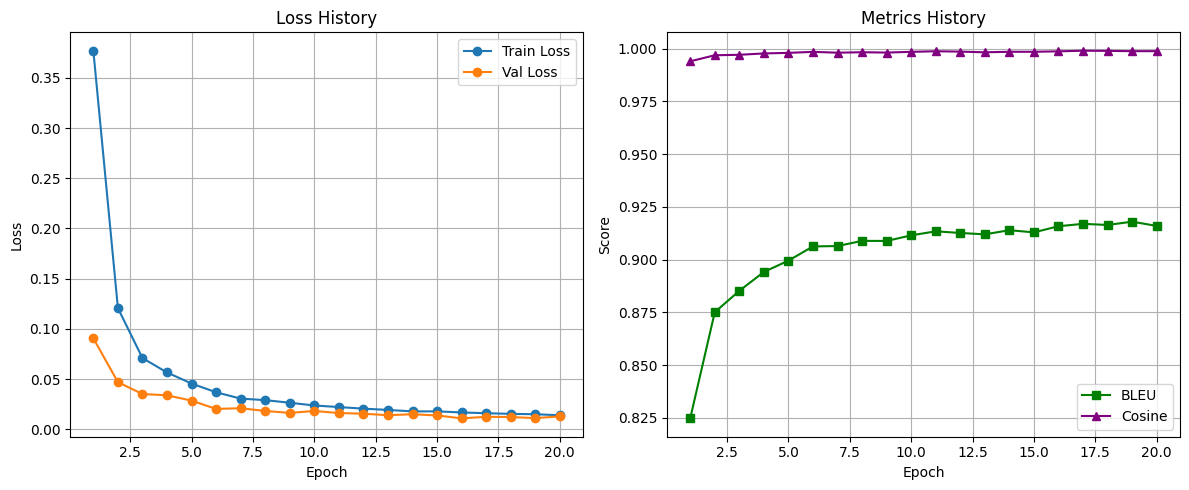


=== SAMPLE RECONSTRUCTIONS (BEST MODEL) ===
Input:  servant plows road
Target: servant plows road
Pred:   servant plows road
------------------------------
Input:  holds power city throne authority town / seated people temple king
Target: seated king holds authority power throne temple people city / town
Pred:   seated king holds authority power throne temple people city / town
------------------------------
Input:  mountain desert near
Target: mountain near desert
Pred:   mountain near desert
------------------------------
Input:  live people riverbank lake field
Target: people live riverbank lake field
Pred:   people live riverbank lake field
------------------------------
Input:  viper hide basket the with in horned handle near brick
Target: horned viper hide in the basket with handle near brick
Pred:   horned viper hide in the basket with handle near brick
------------------------------
Input:  scroll above stool book / scribe papyrus scribe temple writing mat /
Target: scribe wri

In [4]:
import torch
import random
import pandas as pd
import numpy as np
import os
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import AdamW
from transformers import (
    BartTokenizer, 
    BartForConditionalGeneration, 
    get_linear_schedule_with_warmup
)
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 0. CONFIGURATION & DIRECTORIES
# ==========================================
MODEL_NAME = "facebook/bart-base"
MAX_LEN = 32
BATCH_SIZE = 16
EPOCHS = 20
LEARNING_RATE = 5e-5
SAVE_DIR = "./best_model_checkpoint"

if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

# ==========================================
# 1. DATA LOADING & PREPARATION
# ==========================================
# Assuming these variables exist in your environment. 
# Added fallbacks for script stability.

# Clean the inputs: Convert multiline strings to space-separated strings
original_shuffled = [s.replace("\n", " ").strip() for s in shuffled_sentences_raw]

# ==========================================
# 2. DATA AUGMENTATION
# ==========================================
print("Generating augmented data...")

def augment_data(ground_truth_list, num_augmentations=10):
    """
    Creates multiple shuffled versions of each ground truth sentence.
    """
    inputs = []
    targets = []
    
    for sentence in ground_truth_list:
        words = sentence.split()
        if len(words) <= 1:
            continue
            
        for _ in range(num_augmentations):
            shuffled_words = words.copy()
            random.shuffle(shuffled_words)
            inputs.append(" ".join(shuffled_words))
            targets.append(sentence)
            
    return inputs, targets

aug_inputs, aug_targets = augment_data(merged_ground_truth_sentences, num_augmentations=10)

all_inputs = aug_inputs + original_shuffled
all_targets = aug_targets + merged_ground_truth_sentences

df = pd.DataFrame({'input_text': all_inputs, 'target_text': all_targets})
print(f"Total dataset size after augmentation: {len(df)}")

# ==========================================
# 3. DATASET & DATALOADER
# ==========================================
class SentenceReconstructionDataset(Dataset):
    def __init__(self, tokenizer, data, max_len=32):
        self.tokenizer = tokenizer
        self.data = data
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        source = str(self.data.iloc[index]['input_text'])
        target = str(self.data.iloc[index]['target_text'])

        source_tok = self.tokenizer(
            source, 
            max_length=self.max_len, 
            padding='max_length', 
            truncation=True, 
            return_tensors='pt'
        )

        target_tok = self.tokenizer(
            target, 
            max_length=self.max_len, 
            padding='max_length', 
            truncation=True, 
            return_tensors='pt'
        )

        # Labels for BART: shift happens internally, but we set -100 for padding
        labels = target_tok['input_ids'].flatten()
        labels[labels == self.tokenizer.pad_token_id] = -100

        return {
            'input_ids': source_tok['input_ids'].flatten(),
            'attention_mask': source_tok['attention_mask'].flatten(),
            'labels': labels
        }

# ==========================================
# 4. MODEL SETUP
# ==========================================
print(f"Loading {MODEL_NAME} model...")
tokenizer = BartTokenizer.from_pretrained(MODEL_NAME)
model = BartForConditionalGeneration.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Split Data
train_size = int(0.8 * len(df))
val_size = len(df) - train_size
train_indices, val_indices = random_split(range(len(df)), [train_size, val_size])

train_df = df.iloc[list(train_indices.indices)].reset_index(drop=True)
val_df = df.iloc[list(val_indices.indices)].reset_index(drop=True)

train_set = SentenceReconstructionDataset(tokenizer, train_df, max_len=MAX_LEN)
val_set = SentenceReconstructionDataset(tokenizer, val_df, max_len=MAX_LEN)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

# ==========================================
# 5. METRICS HELPER
# ==========================================
try:
    from sentence_transformers import SentenceTransformer
    sim_model = SentenceTransformer('all-MiniLM-L6-v2')
    calc_cosine = True
except ImportError:
    print("sentence-transformers not installed. Cosine similarity will be skipped.")
    calc_cosine = False

def calculate_metrics(predictions, references):
    chencherry = SmoothingFunction()
    bleu_scores = [sentence_bleu([ref.split()], pred.split(), smoothing_function=chencherry.method1) 
                   for pred, ref in zip(predictions, references)]
    avg_bleu = np.mean(bleu_scores)

    avg_cosine = 0.0
    if calc_cosine:
        pred_embeddings = sim_model.encode(predictions)
        ref_embeddings = sim_model.encode(references)
        cos_sims = cosine_similarity(pred_embeddings, ref_embeddings).diagonal()
        avg_cosine = np.mean(cos_sims)
    
    return avg_bleu, avg_cosine

# ==========================================
# 6. TRAINING LOOP
# ==========================================
history = {'epoch': [], 'train_loss': [], 'val_loss': [], 'bleu': [], 'cosine': []}
best_val_loss = float('inf')

print("Starting training...")

for epoch in range(EPOCHS):
    # --- TRAIN ---
    model.train()
    total_train_loss = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        
        total_train_loss += loss.item()
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})

    avg_train_loss = total_train_loss / len(train_loader)

    # --- VALIDATION ---
    model.eval()
    total_val_loss = 0
    predictions = []
    references = []
    
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_val_loss += outputs.loss.item()
            
            generated_ids = model.generate(input_ids=input_ids, attention_mask=attention_mask, max_length=MAX_LEN)
            decoded_preds = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
            
            # Reset -100 to pad_token_id for proper decoding
            labels_to_decode = labels.clone()
            labels_to_decode[labels_to_decode == -100] = tokenizer.pad_token_id
            decoded_labels = tokenizer.batch_decode(labels_to_decode, skip_special_tokens=True)
            
            predictions.extend(decoded_preds)
            references.extend(decoded_labels)

    avg_val_loss = total_val_loss / len(val_loader)
    bleu, cosine = calculate_metrics(predictions, references)
    
    # --- CHECKPOINTING (BEST VERSION) ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        print(f"--> New best model found! Saving to {SAVE_DIR}...")
        # Using HuggingFace's recommended method instead of legacy torch.save
        model.save_pretrained(SAVE_DIR)
        tokenizer.save_pretrained(SAVE_DIR)
    
    history['epoch'].append(epoch + 1)
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['bleu'].append(bleu)
    history['cosine'].append(cosine)
    
    print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | BLEU: {bleu:.4f}")

# ==========================================
# 7. RESULTS & VISUALIZATION
# ==========================================
# Load the best model for final evaluation/visualization
print("Loading best model for final reporting...")
model = BartForConditionalGeneration.from_pretrained(SAVE_DIR).to(device)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['epoch'], history['train_loss'], label='Train Loss', marker='o')
plt.plot(history['epoch'], history['val_loss'], label='Val Loss', marker='o')
plt.title('Loss History')
plt.xlabel('Epoch'), plt.ylabel('Loss'), plt.legend(), plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['epoch'], history['bleu'], label='BLEU', marker='s', color='green')
if calc_cosine:
    plt.plot(history['epoch'], history['cosine'], label='Cosine', marker='^', color='purple')
plt.title('Metrics History')
plt.xlabel('Epoch'), plt.ylabel('Score'), plt.legend(), plt.grid(True)
plt.tight_layout()
plt.show()

print("\n=== SAMPLE RECONSTRUCTIONS (BEST MODEL) ===")
sample_indices = random.sample(range(len(predictions)), min(10, len(predictions)))
for i in sample_indices:
    print(f"Input:  {val_df.iloc[i]['input_text']}")
    print(f"Target: {references[i]}")
    print(f"Pred:   {predictions[i]}")
    print("-" * 30)

# Save logs
pd.DataFrame(history).to_csv('training_metrics.csv', index=False)
pd.DataFrame({'Input': val_df['input_text'], 'Target': references, 'Prediction': predictions}).to_csv('reconstruction_results.csv', index=False)
print(f"\nTraining complete. Best model saved in: {SAVE_DIR}")